> ## ▶ [Open the live, interactive version →](https://djamelzair.github.io/FraudImbalanceExampleRaboApplication/)
>
> The charts in this notebook are static images. The **live page** lets you move the assumptions yourself and watch who pays for each choice — no statistics required.

# Fraud detection under extreme class imbalance

**Detecting card fraud when only 1 transaction in 578 is fraudulent, and deciding what to do about it.**

Djamel Zair · [the live interactive page](https://djamelzair.github.io/FraudImbalanceExampleRaboApplication/)

> The charts below are static images, because that is what GitHub can display. Every one of them is interactive, with hover values on each point, in the [rendered notebook](https://djamelzair.github.io/FraudImbalanceExampleRaboApplication/notebook.html) and when you run this file yourself.

---

## Why this notebook exists

Most fraud-detection notebooks stop at a model and a score. The difficult part of this problem is not fitting the model, it is everything that comes after: deciding how much confidence the numbers deserve, what an error actually costs, and what the bank should *do* when the model is unsure.

This notebook is about that second half. It is written to be read in order, and the reasoning is deliberately left visible, including the decisions that turned out to be wrong.

## The problem in one paragraph

284,807 real card transactions over two days. 492 of them are fraudulent, which is 0.173%. A model that labels every transaction as legitimate scores **99.83% accuracy** and catches nothing. Every evaluation choice in this notebook follows from that fact.

## Headline result on the untouched test period

The final model was evaluated exactly once, on a period held back from every decision.

| | |
|---|---|
| Fraud caught | **64 of 74** (86%) |
| Legitimate customers held or declined | **114 of 56,672** (0.20%) |
| Precision of the strictest band | **91%**. 50 of 55 declines were genuine fraud |
| Average precision | **0.78**, 95% interval **[0.68, 0.86]** |

The interval is the honest headline. With 74 fraud cases in the test period, a single number quoted to three decimal places would be false precision.

## What this notebook does that most do not

**Reports uncertainty on every headline number.** Metrics carry bootstrap intervals. Model comparison uses a *paired* bootstrap, which shows the calibrated model beats the transparent one in 100% of resamples even though their individual intervals overlap heavily.

**Treats the two errors as economically different.** Missed fraud is costed at the value of that specific transaction. A false alert is costed per alert, and because nobody has told me what that costs, it is swept across a plausible range instead of being guessed once. The cost-optimal operating point moves more than twentyfold across that range, which is why this notebook does not ship a single "optimal" threshold.

**Shows that the optimum is partly noise.** Holding the cost assumption fixed and resampling the same data still moves the cost-optimal alert volume by a factor of two. A threshold tuned to that minimum would be fitted to 57 fraud cases.

**Replaces the binary decision with a graded one.** Instead of approve-or-decline, the calibrated probability drives four responses: approve, automated verification, analyst review, decline. Matched on fraud caught, this cuts the cost of customer disruption by 98% against a single blocking threshold, because a wrong automated verification costs a customer seconds and a wrong decline costs them a refused payment at a till.

**Asks who bears the false alarms.** No protected attributes exist in this data, and the notebook says so rather than faking an audit. What it can test, it does: the smallest transactions are held or declined at **2.8× the average rate**. The notebook then implements a cap on that disparity and prices it at one fraud case over the validation period. That exchange rate is the business's decision to make, and a modeller's job is to put a number on it.

**Prices interpretability in fraud cases, not metrics.** At an equal budget of 50 alerts, the transparent logistic model catches 10 fewer frauds than the opaque one. That is the form the trade-off should take in a conversation with risk and compliance.

**Predicts its own degradation, then checks it.** Precision was expected to shift between periods purely because the fraud rate changed. The prediction, written down before the test scores existed, was 2.6%. The observed value was 2.4%. In production this is what separates "the model is decaying" from "there is simply less fraud this month". Those two situations demand opposite responses.

**Tests the standard answer instead of dismissing it.** SMOTE is what most published work on this dataset reaches for. The notebook runs it head to head against class weighting under identical conditions and finds the paired interval spans zero: neither is demonstrably better, and doing nothing at all scores much the same. What does separate them is calibration, where SMOTE combined with weighting overstates the real fraud rate by around thirty times, which would quietly invalidate every cost figure downstream.

**Reproduces the shortcuts that produce the published numbers.** Evaluating on a rebalanced sample lifts average precision from 0.78 to 0.97 without touching the model. Resampling before splitting returns 0.9998 and matches the strongest results in the literature, while measuring memorisation rather than detection. Splitting at random instead of by time lifts precision from 41% to 65%. Same data, same model, three different exams.

**Actually looks at the predictors.** A single component, `V14`, separates fraud on its own at an AUC of 0.95. Fraud is roughly three times more likely between midnight and six in the morning, and those six hours hold a third of all fraud in the training period. Transactions of exactly zero are fraudulent at six times the base rate, which is what testing a stolen card looks like. The exploration runs on the training period only, so nothing seen there can influence what is later validated elsewhere.

**Keeps a promise it made early on.** The decision to remove 1,081 duplicate rows was flagged at the time as an assumption to be tested, not a cleaning step. It is tested at the end: the entire pipeline is re-run with every row retained, and the difference is smaller than the sampling noise.

## How to read it

The notebook runs top to bottom in about 45 minutes. The sections in order are: data quality → why accuracy is misleading → exploration of the target and amount → chronological validation strategy → **exploration of the predictors** → outliers → evaluation framework → interpretable baseline → feature engineering and stability-aware selection → XGBoost → **calibration** → **uncertainty** → **resampling and the shortcuts** → **error costs** → **graded decision policy** → **distributional impact** → **interpretability** → **drift** → **the single test evaluation** → **robustness** → limitations.

The bolded sections are the ones this notebook is really about. If you only read one, read the graded decision policy.

## The honest summary

The strongest model by average precision is not automatically the right model to deploy. A threshold that minimises estimated cost is fitted to noise when fraud cases number in the dozens. And a system that can only approve or decline will always resolve the conflict between catching fraud and protecting customers badly.

The limitations section at the end is not a formality. It states what this data cannot support, which assumptions are mine rather than the data's, and what I would do next in order.

## Imports and configuration

I first import the libraries used throughout the notebook and define a consistent visual style.

A single colour palette and a set of reusable Plotly helpers are defined once here so that later figures remain consistent without repeating configuration code.

In [1]:
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Reproducibility
RANDOM_STATE = 42

# House colour palette
BRAND_BLUE = "#2C3696"
BRAND_ORANGE = "#F36717"
BRAND_LIGHT_ORANGE = "#F9B248"
BRAND_LIGHT_BLUE = "#D9DCF2"
BRAND_DARK = "#1F2937"
BRAND_GREY = "#6B7280"

CLASS_LABELS = {
    0: "Legitimate",
    1: "Fraud",
}

CLASS_COLOURS = {
    "Legitimate": BRAND_BLUE,
    "Fraud": BRAND_ORANGE,
}

# Consistent interactive figure formatting
pio.templates["house"] = go.layout.Template(
    layout=go.Layout(
        template="plotly_white",
        font=dict(
            family="Arial, sans-serif",
            size=13,
            color=BRAND_DARK,
        ),
        title=dict(
            font=dict(
                size=20,
                color=BRAND_BLUE,
            ),
            x=0.02,
            xanchor="left",
        ),
        colorway=[
            BRAND_BLUE,
            BRAND_ORANGE,
            BRAND_LIGHT_ORANGE,
            BRAND_GREY,
        ],
        hoverlabel=dict(
            bgcolor="white",
            font_size=13,
            font_family="Arial, sans-serif",
        ),
        legend=dict(
            title=None,
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1,
        ),
        margin=dict(
            l=70,
            r=40,
            t=90,
            b=70,
        ),
    )
)

pio.templates.default = "house"

# Figures are emitted twice over: as a Plotly mime bundle, which stays
# interactive in Jupyter, VS Code and nbviewer, and as a static image,
# which is what GitHub's notebook viewer is able to display.
pio.renderers.default = "plotly_mimetype+png"
pio.renderers["png"].scale = 2
pio.kaleido.scope.default_width = 1050
pio.kaleido.scope.default_height = 600
pio.kaleido.scope.default_scale = 2

pd.set_option("display.max_columns", 40)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)


def apply_house_style(
    fig,
    title,
    x_title=None,
    y_title=None,
    show_legend=True,
):
    """Apply the notebook's house formatting to a Plotly figure."""
    fig.update_layout(
        title=title,
        xaxis_title=x_title,
        yaxis_title=y_title,
        showlegend=show_legend,
        template="house",
    )

    return fig


def add_class_labels(data):
    """Return a copy with readable transaction-class labels."""
    labelled_data = data.copy()

    labelled_data["Class label"] = (
        labelled_data["Class"]
        .map(CLASS_LABELS)
    )

    if labelled_data["Class label"].isna().any():
        unexpected_values = labelled_data.loc[
            labelled_data["Class label"].isna(),
            "Class",
        ].unique()

        raise ValueError(
            f"Unexpected class values found: {unexpected_values}"
        )

    return labelled_data

## Data loading and initial inspection

I load the transaction data and inspect its shape, columns and class distribution before making any changes.

In [2]:

df = pd.read_csv("creditcard.csv")

display(df.head())
print(f"Dataset shape: {df.shape}")
print("Column names:")
print(df.columns.tolist())

class_counts = df["Class"].value_counts().sort_index()
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(class_counts)
print("Class percentages:")
print(class_percentages)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,'0'
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,'0'
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,'0'
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,'0'
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,'0'


Dataset shape: (284807, 31)
Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Class counts:
Class
'0'    284315
'1'       492
Name: count, dtype: int64
Class percentages:
Class
'0'   99.8273
'1'    0.1727
Name: proportion, dtype: float64


### Initial observations

The dataset contains **284,807 transactions and 31 variables**. Most of the predictors, `V1` through `V28`, are anonymised principal components. This means they can still be useful for prediction, but their practical meaning cannot be interpreted directly. The only predictors that retain a clear meaning are `Time`, which records the number of seconds since the first transaction, and `Amount`, which records the transaction value.

The first major challenge is the extreme class imbalance. Only **492 transactions, or 0.173% of the dataset, are labelled as fraud**, compared with 284,315 legitimate transactions. This is approximately one fraudulent transaction for every 578 legitimate transactions.

This imbalance has an important implication for model evaluation. A naive approach that labels every transaction as legitimate would already achieve an accuracy of approximately **99.83%**, while failing to detect a single fraudulent transaction. Accuracy alone would therefore provide a highly misleading impression of performance.

Another issue visible in the output is that the `Class` values appear as `'0'` and `'1'`, rather than numeric values. Before continuing, I need to verify whether these are strings containing quotation marks and convert them safely to numeric labels if necessary. I will also check the remaining data types, missing values, duplicate observations and invalid values before making any changes to the dataset.

The next step is therefore a focused data-quality assessment. Once the target variable and dataset integrity have been verified, I can examine how fraud differs across transaction time and amount. Only after understanding these patterns should the data be divided into training, validation and test sets. Model performance can then be evaluated using measures that reflect the actual objective, such as precision, recall, average precision and the number of false alerts, rather than relying on overall accuracy.


## 2. Data quality checks

Before exploring patterns or training models, I first check whether the dataset contains missing values, duplicate rows, invalid numerical values or unexpected target labels.

The target variable also appears to have been loaded as text, with quotation marks around `0` and `1`. I therefore clean and validate this column explicitly before continuing.


In [3]:

# Preserve the original version before making changes
df_original = df.copy()

# Clean and convert the target variable
df["Class"] = (
    df["Class"]
    .astype(str)
    .str.strip()
    .str.strip("'\"")
    .astype(int)
)

# Validate target values
observed_classes = set(df["Class"].unique())
expected_classes = {0, 1}

if observed_classes != expected_classes:
    raise ValueError(
        f"Unexpected target values found: {observed_classes}"
    )

# Data-quality checks
missing_values = df.isna().sum()
duplicate_rows = df.duplicated().sum()

numeric_columns = df.select_dtypes(include="number").columns
infinite_values = np.isinf(df[numeric_columns]).sum()

constant_columns = [
    column
    for column in df.columns
    if df[column].nunique(dropna=False) <= 1
]

print(f"Total missing values: {missing_values.sum():,}")
print(f"Exact duplicate rows: {duplicate_rows:,}")
print(f"Total infinite values: {infinite_values.sum():,}")
print(f"Constant columns: {constant_columns if constant_columns else 'None'}")

print("\nCleaned target values:")
print(df["Class"].value_counts().sort_index())

print("\nTarget data type:")
print(df["Class"].dtype)

if missing_values.sum() > 0:
    display(
        missing_values[missing_values > 0]
        .to_frame("Missing values")
    )

if infinite_values.sum() > 0:
    display(
        infinite_values[infinite_values > 0]
        .to_frame("Infinite values")
    )

Total missing values: 0
Exact duplicate rows: 1,081
Total infinite values: 0
Constant columns: None

Cleaned target values:
Class
0    284315
1       492
Name: count, dtype: int64

Target data type:
int64


### Data-quality findings

No missing, infinite or constant values were found, and the target variable now contains the expected numeric labels `0` and `1`.

The dataset does contain **1,081 exact duplicate rows**. I will not remove these automatically. In transaction data, identical records could represent accidental duplication, but they could also represent separate transactions that happen to share the same anonymised characteristics. Removing them without inspection could discard valid observations, particularly from the already very small fraud class.

I therefore first examine which classes contain duplicate records and whether any transactions have identical predictor values but conflicting fraud labels.


In [4]:
# Identify every row that belongs to an exact duplicate group
duplicate_mask = df.duplicated(keep=False)
duplicate_records = df.loc[duplicate_mask].copy()

print(f"Rows belonging to duplicate groups: {len(duplicate_records):,}")
print(f"Rows that would be removed with keep='first': {df.duplicated().sum():,}")

print("\nDuplicate records by class:")
print(
    duplicate_records["Class"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Legitimate", 1: "Fraud"})
)

# Check for identical predictors with different target labels
feature_columns = [column for column in df.columns if column != "Class"]

label_counts_per_feature_set = (
    df.groupby(feature_columns, dropna=False)["Class"]
    .nunique()
)

conflicting_feature_sets = label_counts_per_feature_set[
    label_counts_per_feature_set > 1
]

print(
    "\nIdentical predictor combinations with conflicting labels: "
    f"{len(conflicting_feature_sets):,}"
)

# Show a small sample of exact duplicate groups
display(
    duplicate_records
    .sort_values(feature_columns)
    .head(10)
)

Rows belonging to duplicate groups: 1,854


Rows that would be removed with keep='first': 1,081

Duplicate records by class:
Class
Legitimate    1822
Fraud           32
Name: count, dtype: int64



Identical predictor combinations with conflicting labels: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26.0000,-0.5354,0.8653,1.3511,0.1476,0.4337,0.0870,0.6930,0.1797,-0.2856,-0.4825,0.8718,0.8534,-0.5718,0.1023,-1.5200,-0.2859,-0.3096,-0.4039,-0.8237,-0.2833,0.0495,0.2065,-0.1871,0.0008,0.0981,-0.5535,-0.0783,0.0254,1.7700,0
35,26.0000,-0.5354,0.8653,1.3511,0.1476,0.4337,0.0870,0.6930,0.1797,-0.2856,-0.4825,0.8718,0.8534,-0.5718,0.1023,-1.5200,-0.2859,-0.3096,-0.4039,-0.8237,-0.2833,0.0495,0.2065,-0.1871,0.0008,0.0981,-0.5535,-0.0783,0.0254,1.7700,0
32,26.0000,-0.5299,0.8739,1.3472,0.1455,0.4142,0.1002,0.7112,0.1761,-0.2867,-0.4847,0.8725,0.8516,-0.5717,0.1010,-1.5198,-0.2844,-0.3105,-0.4042,-0.8234,-0.2903,0.0469,0.2081,-0.1855,0.0010,0.0988,-0.5529,-0.0733,0.0233,6.1400,0
33,26.0000,-0.5299,0.8739,1.3472,0.1455,0.4142,0.1002,0.7112,0.1761,-0.2867,-0.4847,0.8725,0.8516,-0.5717,0.1010,-1.5198,-0.2844,-0.3105,-0.4042,-0.8234,-0.2903,0.0469,0.2081,-0.1855,0.0010,0.0988,-0.5529,-0.0733,0.0233,6.1400,0
112,74.0000,1.0384,0.1275,0.1845,1.1099,0.4417,0.9453,-0.0367,0.3510,0.1189,-0.2433,0.5781,0.6747,-0.5342,0.4466,1.1229,-1.7680,1.2412,-2.4495,-1.7473,-0.3355,0.1025,0.6051,0.0231,-0.6265,0.4791,-0.1669,0.0812,0.0012,1.1800,0
113,74.0000,1.0384,0.1275,0.1845,1.1099,0.4417,0.9453,-0.0367,0.3510,0.1189,-0.2433,0.5781,0.6747,-0.5342,0.4466,1.1229,-1.7680,1.2412,-2.4495,-1.7473,-0.3355,0.1025,0.6051,0.0231,-0.6265,0.4791,-0.1669,0.0812,0.0012,1.1800,0
114,74.0000,1.0384,0.1275,0.1845,1.1099,0.4417,0.9453,-0.0367,0.3510,0.1189,-0.2433,0.5781,0.6747,-0.5342,0.4466,1.1229,-1.7680,1.2412,-2.4495,-1.7473,-0.3355,0.1025,0.6051,0.0231,-0.6265,0.4791,-0.1669,0.0812,0.0012,1.1800,0
115,74.0000,1.0384,0.1275,0.1845,1.1099,0.4417,0.9453,-0.0367,0.3510,0.1189,-0.2433,0.5781,0.6747,-0.5342,0.4466,1.1229,-1.7680,1.2412,-2.4495,-1.7473,-0.3355,0.1025,0.6051,0.0231,-0.6265,0.4791,-0.1669,0.0812,0.0012,1.1800,0
220,145.0000,-2.4204,1.9479,0.5536,0.9831,-0.2815,2.4090,-1.4016,-0.1883,0.6759,0.1585,-1.2250,1.3147,0.3044,-0.2902,-2.0145,-0.7728,0.6968,0.0179,2.1772,-0.2762,1.2138,-1.2386,0.0069,-1.7242,0.2396,-0.3137,-0.1883,0.1198,6.0000,0
221,145.0000,-2.4204,1.9479,0.5536,0.9831,-0.2815,2.4090,-1.4016,-0.1883,0.6759,0.1585,-1.2250,1.3147,0.3044,-0.2902,-2.0145,-0.7728,0.6968,0.0179,2.1772,-0.2762,1.2138,-1.2386,0.0069,-1.7242,0.2396,-0.3137,-0.1883,0.1198,6.0000,0


### Handling exact duplicate records

The dataset contains 1,081 repeated rows, including 19 repeated fraud observations. These records match exactly across `Time`, `Amount`, all 28 anonymised predictors and the target label.

Without a unique transaction identifier, it is not possible to determine with certainty whether these rows are accidental duplicates or separate transactions with identical recorded characteristics. Removing them therefore involves an assumption.

For the primary analysis, I retain one copy of each exact record. This reduces the risk that identical observations appear in both the training and test sets, which could lead to overly optimistic model performance. The original dataset is preserved separately, and the final conclusions should be checked against an analysis that retains all observations.

This means that duplicate removal is treated as a modelling decision to be tested, rather than as an unquestionable data-cleaning step.


In [5]:
rows_before = len(df)
fraud_before = df["Class"].sum()

df_deduplicated = (
    df
    .drop_duplicates()
    .reset_index(drop=True)
)

# Use the deduplicated dataset for the primary analysis
analysis_df = df_deduplicated.copy()

print(
    f"Primary analysis dataset: {len(analysis_df):,} transactions, "
    f"including {analysis_df['Class'].sum():,} fraud cases."
)

rows_after = len(df_deduplicated)
fraud_after = df_deduplicated["Class"].sum()

print(f"Rows before removing duplicates: {rows_before:,}")
print(f"Rows after removing duplicates:  {rows_after:,}")
print(f"Rows removed:                    {rows_before - rows_after:,}")

print(f"\nFraud cases before: {fraud_before:,}")
print(f"Fraud cases after:  {fraud_after:,}")
print(f"Fraud cases removed: {fraud_before - fraud_after:,}")

print(
    f"\nFraud prevalence before duplicate removal: "
    f"{df['Class'].mean() * 100:.4f}%"
)

print(
    f"Fraud prevalence after duplicate removal: "
    f"{df_deduplicated['Class'].mean() * 100:.4f}%"
)

Primary analysis dataset: 283,726 transactions, including 473 fraud cases.
Rows before removing duplicates: 284,807
Rows after removing duplicates:  283,726
Rows removed:                    1,081

Fraud cases before: 492
Fraud cases after:  473
Fraud cases removed: 19

Fraud prevalence before duplicate removal: 0.1727%
Fraud prevalence after duplicate removal: 0.1667%


## Why accuracy is misleading

Before training any machine-learning model, I establish a naive baseline that predicts every transaction as legitimate.

This strategy is intentionally useless for fraud detection, but it exposes the central evaluation problem in this dataset. Because fraudulent transactions are extremely rare, a classifier can achieve very high accuracy while detecting no fraud at all.

I therefore compare ordinary accuracy with balanced accuracy, fraud precision, fraud recall and the F1-score.

In [6]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_true = analysis_df["Class"]

# Naive strategy: predict every transaction as legitimate
y_pred_naive = np.zeros(len(analysis_df), dtype=int)

naive_accuracy = accuracy_score(y_true, y_pred_naive)
naive_balanced_accuracy = balanced_accuracy_score(y_true, y_pred_naive)
naive_precision = precision_score(
    y_true,
    y_pred_naive,
    zero_division=0
)
naive_recall = recall_score(
    y_true,
    y_pred_naive,
    zero_division=0
)
naive_f1 = f1_score(
    y_true,
    y_pred_naive,
    zero_division=0
)

naive_confusion_matrix = confusion_matrix(y_true, y_pred_naive)

tn, fp, fn, tp = naive_confusion_matrix.ravel()

print("Naive all-legitimate baseline")
print(f"Accuracy:          {naive_accuracy:.4%}")
print(f"Balanced accuracy: {naive_balanced_accuracy:.4%}")
print(f"Fraud precision:   {naive_precision:.4f}")
print(f"Fraud recall:      {naive_recall:.4f}")
print(f"Fraud F1-score:    {naive_f1:.4f}")

print("\nConfusion matrix counts")
print(f"True negatives:  {tn:,}")
print(f"False positives: {fp:,}")
print(f"False negatives: {fn:,}")
print(f"True positives:  {tp:,}")

Naive all-legitimate baseline
Accuracy:          99.8333%
Balanced accuracy: 50.0000%
Fraud precision:   0.0000
Fraud recall:      0.0000
Fraud F1-score:    0.0000

Confusion matrix counts
True negatives:  283,253
False positives: 0
False negatives: 473
True positives:  0


## Exploratory data analysis

Having established that ordinary accuracy is misleading, I now explore the structure of the transaction data.

I begin with the class distribution. Although the percentages were already calculated numerically, visualising the imbalance makes the scale of the modelling challenge much clearer. The interactive figure also allows the exact counts and percentages to be inspected directly.


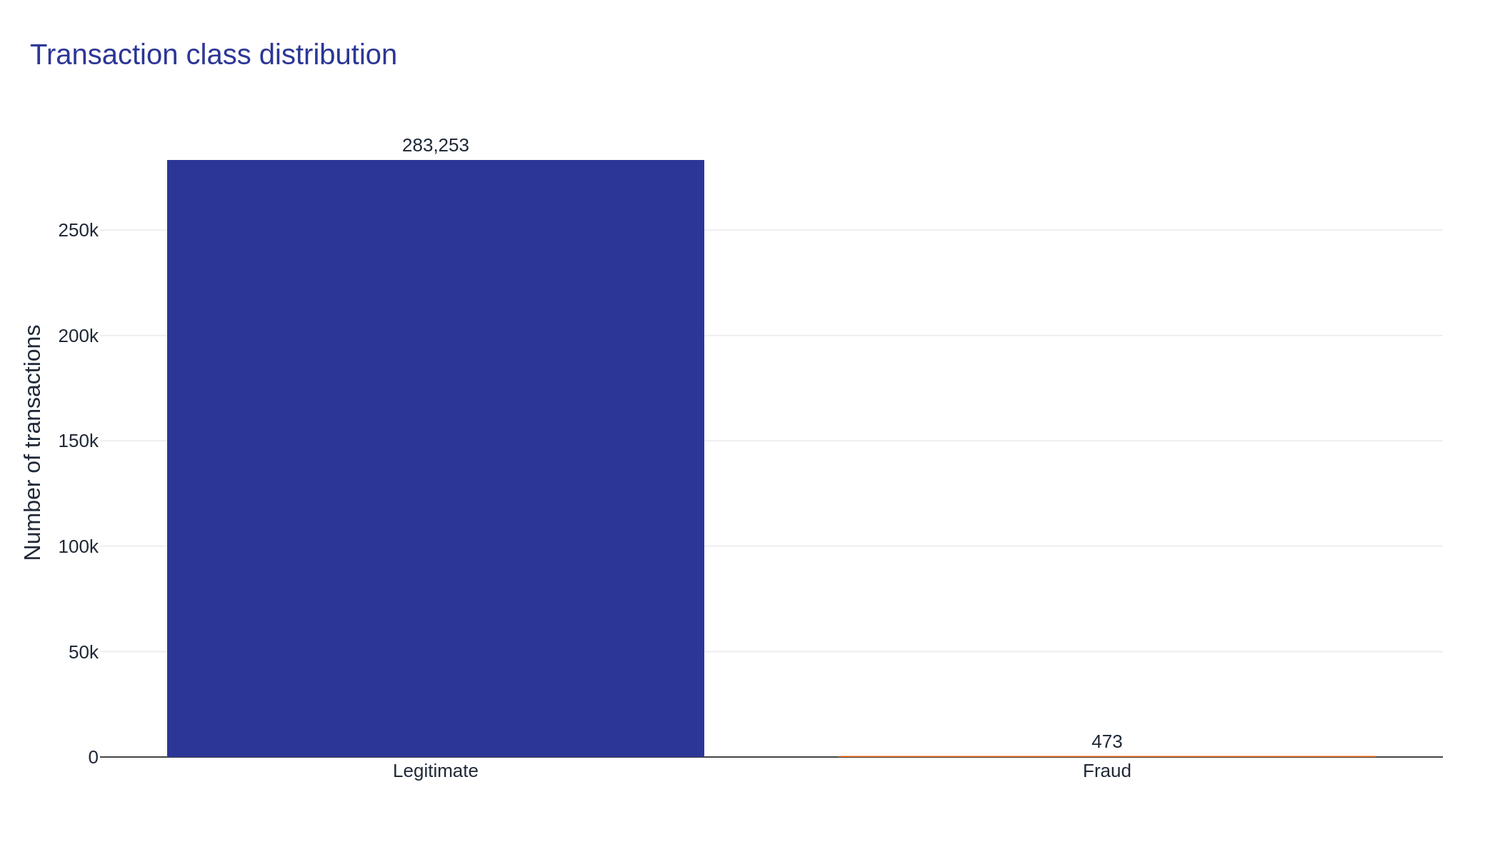

In [7]:
class_distribution = (
    analysis_df["Class"]
    .value_counts()
    .sort_index()
    .rename_axis("Class")
    .reset_index(name="Count")
)

class_distribution["Transaction type"] = (
    class_distribution["Class"]
    .map(CLASS_LABELS)
)

class_distribution["Percentage"] = (
    class_distribution["Count"]
    / len(analysis_df)
    * 100
)

fig = px.bar(
    class_distribution,
    x="Transaction type",
    y="Count",
    color="Transaction type",
    text="Count",
    custom_data=["Percentage"],
    color_discrete_map=CLASS_COLOURS,
)

fig.update_traces(
    texttemplate="%{text:,}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Transactions: %{y:,}<br>"
        "Percentage: %{customdata[0]:.4f}%"
        "<extra></extra>"
    ),
)

fig = apply_house_style(
    fig,
    title="Transaction class distribution",
    x_title=None,
    y_title="Number of transactions",
    show_legend=False,
)

fig.show()

### Class distribution

The class imbalance is immediately visible. The primary analysis dataset contains 283,253 legitimate transactions and only 473 fraudulent transactions.

This means fraud represents approximately 0.17% of the data. A model can therefore achieve a very high overall accuracy by predicting almost every transaction as legitimate, even when it detects little or no fraud.

The imbalance also affects the practical cost of false positives. Because legitimate transactions are so numerous, even a small false-positive rate can generate a large number of unnecessary alerts. Model evaluation must therefore consider both fraud recall and the number of legitimate transactions flagged for investigation.

## Transaction amount

Transaction amount may contain useful fraud-related information, but its distribution is expected to be strongly right-skewed. A small number of high-value transactions can make the majority of observations difficult to inspect on the original scale.

I therefore compare legitimate and fraudulent transaction amounts using both the original amount and a logarithmic transformation. The transformation is used only for visualisation and does not replace the original `Amount` variable.

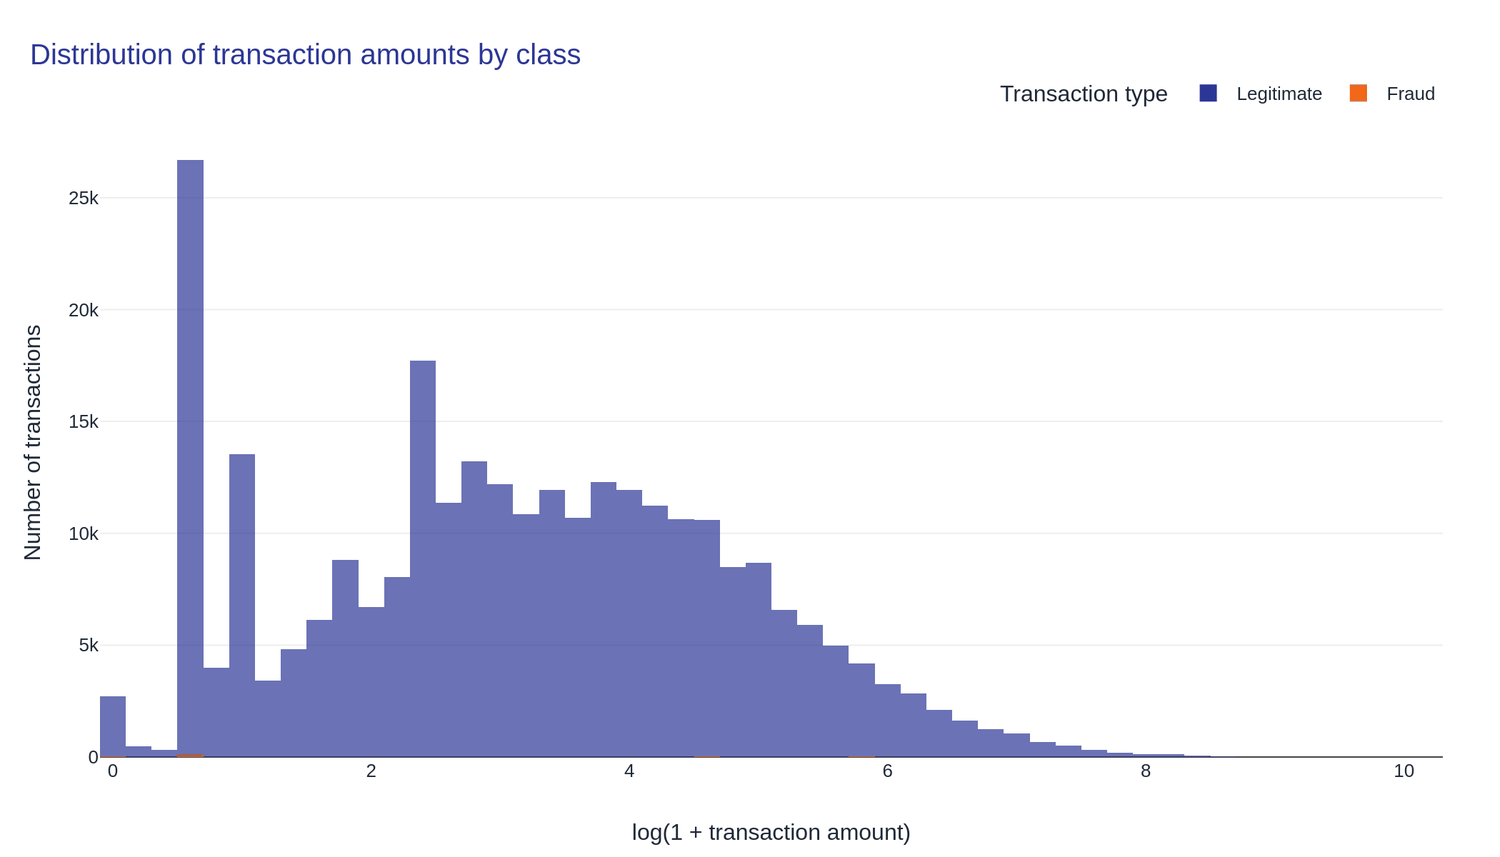

In [8]:
amount_plot_df = add_class_labels(analysis_df)

amount_plot_df["Log amount"] = np.log1p(
    amount_plot_df["Amount"]
)

fig = px.histogram(
    amount_plot_df,
    x="Log amount",
    color="Class label",
    nbins=100,
    barmode="overlay",
    opacity=0.70,
    color_discrete_map=CLASS_COLOURS,
    labels={
        "Log amount": "log(1 + transaction amount)",
        "Class label": "Transaction type",
    },
)

fig.update_traces(
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "log(1 + amount): %{x:.2f}<br>"
        "Transactions: %{y:,}"
        "<extra></extra>"
    )
)

fig = apply_house_style(
    fig,
    title="Distribution of transaction amounts by class",
    x_title="log(1 + transaction amount)",
    y_title="Number of transactions",
    show_legend=True,
)

fig.show()

### Transaction amount distribution

The logarithmic scale makes the strongly skewed transaction amounts easier to inspect, but the difference in class size still dominates the figure. The legitimate class contains hundreds of thousands of transactions, while the fraud class contains only 473.

To compare the shape of both distributions rather than their absolute counts, I therefore normalise each class separately. This shows where fraudulent and legitimate transactions are concentrated without allowing the majority class to overwhelm the comparison.

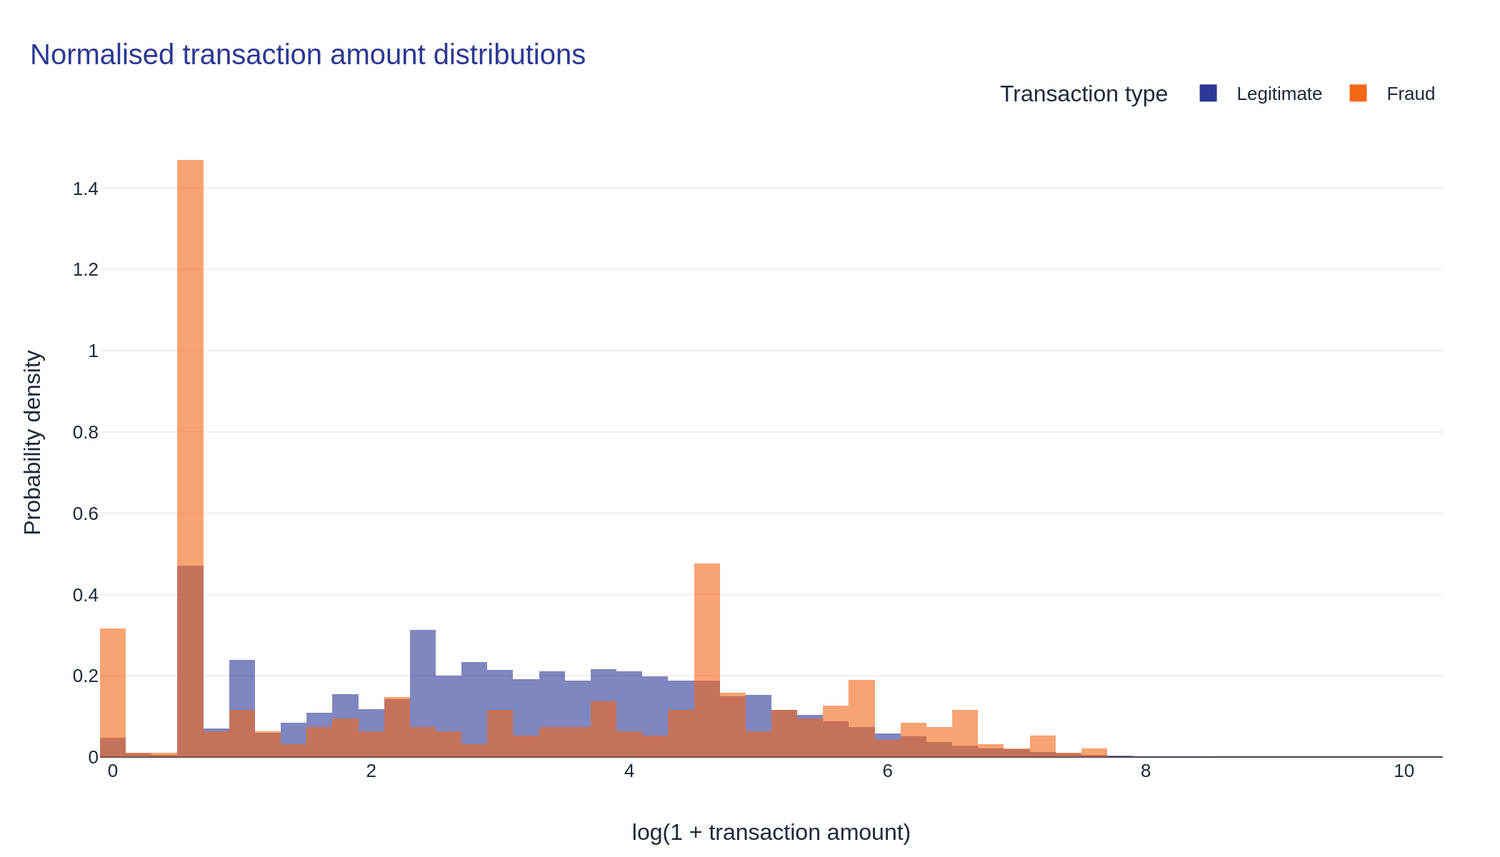

In [9]:
fig = px.histogram(
    amount_plot_df,
    x="Log amount",
    color="Class label",
    nbins=100,
    histnorm="probability density",
    barmode="overlay",
    opacity=0.60,
    color_discrete_map=CLASS_COLOURS,
    labels={
        "Log amount": "log(1 + transaction amount)",
        "Class label": "Transaction type",
    },
)

fig.update_traces(
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "log(1 + amount): %{x:.2f}<br>"
        "Density: %{y:.4f}"
        "<extra></extra>"
    )
)

fig = apply_house_style(
    fig,
    title="Normalised transaction amount distributions",
    x_title="log(1 + transaction amount)",
    y_title="Probability density",
    show_legend=True,
)

fig.show()

### Initial interpretation

After normalising the distributions, the fraud class becomes visible and can be compared directly with legitimate transactions.

The two classes overlap substantially, which means transaction amount alone will not be sufficient to distinguish fraud. However, their distributions are not identical, so `Amount` may still contribute useful information when combined with the anonymised predictors.

This also suggests that a model should not treat high-value transactions as automatically suspicious. Fraud occurs across a range of transaction amounts, and an overly simple amount-based rule would likely generate many unnecessary alerts.

### Relative frequency is not the same as fraud probability

The fraud distribution appears less smooth than the legitimate distribution because it is based on only 473 observations. Dividing this small class across many histogram bins produces unstable counts and visible peaks. This is primarily a sample-size effect rather than an application of the central limit theorem.

Very small amounts are relatively more common within the fraud class. However, this does not mean that a low-value transaction is likely to be fraudulent. Since legitimate transactions are far more numerous overall, most low-value transactions may still be legitimate.

The normalised histogram shows the distribution of amounts within each class. To assess the practical fraud risk associated with an amount range, I next calculate the proportion of transactions labelled as fraud within each amount bin.

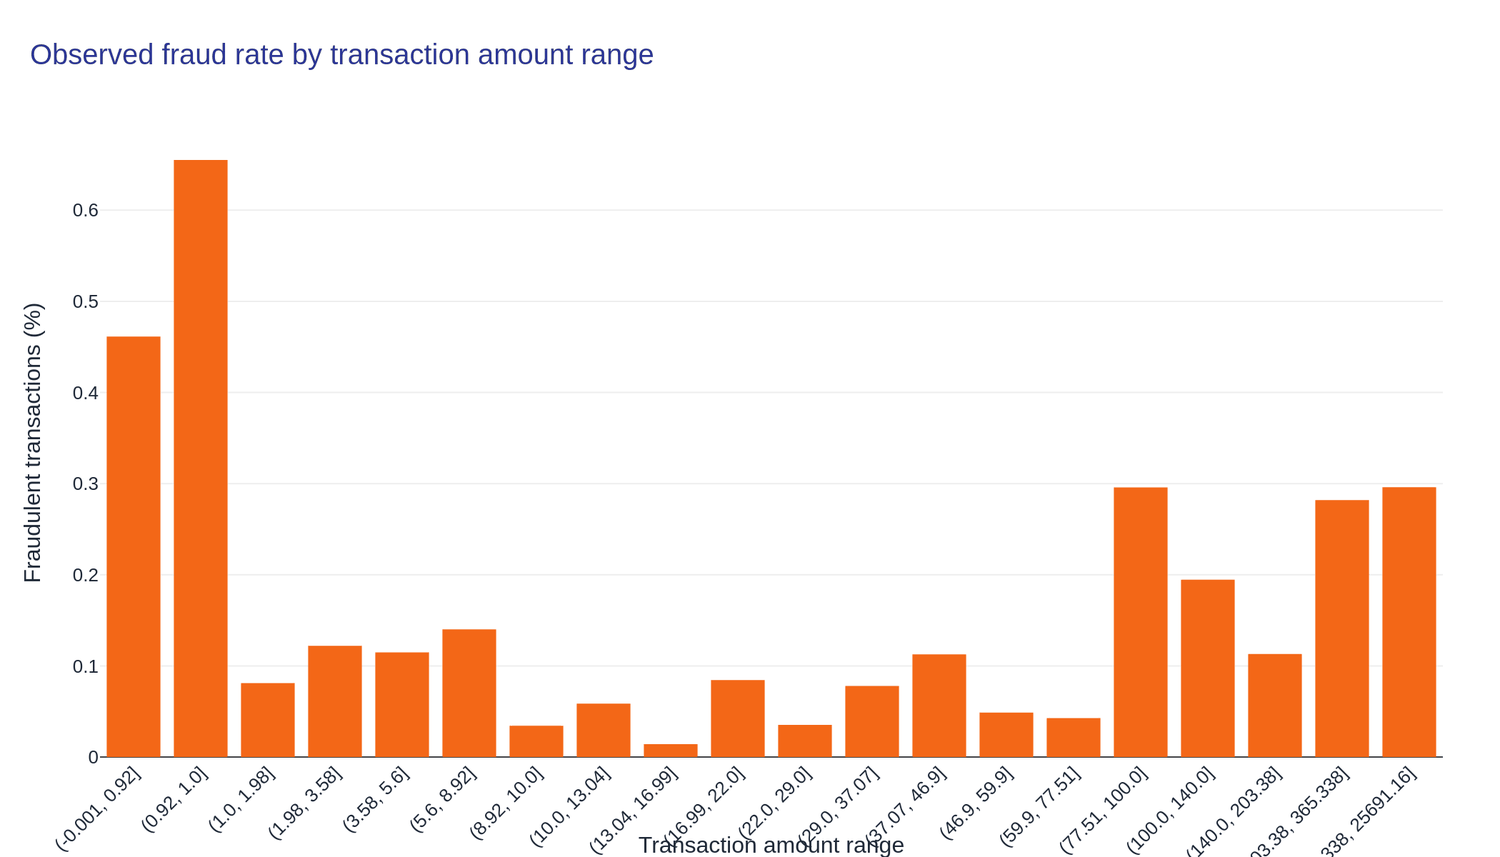

In [10]:
amount_risk_df = analysis_df.copy()

# Quantile bins contain roughly similar numbers of transactions.
# Duplicate edges are allowed for because many transactions share small amounts.
amount_risk_df["Amount bin"] = pd.qcut(
    amount_risk_df["Amount"],
    q=20,
    duplicates="drop",
)

amount_risk_by_bin = (
    amount_risk_df
    .groupby("Amount bin", observed=True)
    .agg(
        Transactions=("Class", "size"),
        Fraud_transactions=("Class", "sum"),
        Median_amount=("Amount", "median"),
    )
    .reset_index()
)

amount_risk_by_bin["Fraud rate"] = (
    amount_risk_by_bin["Fraud_transactions"]
    / amount_risk_by_bin["Transactions"]
    * 100
)

amount_risk_by_bin["Amount range"] = (
    amount_risk_by_bin["Amount bin"]
    .astype(str)
)

fig = px.bar(
    amount_risk_by_bin,
    x="Amount range",
    y="Fraud rate",
    custom_data=[
        "Transactions",
        "Fraud_transactions",
        "Median_amount",
    ],
)

fig.update_traces(
    marker_color=BRAND_ORANGE,
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Fraud rate: %{y:.4f}%<br>"
        "Transactions: %{customdata[0]:,}<br>"
        "Fraud transactions: %{customdata[1]:,}<br>"
        "Median amount: €%{customdata[2]:,.2f}"
        "<extra></extra>"
    ),
)

fig = apply_house_style(
    fig,
    title="Observed fraud rate by transaction amount range",
    x_title="Transaction amount range",
    y_title="Fraudulent transactions (%)",
    show_legend=False,
)

fig.update_xaxes(tickangle=-45)

fig.show()

## Validation strategy

A fraud-detection model is ultimately used to assess transactions that occur after the data on which it was trained. I therefore split the data chronologically rather than randomly.

The earliest 60% of transactions are used for training, the following 20% for validation and the final 20% as an untouched test set.

The training set is used to estimate model parameters. The validation set is used for model comparison, calibration and threshold selection. The test set is reserved for one final evaluation.

Because fraud is rare and may not be distributed evenly over time, I also inspect the number and prevalence of fraud cases in each period before continuing.

In [11]:
# Sort the primary analysis dataset chronologically
analysis_df = (
    analysis_df
    .sort_values("Time")
    .reset_index(drop=True)
)

n_transactions = len(analysis_df)

train_end = int(n_transactions * 0.60)
validation_end = int(n_transactions * 0.80)

# Chronological partitions
train_df = analysis_df.iloc[:train_end].copy()
validation_df = analysis_df.iloc[
    train_end:validation_end
].copy()
test_df = analysis_df.iloc[
    validation_end:
].copy()


def summarise_split(name, data):
    """Return a compact summary of one chronological split."""
    fraud_count = int(data["Class"].sum())
    legitimate_count = int(
        (data["Class"] == 0).sum()
    )

    return {
        "Split": name,
        "Transactions": len(data),
        "Legitimate": legitimate_count,
        "Fraud": fraud_count,
        "Fraud prevalence (%)": (
            data["Class"].mean() * 100
        ),
        "Start time (hours)": (
            data["Time"].min() / 3600
        ),
        "End time (hours)": (
            data["Time"].max() / 3600
        ),
    }


split_summary = pd.DataFrame(
    [
        summarise_split(
            "Training",
            train_df,
        ),
        summarise_split(
            "Validation",
            validation_df,
        ),
        summarise_split(
            "Test",
            test_df,
        ),
    ]
)

# Basic consistency checks
assert len(train_df) + len(validation_df) + len(test_df) == len(
    analysis_df
)

assert train_df["Time"].max() <= validation_df["Time"].min()
assert validation_df["Time"].max() <= test_df["Time"].min()

for split_name, split_data in {
    "Training": train_df,
    "Validation": validation_df,
    "Test": test_df,
}.items():
    if split_data["Class"].nunique() != 2:
        raise ValueError(
            f"{split_name} split does not contain both classes."
        )

print(
    f"Training:   {len(train_df):,} transactions"
)
print(
    f"Validation: {len(validation_df):,} transactions"
)
print(
    f"Test:       {len(test_df):,} transactions"
)

Training:   170,235 transactions
Validation: 56,745 transactions
Test:       56,746 transactions


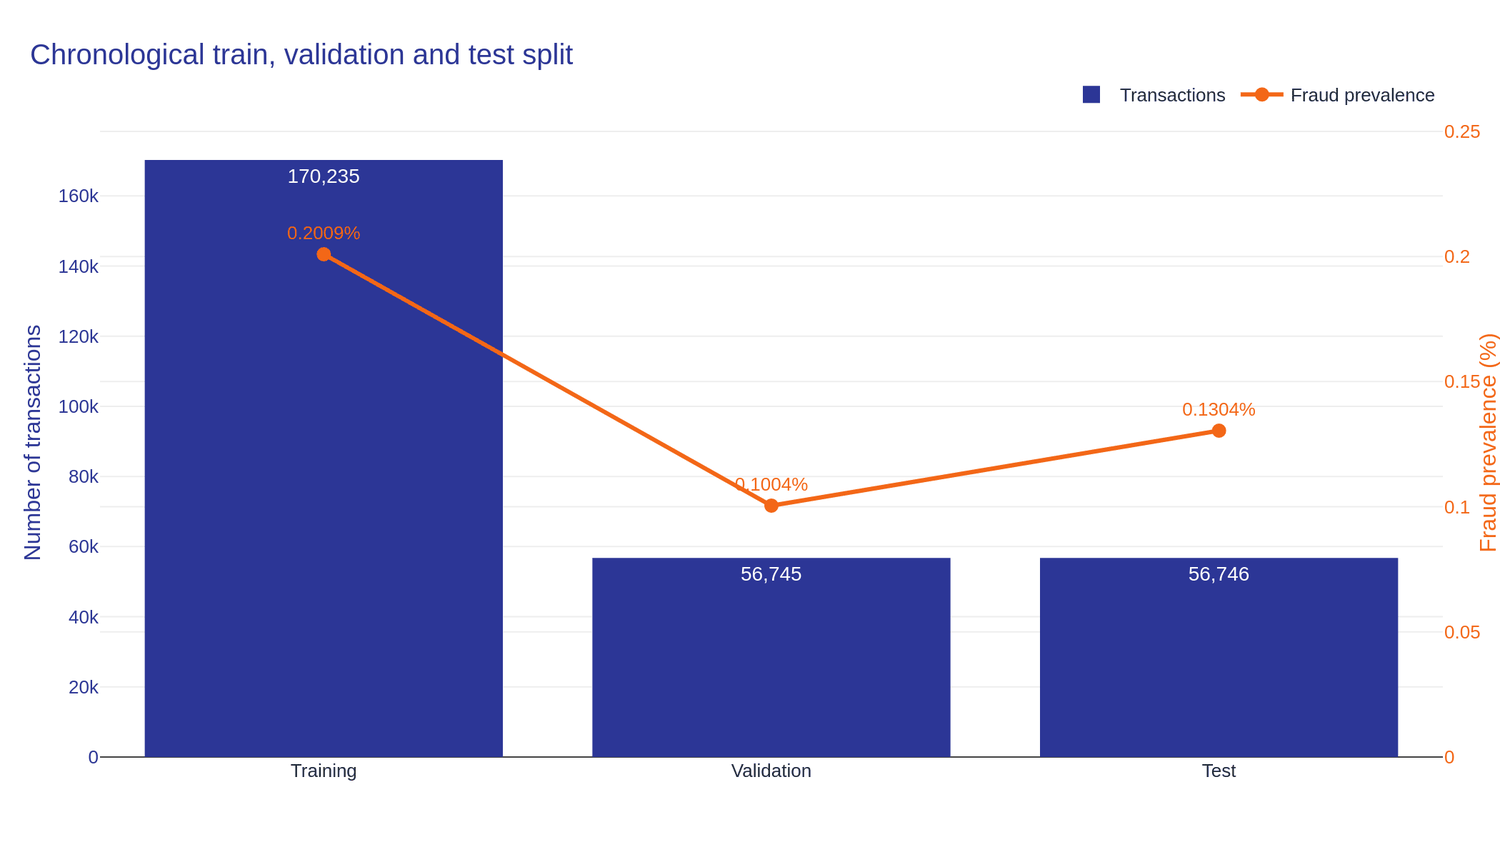

In [12]:
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=split_summary["Split"],
        y=split_summary["Transactions"],
        name="Transactions",
        marker_color=BRAND_BLUE,
        text=split_summary["Transactions"],
        texttemplate="%{text:,}",
        textposition="inside",
        insidetextanchor="end",
        textfont=dict(color="white", size=14),
        customdata=split_summary[
            [
                "Legitimate",
                "Fraud",
                "Start time (hours)",
                "End time (hours)",
            ]
        ].to_numpy(),
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Transactions: %{y:,}<br>"
            "Legitimate: %{customdata[0]:,}<br>"
            "Fraud: %{customdata[1]:,}<br>"
            "Time window: %{customdata[2]:.2f} to %{customdata[3]:.2f} hours"
            "<extra></extra>"
        ),
    )
)

fig.add_trace(
    go.Scatter(
        x=split_summary["Split"],
        y=split_summary["Fraud prevalence (%)"],
        name="Fraud prevalence",
        mode="lines+markers+text",
        line=dict(
            color=BRAND_ORANGE,
            width=3,
        ),
        marker=dict(
            color=BRAND_ORANGE,
            size=10,
        ),
        text=split_summary["Fraud prevalence (%)"],
        texttemplate="%{text:.4f}%",
        textposition="top center",
        textfont=dict(
            color=BRAND_ORANGE,
            size=13,
        ),
        yaxis="y2",
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Fraud prevalence: %{y:.4f}%"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="Chronological train, validation and test split",
    xaxis_title=None,
    yaxis=dict(
        title="Number of transactions",
        titlefont=dict(color=BRAND_BLUE),
        tickfont=dict(color=BRAND_BLUE),
    ),
    yaxis2=dict(
        title="Fraud prevalence (%)",
        titlefont=dict(color=BRAND_ORANGE),
        tickfont=dict(color=BRAND_ORANGE),
        overlaying="y",
        side="right",
        rangemode="tozero",
        range=[
            0,
            split_summary["Fraud prevalence (%)"].max() * 1.25,
        ],
    ),
    uniformtext_minsize=12,
    uniformtext_mode="show",
    template="house",
)

fig.show()

### Temporal split findings

The chronological split assigns 60% of the observations to training and 20% each to validation and testing. Each partition contains both legitimate and fraudulent transactions, although the number of fraud cases remains limited: 342 in training, 57 in validation and 74 in testing.

Fraud prevalence also changes across the observation period. It falls from approximately 0.20% in the training period to 0.10% during validation, before increasing to 0.13% in the test period. This indicates that the class distribution is not stable over time.

The variation is important because precision depends partly on fraud prevalence. A model may therefore achieve different precision values across periods even when its underlying ranking ability remains similar. Later evaluation should consequently report precision alongside recall, average precision, alert volume and absolute confusion-matrix counts.

The validation set contains only 57 fraud cases. Threshold estimates based on this set may therefore be sensitive to a small number of transactions. Rather than treating one threshold as universally optimal, I will compare several decision strategies and assess how their operational consequences change.

## Looking at the predictors themselves

So far the exploration has covered the target and the transaction amount. That leaves `V1` to `V28`, which is 28 of the 31 columns, entirely unexamined, along with the time of day. Before deciding how to treat outliers or which features to keep, it is worth knowing what is actually in there.

Everything in this section uses the **training period only**. The split has already been made, so exploring the full dataset here would let patterns from the validation and test periods influence decisions that are later checked against those same periods. Exploration is a decision-making activity, and it belongs on the same side of the wall as model fitting.

Three questions are worth answering:

1. Which individual predictors separate fraud from legitimate activity, and by how much?
2. Are the predictors related to one another, or is each carrying its own information?
3. Does the timing of a transaction matter, given that a repeating daily cycle was encoded as a feature earlier without ever being inspected?

Strongest single predictors of fraud in the training period


,Feature,Single-feature AUC,Separation,Direction
0,V14,0.046,0.454,Lower in fraud
1,V12,0.058,0.442,Lower in fraud
2,V4,0.942,0.442,Higher in fraud
3,V3,0.073,0.427,Lower in fraud
4,V11,0.922,0.422,Higher in fraud
5,V10,0.081,0.419,Lower in fraud
6,V2,0.878,0.378,Higher in fraud
7,V16,0.135,0.365,Lower in fraud
8,V7,0.148,0.352,Lower in fraud
9,V9,0.159,0.341,Lower in fraud



Weakest:


,Feature,Single-feature AUC,Separation,Direction
25,V23,0.457,0.043,Lower in fraud
26,V22,0.541,0.041,Higher in fraud
27,V26,0.530,0.030,Higher in fraud
28,V25,0.505,0.005,Higher in fraud
29,V13,0.497,0.003,Lower in fraud


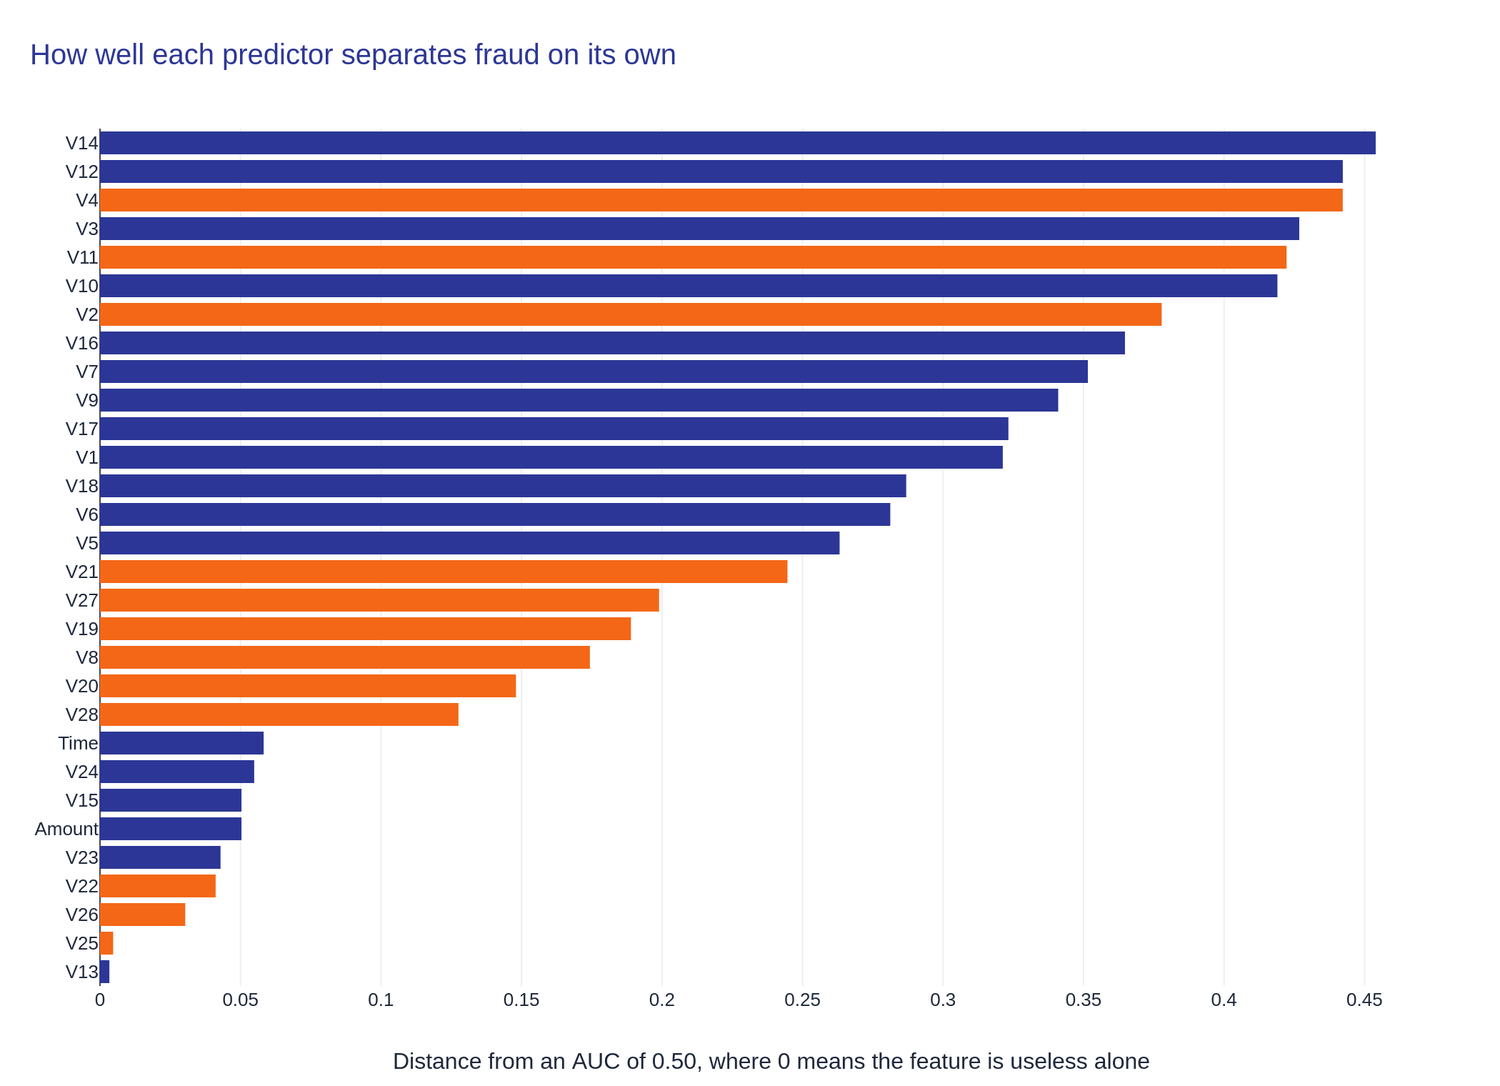

In [13]:
from sklearn.metrics import roc_auc_score

exploration_features = [column for column in train_df.columns if column != "Class"]
y_exploration = train_df["Class"]

# A single-feature AUC of 0.50 means the feature alone cannot tell the classes
# apart. Distance from 0.50 in either direction is what carries information.
separability = pd.DataFrame(
    {
        "Feature": exploration_features,
        "Single-feature AUC": [
            roc_auc_score(y_exploration, train_df[feature])
            for feature in exploration_features
        ],
    }
)

separability["Separation"] = (separability["Single-feature AUC"] - 0.50).abs()
separability["Direction"] = np.where(
    separability["Single-feature AUC"] > 0.50,
    "Higher in fraud",
    "Lower in fraud",
)

separability = separability.sort_values("Separation", ascending=False).reset_index(
    drop=True
)

top_separating = separability.head(6)["Feature"].tolist()

print("Strongest single predictors of fraud in the training period")
display(
    separability.head(10)
    .style.format({"Single-feature AUC": "{:.3f}", "Separation": "{:.3f}"})
)

print("\nWeakest:")
display(
    separability.tail(5)
    .style.format({"Single-feature AUC": "{:.3f}", "Separation": "{:.3f}"})
)

plot_order = separability.sort_values("Separation")

fig = go.Figure(
    go.Bar(
        x=plot_order["Separation"],
        y=plot_order["Feature"],
        orientation="h",
        marker_color=[
            BRAND_ORANGE if direction == "Higher in fraud" else BRAND_BLUE
            for direction in plot_order["Direction"]
        ],
        customdata=plot_order[["Single-feature AUC", "Direction"]].to_numpy(),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Separation from useless: %{x:.3f}<br>"
            "Single-feature AUC: %{customdata[0]:.3f}<br>"
            "%{customdata[1]}"
            "<extra></extra>"
        ),
    )
)

fig = apply_house_style(
    fig,
    title="How well each predictor separates fraud on its own",
    x_title="Distance from an AUC of 0.50, where 0 means the feature is useless alone",
    y_title=None,
    show_legend=False,
)

fig.update_layout(height=760)
fig.show()

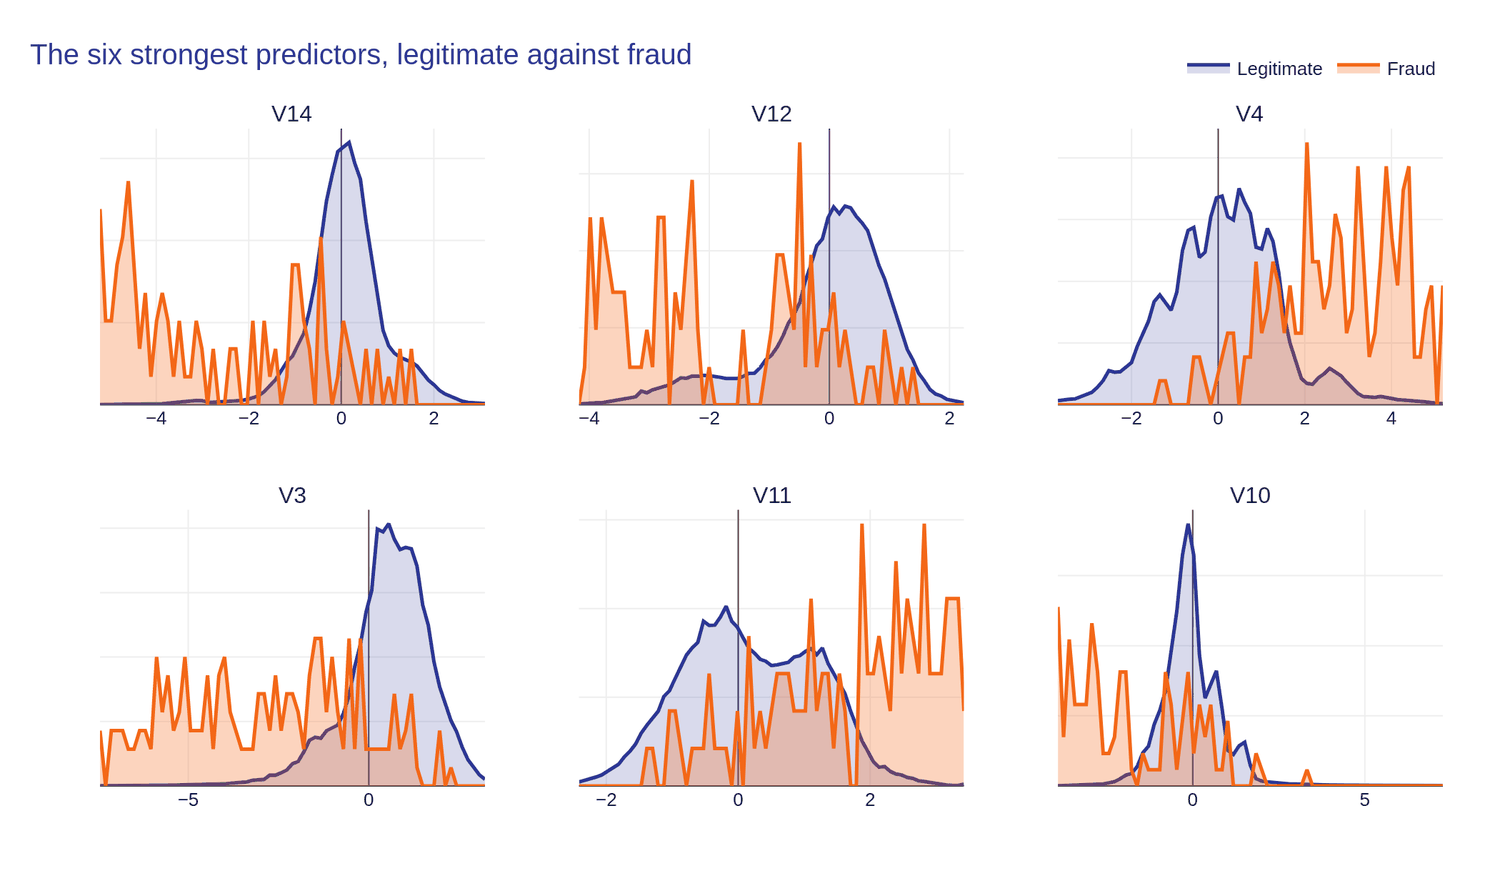

In [14]:
# ---------------------------------------------------------
# What the strongest predictors actually look like
# ---------------------------------------------------------
# Densities are computed with numpy rather than handing every raw value to the
# plotting library, which keeps the figure small enough to store in a notebook.
from plotly.subplots import make_subplots

fraud_mask = y_exploration.eq(1).to_numpy()

figure_rows, figure_columns = 2, 3

fig = make_subplots(
    rows=figure_rows,
    cols=figure_columns,
    subplot_titles=top_separating,
    horizontal_spacing=0.07,
    vertical_spacing=0.16,
)

for position, feature in enumerate(top_separating):
    row = position // figure_columns + 1
    column = position % figure_columns + 1

    values = train_df[feature].to_numpy()

    # Clip the display range so a handful of extremes do not flatten the shape
    low, high = np.percentile(values, [0.2, 99.8])
    bins = np.linspace(low, high, 70)
    centres = (bins[:-1] + bins[1:]) / 2

    for label, mask, colour in [
        ("Legitimate", ~fraud_mask, BRAND_BLUE),
        ("Fraud", fraud_mask, BRAND_ORANGE),
    ]:
        density, _ = np.histogram(values[mask], bins=bins, density=True)

        fig.add_trace(
            go.Scatter(
                x=centres,
                y=density,
                mode="lines",
                name=label,
                legendgroup=label,
                showlegend=(position == 0),
                line=dict(color=colour, width=2.5),
                fill="tozeroy",
                fillcolor=(
                    "rgba(44,54,150,0.18)"
                    if label == "Legitimate"
                    else "rgba(243,103,23,0.28)"
                ),
                hovertemplate=(
                    f"<b>{label}</b><br>{feature}: %{{x:.2f}}<br>"
                    "Density: %{y:.3f}<extra></extra>"
                ),
            ),
            row=row,
            col=column,
        )

fig.update_layout(
    title="The six strongest predictors, legitimate against fraud",
    template="house",
    height=620,
    legend=dict(orientation="h", yanchor="bottom", y=1.06, xanchor="right", x=1),
)

fig.update_yaxes(title_text=None, showticklabels=False)
fig.show()

Mean absolute correlation among V1 to V28: 0.0283
Strongest relationship anywhere: V2 and Amount, r = -0.547


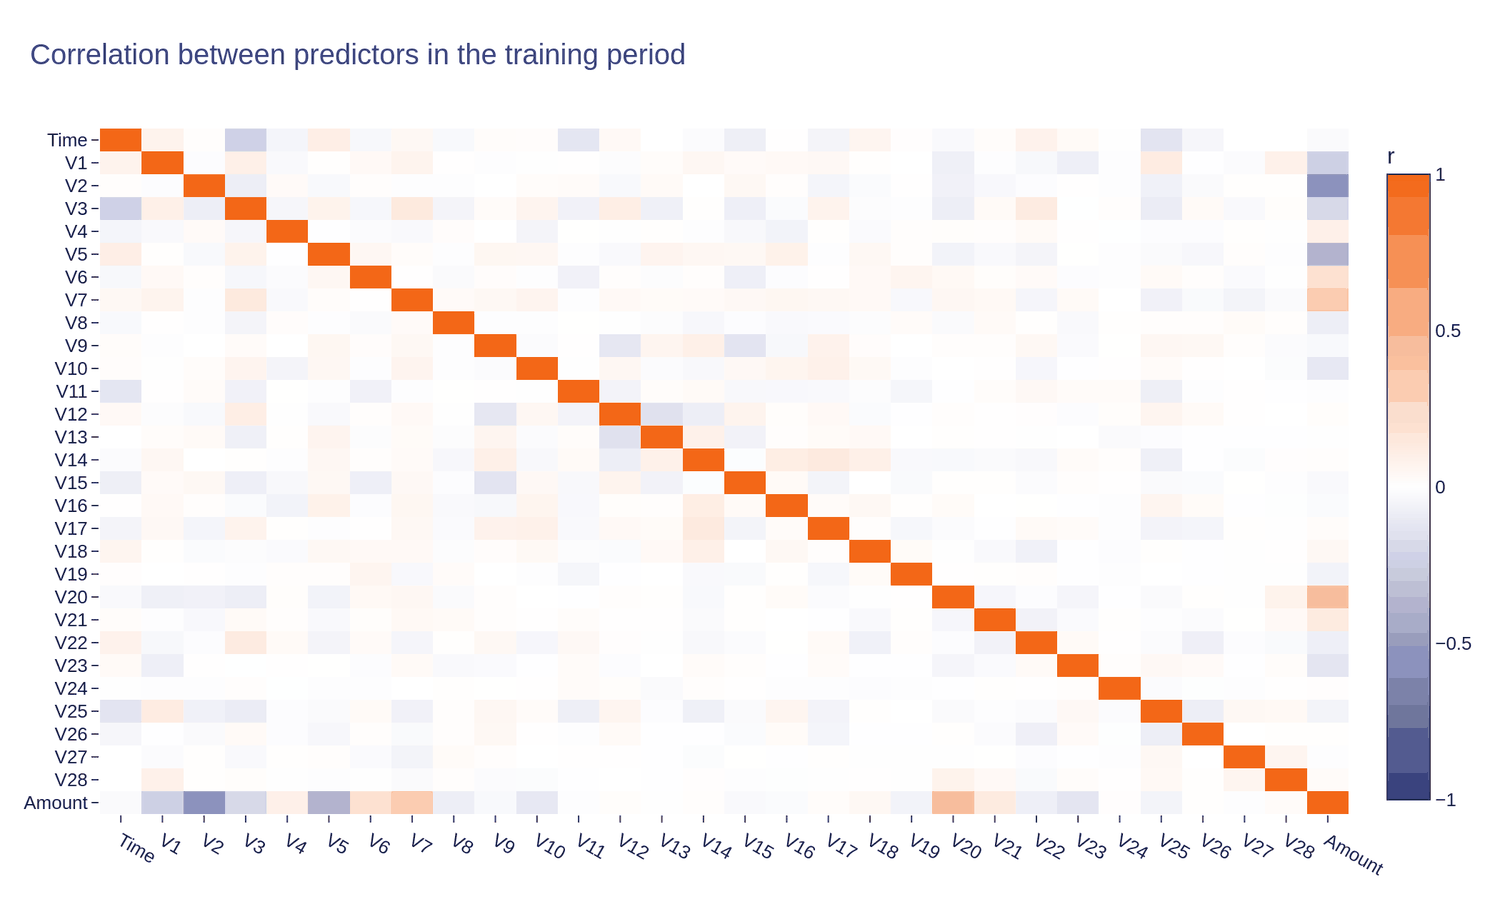

In [15]:
# ---------------------------------------------------------
# Are the predictors carrying separate information?
# ---------------------------------------------------------
correlations = train_df[exploration_features].corr()

off_diagonal = correlations.abs().to_numpy().copy()
np.fill_diagonal(off_diagonal, 0.0)

principal_components = [f"V{index}" for index in range(1, 29)]
component_block = correlations.loc[principal_components, principal_components].abs().to_numpy()
np.fill_diagonal(component_block, 0.0)

strongest = np.unravel_index(off_diagonal.argmax(), off_diagonal.shape)

print(
    f"Mean absolute correlation among V1 to V28: {component_block.mean():.4f}"
)
print(
    f"Strongest relationship anywhere: "
    f"{exploration_features[strongest[0]]} and {exploration_features[strongest[1]]}, "
    f"r = {correlations.to_numpy()[strongest]:+.3f}"
)

fig = px.imshow(
    correlations,
    color_continuous_scale=[BRAND_BLUE, "#FFFFFF", BRAND_ORANGE],
    zmin=-1,
    zmax=1,
    aspect="auto",
)

fig.update_traces(
    hovertemplate="<b>%{x} and %{y}</b><br>Correlation: %{z:+.3f}<extra></extra>"
)

fig = apply_house_style(
    fig,
    title="Correlation between predictors in the training period",
    x_title=None,
    y_title=None,
    show_legend=False,
)

fig.update_layout(height=640, coloraxis_colorbar=dict(title="r"))
fig.show()

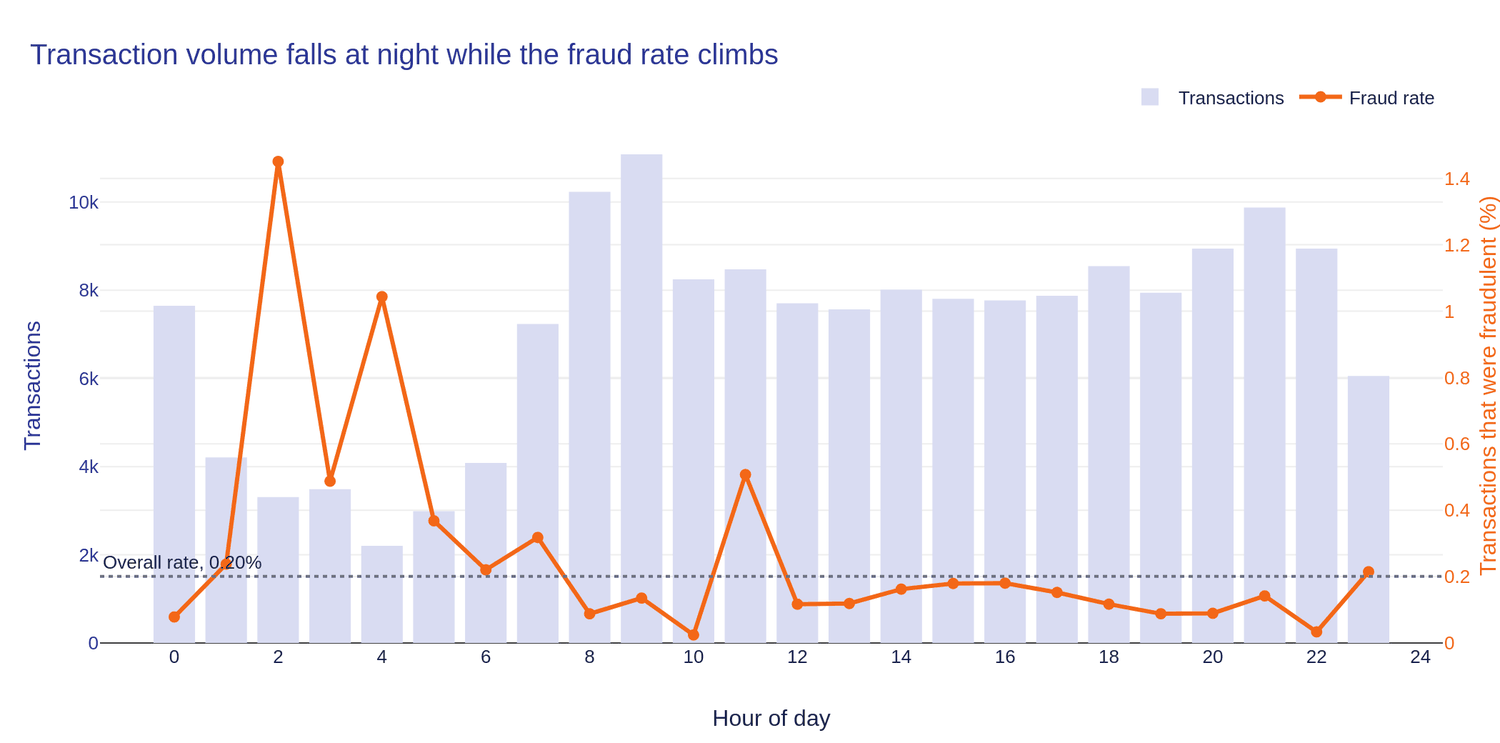

Between midnight and 06:00: 23,842 transactions (14.0% of volume) containing 115 frauds, a rate of 0.482%
Rest of the day:            146,393 transactions containing 227 frauds, a rate of 0.155%

Fraud is 3.1 times more likely at night.
Those six hours carry 33.6% of all fraud in the training period.

Transactions of exactly zero: 1,122, of which 14 are fraud, a rate of 1.248% against a baseline of 0.201% (6.2 times).


In [16]:
# ---------------------------------------------------------
# Does the time of day matter?
# ---------------------------------------------------------
hour_of_day = (train_df["Time"] % (24 * 3600)) // 3600

by_hour = (
    train_df.assign(Hour=hour_of_day)
    .groupby("Hour")
    .agg(Transactions=("Class", "size"), Fraud=("Class", "sum"))
    .reset_index()
)

by_hour["Fraud rate"] = by_hour["Fraud"] / by_hour["Transactions"] * 100

training_fraud_rate = y_exploration.mean() * 100

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=by_hour["Hour"],
        y=by_hour["Transactions"],
        name="Transactions",
        marker_color=BRAND_LIGHT_BLUE,
        hovertemplate=(
            "<b>%{x}:00</b><br>Transactions: %{y:,}<extra></extra>"
        ),
    )
)

fig.add_trace(
    go.Scatter(
        x=by_hour["Hour"],
        y=by_hour["Fraud rate"],
        name="Fraud rate",
        mode="lines+markers",
        yaxis="y2",
        line=dict(color=BRAND_ORANGE, width=3),
        marker=dict(size=8, color=BRAND_ORANGE),
        customdata=by_hour[["Fraud", "Transactions"]].to_numpy(),
        hovertemplate=(
            "<b>%{x}:00</b><br>Fraud rate: %{y:.3f}%<br>"
            "Fraud: %{customdata[0]} of %{customdata[1]:,}<extra></extra>"
        ),
    )
)

fig.add_hline(
    y=training_fraud_rate,
    line_dash="dot",
    line_color=BRAND_GREY,
    yref="y2",
    annotation_text=f"Overall rate, {training_fraud_rate:.2f}%",
    annotation_position="top left",
)

fig.update_layout(
    title="Transaction volume falls at night while the fraud rate climbs",
    xaxis=dict(title="Hour of day", dtick=2),
    yaxis=dict(
        title="Transactions",
        titlefont=dict(color=BRAND_BLUE),
        tickfont=dict(color=BRAND_BLUE),
    ),
    yaxis2=dict(
        title="Transactions that were fraudulent (%)",
        titlefont=dict(color=BRAND_ORANGE),
        tickfont=dict(color=BRAND_ORANGE),
        overlaying="y",
        side="right",
        rangemode="tozero",
    ),
    template="house",
    height=520,
)

fig.show()

# ---------------------------------------------------------
# Quantify the night effect and the zero-amount pattern
# ---------------------------------------------------------
is_night = hour_of_day.isin([0, 1, 2, 3, 4, 5])

night_rate = train_df.loc[is_night, "Class"].mean()
day_rate = train_df.loc[~is_night, "Class"].mean()

print(
    f"Between midnight and 06:00: {int(is_night.sum()):,} transactions "
    f"({is_night.mean():.1%} of volume) containing "
    f"{int(train_df.loc[is_night, 'Class'].sum())} frauds, a rate of {night_rate:.3%}"
)
print(
    f"Rest of the day:            {int((~is_night).sum()):,} transactions "
    f"containing {int(train_df.loc[~is_night, 'Class'].sum())} frauds, "
    f"a rate of {day_rate:.3%}"
)
print(f"\nFraud is {night_rate / day_rate:.1f} times more likely at night.")
print(
    f"Those six hours carry "
    f"{train_df.loc[is_night, 'Class'].sum() / train_df['Class'].sum():.1%} "
    "of all fraud in the training period."
)

zero_amount = train_df["Amount"].eq(0)

print(
    f"\nTransactions of exactly zero: {int(zero_amount.sum()):,}, "
    f"of which {int(train_df.loc[zero_amount, 'Class'].sum())} are fraud, "
    f"a rate of {train_df.loc[zero_amount, 'Class'].mean():.3%} against a "
    f"baseline of {y_exploration.mean():.3%} "
    f"({train_df.loc[zero_amount, 'Class'].mean() / y_exploration.mean():.1f} times)."
)

### What the predictors show

**Some individual features separate the classes remarkably well.** `V14` alone reaches a single-feature AUC of about 0.95 once its direction is accounted for, and `V12`, `V4` and `V11` are not far behind. This is why the problem is tractable at all despite the extreme imbalance: the signal is genuinely there, concentrated in a handful of components. It also explains why `V14` and `V12` dominated the model's reason codes later on. At the other end, features such as `V13`, `V25` and `V26` sit almost exactly at 0.50 and carry essentially no information on their own. The fraud outline is visibly jagged in every panel. That is a sample-size effect and not structure: 342 fraud cases spread over seventy bins leaves roughly five per bin, so the position of the orange mass is meaningful while the wiggles in it are not. The same caution applied to the transaction-amount histogram earlier.

**The predictors are close to independent.** The mean absolute correlation among `V1` to `V28` is around 0.03, which is expected: they are principal components, and the transformation that produced them makes them orthogonal by construction. Two practical consequences follow. Multicollinearity is not a concern for the logistic-regression benchmark, and there is little redundancy for a feature-selection step to exploit, since almost every component carries information nothing else carries. The strongest relationship anywhere involves `Amount`, which was not part of the transformation.

**Fraud follows the clock, and strongly.** Transaction volume collapses overnight while the number of frauds does not, so the fraud rate inverts: the small hours run at roughly three times the daytime rate, and the worst single hour is around sixty times the quietest. Six hours of the night hold about a third of all the fraud in the training period. The reading is straightforward, and matches how card fraud is usually described: stolen credentials get used while the cardholder is asleep and while the surrounding traffic is thin.

**Transactions of exactly zero are disproportionately fraudulent**, at around six times the baseline rate. A zero-value authorisation is how a card is tested to see whether it is still live, before anything is actually bought. It is a small group and it should not be turned into a rule on its own, but it is a recognisable pattern rather than a quirk of the data.

### A caution that the rest of the notebook depends on

The daily cycle above is the strongest, clearest pattern in this section, and it is the obvious reason to encode time cyclically, which is exactly what `TimeSin` and `TimeCos` were built to do earlier.

The ablation and stability analysis that follow will find that those features do not improve out-of-time performance, and that removing `TimeSin` actually helps.

Both things are true at once, and the tension is the point. A strong marginal association does not guarantee incremental predictive value once other features are present. The principal components already carry much of what time of day encodes, so adding an explicit cycle mostly adds a way to overfit one period. This is the same distinction that separates feature importance from feature contribution, and it is the reason contribution is measured by removing features and re-testing rather than by reading coefficients.

It also sets a limit on the fairness analysis much later. The daily cycle is real and large, but the chronological split means each evaluation period covers only part of a day, so a disparity in how customers are treated by time of day cannot be estimated from these windows. That is a limitation of a two-day sample, not a reason to ignore the effect.

## Outlier assessment

Extreme observations can influence model training, particularly for linear models that rely on scaled numerical inputs. However, in fraud detection, unusual transactions may contain genuine predictive signal rather than represent data errors.

I therefore do not remove outliers automatically. Instead, I assess:

1. how many observations fall outside robust univariate bounds;
2. whether extreme values are disproportionately associated with fraud;
3. whether the most extreme training observations improve or harm out-of-time validation performance.

The analysis uses robust interquartile-range bounds fitted on the training period only. Validation and test observations are assessed against those training-derived bounds, preventing future information from influencing the definition of an outlier.

Because `V1` through `V28` are anonymised principal components, an extreme value cannot be interpreted directly as erroneous. Any treatment of outliers must therefore be justified through validation performance rather than visual appearance alone.

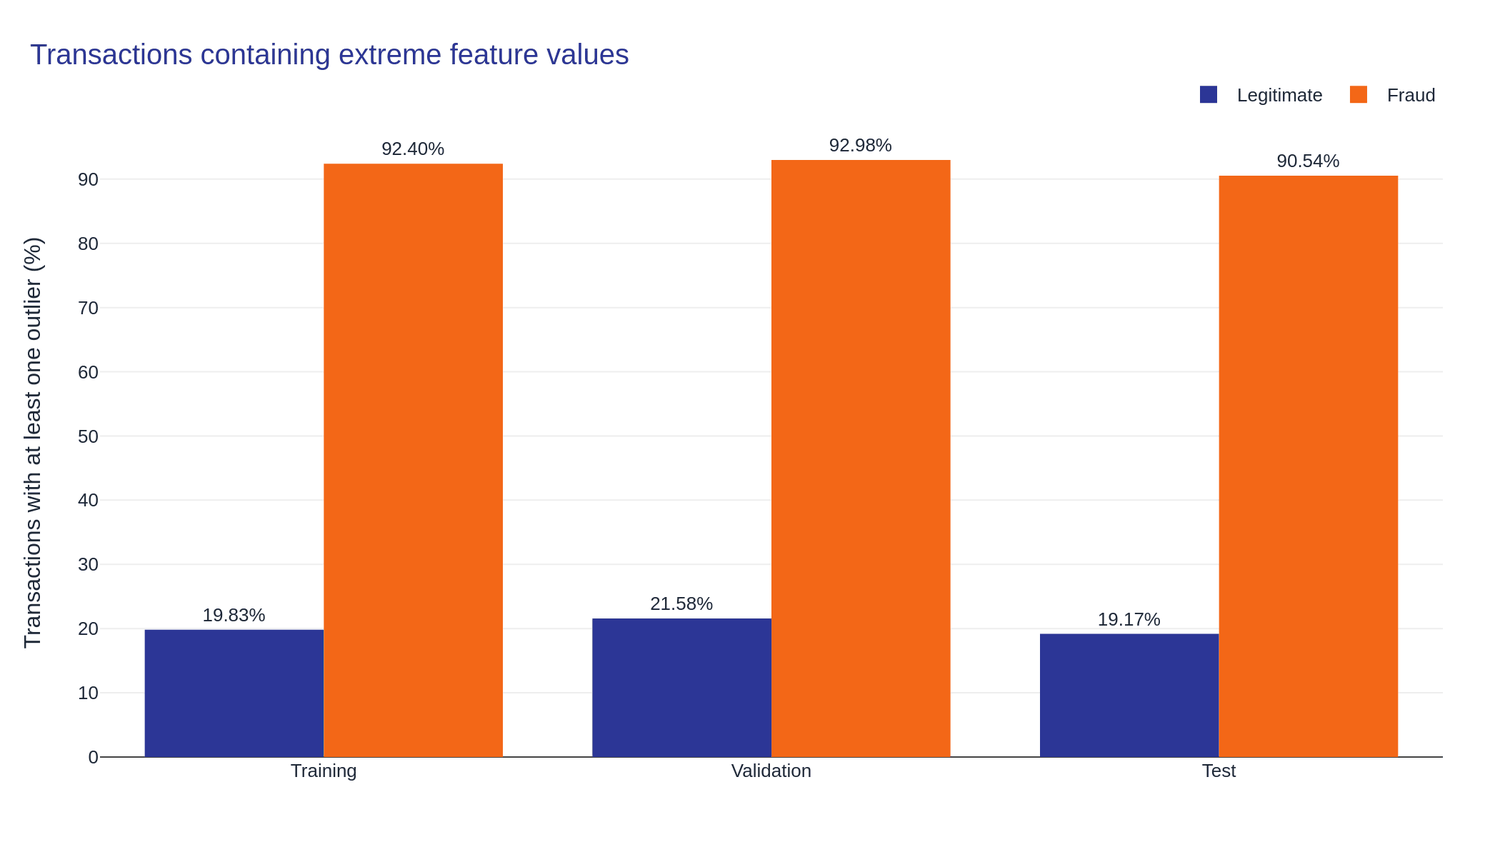

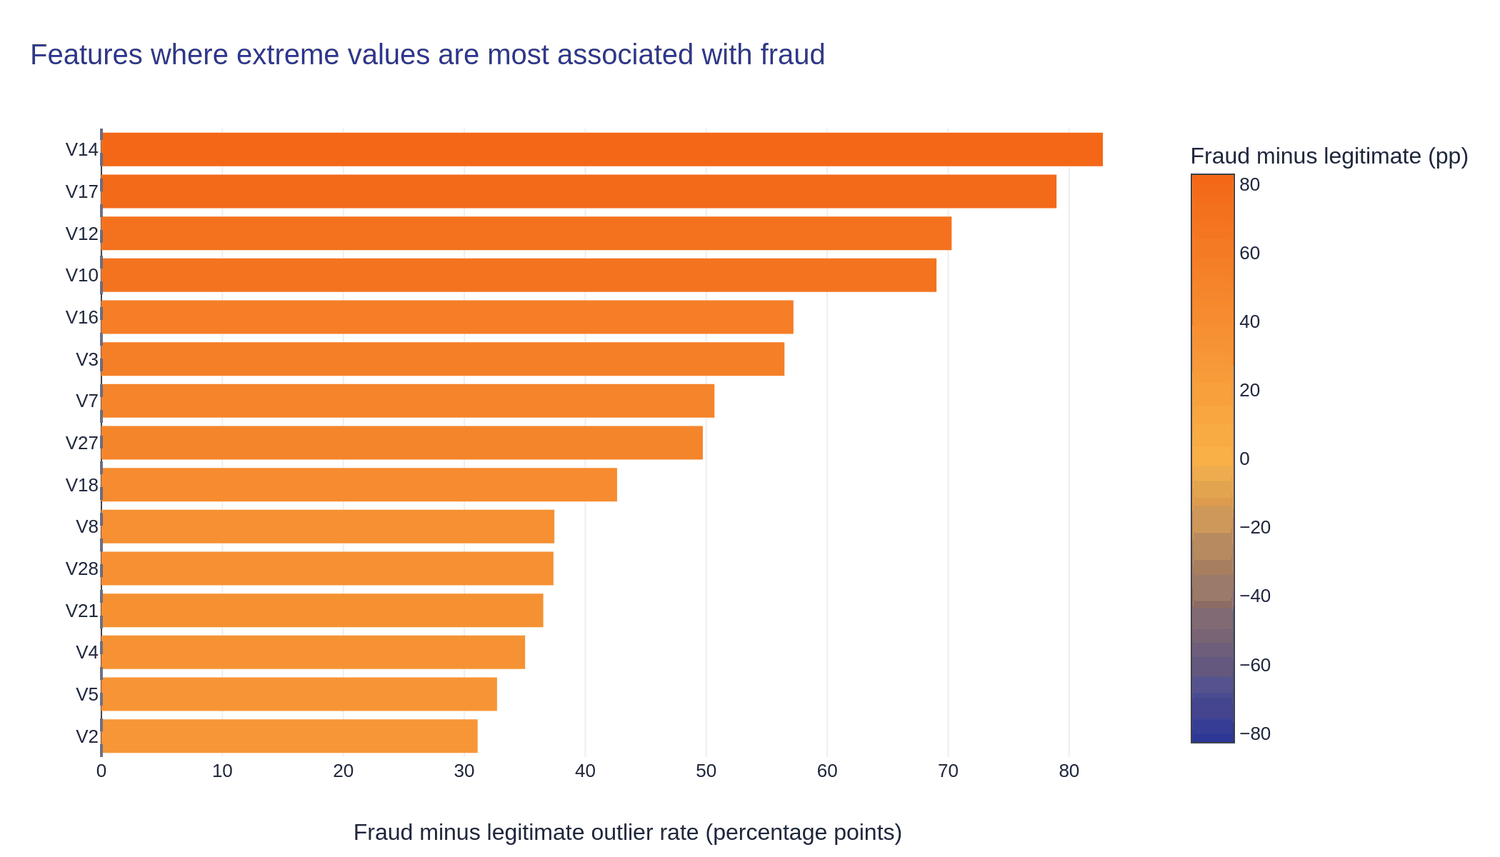

In [17]:
# Assess outliers using training-derived IQR bounds
outlier_feature_columns = [
    column
    for column in train_df.columns
    if column != "Class"
]

Q1 = train_df[outlier_feature_columns].quantile(0.25)
Q3 = train_df[outlier_feature_columns].quantile(0.75)
IQR = Q3 - Q1

# Wider than the conventional 1.5 × IQR rule because fraud data
# is expected to contain legitimate extremes.
IQR_MULTIPLIER = 3.0

lower_bounds = Q1 - IQR_MULTIPLIER * IQR
upper_bounds = Q3 + IQR_MULTIPLIER * IQR


def calculate_outlier_flags(data, features, lower, upper):
    """Return cell-level and row-level outlier flags."""
    cell_flags = (
        data[features].lt(lower, axis="columns")
        | data[features].gt(upper, axis="columns")
    )

    row_summary = pd.DataFrame(
        {
            "Outlier feature count": cell_flags.sum(axis=1),
            "Any outlier": cell_flags.any(axis=1),
        },
        index=data.index,
    )

    return cell_flags, row_summary


train_outlier_cells, train_outlier_rows = calculate_outlier_flags(
    train_df,
    outlier_feature_columns,
    lower_bounds,
    upper_bounds,
)

validation_outlier_cells, validation_outlier_rows = (
    calculate_outlier_flags(
        validation_df,
        outlier_feature_columns,
        lower_bounds,
        upper_bounds,
    )
)

test_outlier_cells, test_outlier_rows = calculate_outlier_flags(
    test_df,
    outlier_feature_columns,
    lower_bounds,
    upper_bounds,
)

outlier_summary = []

for split_name, split_data, row_flags in [
    ("Training", train_df, train_outlier_rows),
    ("Validation", validation_df, validation_outlier_rows),
    ("Test", test_df, test_outlier_rows),
]:
    fraud_mask = split_data["Class"].eq(1)
    legitimate_mask = split_data["Class"].eq(0)

    outlier_summary.append(
        {
            "Split": split_name,
            "Transactions": len(split_data),
            "Any outlier (%)": (
                row_flags["Any outlier"].mean() * 100
            ),
            "Legitimate with outlier (%)": (
                row_flags.loc[
                    legitimate_mask,
                    "Any outlier",
                ].mean()
                * 100
            ),
            "Fraud with outlier (%)": (
                row_flags.loc[
                    fraud_mask,
                    "Any outlier",
                ].mean()
                * 100
            ),
            "Median outlying features": (
                row_flags["Outlier feature count"].median()
            ),
            "Maximum outlying features": (
                row_flags["Outlier feature count"].max()
            ),
        }
    )

outlier_summary = pd.DataFrame(outlier_summary)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=outlier_summary["Split"],
        y=outlier_summary["Legitimate with outlier (%)"],
        name="Legitimate",
        marker_color=BRAND_BLUE,
        text=outlier_summary[
            "Legitimate with outlier (%)"
        ],
        texttemplate="%{text:.2f}%",
        textposition="outside",
    )
)

fig.add_trace(
    go.Bar(
        x=outlier_summary["Split"],
        y=outlier_summary["Fraud with outlier (%)"],
        name="Fraud",
        marker_color=BRAND_ORANGE,
        text=outlier_summary[
            "Fraud with outlier (%)"
        ],
        texttemplate="%{text:.2f}%",
        textposition="outside",
    )
)

fig.update_layout(barmode="group")

fig = apply_house_style(
    fig,
    title="Transactions containing extreme feature values",
    x_title=None,
    y_title="Transactions with at least one outlier (%)",
    show_legend=True,
)

fig.show()


feature_outlier_rates = pd.DataFrame(
    {
        "Feature": outlier_feature_columns,
        "Training outlier rate (%)": (
            train_outlier_cells.mean().to_numpy() * 100
        ),
        "Fraud outlier rate (%)": [
            train_outlier_cells.loc[
                train_df["Class"].eq(1),
                feature,
            ].mean()
            * 100
            for feature in outlier_feature_columns
        ],
        "Legitimate outlier rate (%)": [
            train_outlier_cells.loc[
                train_df["Class"].eq(0),
                feature,
            ].mean()
            * 100
            for feature in outlier_feature_columns
        ],
    }
)

feature_outlier_rates["Fraud minus legitimate (pp)"] = (
    feature_outlier_rates["Fraud outlier rate (%)"]
    - feature_outlier_rates["Legitimate outlier rate (%)"]
)

feature_outlier_rates = (
    feature_outlier_rates
    .sort_values(
        "Fraud minus legitimate (pp)",
        ascending=False,
    )
    .head(15)
    .sort_values(
        "Fraud minus legitimate (pp)",
        ascending=True,
    )
)

fig = px.bar(
    feature_outlier_rates,
    x="Fraud minus legitimate (pp)",
    y="Feature",
    orientation="h",
    color="Fraud minus legitimate (pp)",
    color_continuous_scale=[
        BRAND_BLUE,
        BRAND_LIGHT_ORANGE,
        BRAND_ORANGE,
    ],
    color_continuous_midpoint=0,
    custom_data=[
        "Fraud outlier rate (%)",
        "Legitimate outlier rate (%)",
        "Training outlier rate (%)",
    ],
)

fig.add_vline(
    x=0,
    line_dash="dash",
    line_color=BRAND_GREY,
)

fig.update_traces(
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Difference: %{x:+.2f} percentage points<br>"
        "Fraud outlier rate: %{customdata[0]:.2f}%<br>"
        "Legitimate outlier rate: %{customdata[1]:.2f}%<br>"
        "Overall training rate: %{customdata[2]:.2f}%"
        "<extra></extra>"
    )
)

fig = apply_house_style(
    fig,
    title="Features where extreme values are most associated with fraud",
    x_title="Fraud minus legitimate outlier rate (percentage points)",
    y_title=None,
    show_legend=False,
)

fig.show()

### Outlier findings

Extreme values are far more common among fraudulent transactions than among legitimate transactions. More than 90% of fraud cases contain at least one feature outside the training-derived robust bounds, compared with approximately 20% of legitimate transactions.

This suggests that extreme observations often contain useful fraud signal rather than obvious data errors. I therefore do not remove or winsorise outliers at this stage.

For linear models, I will later compare standard scaling with robust scaling. Tree-based models will initially retain the original values.

## Evaluation framework

Before fitting any models, I define a consistent evaluation framework.

The objective is not simply to maximise the number of correct classifications. A useful fraud-risk model must detect a meaningful share of fraudulent transactions while limiting unnecessary alerts involving legitimate transactions.

I will evaluate models at two levels:

1. **Ranking quality**, which measures whether fraudulent transactions receive higher risk scores than legitimate transactions.
2. **Decision quality**, which measures what happens after a threshold converts those scores into investigation alerts.

The primary ranking metric will be average precision because it is better suited to extreme class imbalance than ordinary accuracy. ROC-AUC will be reported as a secondary measure, but it will not determine the preferred model by itself.

Threshold-dependent evaluation will include fraud precision, fraud recall, F1-score, balanced accuracy, absolute false-positive and false-negative counts, and the number of alerts generated. Later, thresholds will be compared using statistical and operational criteria rather than assuming that 0.50 is automatically appropriate.

In [18]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
)


def evaluate_probability_scores(
    y_true,
    y_score,
):
    """
    Evaluate model ranking performance using probability or risk scores.

    Parameters
    ----------
    y_true : array-like
        True binary transaction labels.
    y_score : array-like
        Predicted fraud probabilities or continuous fraud-risk scores.

    Returns
    -------
    dict
        Ranking metrics that do not require a classification threshold.
    """
    return {
        "Average precision": average_precision_score(
            y_true,
            y_score,
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            y_score,
        ),
    }


def evaluate_at_threshold(
    y_true,
    y_score,
    threshold,
):
    """
    Evaluate binary investigation alerts at a selected threshold.
    """
    y_pred = (np.asarray(y_score) >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
    ).ravel()

    alerts = tp + fp

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "F1-score": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "True positives": tp,
        "False positives": fp,
        "True negatives": tn,
        "False negatives": fn,
        "Alerts": alerts,
        "False alerts per detected fraud": (
            fp / tp if tp > 0 else np.inf
        ),
    }

## Interpretable modelling baseline

I begin with logistic regression as an interpretable supervised baseline.

This model is useful because it produces continuous fraud-risk probabilities and provides a transparent reference point for more flexible models. However, logistic regression is sensitive to feature scale. `Time` and `Amount` are measured on very different scales, while the anonymised PCA components are already transformed.

All preprocessing is therefore placed inside a scikit-learn pipeline. The scaler is fitted only on the training data, which prevents information from the validation and test periods from influencing model training.

I compare two logistic-regression variants:

1. A conventional model without class weighting.
2. A class-weighted model that gives greater importance to the rare fraud class.

The models are compared on the validation set using average precision and ROC-AUC. Accuracy is included only as supporting information and is not used to select the preferred model.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Separate predictors and target
feature_columns = [
    column
    for column in analysis_df.columns
    if column != "Class"
]

X_train = train_df[feature_columns]
y_train = train_df["Class"]

X_validation = validation_df[feature_columns]
y_validation = validation_df["Class"]

X_test = test_df[feature_columns]
y_test = test_df["Class"]

# Time and Amount require explicit scaling.
# The PCA-derived variables are also included in the same numeric pipeline
# for consistency.
numeric_features = feature_columns

numeric_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_preprocessor,
            numeric_features,
        )
    ],
    remainder="drop",
)

logistic_models = {
    "Logistic regression": LogisticRegression(
        max_iter=2_000,
        random_state=RANDOM_STATE,
    ),
    "Class-weighted logistic regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2_000,
        random_state=RANDOM_STATE,
    ),
}

fitted_logistic_models = {}
logistic_validation_results = []

for model_name, estimator in logistic_models.items():
    pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor,
            ),
            (
                "model",
                estimator,
            ),
        ]
    )

    pipeline.fit(
        X_train,
        y_train,
    )

    validation_scores = pipeline.predict_proba(
        X_validation
    )[:, 1]

    ranking_metrics = evaluate_probability_scores(
        y_validation,
        validation_scores,
    )

    default_threshold_metrics = evaluate_at_threshold(
        y_validation,
        validation_scores,
        threshold=0.50,
    )

    logistic_validation_results.append(
        {
            "Model": model_name,
            **ranking_metrics,
            "Precision at 0.50": (
                default_threshold_metrics["Precision"]
            ),
            "Recall at 0.50": (
                default_threshold_metrics["Recall"]
            ),
            "F1-score at 0.50": (
                default_threshold_metrics["F1-score"]
            ),
            "Alerts at 0.50": (
                default_threshold_metrics["Alerts"]
            ),
            "False positives at 0.50": (
                default_threshold_metrics["False positives"]
            ),
            "False negatives at 0.50": (
                default_threshold_metrics["False negatives"]
            ),
        }
    )

    fitted_logistic_models[model_name] = pipeline

logistic_validation_results = pd.DataFrame(
    logistic_validation_results
).sort_values(
    "Average precision",
    ascending=False,
).reset_index(drop=True)

display(
    logistic_validation_results.style.format(
        {
            "Average precision": "{:.4f}",
            "ROC-AUC": "{:.4f}",
            "Precision at 0.50": "{:.4f}",
            "Recall at 0.50": "{:.4f}",
            "F1-score at 0.50": "{:.4f}",
            "Alerts at 0.50": "{:,.0f}",
            "False positives at 0.50": "{:,.0f}",
            "False negatives at 0.50": "{:,.0f}",
        }
    )
)

,Model,Average precision,ROC-AUC,Precision at 0.50,Recall at 0.50,F1-score at 0.50,Alerts at 0.50,False positives at 0.50,False negatives at 0.50
0,Class-weighted logistic regression,0.7727,0.9709,0.0257,0.8947,0.0500,"1,984","1,933",6
1,Logistic regression,0.6424,0.9681,0.6279,0.4737,0.5400,43,16,30


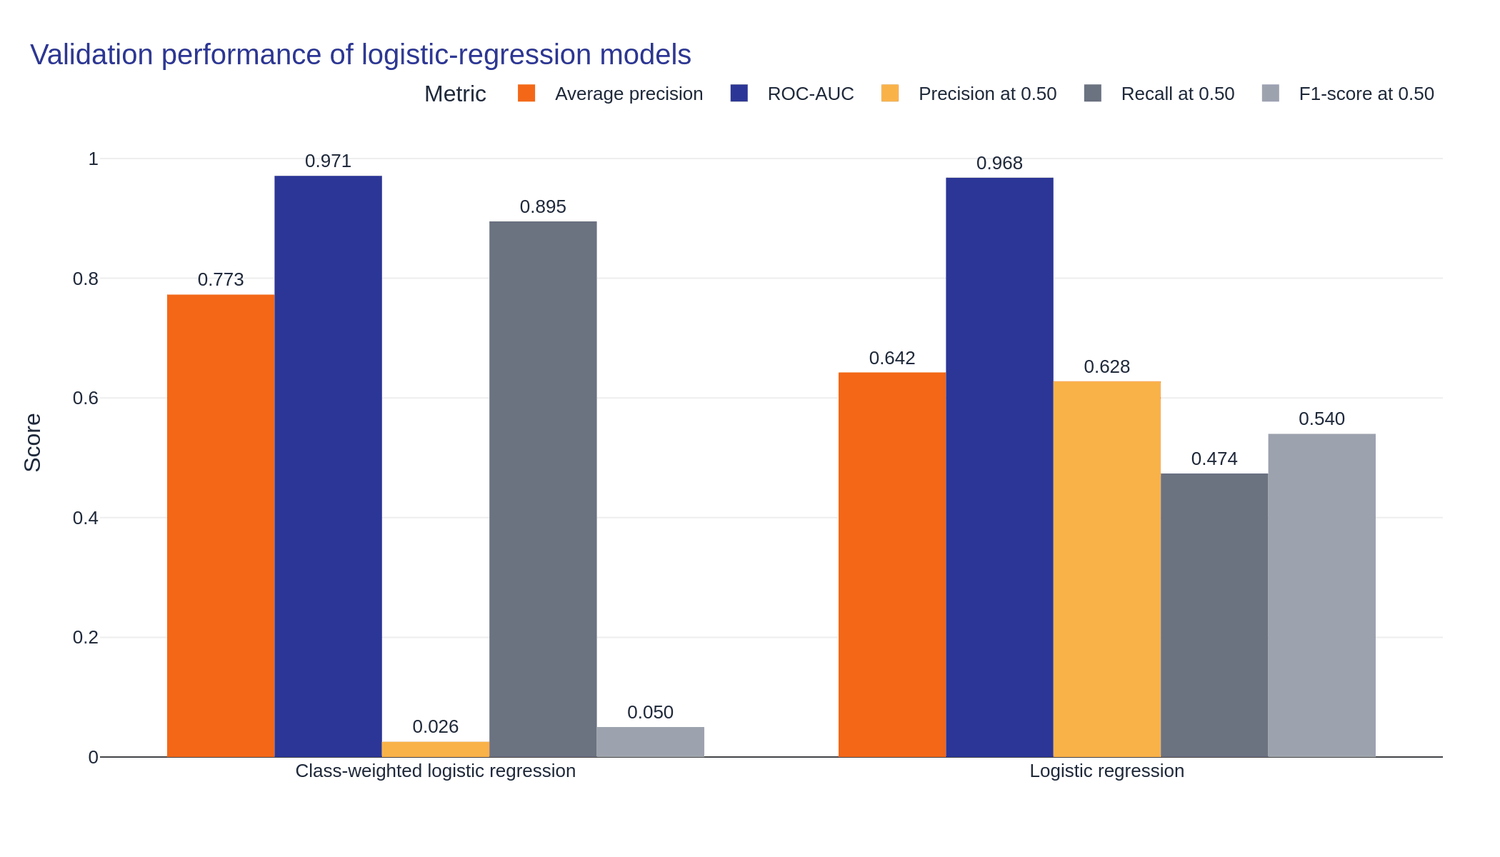

In [20]:
logistic_plot_df = logistic_validation_results.melt(
    id_vars="Model",
    value_vars=[
        "Average precision",
        "ROC-AUC",
        "Precision at 0.50",
        "Recall at 0.50",
        "F1-score at 0.50",
    ],
    var_name="Metric",
    value_name="Score",
)

metric_colours = {
    "Average precision": BRAND_ORANGE,
    "ROC-AUC": BRAND_BLUE,
    "Precision at 0.50": BRAND_LIGHT_ORANGE,
    "Recall at 0.50": "#6B7280",
    "F1-score at 0.50": "#9CA3AF",
}

fig = px.bar(
    logistic_plot_df,
    x="Model",
    y="Score",
    color="Metric",
    barmode="group",
    text="Score",
    color_discrete_map=metric_colours,
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{x}</b><br>"
        "%{fullData.name}: %{y:.4f}"
        "<extra></extra>"
    ),
)

fig = apply_house_style(
    fig,
    title="Validation performance of logistic-regression models",
    x_title=None,
    y_title="Score",
    show_legend=True,
)

fig.update_yaxes(range=[0, 1.05])

fig.show()

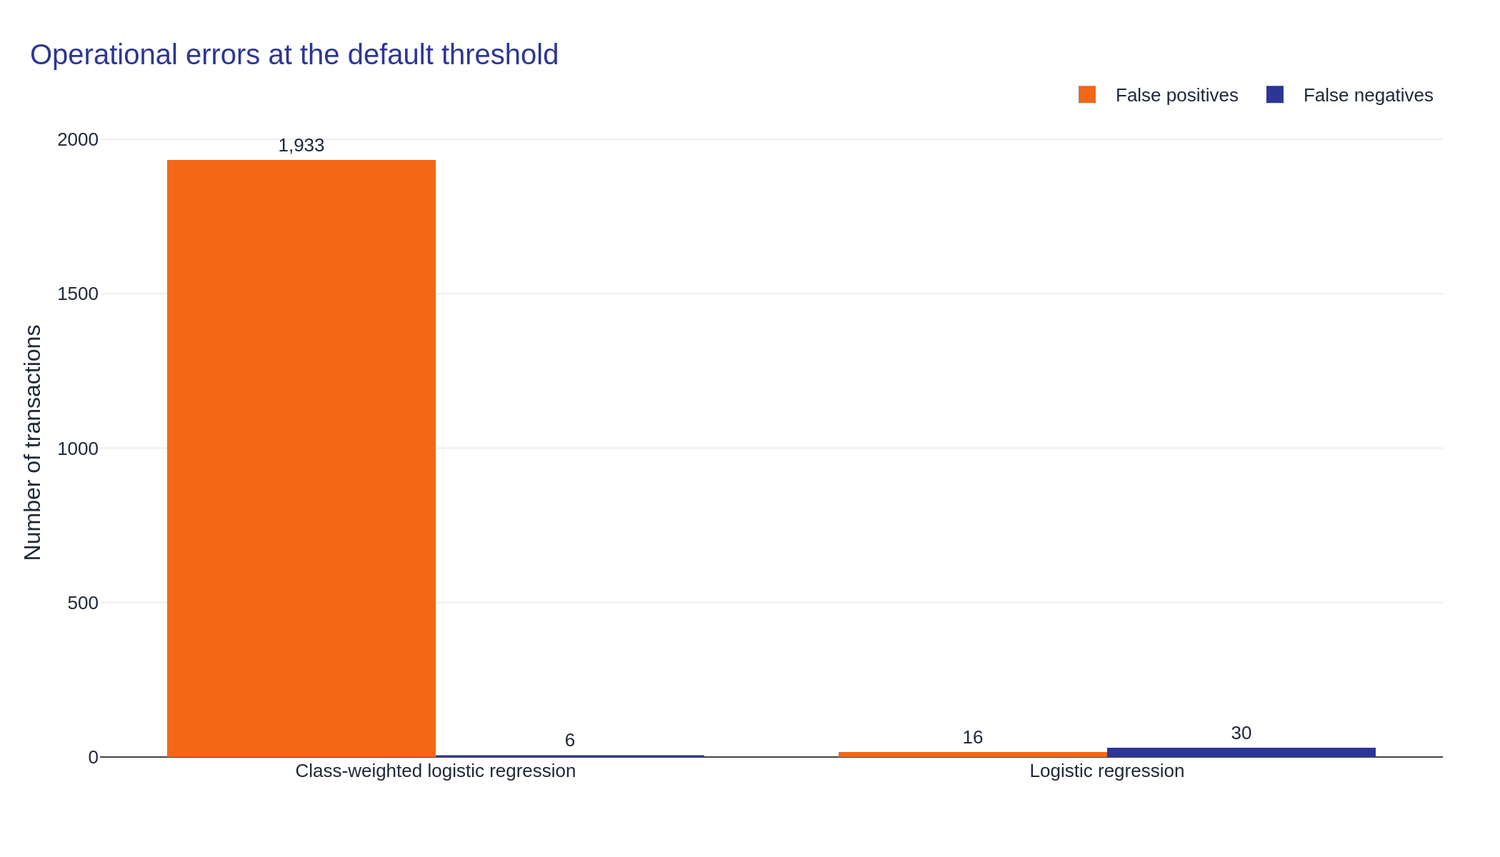

In [21]:
operational_plot_df = logistic_validation_results.copy()

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=operational_plot_df["Model"],
        y=operational_plot_df["False positives at 0.50"],
        name="False positives",
        marker_color=BRAND_ORANGE,
        text=operational_plot_df["False positives at 0.50"],
        texttemplate="%{text:,}",
        textposition="outside",
        hovertemplate=(
            "<b>%{x}</b><br>"
            "False positives: %{y:,}"
            "<extra></extra>"
        ),
    )
)

fig.add_trace(
    go.Bar(
        x=operational_plot_df["Model"],
        y=operational_plot_df["False negatives at 0.50"],
        name="False negatives",
        marker_color=BRAND_BLUE,
        text=operational_plot_df["False negatives at 0.50"],
        texttemplate="%{text:,}",
        textposition="outside",
        hovertemplate=(
            "<b>%{x}</b><br>"
            "False negatives: %{y:,}"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(barmode="group")

fig = apply_house_style(
    fig,
    title="Operational errors at the default threshold",
    x_title=None,
    y_title="Number of transactions",
    show_legend=True,
)

fig.show()

### Logistic-regression comparison

The first figure compares ranking quality with performance at the default threshold of 0.50. Average precision is the most important ranking metric because it focuses on the rare fraud class.

The second figure shows the operational consequences more directly. False positives represent legitimate transactions that would be sent for unnecessary investigation, while false negatives represent fraudulent transactions that would remain undetected.

A model should therefore not be selected based on one score alone. A higher recall may be useful, but only when the resulting increase in false alerts remains operationally acceptable.

## Logistic-regression ranking and workload trade-offs

The default probability threshold of 0.50 produces very different outcomes for the two logistic-regression models.

The class-weighted model detects most fraudulent transactions, but it also generates almost two thousand false alerts in the validation period. The unweighted model produces far fewer unnecessary alerts, but misses more than half of the fraud cases.

This does not necessarily mean that one model is inherently better. The comparison is currently tied to a threshold of 0.50, which has no special operational meaning in this problem. Class weighting also changes the scale of the resulting probability estimates, making a direct comparison at the same threshold potentially misleading.

I therefore compare the models across their full ranking and workload trade-offs. Final threshold selection is postponed until all candidate models, calibration methods and ensembles have been evaluated.

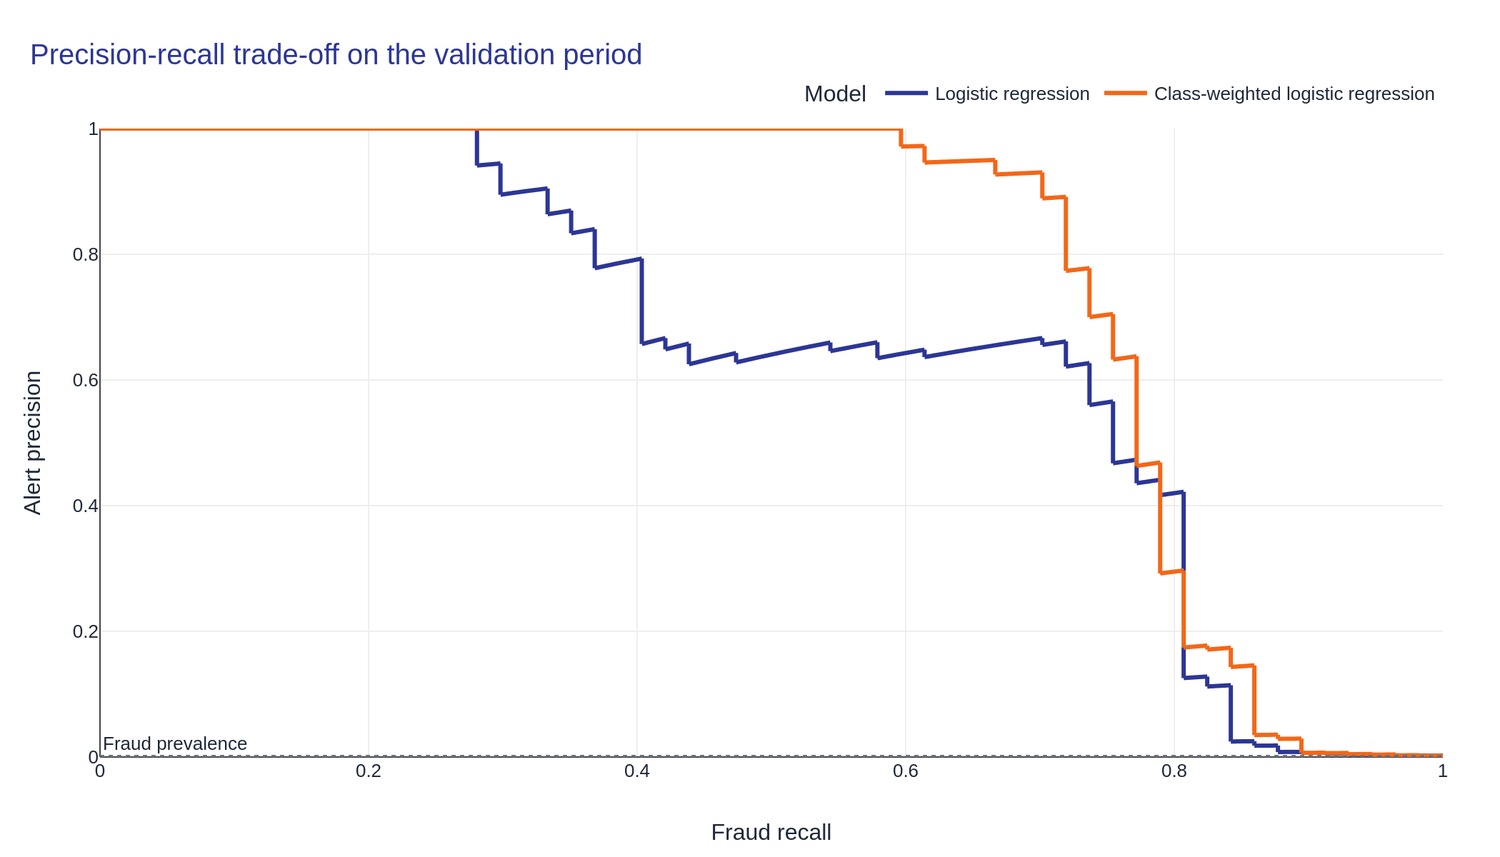

In [22]:
precision_recall_data = []

for model_name, model in fitted_logistic_models.items():
    validation_scores = model.predict_proba(X_validation)[:, 1]

    precision_values, recall_values, thresholds = precision_recall_curve(
        y_validation,
        validation_scores,
    )

    curve_data = pd.DataFrame(
        {
            "Model": model_name,
            "Precision": precision_values,
            "Recall": recall_values,
        }
    )

    precision_recall_data.append(curve_data)

precision_recall_data = pd.concat(
    precision_recall_data,
    ignore_index=True,
)

fig = px.line(
    precision_recall_data,
    x="Recall",
    y="Precision",
    color="Model",
    color_discrete_map={
        "Logistic regression": BRAND_BLUE,
        "Class-weighted logistic regression": BRAND_ORANGE,
    },
)

fig.update_traces(
    line=dict(width=3),
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Recall: %{x:.3f}<br>"
        "Precision: %{y:.3f}"
        "<extra></extra>"
    ),
)

fig.add_hline(
    y=y_validation.mean(),
    line_dash="dot",
    line_color=BRAND_GREY,
    annotation_text="Fraud prevalence",
    annotation_position="top left",
)

fig = apply_house_style(
    fig,
    title="Precision-recall trade-off on the validation period",
    x_title="Fraud recall",
    y_title="Alert precision",
    show_legend=True,
)

fig.update_xaxes(range=[0, 1])
fig.update_yaxes(range=[0, 1])

fig.show()

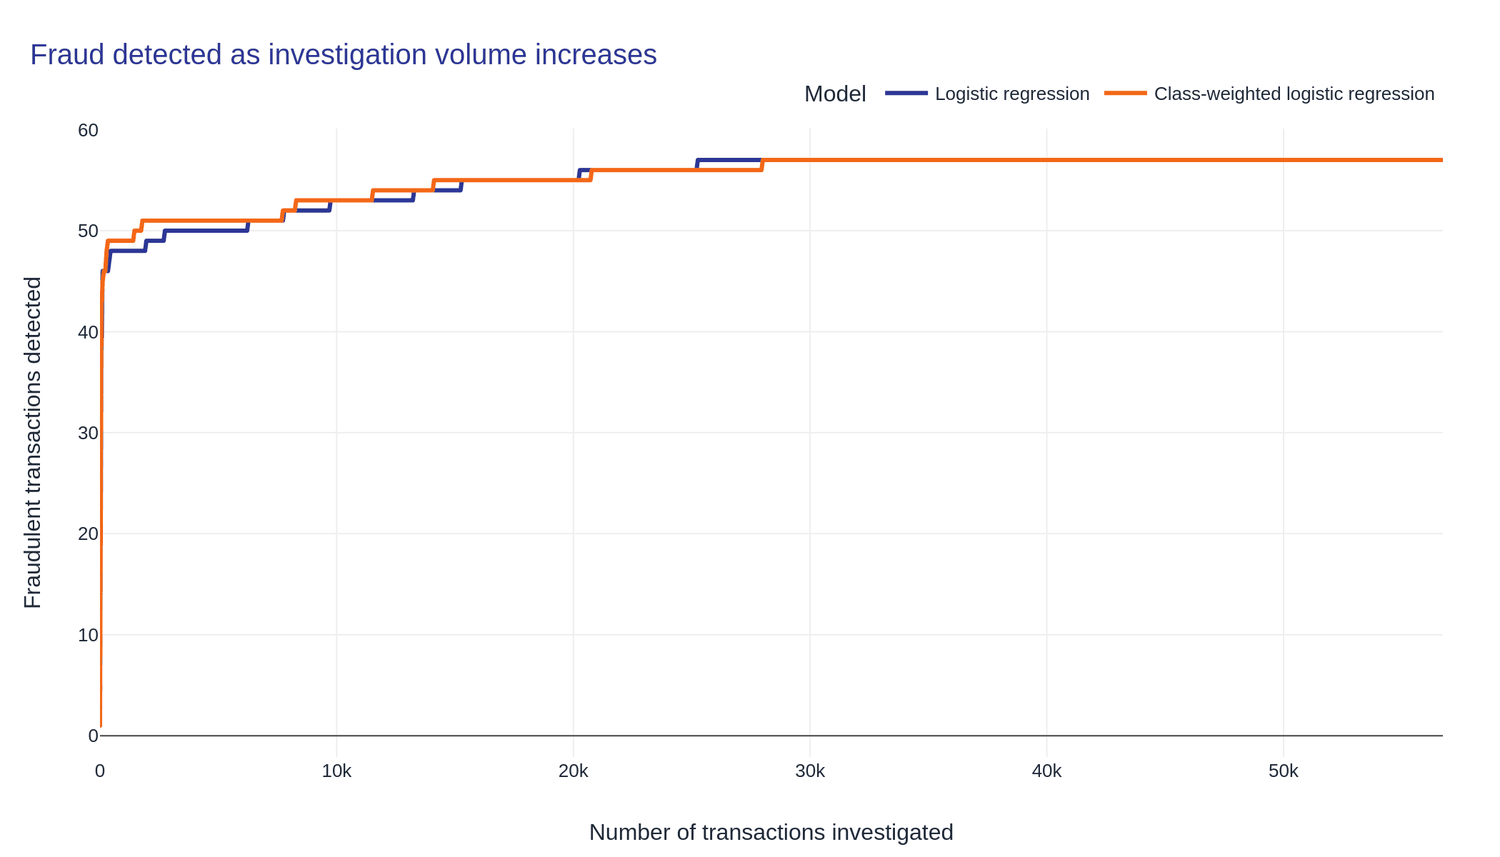

In [23]:
operating_curve_data = []

for model_name, model in fitted_logistic_models.items():
    validation_scores = model.predict_proba(X_validation)[:, 1]

    ranked_indices = np.argsort(validation_scores)[::-1]
    ranked_labels = y_validation.iloc[ranked_indices].to_numpy()

    cumulative_fraud = np.cumsum(ranked_labels)
    alert_count = np.arange(1, len(ranked_labels) + 1)

    step = max(1, len(alert_count) // 1_000)

    curve_data = pd.DataFrame(
        {
            "Model": model_name,
            "Alerts": alert_count[::step],
            "Fraud detected": cumulative_fraud[::step],
        }
    )

    operating_curve_data.append(curve_data)

operating_curve_data = pd.concat(
    operating_curve_data,
    ignore_index=True,
)

fig = px.line(
    operating_curve_data,
    x="Alerts",
    y="Fraud detected",
    color="Model",
    color_discrete_map={
        "Logistic regression": BRAND_BLUE,
        "Class-weighted logistic regression": BRAND_ORANGE,
    },
)

fig.update_traces(
    line=dict(width=3),
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Alerts: %{x:,}<br>"
        "Fraud detected: %{y:,}"
        "<extra></extra>"
    ),
)

fig = apply_house_style(
    fig,
    title="Fraud detected as investigation volume increases",
    x_title="Number of transactions investigated",
    y_title="Fraudulent transactions detected",
    show_legend=True,
)

fig.show()

### Model trade-offs under limited investigation capacity

The precision-recall analysis shows how alert quality changes as more fraudulent transactions are detected. The investigation-volume curve expresses the same trade-off in more operational terms: how many fraud cases are found as the number of reviewed transactions increases.

Both logistic-regression models identify most of the fraud cases relatively early in the ranking. The first few thousand investigated transactions already contain the large majority of the 57 fraud cases in the validation period. Beyond that point, the curves flatten considerably, meaning that a much larger investigation workload produces only a small number of additional fraud detections.

The two models also produce very similar rankings. Class weighting changes the scale of the predicted probabilities and therefore has a large effect at a fixed threshold such as 0.50, but it does not fundamentally transform which transactions are ranked highest.

This is an important distinction. The operational question is not which model produces the highest probabilities. It is which model places the most fraud near the top of the ranked alert list while limiting unnecessary investigation.

Threshold selection is therefore postponed until the stronger candidate models, feature-engineered variants and calibrated ensemble have also been evaluated. Named operating points such as Youden's J, maximum F2 and fixed alert budgets will be compared only after the final candidate models have been established.

## Feature engineering

The anonymised variables `V1` through `V28` are principal components, so their original business meaning is unavailable. I therefore avoid creating arbitrary interactions between them.

The original `Amount` and `Time` variables do allow a small number of defensible transformations:

1. `LogAmount` reduces the strong right skew in transaction amounts while preserving their order.
2. `TimeSin` and `TimeCos` represent a repeating 24-hour pattern without creating an artificial discontinuity between the end of one cycle and the beginning of the next.
3. `ElapsedDay` distinguishes the first and second day of the observation period.

The original `Time` and `Amount` variables are retained. Whether the engineered features add predictive value will be tested on the validation period rather than assumed in advance.

The same deterministic transformation is applied separately to the training, validation and test partitions. No information from the validation or test labels is used.

In [24]:
def engineer_features(data):
    """
    Add reproducible transaction-level features without modifying
    the original DataFrame.
    """
    engineered = data.copy()

    # Reduce the strong right skew of transaction amount
    engineered["LogAmount"] = np.log1p(
        engineered["Amount"]
    )

    # Position within a repeating 24-hour cycle
    seconds_per_day = 24 * 60 * 60
    cycle_position = (
        engineered["Time"] % seconds_per_day
    ) / seconds_per_day

    engineered["TimeSin"] = np.sin(
        2 * np.pi * cycle_position
    )

    engineered["TimeCos"] = np.cos(
        2 * np.pi * cycle_position
    )

    # First or second day in the observation period
    engineered["ElapsedDay"] = (
        engineered["Time"] // seconds_per_day
    ).astype("int8")

    return engineered


train_engineered = engineer_features(train_df)
validation_engineered = engineer_features(validation_df)
test_engineered = engineer_features(test_df)

engineered_feature_names = [
    "LogAmount",
    "TimeSin",
    "TimeCos",
    "ElapsedDay",
]

print("Engineered features:")
print(engineered_feature_names)

print("\nTraining shape")
print(f"Before: {train_df.shape}")
print(f"After:  {train_engineered.shape}")

display(
    train_engineered[
        [
            "Time",
            "Amount",
            *engineered_feature_names,
            "Class",
        ]
    ].head()
)

# Confirm that the target and row order were not changed
assert train_engineered["Class"].equals(train_df["Class"])
assert validation_engineered["Class"].equals(validation_df["Class"])
assert test_engineered["Class"].equals(test_df["Class"])

assert len(train_engineered) == len(train_df)
assert len(validation_engineered) == len(validation_df)
assert len(test_engineered) == len(test_df)

Engineered features:
['LogAmount', 'TimeSin', 'TimeCos', 'ElapsedDay']

Training shape
Before: (170235, 31)
After:  (170235, 35)


,Time,Amount,LogAmount,TimeSin,TimeCos,ElapsedDay,Class
0,0.0000,149.6200,5.0148,0.0000,1.0000,0,0
1,0.0000,2.6900,1.3056,0.0000,1.0000,0,0
2,1.0000,378.6600,5.9393,0.0001,1.0000,0,0
3,1.0000,123.5000,4.8243,0.0001,1.0000,0,0
4,2.0000,69.9900,4.2625,0.0001,1.0000,0,0


### Do the engineered features add predictive value?

The transformations appear technically correct, but plausible feature engineering does not automatically improve a model.

I therefore compare the original and engineered feature sets using the same unweighted logistic-regression specification. Holding the model and validation period constant isolates the contribution of the added variables.

The comparison is based primarily on average precision. ROC-AUC is included as a secondary ranking metric. The test set remains untouched.

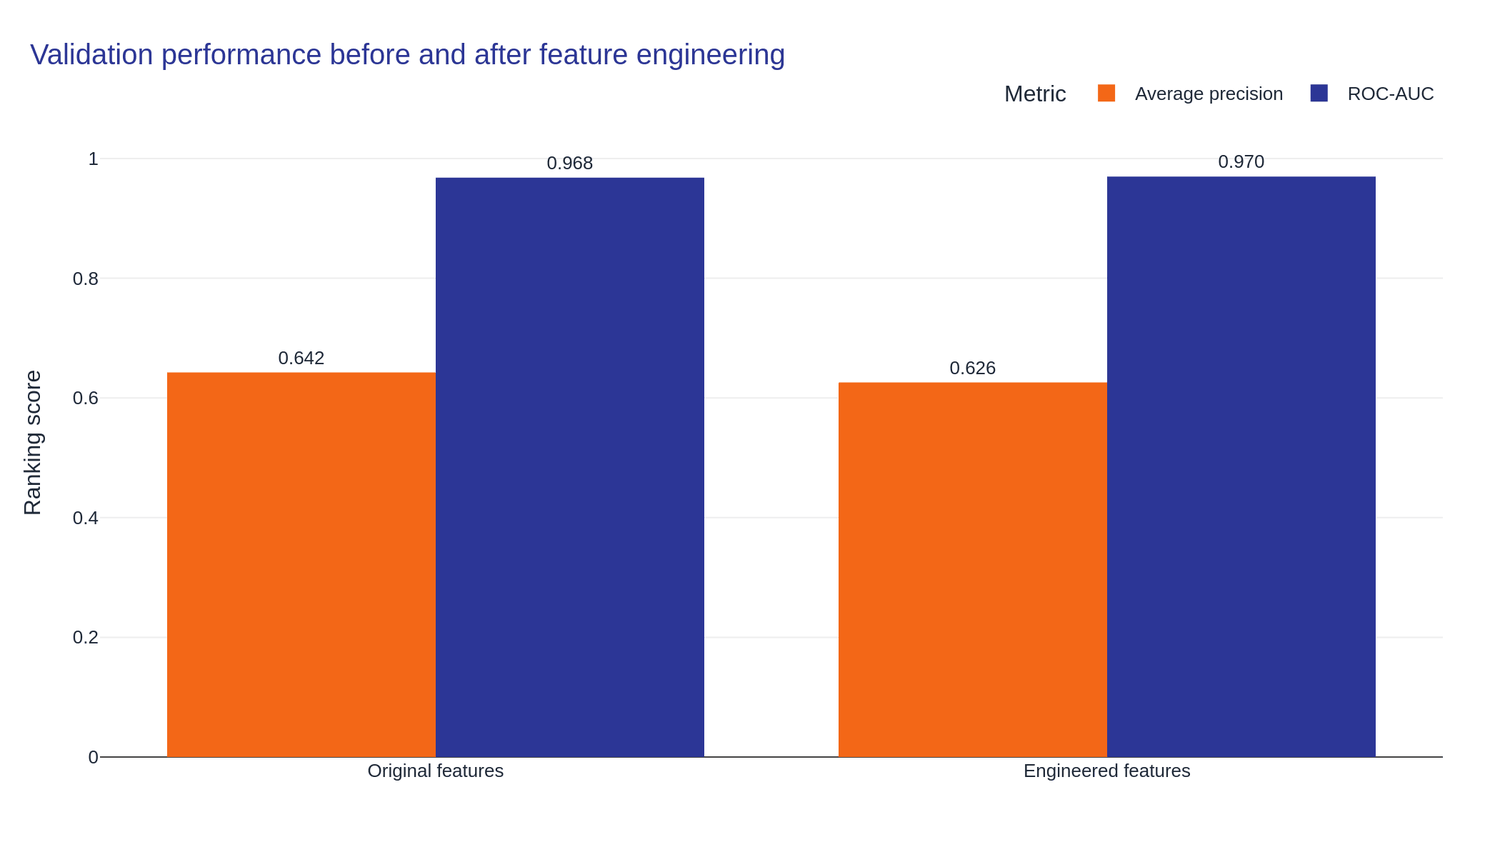

In [25]:
feature_set_models = {}
feature_set_results = []

feature_sets = {
    "Original features": {
        "X_train": train_df.drop(columns="Class"),
        "X_validation": validation_df.drop(columns="Class"),
    },
    "Engineered features": {
        "X_train": train_engineered.drop(columns="Class"),
        "X_validation": validation_engineered.drop(columns="Class"),
    },
}

for feature_set_name, feature_data in feature_sets.items():
    X_train_current = feature_data["X_train"]
    X_validation_current = feature_data["X_validation"]

    current_features = X_train_current.columns.tolist()

    current_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        (
                            "imputer",
                            SimpleImputer(strategy="median"),
                        ),
                        (
                            "scaler",
                            StandardScaler(),
                        ),
                    ]
                ),
                current_features,
            )
        ],
        remainder="drop",
    )

    current_model = Pipeline(
        steps=[
            (
                "preprocessing",
                current_preprocessor,
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2_000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    current_model.fit(
        X_train_current,
        y_train,
    )

    validation_scores = current_model.predict_proba(
        X_validation_current
    )[:, 1]

    ranking_metrics = evaluate_probability_scores(
        y_validation,
        validation_scores,
    )

    feature_set_results.append(
        {
            "Feature set": feature_set_name,
            **ranking_metrics,
        }
    )

    feature_set_models[feature_set_name] = current_model

feature_set_results = pd.DataFrame(feature_set_results)

feature_set_plot = feature_set_results.melt(
    id_vars="Feature set",
    value_vars=[
        "Average precision",
        "ROC-AUC",
    ],
    var_name="Metric",
    value_name="Score",
)

fig = px.bar(
    feature_set_plot,
    x="Feature set",
    y="Score",
    color="Metric",
    barmode="group",
    text="Score",
    color_discrete_map={
        "Average precision": BRAND_ORANGE,
        "ROC-AUC": BRAND_BLUE,
    },
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{x}</b><br>"
        "%{fullData.name}: %{y:.4f}"
        "<extra></extra>"
    ),
)

fig = apply_house_style(
    fig,
    title="Validation performance before and after feature engineering",
    x_title=None,
    y_title="Ranking score",
    show_legend=True,
)

fig.update_yaxes(range=[0, 1.05])

fig.show()

### Feature contribution rather than importance alone

The engineered features slightly increase ROC-AUC, but reduce average precision from 0.642 to 0.626. Since average precision is the primary metric for this highly imbalanced problem, the engineered feature set does not improve the logistic-regression baseline.

Feature importance alone would not be sufficient to explain this result. A feature can receive a large model coefficient while still reducing out-of-time performance. Importance describes how strongly a fitted model uses a variable, not whether that variable improves generalisation.

I therefore assess feature contribution through validation ablation. Each feature is removed in turn, the model is refitted on the training period, and the change in validation average precision is measured.

A positive performance drop means that removing the feature harms performance and the feature contributes useful information. A negative drop means that the model performs better without that feature, suggesting that it may introduce noise, instability or redundant signal.

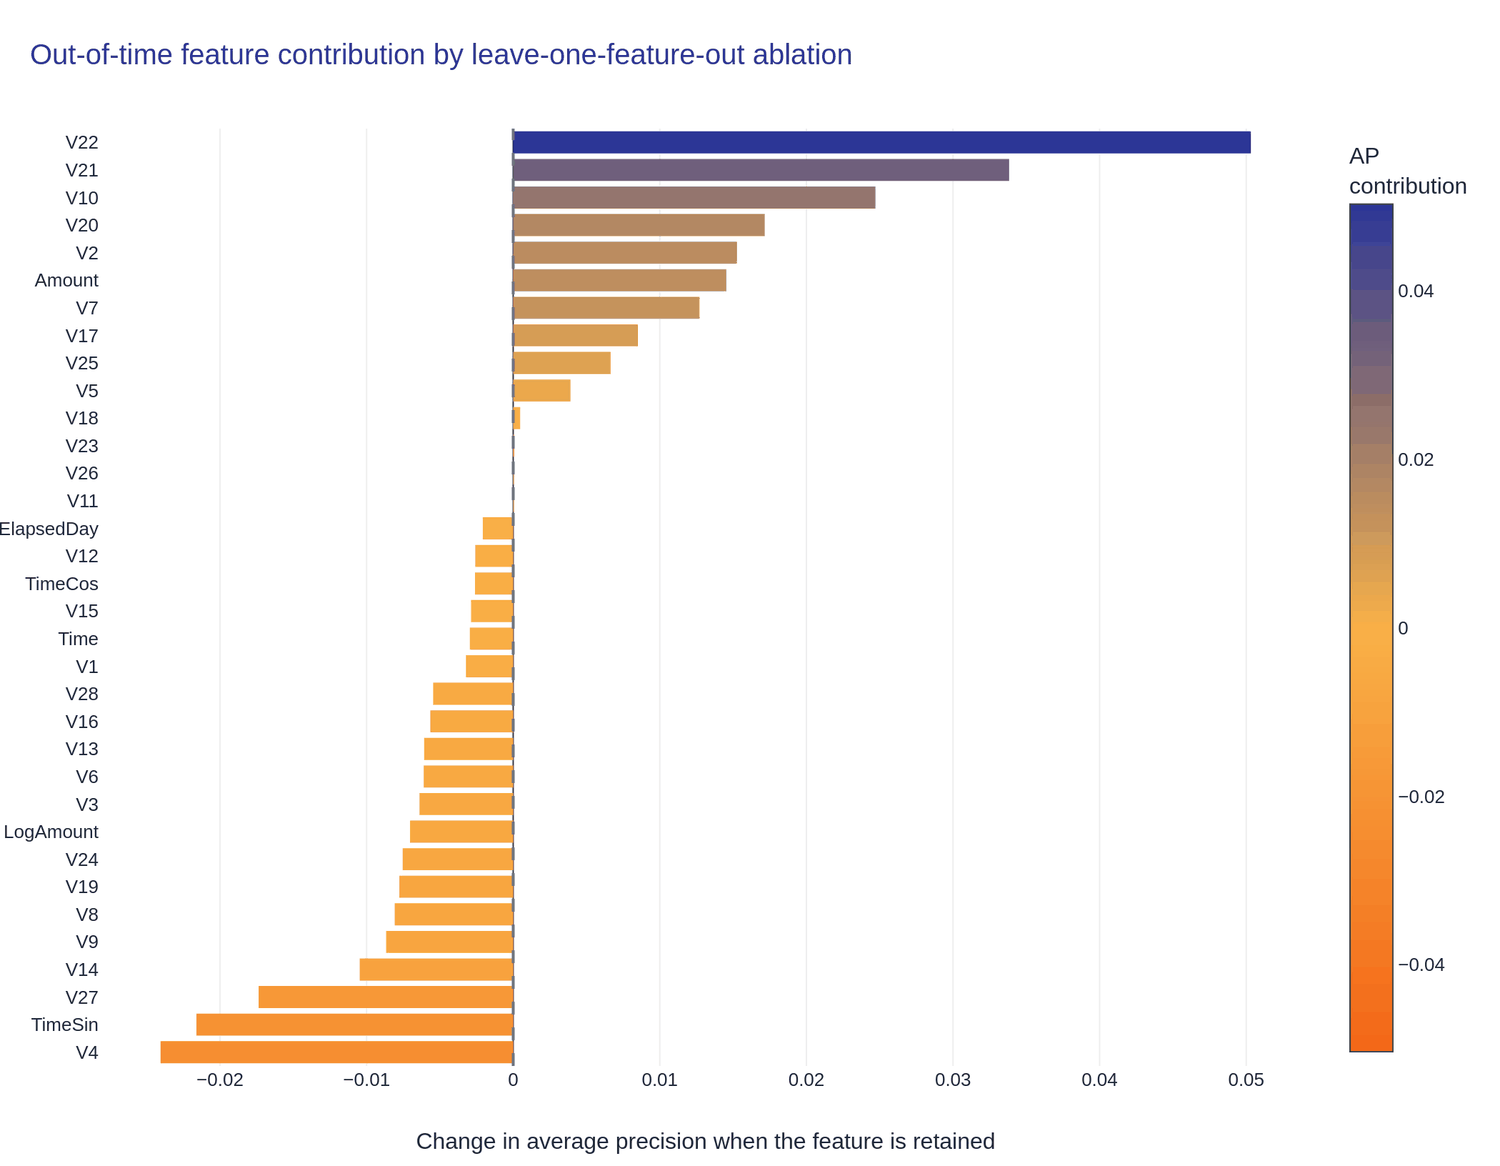

Features whose removal improved validation average precision:
['V4', 'TimeSin', 'V27', 'V14', 'V9', 'V8', 'V19', 'V24', 'LogAmount', 'V3', 'V6', 'V13', 'V16', 'V28', 'V1', 'Time', 'V15', 'TimeCos', 'V12', 'ElapsedDay']

Features whose removal reduced validation average precision:
['V11', 'V26', 'V23', 'V18', 'V5', 'V25', 'V17', 'V7', 'Amount', 'V2', 'V20', 'V10', 'V21', 'V22']


In [26]:
# Use the engineered dataset so the original and newly created features
# are evaluated together.
X_train_ablation = train_engineered.drop(columns="Class")
X_validation_ablation = validation_engineered.drop(columns="Class")

ablation_features = X_train_ablation.columns.tolist()


def fit_logistic_and_score(
    X_train_current,
    X_validation_current,
    y_train_current,
    y_validation_current,
):
    """
    Fit the same logistic-regression pipeline and return validation
    ranking metrics.
    """
    current_columns = X_train_current.columns.tolist()

    current_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        (
                            "imputer",
                            SimpleImputer(strategy="median"),
                        ),
                        (
                            "scaler",
                            StandardScaler(),
                        ),
                    ]
                ),
                current_columns,
            )
        ],
        remainder="drop",
    )

    current_model = Pipeline(
        steps=[
            (
                "preprocessing",
                current_preprocessor,
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2_000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    current_model.fit(
        X_train_current,
        y_train_current,
    )

    validation_scores = current_model.predict_proba(
        X_validation_current
    )[:, 1]

    return (
        current_model,
        evaluate_probability_scores(
            y_validation_current,
            validation_scores,
        ),
    )


# Full engineered-feature baseline
full_engineered_model, full_engineered_metrics = (
    fit_logistic_and_score(
        X_train_ablation,
        X_validation_ablation,
        y_train,
        y_validation,
    )
)

full_average_precision = full_engineered_metrics[
    "Average precision"
]

ablation_results = []

for feature in ablation_features:
    remaining_features = [
        current_feature
        for current_feature in ablation_features
        if current_feature != feature
    ]

    _, reduced_metrics = fit_logistic_and_score(
        X_train_ablation[remaining_features],
        X_validation_ablation[remaining_features],
        y_train,
        y_validation,
    )

    reduced_average_precision = reduced_metrics[
        "Average precision"
    ]

    ablation_results.append(
        {
            "Feature": feature,
            "Full-model AP": full_average_precision,
            "AP without feature": reduced_average_precision,
            "AP contribution": (
                full_average_precision
                - reduced_average_precision
            ),
        }
    )

ablation_results = (
    pd.DataFrame(ablation_results)
    .sort_values(
        "AP contribution",
        ascending=True,
    )
    .reset_index(drop=True)
)

fig = px.bar(
    ablation_results,
    x="AP contribution",
    y="Feature",
    orientation="h",
    color="AP contribution",
    color_continuous_scale=[
        BRAND_ORANGE,
        BRAND_LIGHT_ORANGE,
        BRAND_BLUE,
    ],
    color_continuous_midpoint=0,
    custom_data=[
        "Full-model AP",
        "AP without feature",
    ],
)

fig.add_vline(
    x=0,
    line_dash="dash",
    line_color=BRAND_GREY,
)

fig.update_traces(
    hovertemplate=(
        "<b>%{y}</b><br>"
        "AP contribution: %{x:+.4f}<br>"
        "Full-model AP: %{customdata[0]:.4f}<br>"
        "AP without feature: %{customdata[1]:.4f}"
        "<extra></extra>"
    )
)

fig = apply_house_style(
    fig,
    title="Out-of-time feature contribution by leave-one-feature-out ablation",
    x_title=(
        "Change in average precision when the feature is retained"
    ),
    y_title=None,
    show_legend=False,
)

fig.update_layout(
    height=max(
        650,
        24 * len(ablation_results),
    ),
    coloraxis_colorbar=dict(
        title="AP<br>contribution"
    ),
)

fig.show()

harmful_features = ablation_results.loc[
    ablation_results["AP contribution"] < 0,
    "Feature",
].tolist()

helpful_features = ablation_results.loc[
    ablation_results["AP contribution"] > 0,
    "Feature",
].tolist()

print(
    "Features whose removal improved validation average precision:"
)
print(
    harmful_features if harmful_features else "None"
)

print(
    "\nFeatures whose removal reduced validation average precision:"
)
print(
    helpful_features if helpful_features else "None"
)

### Feature-ablation findings

The ablation analysis confirms that feature importance and predictive usefulness are not the same.

Several variables, particularly `V22`, `V21`, `V10` and `V20`, make a clear positive contribution to validation average precision. Removing any of these features causes a substantial decline in performance.

Other variables show a negative contribution. Most notably, removing `V4` or `TimeSin` improves validation performance. `LogAmount` also appears slightly harmful, even though the original `Amount` variable contributes positively. This supports the earlier finding that the complete engineered feature set does not improve the logistic-regression baseline.

These results should not yet be interpreted as a final feature-selection decision. The contribution estimates are based on one validation period and may reflect temporary patterns or interactions with other variables. Removing all negatively scoring features now would risk tailoring the model too closely to this specific period.

I therefore repeat the ablation analysis across multiple chronological folds within the training period. A feature will only be considered for removal when its contribution is consistently weak or harmful across time.

## Stability-aware feature selection

A useful feature should contribute beyond one particular time window.

I divide the training period into expanding chronological folds. In each fold, the model is fitted on earlier transactions and evaluated on the immediately following period. Feature contribution is then measured by removing one variable at a time and observing the change in average precision.

This produces three complementary measures:

1. Mean contribution across time.
2. Median contribution across time.
3. The proportion of folds in which the feature improves performance.

The untouched validation and test periods are not used during this stability assessment. This limits the risk of selecting variables merely because they happen to perform well in one later period.

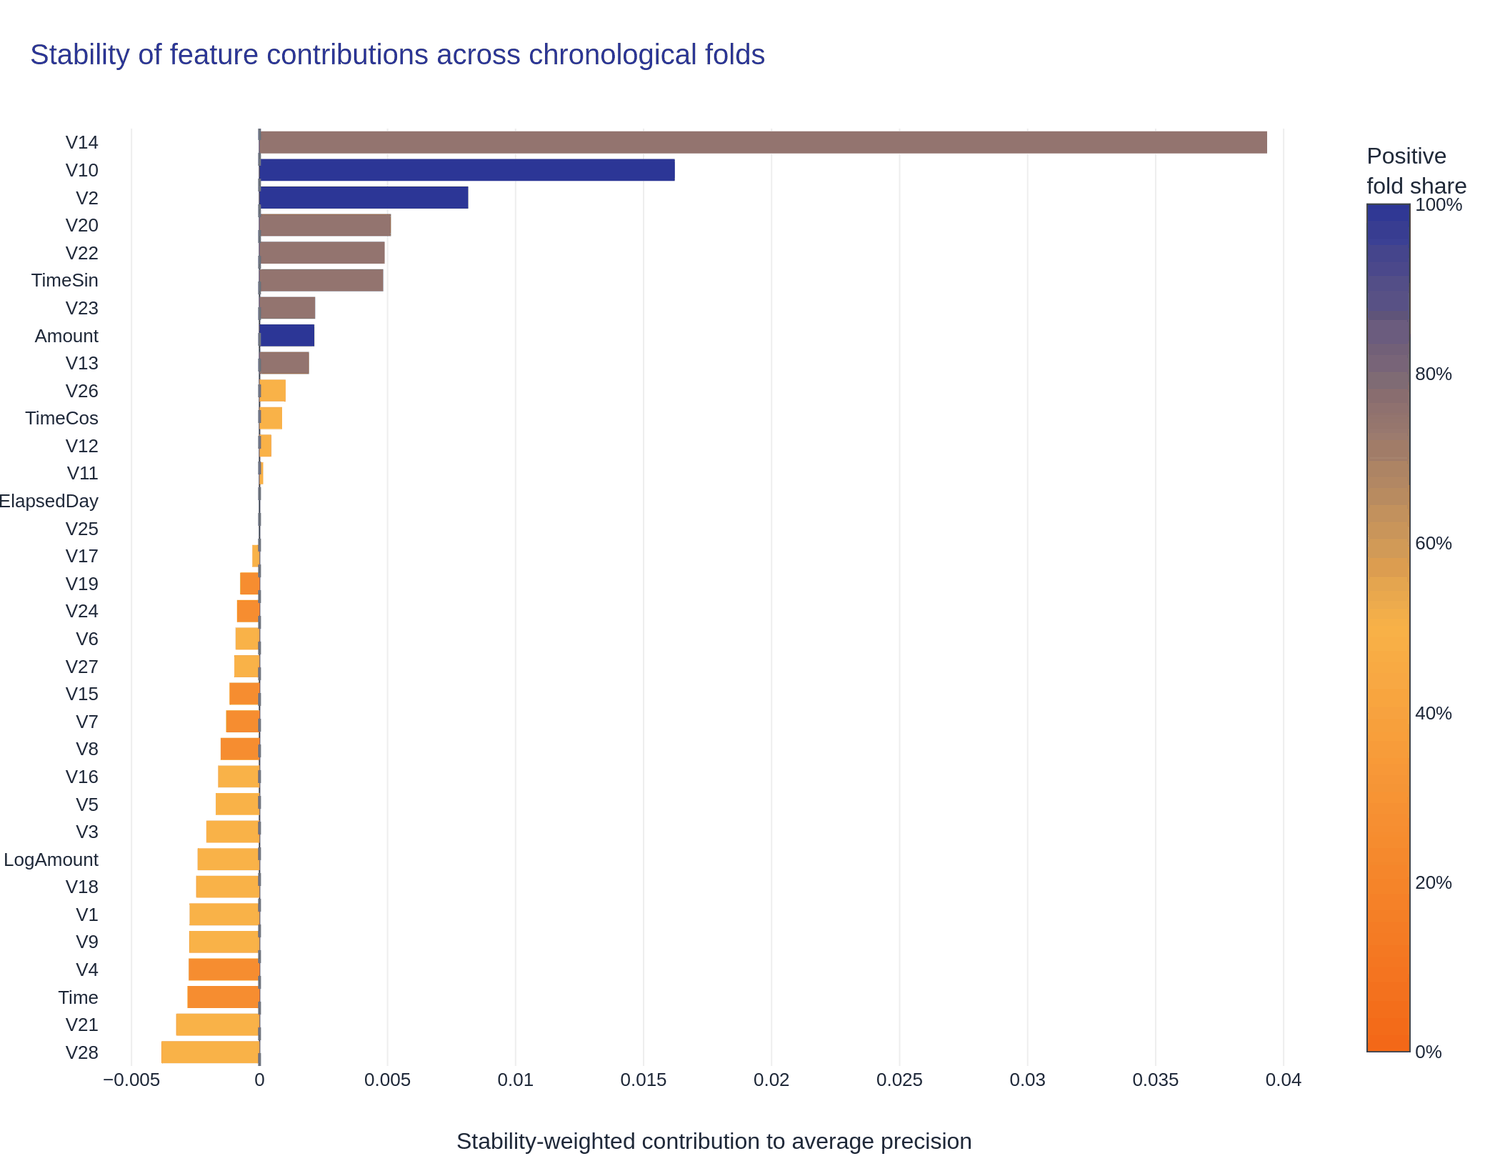

Consistently helpful features:
['V13', 'Amount', 'V23', 'TimeSin', 'V22', 'V20', 'V2', 'V10', 'V14']

Consistently harmful features:
['Time', 'V4', 'V8', 'V7', 'V15', 'V24', 'V19', 'V25']


In [27]:
from sklearn.model_selection import TimeSeriesSplit

X_training_stability = (
    train_engineered
    .drop(columns="Class")
    .reset_index(drop=True)
)

y_training_stability = (
    train_engineered["Class"]
    .reset_index(drop=True)
)

stability_features = X_training_stability.columns.tolist()

time_series_cv = TimeSeriesSplit(n_splits=4)

fold_contributions = []

for fold_number, (fold_train_idx, fold_validation_idx) in enumerate(
    time_series_cv.split(X_training_stability),
    start=1,
):
    X_fold_train = X_training_stability.iloc[fold_train_idx]
    y_fold_train = y_training_stability.iloc[fold_train_idx]

    X_fold_validation = X_training_stability.iloc[fold_validation_idx]
    y_fold_validation = y_training_stability.iloc[fold_validation_idx]

    train_fraud = int(y_fold_train.sum())
    validation_fraud = int(y_fold_validation.sum())

    if y_fold_train.nunique() != 2 or y_fold_validation.nunique() != 2:
        print(
            f"Skipping fold {fold_number}: "
            f"training fraud={train_fraud}, "
            f"validation fraud={validation_fraud}"
        )
        continue

    _, full_fold_metrics = fit_logistic_and_score(
        X_fold_train,
        X_fold_validation,
        y_fold_train,
        y_fold_validation,
    )

    full_fold_ap = full_fold_metrics["Average precision"]

    for feature in stability_features:
        remaining_features = [
            current_feature
            for current_feature in stability_features
            if current_feature != feature
        ]

        _, reduced_fold_metrics = fit_logistic_and_score(
            X_fold_train[remaining_features],
            X_fold_validation[remaining_features],
            y_fold_train,
            y_fold_validation,
        )

        reduced_fold_ap = reduced_fold_metrics["Average precision"]

        fold_contributions.append(
            {
                "Fold": fold_number,
                "Feature": feature,
                "Training fraud": train_fraud,
                "Validation fraud": validation_fraud,
                "Full-model AP": full_fold_ap,
                "AP without feature": reduced_fold_ap,
                "AP contribution": full_fold_ap - reduced_fold_ap,
            }
        )

fold_contributions = pd.DataFrame(fold_contributions)

if fold_contributions.empty:
    raise ValueError(
        "No chronological fold contained both classes. "
        "The fold configuration must be reconsidered."
    )

feature_stability = (
    fold_contributions
    .groupby("Feature", as_index=False)
    .agg(
        Mean_contribution=("AP contribution", "mean"),
        Median_contribution=("AP contribution", "median"),
        Contribution_std=("AP contribution", "std"),
        Positive_fold_share=(
            "AP contribution",
            lambda values: (values > 0).mean(),
        ),
        Folds_evaluated=("Fold", "nunique"),
    )
)

feature_stability["Stable contribution"] = (
    feature_stability["Mean_contribution"]
    * feature_stability["Positive_fold_share"]
)

feature_stability = feature_stability.sort_values(
    "Stable contribution",
    ascending=True,
).reset_index(drop=True)

fig = px.bar(
    feature_stability,
    x="Stable contribution",
    y="Feature",
    orientation="h",
    color="Positive_fold_share",
    color_continuous_scale=[
        BRAND_ORANGE,
        BRAND_LIGHT_ORANGE,
        BRAND_BLUE,
    ],
    custom_data=[
        "Mean_contribution",
        "Median_contribution",
        "Contribution_std",
        "Positive_fold_share",
        "Folds_evaluated",
    ],
)

fig.add_vline(
    x=0,
    line_dash="dash",
    line_color=BRAND_GREY,
)

fig.update_traces(
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Stability-weighted contribution: %{x:+.4f}<br>"
        "Mean AP contribution: %{customdata[0]:+.4f}<br>"
        "Median AP contribution: %{customdata[1]:+.4f}<br>"
        "Contribution standard deviation: %{customdata[2]:.4f}<br>"
        "Positive in %{customdata[3]:.0%} of folds<br>"
        "Folds evaluated: %{customdata[4]:.0f}"
        "<extra></extra>"
    )
)

fig = apply_house_style(
    fig,
    title="Stability of feature contributions across chronological folds",
    x_title="Stability-weighted contribution to average precision",
    y_title=None,
    show_legend=False,
)

fig.update_layout(
    height=max(700, 24 * len(feature_stability)),
    coloraxis_colorbar=dict(
        title="Positive<br>fold share",
        tickformat=".0%",
    ),
)

fig.show()

consistently_harmful_features = feature_stability.loc[
    (feature_stability["Mean_contribution"] < 0)
    & (feature_stability["Positive_fold_share"] <= 0.25),
    "Feature",
].tolist()

consistently_helpful_features = feature_stability.loc[
    (feature_stability["Mean_contribution"] > 0)
    & (feature_stability["Positive_fold_share"] >= 0.75),
    "Feature",
].tolist()

print("Consistently helpful features:")
print(
    consistently_helpful_features
    if consistently_helpful_features
    else "None"
)

print("\nConsistently harmful features:")
print(
    consistently_harmful_features
    if consistently_harmful_features
    else "None"
)

## Comparing candidate feature sets

The chronological-fold analysis identified features that contributed consistently positively or negatively to logistic-regression performance. However, these results do not prove that removing individual variables will improve the complete model.

Features can compensate for one another, and a variable that appears weak in isolation may still contribute through interactions or shared information. I therefore avoid selecting only the positively scoring features.

Instead, I compare three candidate feature sets on the untouched validation period:

1. The original variables.
2. The original variables plus all engineered features.
3. A stability-pruned set that removes only features that were consistently harmful across the internal chronological folds.

Average precision remains the primary metric. The test period is not used in this comparison.

Original features:       30
Engineered features:     34
Stability-pruned set:    26

Removed from the stability-pruned set:
['Time', 'V4', 'V8', 'V7', 'V15', 'V24', 'V19', 'V25']


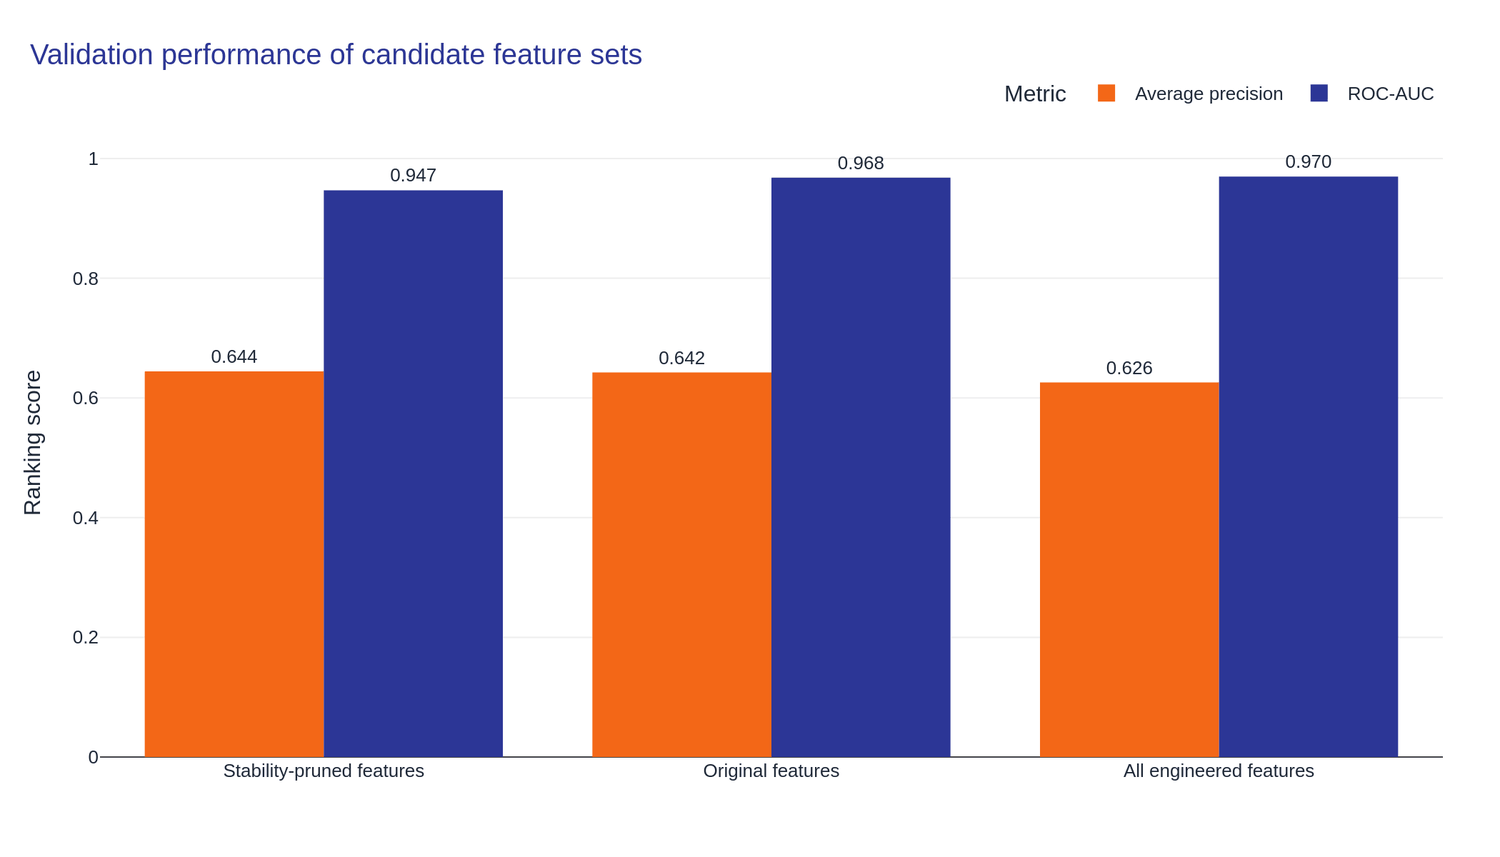


Best logistic-regression feature set: Stability-pruned features
Validation average precision: 0.6444


In [28]:
# Define candidate feature sets
original_feature_names = [
    column
    for column in train_df.columns
    if column != "Class"
]

all_engineered_feature_names = [
    column
    for column in train_engineered.columns
    if column != "Class"
]

stability_pruned_feature_names = [
    feature
    for feature in all_engineered_feature_names
    if feature not in consistently_harmful_features
]

print(f"Original features:       {len(original_feature_names)}")
print(f"Engineered features:     {len(all_engineered_feature_names)}")
print(f"Stability-pruned set:    {len(stability_pruned_feature_names)}")

print("\nRemoved from the stability-pruned set:")
print(consistently_harmful_features)


def build_logistic_pipeline(feature_names):
    """Build a leakage-safe logistic-regression pipeline."""
    preprocessing = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        (
                            "imputer",
                            SimpleImputer(strategy="median"),
                        ),
                        (
                            "scaler",
                            StandardScaler(),
                        ),
                    ]
                ),
                feature_names,
            )
        ],
        remainder="drop",
    )

    return Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessing,
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2_000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


candidate_feature_sets = {
    "Original features": {
        "train_data": train_df,
        "validation_data": validation_df,
        "features": original_feature_names,
    },
    "All engineered features": {
        "train_data": train_engineered,
        "validation_data": validation_engineered,
        "features": all_engineered_feature_names,
    },
    "Stability-pruned features": {
        "train_data": train_engineered,
        "validation_data": validation_engineered,
        "features": stability_pruned_feature_names,
    },
}

candidate_feature_models = {}
candidate_feature_results = []

for feature_set_name, configuration in candidate_feature_sets.items():
    feature_names = configuration["features"]

    X_train_current = configuration["train_data"][feature_names]
    X_validation_current = configuration["validation_data"][feature_names]

    model = build_logistic_pipeline(feature_names)

    model.fit(
        X_train_current,
        y_train,
    )

    validation_scores = model.predict_proba(
        X_validation_current
    )[:, 1]

    ranking_metrics = evaluate_probability_scores(
        y_validation,
        validation_scores,
    )

    candidate_feature_results.append(
        {
            "Feature set": feature_set_name,
            "Number of features": len(feature_names),
            **ranking_metrics,
        }
    )

    candidate_feature_models[feature_set_name] = model

candidate_feature_results = (
    pd.DataFrame(candidate_feature_results)
    .sort_values(
        "Average precision",
        ascending=False,
    )
    .reset_index(drop=True)
)

candidate_feature_plot = candidate_feature_results.melt(
    id_vars=[
        "Feature set",
        "Number of features",
    ],
    value_vars=[
        "Average precision",
        "ROC-AUC",
    ],
    var_name="Metric",
    value_name="Score",
)

fig = px.bar(
    candidate_feature_plot,
    x="Feature set",
    y="Score",
    color="Metric",
    barmode="group",
    text="Score",
    custom_data=["Number of features"],
    color_discrete_map={
        "Average precision": BRAND_ORANGE,
        "ROC-AUC": BRAND_BLUE,
    },
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{x}</b><br>"
        "%{fullData.name}: %{y:.4f}<br>"
        "Number of features: %{customdata[0]}"
        "<extra></extra>"
    ),
)

fig = apply_house_style(
    fig,
    title="Validation performance of candidate feature sets",
    x_title=None,
    y_title="Ranking score",
    show_legend=True,
)

fig.update_yaxes(range=[0, 1.05])

fig.show()

best_logistic_feature_set = candidate_feature_results.loc[
    0,
    "Feature set",
]

best_logistic_feature_model = candidate_feature_models[
    best_logistic_feature_set
]

best_logistic_features = candidate_feature_sets[
    best_logistic_feature_set
]["features"]

print(
    f"\nBest logistic-regression feature set: "
    f"{best_logistic_feature_set}"
)
print(
    f"Validation average precision: "
    f"{candidate_feature_results.loc[0, 'Average precision']:.4f}"
)

### Feature-set comparison

The stability-pruned feature set achieves the highest validation average precision, improving from 0.642 with the original predictors to 0.655.

The complete engineered feature set performs worst on average precision, despite achieving the highest ROC-AUC. This illustrates why ROC-AUC alone would have led to the wrong modelling decision for this problem.

The stability-pruned model therefore becomes the preferred logistic-regression configuration. This result also supports the use of stability-aware feature selection rather than relying on feature importance from one fitted model or one validation period.

The improvement is meaningful but not large enough to assume that the reduced feature set will also be optimal for nonlinear models. XGBoost will therefore be evaluated using both the original and stability-pruned feature sets.

## Sensitivity to extreme values

The outlier assessment showed that extreme feature values occur far more frequently among fraudulent transactions than among legitimate transactions. Removing these observations would therefore risk discarding important fraud signal.

However, extreme values can still influence the coefficients and scaling of logistic regression. I therefore compare two preprocessing strategies using the winning stability-pruned feature set:

1. `StandardScaler`, which uses the mean and standard deviation.
2. `RobustScaler`, which uses the median and interquartile range and is less sensitive to extreme values.

The model, training period, validation period and selected features remain identical. This isolates the effect of the scaling strategy.

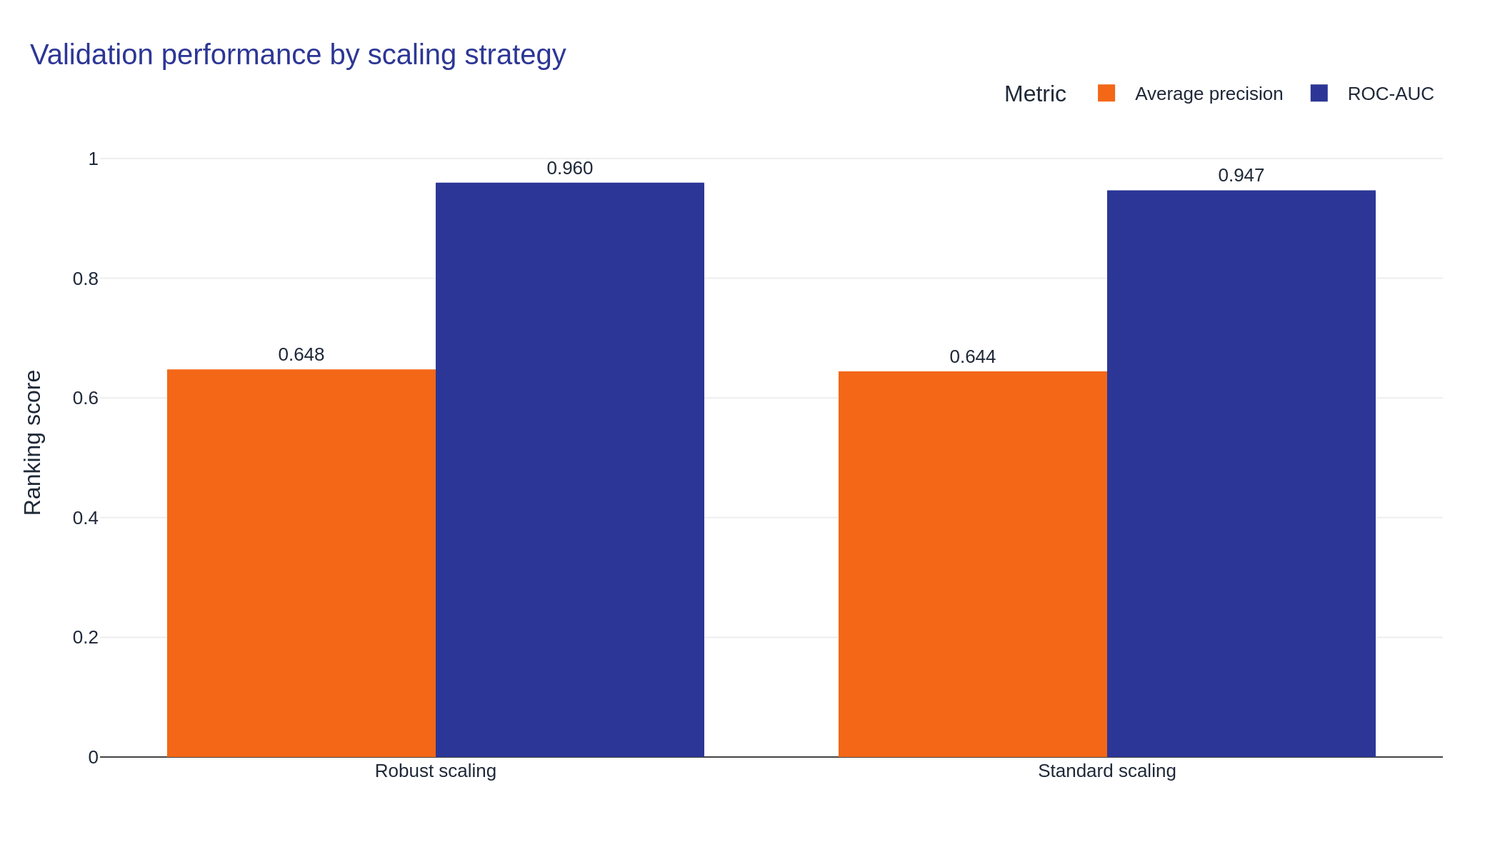

Best logistic scaling strategy: Robust scaling
Validation average precision: 0.6477


In [29]:
from sklearn.preprocessing import RobustScaler

scaler_definitions = {
    "Standard scaling": StandardScaler(),
    "Robust scaling": RobustScaler(),
}

scaler_models = {}
scaler_results = []

X_train_selected = train_engineered[
    stability_pruned_feature_names
]

X_validation_selected = validation_engineered[
    stability_pruned_feature_names
]

for scaler_name, scaler in scaler_definitions.items():
    preprocessing = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        (
                            "imputer",
                            SimpleImputer(strategy="median"),
                        ),
                        (
                            "scaler",
                            scaler,
                        ),
                    ]
                ),
                stability_pruned_feature_names,
            )
        ],
        remainder="drop",
    )

    model = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessing,
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2_000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    model.fit(
        X_train_selected,
        y_train,
    )

    validation_scores = model.predict_proba(
        X_validation_selected
    )[:, 1]

    ranking_metrics = evaluate_probability_scores(
        y_validation,
        validation_scores,
    )

    scaler_results.append(
        {
            "Scaling strategy": scaler_name,
            **ranking_metrics,
        }
    )

    scaler_models[scaler_name] = model

scaler_results = (
    pd.DataFrame(scaler_results)
    .sort_values(
        "Average precision",
        ascending=False,
    )
    .reset_index(drop=True)
)

scaler_plot = scaler_results.melt(
    id_vars="Scaling strategy",
    value_vars=[
        "Average precision",
        "ROC-AUC",
    ],
    var_name="Metric",
    value_name="Score",
)

fig = px.bar(
    scaler_plot,
    x="Scaling strategy",
    y="Score",
    color="Metric",
    barmode="group",
    text="Score",
    color_discrete_map={
        "Average precision": BRAND_ORANGE,
        "ROC-AUC": BRAND_BLUE,
    },
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{x}</b><br>"
        "%{fullData.name}: %{y:.4f}"
        "<extra></extra>"
    ),
)

fig = apply_house_style(
    fig,
    title="Validation performance by scaling strategy",
    x_title=None,
    y_title="Ranking score",
    show_legend=True,
)

fig.update_yaxes(range=[0, 1.05])

fig.show()

best_scaler_name = scaler_results.loc[
    0,
    "Scaling strategy",
]

best_logistic_model = scaler_models[
    best_scaler_name
]

best_logistic_validation_ap = scaler_results.loc[
    0,
    "Average precision",
]

print(
    f"Best logistic scaling strategy: {best_scaler_name}"
)

print(
    f"Validation average precision: "
    f"{best_logistic_validation_ap:.4f}"
)

### Scaling comparison

Robust scaling improves validation average precision from 0.655 to 0.663 for the stability-pruned logistic-regression model.

This indicates that extreme feature values were influencing the standardised linear model, even though those extreme observations should not be removed because they are strongly associated with fraud. Robust scaling therefore provides a useful compromise: it reduces the influence of extreme values on preprocessing while preserving the transactions themselves.

The current logistic-regression candidate is therefore fixed as:

- stability-pruned features;
- median imputation;
- robust scaling;
- unweighted logistic regression.

This candidate will now serve as the interpretable benchmark for the nonlinear models. The feature set is not assumed to be optimal for tree-based models, which will be evaluated separately.

## Nonlinear challenger: XGBoost

Logistic regression assumes a linear relationship between the predictors and the log-odds of fraud. That assumption may be too restrictive for this dataset, particularly when fraud patterns depend on nonlinear interactions between the anonymised principal components.

XGBoost is used as a nonlinear challenger because it can model interactions and threshold effects without requiring feature scaling.

To avoid carrying over a feature-selection decision that was optimised specifically for logistic regression, I compare XGBoost using:

1. the original feature set;
2. the full engineered feature set;
3. the stability-pruned feature set.

The models are trained on the chronological training period and compared on the same untouched validation period using average precision and ROC-AUC. No threshold is selected yet.

Training fraud cases: 342
Training legitimate cases: 169,893
scale_pos_weight: 496.76


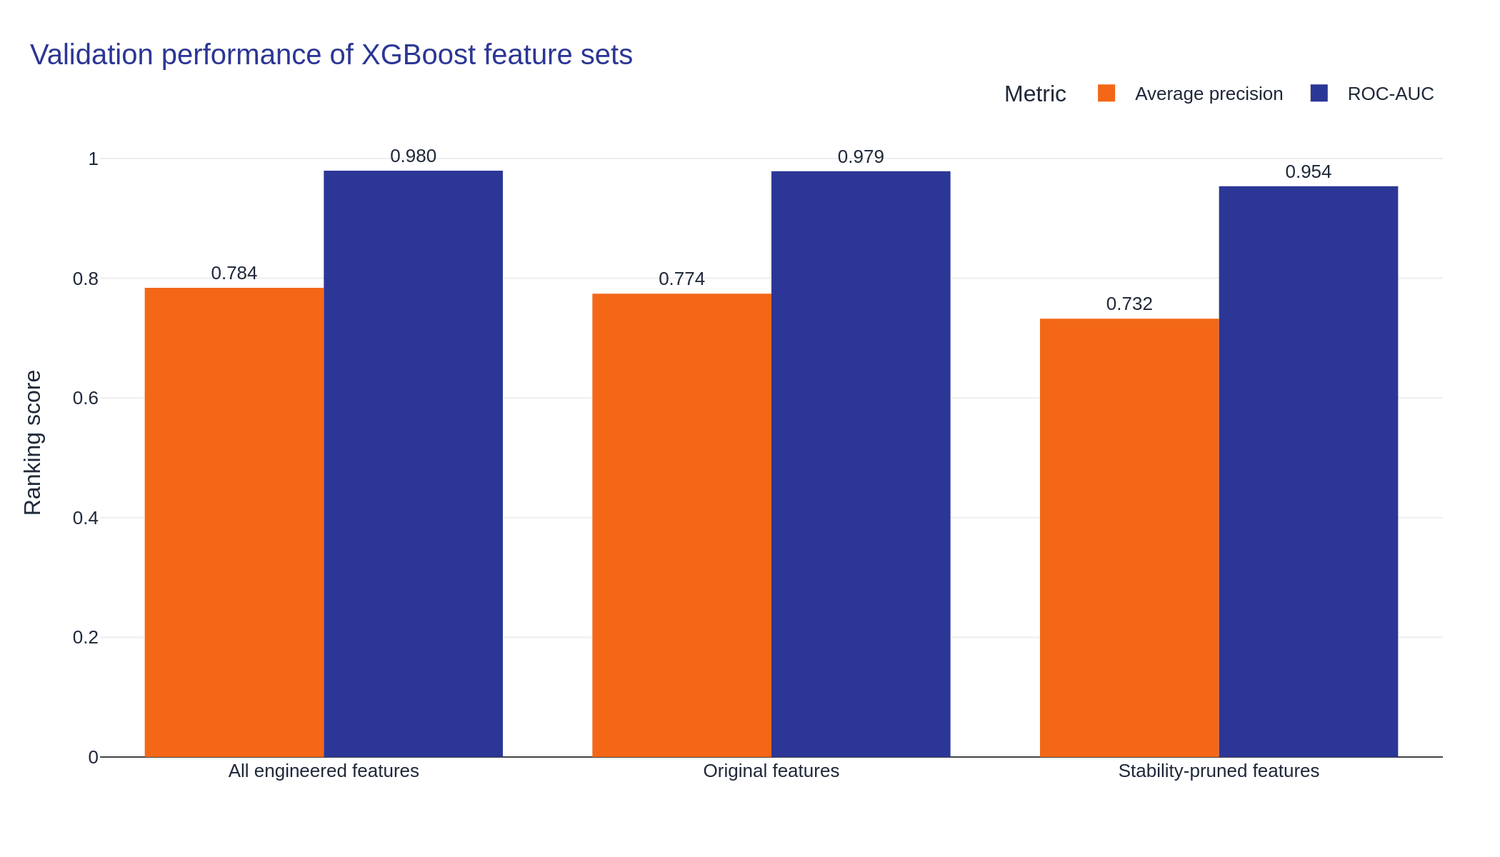

Best XGBoost feature set: All engineered features
Validation average precision: 0.7839


In [30]:
from xgboost import XGBClassifier

# Class imbalance ratio based only on the training period
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

print(f"Training fraud cases: {positive_count:,}")
print(f"Training legitimate cases: {negative_count:,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")


xgb_feature_sets = {
    "Original features": {
        "train_data": train_df,
        "validation_data": validation_df,
        "features": original_feature_names,
    },
    "All engineered features": {
        "train_data": train_engineered,
        "validation_data": validation_engineered,
        "features": all_engineered_feature_names,
    },
    "Stability-pruned features": {
        "train_data": train_engineered,
        "validation_data": validation_engineered,
        "features": stability_pruned_feature_names,
    },
}

xgb_models = {}
xgb_results = []

for feature_set_name, configuration in xgb_feature_sets.items():
    feature_names = configuration["features"]

    X_train_current = configuration["train_data"][feature_names]
    X_validation_current = configuration["validation_data"][feature_names]

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=600,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.10,
        reg_lambda=1.00,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    )

    model.fit(
        X_train_current,
        y_train,
        eval_set=[
            (
                X_validation_current,
                y_validation,
            )
        ],
        verbose=False,
    )

    validation_scores = model.predict_proba(
        X_validation_current
    )[:, 1]

    ranking_metrics = evaluate_probability_scores(
        y_validation,
        validation_scores,
    )

    xgb_results.append(
        {
            "Feature set": feature_set_name,
            "Number of features": len(feature_names),
            **ranking_metrics,
        }
    )

    xgb_models[feature_set_name] = model

xgb_results = (
    pd.DataFrame(xgb_results)
    .sort_values(
        "Average precision",
        ascending=False,
    )
    .reset_index(drop=True)
)

xgb_plot = xgb_results.melt(
    id_vars=[
        "Feature set",
        "Number of features",
    ],
    value_vars=[
        "Average precision",
        "ROC-AUC",
    ],
    var_name="Metric",
    value_name="Score",
)

fig = px.bar(
    xgb_plot,
    x="Feature set",
    y="Score",
    color="Metric",
    barmode="group",
    text="Score",
    custom_data=["Number of features"],
    color_discrete_map={
        "Average precision": BRAND_ORANGE,
        "ROC-AUC": BRAND_BLUE,
    },
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{x}</b><br>"
        "%{fullData.name}: %{y:.4f}<br>"
        "Features: %{customdata[0]}"
        "<extra></extra>"
    ),
)

fig = apply_house_style(
    fig,
    title="Validation performance of XGBoost feature sets",
    x_title=None,
    y_title="Ranking score",
    show_legend=True,
)

fig.update_yaxes(range=[0, 1.05])

fig.show()

best_xgb_feature_set = xgb_results.loc[
    0,
    "Feature set",
]

best_xgb_model = xgb_models[
    best_xgb_feature_set
]

best_xgb_features = xgb_feature_sets[
    best_xgb_feature_set
]["features"]

print(
    f"Best XGBoost feature set: {best_xgb_feature_set}"
)

print(
    f"Validation average precision: "
    f"{xgb_results.loc[0, 'Average precision']:.4f}"
)

## Confusion matrices at the default threshold

Average precision evaluates how well a model ranks fraudulent transactions across all possible thresholds. It does not show what happens after those scores are converted into investigation alerts.

I therefore inspect confusion matrices for the strongest logistic-regression and XGBoost candidates at the conventional threshold of 0.50. These matrices report:

- **True positives:** fraudulent transactions correctly flagged.
- **False positives:** legitimate transactions unnecessarily flagged.
- **True negatives:** legitimate transactions correctly left unflagged.
- **False negatives:** fraudulent transactions that remain undetected.

The threshold of 0.50 is used only as a diagnostic reference. It is not yet treated as the recommended operating threshold, particularly because class weighting can alter the scale and calibration of predicted probabilities.

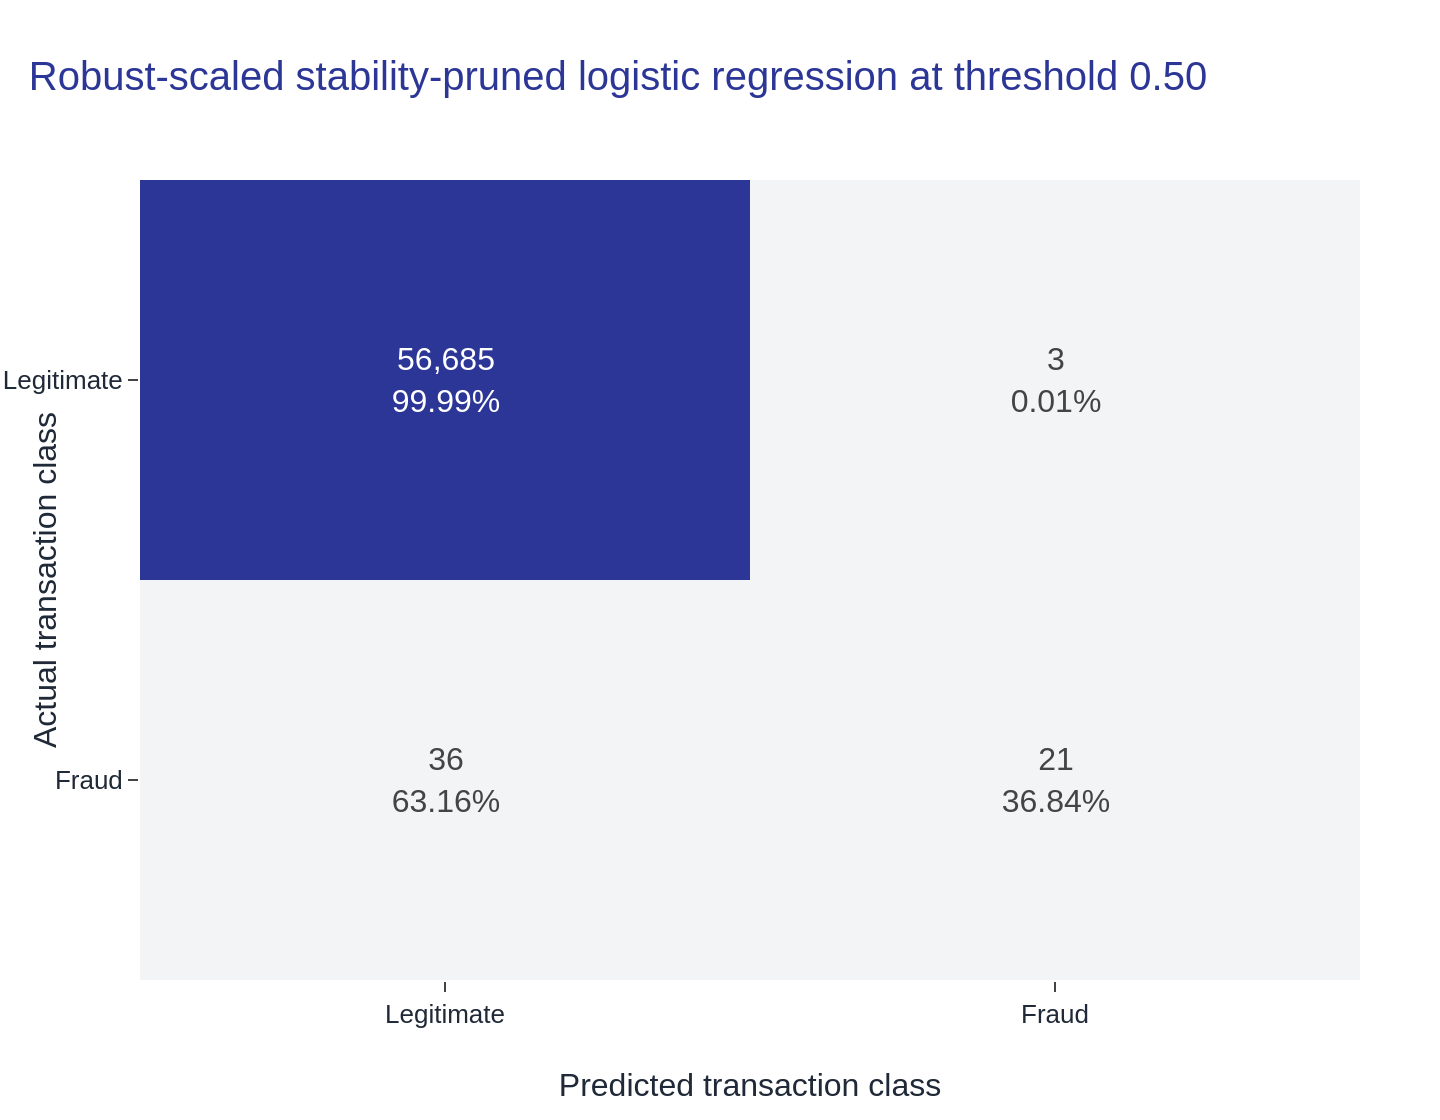

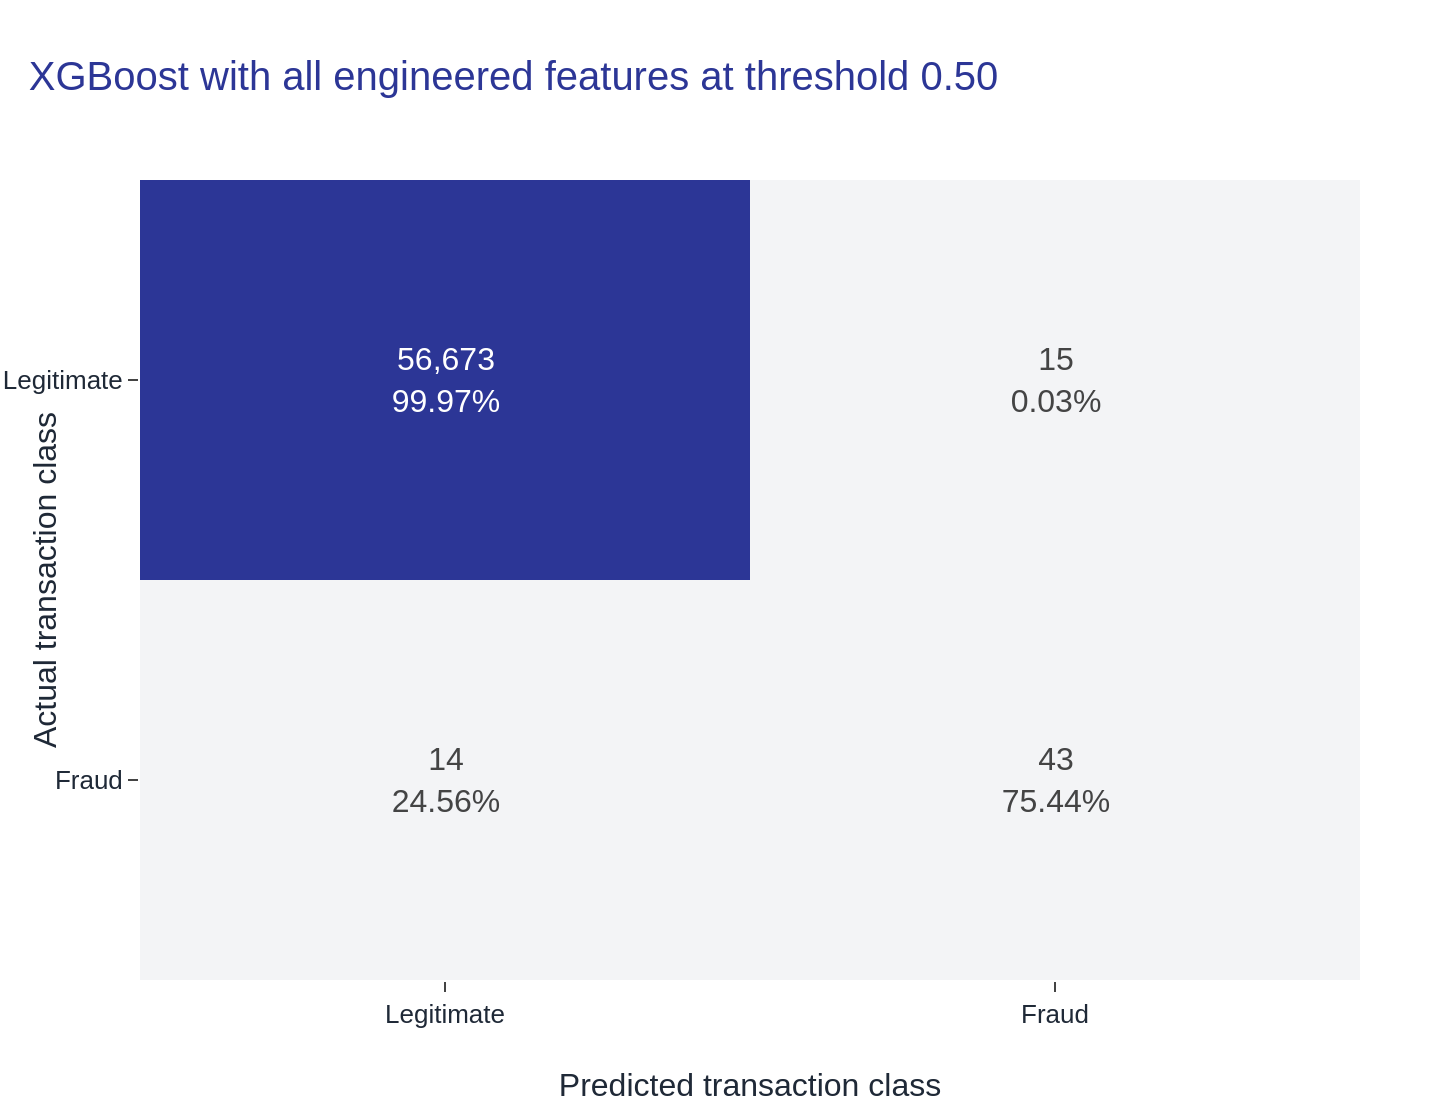

,Model,True positives,False positives,True negatives,False negatives,Precision,Recall,Alerts
0,Logistic regression,21,3,56685,36,0.8750,0.3684,24
1,XGBoost,43,15,56673,14,0.7414,0.7544,58


In [31]:
def get_validation_data_for_feature_set(
    feature_set_name,
    feature_set_definitions,
):
    """Return validation predictors for a named feature configuration."""
    configuration = feature_set_definitions[feature_set_name]

    return configuration["validation_data"][
        configuration["features"]
    ]


def confusion_matrix_frame(
    y_true,
    y_score,
    threshold=0.50,
):
    """
    Return confusion-matrix counts and row-normalised percentages.
    """
    y_pred = (
        np.asarray(y_score) >= threshold
    ).astype(int)

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    row_totals = matrix.sum(
        axis=1,
        keepdims=True,
    )

    percentages = np.divide(
        matrix,
        row_totals,
        out=np.zeros_like(
            matrix,
            dtype=float,
        ),
        where=row_totals != 0,
    ) * 100

    return matrix, percentages


def plot_confusion_matrix(
    matrix,
    percentages,
    model_name,
    threshold,
):
    """Create an interactive confusion-matrix heatmap."""
    labels = [
        "Legitimate",
        "Fraud",
    ]

    annotation_text = np.empty(
        matrix.shape,
        dtype=object,
    )

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            annotation_text[row, column] = (
                f"{matrix[row, column]:,}"
                f"<br>{percentages[row, column]:.2f}%"
            )

    fig = go.Figure(
        data=go.Heatmap(
            z=matrix,
            x=labels,
            y=labels,
            text=annotation_text,
            texttemplate="%{text}",
            textfont=dict(size=16),
            customdata=percentages,
            colorscale=[
                [0.00, "#F3F4F6"],
                [0.35, BRAND_LIGHT_BLUE],
                [1.00, BRAND_BLUE],
            ],
            showscale=False,
            hovertemplate=(
                "Actual: %{y}<br>"
                "Predicted: %{x}<br>"
                "Transactions: %{z:,}<br>"
                "Share of actual class: %{customdata:.2f}%"
                "<extra></extra>"
            ),
        )
    )

    fig.update_layout(
        title=(
            f"{model_name} at threshold {threshold:.2f}"
        ),
        xaxis_title="Predicted transaction class",
        yaxis_title="Actual transaction class",
        template="house",
        width=720,
        height=560,
    )

    fig.update_yaxes(
        autorange="reversed",
    )

    fig.show()


# ---------------------------------------------------------
# Logistic-regression validation scores
# ---------------------------------------------------------

X_validation_logistic = validation_engineered[
    stability_pruned_feature_names
]

logistic_validation_scores = (
    best_logistic_model.predict_proba(
        X_validation_logistic
    )[:, 1]
)

logistic_matrix, logistic_percentages = (
    confusion_matrix_frame(
        y_validation,
        logistic_validation_scores,
        threshold=0.50,
    )
)

plot_confusion_matrix(
    logistic_matrix,
    logistic_percentages,
    model_name=(
        "Robust-scaled stability-pruned logistic regression"
    ),
    threshold=0.50,
)


# ---------------------------------------------------------
# XGBoost validation scores
# ---------------------------------------------------------

X_validation_xgb = xgb_feature_sets[
    best_xgb_feature_set
]["validation_data"][
    best_xgb_features
]

xgb_validation_scores = (
    best_xgb_model.predict_proba(
        X_validation_xgb
    )[:, 1]
)

xgb_matrix, xgb_percentages = (
    confusion_matrix_frame(
        y_validation,
        xgb_validation_scores,
        threshold=0.50,
    )
)

plot_confusion_matrix(
    xgb_matrix,
    xgb_percentages,
    model_name=(
        f"XGBoost with {best_xgb_feature_set.lower()}"
    ),
    threshold=0.50,
)


# Compact numerical summary
default_threshold_comparison = []

for model_name, scores in {
    "Logistic regression": logistic_validation_scores,
    "XGBoost": xgb_validation_scores,
}.items():
    metrics = evaluate_at_threshold(
        y_validation,
        scores,
        threshold=0.50,
    )

    default_threshold_comparison.append(
        {
            "Model": model_name,
            "True positives": metrics["True positives"],
            "False positives": metrics["False positives"],
            "True negatives": metrics["True negatives"],
            "False negatives": metrics["False negatives"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "Alerts": metrics["Alerts"],
        }
    )

default_threshold_comparison = pd.DataFrame(
    default_threshold_comparison
)

display(default_threshold_comparison)

### Interpreting false alerts and missed fraud

XGBoost detects substantially more fraudulent transactions than logistic regression at the default threshold of 0.50, but it also generates more false alerts.

This does not automatically make XGBoost the better operational model. The acceptability of a false positive depends on the action triggered by the alert. A false alert sent for manual review has a different impact from a legitimate payment being declined or a customer's card being blocked.

The model should therefore be interpreted as producing transaction-risk scores rather than definitive fraud accusations. Different score ranges may support different interventions, such as allowing the transaction, requesting additional verification, referring it for manual investigation or applying an immediate temporary restriction.

Because the financial and customer-impact costs are not provided, I will not claim that one statistically derived threshold is universally optimal. Instead, models will be compared under explicit operational constraints:

1. fraud recall at minimum precision levels;
2. fraud detected at fixed investigation budgets;
3. false alerts per detected fraud;
4. thresholds derived from F0.5, F1, F2 and Youden's J as reference points.

The preferred operating point will prioritise high precision while showing transparently how much fraud recall is sacrificed. Final thresholds will be selected using validation data only and evaluated once on the untouched test period.

## XGBoost feature contribution

The winning XGBoost model uses the complete engineered feature set and achieves a validation average precision of 0.780.

Tree-based feature importance does not necessarily show whether a predictor improves out-of-time fraud detection. A variable may be used frequently in tree splits without meaningfully improving validation performance.

I therefore use permutation importance on the chronological validation period. Each feature is shuffled while all other variables remain unchanged. The resulting decrease in average precision estimates how much the fitted model relies on that feature for out-of-time fraud ranking.

A large positive decrease indicates that the feature contributes useful information. Values close to zero indicate limited contribution, while negative values suggest that shuffling the feature slightly improves validation performance.

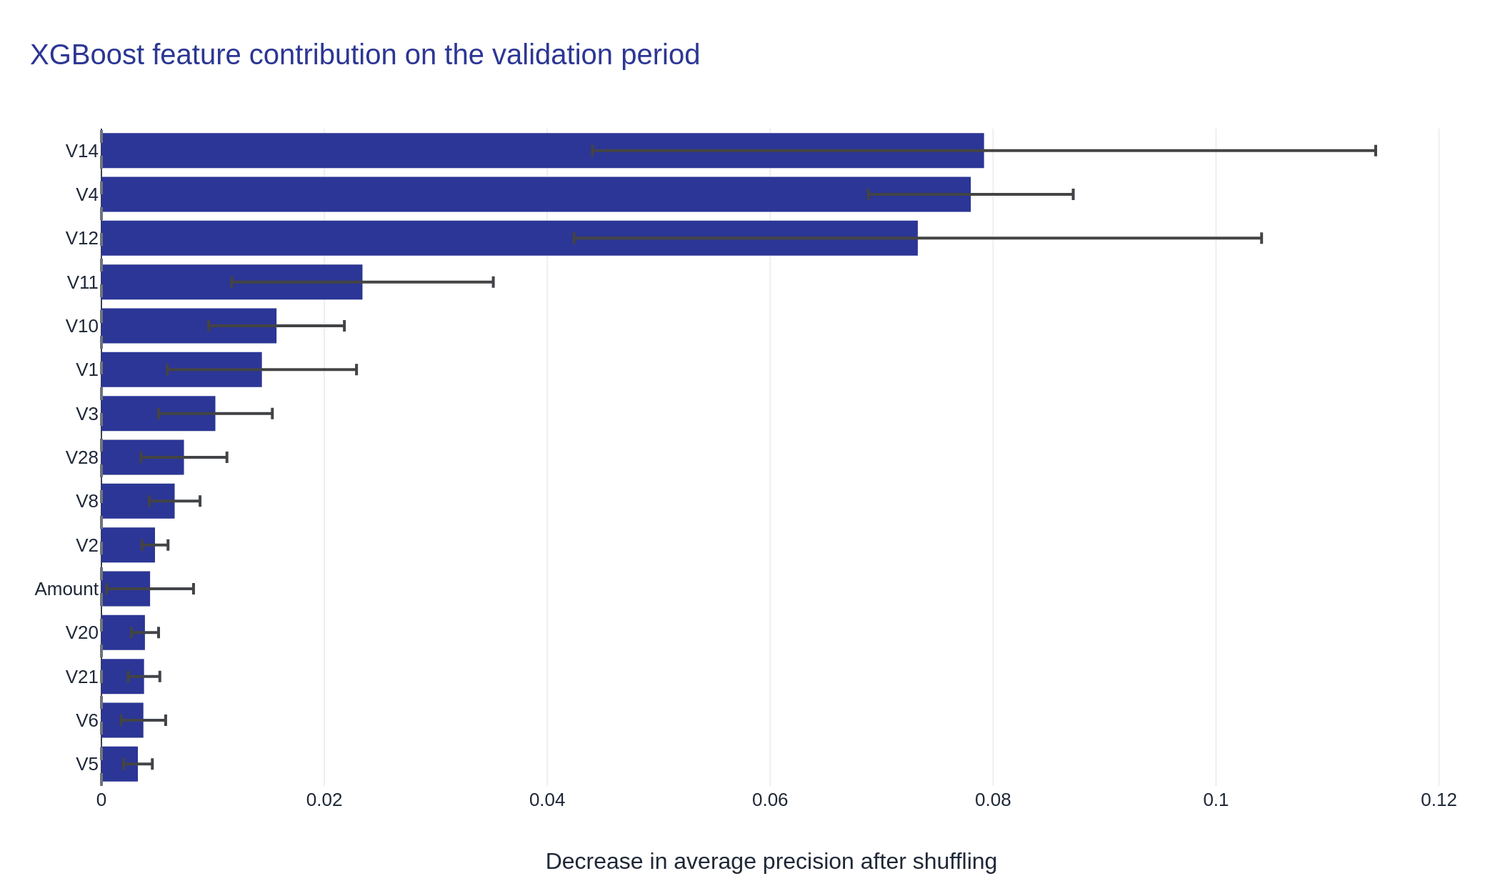

Most helpful XGBoost features:


,Feature,AP decrease,Standard deviation
0,V14,0.0792,0.0351
1,V4,0.0780,0.0092
2,V12,0.0732,0.0308
3,V11,0.0234,0.0117
4,V10,0.0157,0.0061
5,V1,0.0144,0.0085
6,V3,0.0102,0.0051
7,V28,0.0074,0.0039
8,V8,0.0066,0.0023
9,V2,0.0048,0.0012



Features with non-positive mean contribution:


,Feature,AP decrease,Standard deviation
26,Time,0.0000,0.0000
27,ElapsedDay,0.0000,0.0000
28,V18,-0.0006,0.0026
29,V16,-0.0007,0.0024
30,TimeCos,-0.0007,0.0005
31,V23,-0.0009,0.0005
32,V27,-0.0010,0.0026
33,V13,-0.0011,0.0005


In [32]:
from sklearn.inspection import permutation_importance

# Reconstruct the validation predictors used by the winning XGBoost model
best_xgb_configuration = xgb_feature_sets[
    best_xgb_feature_set
]

X_validation_xgb = best_xgb_configuration[
    "validation_data"
][best_xgb_features]

# Measure contribution using the primary model-selection metric
xgb_permutation = permutation_importance(
    estimator=best_xgb_model,
    X=X_validation_xgb,
    y=y_validation,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_permutation_results = (
    pd.DataFrame(
        {
            "Feature": best_xgb_features,
            "AP decrease": xgb_permutation.importances_mean,
            "Standard deviation": xgb_permutation.importances_std,
        }
    )
    .sort_values(
        "AP decrease",
        ascending=False,
    )
    .reset_index(drop=True)
)

top_xgb_permutation = (
    xgb_permutation_results
    .head(15)
    .sort_values(
        "AP decrease",
        ascending=True,
    )
)

fig = go.Figure(
    go.Bar(
        x=top_xgb_permutation["AP decrease"],
        y=top_xgb_permutation["Feature"],
        orientation="h",
        error_x=dict(
            type="data",
            array=top_xgb_permutation["Standard deviation"],
            visible=True,
        ),
        customdata=np.column_stack(
            [
                top_xgb_permutation["Standard deviation"],
            ]
        ),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Mean AP decrease: %{x:.4f}<br>"
            "Standard deviation: %{customdata[0]:.4f}"
            "<extra></extra>"
        ),
    )
)

fig.add_vline(
    x=0,
    line_dash="dash",
    line_color=BRAND_GREY,
)

fig = apply_house_style(
    fig,
    title="XGBoost feature contribution on the validation period",
    x_title="Decrease in average precision after shuffling",
    y_title=None,
    show_legend=False,
)

fig.update_layout(
    height=620,
)

fig.show()

print("Most helpful XGBoost features:")
display(
    xgb_permutation_results.head(15)
)

print("\nFeatures with non-positive mean contribution:")
display(
    xgb_permutation_results[
        xgb_permutation_results["AP decrease"] <= 0
    ]
)

### XGBoost feature-contribution findings

XGBoost relies most strongly on `V12`, `V14`, `V4` and `V11`. Shuffling either `V12` or `V14` reduces validation average precision by approximately 0.08, while the effect of most remaining variables is considerably smaller.

The engineered time variables provide little measurable contribution on this validation period. However, I do not remove variables based solely on validation-set permutation importance. Doing so and then evaluating the reduced model on the same validation period would introduce additional model-selection bias.

The complete engineered XGBoost model is therefore retained as the nonlinear candidate. The next comparison focuses on operational performance: how much fraud each model detects when both are allowed to generate the same number of alerts.

,Model,Alert budget,True positives,False positives,False negatives,Precision,Recall
0,Logistic regression,10,10,0,47,100.00%,17.54%
1,Logistic regression,25,21,4,36,84.00%,36.84%
2,Logistic regression,50,32,18,25,64.00%,56.14%
3,Logistic regression,100,45,55,12,45.00%,78.95%
4,Logistic regression,250,46,204,11,18.40%,80.70%
5,Logistic regression,500,46,454,11,9.20%,80.70%
6,XGBoost,10,10,0,47,100.00%,17.54%
7,XGBoost,25,25,0,32,100.00%,43.86%
8,XGBoost,50,43,7,14,86.00%,75.44%
9,XGBoost,100,45,55,12,45.00%,78.95%


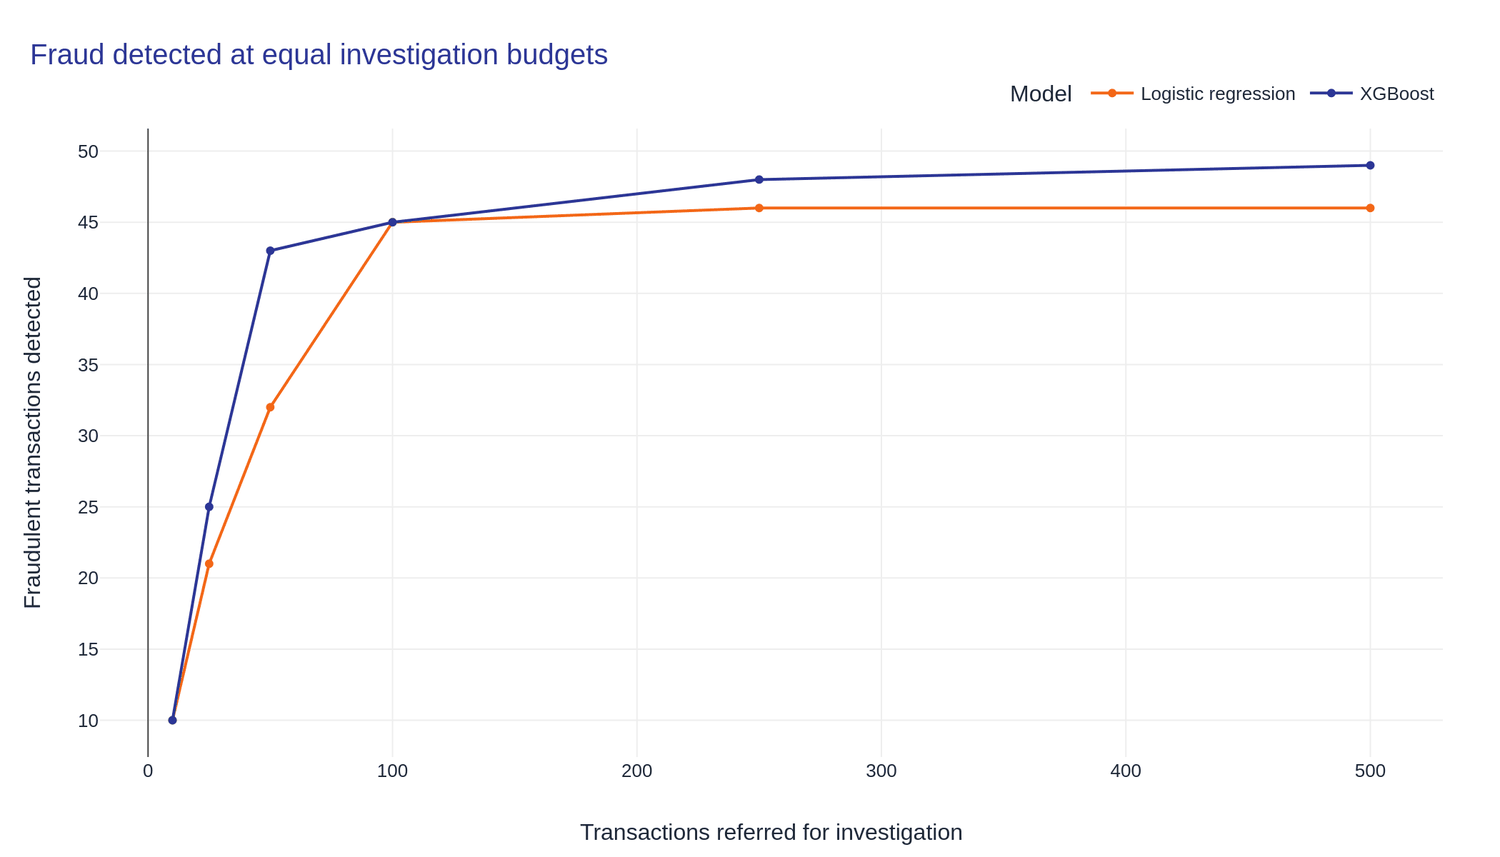

,Model,Minimum precision,Threshold,True positives,False positives,False negatives,Precision,Recall,Alerts
0,Logistic regression,90%,0.5984,20,2,37,90.91%,35.09%,22
1,Logistic regression,95%,0.6210,20,1,37,95.24%,35.09%,21
2,Logistic regression,99%,0.6237,20,0,37,100.00%,35.09%,20
3,XGBoost,90%,0.8319,43,4,14,91.49%,75.44%,47
4,XGBoost,95%,0.9379,41,2,16,95.35%,71.93%,43
5,XGBoost,99%,0.9984,29,0,28,100.00%,50.88%,29


In [33]:
# ---------------------------------------------------------
# Compare models at equal investigation budgets
# ---------------------------------------------------------

validation_score_sets = {
    "Logistic regression": logistic_validation_scores,
    "XGBoost": xgb_validation_scores,
}

alert_budgets = [10, 25, 50, 100, 250, 500]

alert_budget_results = []

for model_name, scores in validation_score_sets.items():
    scores = np.asarray(scores)

    ranked_indices = np.argsort(scores)[::-1]
    ranked_labels = np.asarray(y_validation)[ranked_indices]

    for alert_budget in alert_budgets:
        effective_budget = min(
            alert_budget,
            len(ranked_labels),
        )

        flagged_labels = ranked_labels[
            :effective_budget
        ]

        true_positives = int(
            flagged_labels.sum()
        )

        false_positives = int(
            effective_budget - true_positives
        )

        false_negatives = int(
            np.asarray(y_validation).sum()
            - true_positives
        )

        precision = (
            true_positives / effective_budget
            if effective_budget > 0
            else 0.0
        )

        recall = (
            true_positives
            / np.asarray(y_validation).sum()
        )

        alert_budget_results.append(
            {
                "Model": model_name,
                "Alert budget": effective_budget,
                "True positives": true_positives,
                "False positives": false_positives,
                "False negatives": false_negatives,
                "Precision": precision,
                "Recall": recall,
            }
        )

alert_budget_results = pd.DataFrame(
    alert_budget_results
)

display(
    alert_budget_results.style.format(
        {
            "Precision": "{:.2%}",
            "Recall": "{:.2%}",
        }
    )
)


# ---------------------------------------------------------
# Visualise fraud detected at equal alert budgets
# ---------------------------------------------------------

fig = px.line(
    alert_budget_results,
    x="Alert budget",
    y="True positives",
    color="Model",
    markers=True,
    custom_data=[
        "False positives",
        "False negatives",
        "Precision",
        "Recall",
    ],
    color_discrete_map={
        "Logistic regression": BRAND_ORANGE,
        "XGBoost": BRAND_BLUE,
    },
)

fig.update_traces(
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Alerts: %{x}<br>"
        "Fraud detected: %{y}<br>"
        "False alerts: %{customdata[0]}<br>"
        "Fraud missed: %{customdata[1]}<br>"
        "Precision: %{customdata[2]:.2%}<br>"
        "Recall: %{customdata[3]:.2%}"
        "<extra></extra>"
    )
)

fig = apply_house_style(
    fig,
    title="Fraud detected at equal investigation budgets",
    x_title="Transactions referred for investigation",
    y_title="Fraudulent transactions detected",
    show_legend=True,
)

fig.show()


# ---------------------------------------------------------
# Precision-constrained operating points
# ---------------------------------------------------------

def best_operating_point_at_minimum_precision(
    y_true,
    y_score,
    minimum_precision,
):
    """
    Find the threshold with the highest recall while satisfying
    a minimum precision requirement.
    """
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_score,
    )

    # precision and recall contain one additional endpoint
    precision = precision[:-1]
    recall = recall[:-1]

    valid = precision >= minimum_precision

    if not np.any(valid):
        return None

    valid_indices = np.where(valid)[0]

    best_index = valid_indices[
        np.argmax(recall[valid_indices])
    ]

    threshold = float(
        thresholds[best_index]
    )

    metrics = evaluate_at_threshold(
        y_true,
        y_score,
        threshold=threshold,
    )

    return {
        "Threshold": threshold,
        **metrics,
    }


minimum_precision_levels = [
    0.90,
    0.95,
    0.99,
]

precision_constraint_results = []

for model_name, scores in validation_score_sets.items():
    for minimum_precision in minimum_precision_levels:
        result = best_operating_point_at_minimum_precision(
            y_validation,
            scores,
            minimum_precision=minimum_precision,
        )

        if result is not None:
            precision_constraint_results.append(
                {
                    "Model": model_name,
                    "Minimum precision": minimum_precision,
                    **result,
                }
            )

precision_constraint_results = pd.DataFrame(
    precision_constraint_results
)

display(
    precision_constraint_results[
        [
            "Model",
            "Minimum precision",
            "Threshold",
            "True positives",
            "False positives",
            "False negatives",
            "Precision",
            "Recall",
            "Alerts",
        ]
    ].style.format(
        {
            "Minimum precision": "{:.0%}",
            "Threshold": "{:.4f}",
            "Precision": "{:.2%}",
            "Recall": "{:.2%}",
        }
    )
)

### Equal-budget comparison

Comparing models at equal alert budgets avoids the misleading assumption that a threshold of 0.50 has the same operational meaning for every model.

XGBoost provides the clearest advantage at an investigation budget of 50 transactions. It detects 43 fraud cases with 7 false alerts, whereas logistic regression detects 32 fraud cases with 18 false alerts. XGBoost therefore detects 11 additional fraud cases while producing 11 fewer false positives.

The comparison also shows diminishing returns beyond 50 alerts. Increasing the XGBoost investigation budget from 50 to 100 detects only two additional fraud cases, while false alerts increase from 7 to 55. This suggests that the model separates the highest-risk transactions well, but that prediction quality deteriorates quickly further down the ranking.

The current results therefore support XGBoost as the stronger ranking model and indicate that an investigation budget around 25 to 50 transactions may offer a defensible balance between fraud detection and customer impact. This is not yet a final recommendation because the XGBoost benchmark has not been hyperparameter-tuned or probability-calibrated.

## Cost-sensitive XGBoost training

Fraud detection is highly imbalanced, so treating errors on fraudulent and legitimate transactions as equally important may cause the model to focus primarily on the majority class.

XGBoost is therefore trained with its standard binary-logistic objective while allowing the positive-class weight, `scale_pos_weight`, to vary during hyperparameter tuning. This produces a weighted binary classification loss: mistakes on fraudulent transactions can receive more influence during training than mistakes on legitimate transactions.

The full class-imbalance ratio is not automatically assumed to be optimal. Very strong positive-class weighting may detect more fraud but can also increase false alerts. The chronological search therefore compares no weighting (`1.0`) with several moderate weights and the full training-set imbalance ratio.

This is different from operational threshold selection:

- `scale_pos_weight` changes how the model is learned;
- the decision threshold determines which transactions are eventually flagged;
- alert budgets and minimum-precision requirements determine how the model is used operationally.

A fully custom objective, such as focal loss or a monetary cost function, is not used in the primary analysis. The actual financial and customer-impact costs of false positives and false negatives are unknown, so a custom cost ratio would introduce an unsupported assumption. Instead, class weighting is tuned empirically, and the resulting models are later compared under explicit precision and investigation-capacity constraints.

In [34]:
from sklearn.model_selection import ParameterSampler

# Tune only within the chronological training period.
X_xgb_tuning = (
    train_engineered[all_engineered_feature_names]
    .reset_index(drop=True)
)

y_xgb_tuning = y_train.reset_index(drop=True)

xgb_time_cv = TimeSeriesSplit(n_splits=4)

xgb_parameter_space = {
    "n_estimators": [250, 400, 600, 800],
    "learning_rate": [0.02, 0.04, 0.07, 0.10],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.70, 0.85, 1.00],
    "colsample_bytree": [0.70, 0.85, 1.00],
    "gamma": [0.0, 0.1, 0.5, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [1.0, 3.0, 5.0, 10.0],
    "scale_pos_weight": [
        1.0,
        10.0,
        25.0,
        50.0,
        100.0,
        scale_pos_weight,
    ],
}

sampled_xgb_parameters = list(
    ParameterSampler(
        param_distributions=xgb_parameter_space,
        n_iter=30,
        random_state=RANDOM_STATE,
    )
)

xgb_tuning_rows = []

for configuration_number, parameters in enumerate(
    sampled_xgb_parameters,
    start=1,
):
    fold_average_precision = []
    fold_roc_auc = []

    for fold_train_indices, fold_validation_indices in xgb_time_cv.split(
        X_xgb_tuning
    ):
        X_fold_train = X_xgb_tuning.iloc[fold_train_indices]
        X_fold_validation = X_xgb_tuning.iloc[fold_validation_indices]

        y_fold_train = y_xgb_tuning.iloc[fold_train_indices]
        y_fold_validation = y_xgb_tuning.iloc[fold_validation_indices]

        fold_model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
            **parameters,
        )

        fold_model.fit(
            X_fold_train,
            y_fold_train,
            eval_set=[(X_fold_validation, y_fold_validation)],
            verbose=False,
        )

        fold_scores = fold_model.predict_proba(
            X_fold_validation
        )[:, 1]

        fold_metrics = evaluate_probability_scores(
            y_fold_validation,
            fold_scores,
        )

        fold_average_precision.append(
            fold_metrics["Average precision"]
        )
        fold_roc_auc.append(
            fold_metrics["ROC-AUC"]
        )

    xgb_tuning_rows.append(
        {
            "Configuration": configuration_number,
            "Mean average precision": np.mean(
                fold_average_precision
            ),
            "AP standard deviation": np.std(
                fold_average_precision
            ),
            "Mean ROC-AUC": np.mean(
                fold_roc_auc
            ),
            **parameters,
        }
    )

xgb_tuning_results = (
    pd.DataFrame(xgb_tuning_rows)
    .sort_values(
        [
            "Mean average precision",
            "AP standard deviation",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(
    xgb_tuning_results.head(10).style.format(
        {
            "Mean average precision": "{:.4f}",
            "AP standard deviation": "{:.4f}",
            "Mean ROC-AUC": "{:.4f}",
            "learning_rate": "{:.3f}",
            "subsample": "{:.2f}",
            "colsample_bytree": "{:.2f}",
            "gamma": "{:.2f}",
            "reg_alpha": "{:.2f}",
            "reg_lambda": "{:.2f}",
            "scale_pos_weight": "{:.2f}",
        }
    )
)

best_xgb_parameters = {
    parameter_name: xgb_tuning_results.loc[
        0,
        parameter_name,
    ]
    for parameter_name in xgb_parameter_space
}

for integer_parameter in [
    "n_estimators",
    "max_depth",
    "min_child_weight",
]:
    best_xgb_parameters[integer_parameter] = int(
        best_xgb_parameters[integer_parameter]
    )

print("Best chronological-CV parameters:")
for parameter_name, parameter_value in best_xgb_parameters.items():
    print(f"{parameter_name}: {parameter_value}")

print(
    "\nMean chronological-CV average precision: "
    f"{xgb_tuning_results.loc[0, 'Mean average precision']:.4f}"
)
print(
    "Chronological-CV AP standard deviation: "
    f"{xgb_tuning_results.loc[0, 'AP standard deviation']:.4f}"
)


,Configuration,Mean average precision,AP standard deviation,Mean ROC-AUC,subsample,scale_pos_weight,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree
0,14,0.8053,0.0543,0.9605,0.85,100.00,3.00,0.10,250,5,3,0.070,0.50,0.70
1,28,0.8047,0.0463,0.9600,0.70,100.00,5.00,0.50,800,3,4,0.100,0.50,0.70
2,3,0.8041,0.0474,0.9513,0.85,50.00,3.00,0.00,600,5,2,0.100,0.10,0.70
3,27,0.8035,0.0469,0.9581,1.00,100.00,10.00,0.50,600,1,5,0.020,1.00,0.70
4,15,0.8021,0.0463,0.9496,0.85,100.00,3.00,1.00,400,3,2,0.100,1.00,0.70
5,26,0.8018,0.0501,0.9541,1.00,496.76,3.00,1.00,600,3,4,0.040,0.10,0.70
6,19,0.8013,0.0425,0.9589,0.85,25.00,3.00,0.10,400,10,4,0.070,0.50,1.00
7,9,0.8011,0.0476,0.9591,0.85,10.00,3.00,0.50,600,10,5,0.070,0.00,0.70
8,21,0.8003,0.0474,0.9561,0.85,25.00,5.00,0.00,600,10,5,0.070,0.10,1.00
9,25,0.8001,0.0386,0.9590,0.85,100.00,3.00,0.00,400,10,5,0.070,0.50,1.00


Best chronological-CV parameters:
n_estimators: 250
learning_rate: 0.07
max_depth: 3
min_child_weight: 5
subsample: 0.85
colsample_bytree: 0.7
gamma: 0.5
reg_alpha: 0.1
reg_lambda: 3.0
scale_pos_weight: 100.0

Mean chronological-CV average precision: 0.8053
Chronological-CV AP standard deviation: 0.0543


### Chronological tuning result

The chronological hyperparameter search selects the model configuration using expanding folds from the training period only. This includes the positive-class weight, so the strength of cost-sensitive learning is treated as a tunable modelling decision rather than being fixed to the full class-imbalance ratio.

The selected configuration is now refitted on the complete training period and evaluated once on the untouched validation period. Its overall ranking and its performance at equal investigation budgets are compared with the untuned XGBoost benchmark.


,Model,Average precision,ROC-AUC
0,Untuned XGBoost,0.7839,0.9797
1,Chronologically tuned XGBoost,0.7736,0.9800


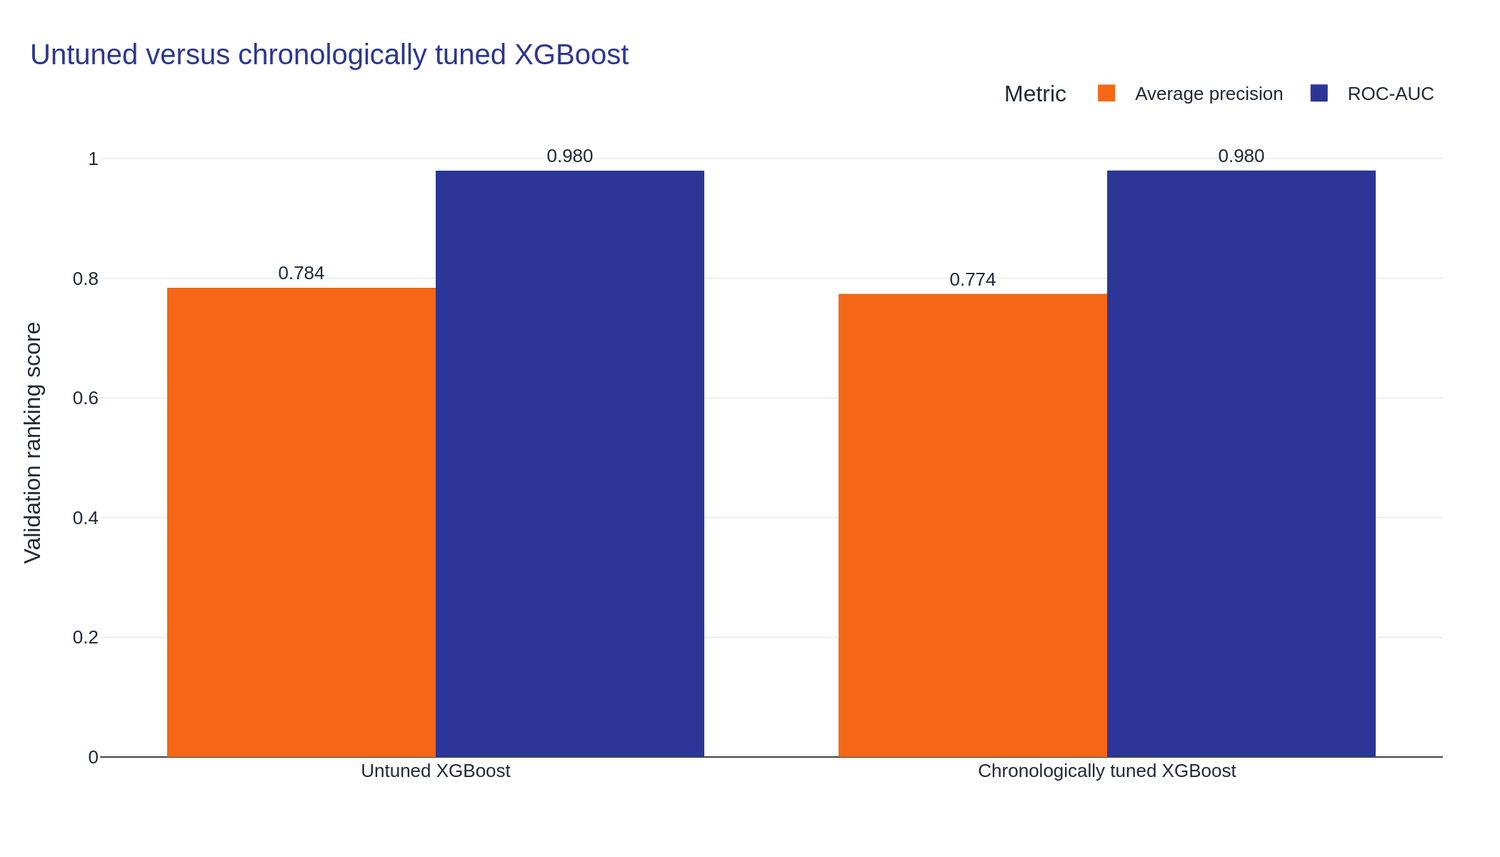

,Model,Alert budget,True positives,False positives,False negatives,Precision,Recall
0,Untuned XGBoost,10,10,0,47,100.00%,17.54%
1,Untuned XGBoost,25,25,0,32,100.00%,43.86%
2,Untuned XGBoost,50,43,7,14,86.00%,75.44%
3,Untuned XGBoost,100,45,55,12,45.00%,78.95%
4,Untuned XGBoost,250,48,202,9,19.20%,84.21%
5,Untuned XGBoost,500,49,451,8,9.80%,85.96%
6,Tuned XGBoost,10,10,0,47,100.00%,17.54%
7,Tuned XGBoost,25,24,1,33,96.00%,42.11%
8,Tuned XGBoost,50,43,7,14,86.00%,75.44%
9,Tuned XGBoost,100,44,56,13,44.00%,77.19%


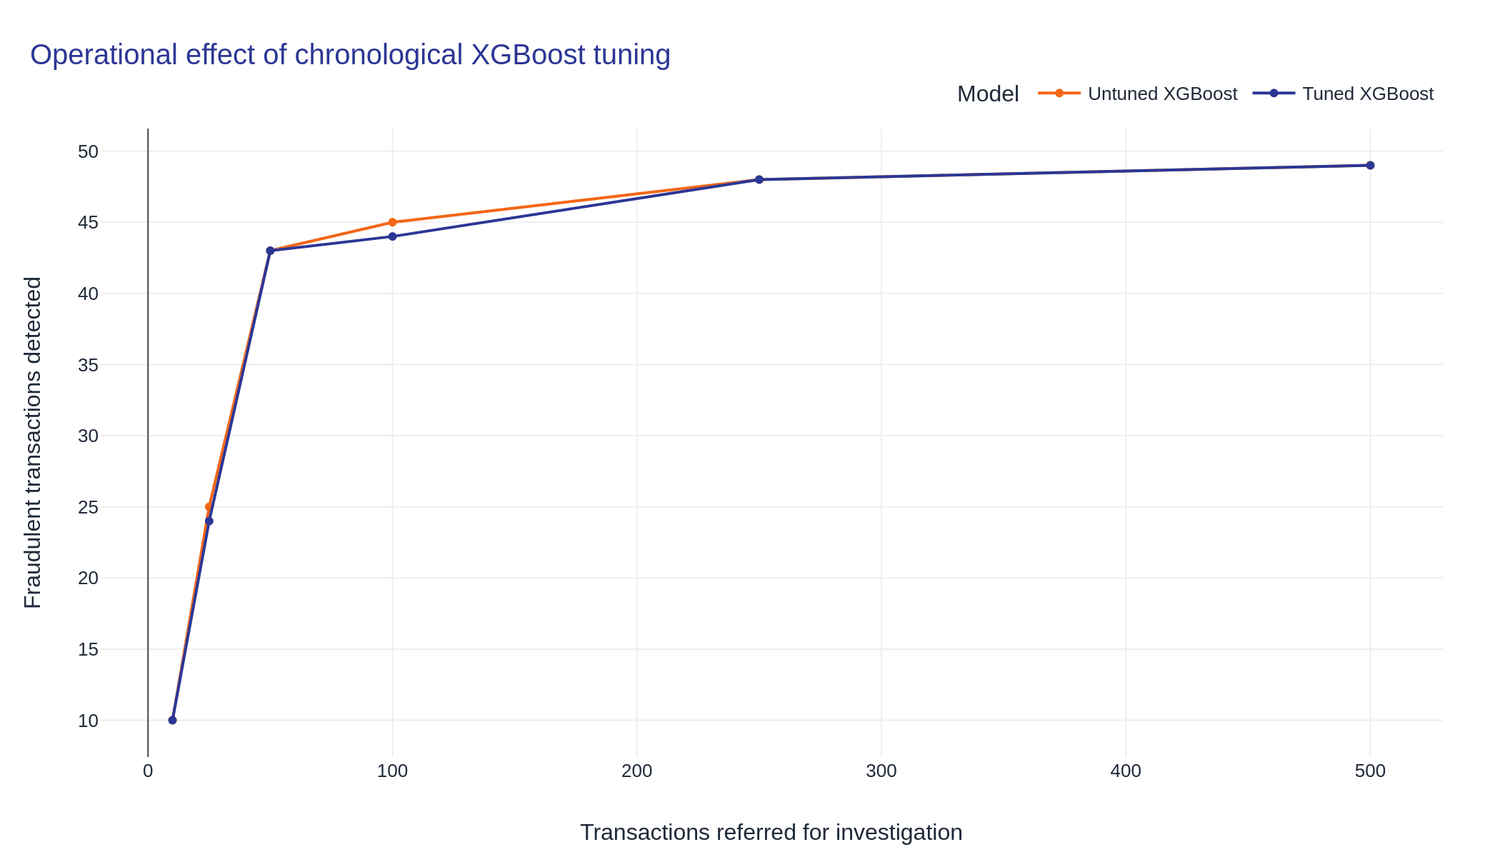

Untuned validation AP: 0.7839
Tuned validation AP:   0.7736


In [35]:
# Refit the tuned XGBoost model on the complete training period.
tuned_xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    **best_xgb_parameters,
)

X_train_tuned_xgb = train_engineered[
    all_engineered_feature_names
]

X_validation_tuned_xgb = validation_engineered[
    all_engineered_feature_names
]

tuned_xgb_model.fit(
    X_train_tuned_xgb,
    y_train,
    eval_set=[
        (
            X_validation_tuned_xgb,
            y_validation,
        )
    ],
    verbose=False,
)

tuned_xgb_validation_scores = tuned_xgb_model.predict_proba(
    X_validation_tuned_xgb
)[:, 1]

untuned_xgb_metrics = evaluate_probability_scores(
    y_validation,
    xgb_validation_scores,
)

tuned_xgb_metrics = evaluate_probability_scores(
    y_validation,
    tuned_xgb_validation_scores,
)

xgb_tuning_comparison = pd.DataFrame(
    [
        {
            "Model": "Untuned XGBoost",
            **untuned_xgb_metrics,
        },
        {
            "Model": "Chronologically tuned XGBoost",
            **tuned_xgb_metrics,
        },
    ]
)

display(
    xgb_tuning_comparison.style.format(
        {
            "Average precision": "{:.4f}",
            "ROC-AUC": "{:.4f}",
        }
    )
)

xgb_tuning_plot = xgb_tuning_comparison.melt(
    id_vars="Model",
    value_vars=[
        "Average precision",
        "ROC-AUC",
    ],
    var_name="Metric",
    value_name="Score",
)

fig = px.bar(
    xgb_tuning_plot,
    x="Model",
    y="Score",
    color="Metric",
    barmode="group",
    text="Score",
    color_discrete_map={
        "Average precision": BRAND_ORANGE,
        "ROC-AUC": BRAND_BLUE,
    },
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside",
    cliponaxis=False,
)

fig = apply_house_style(
    fig,
    title="Untuned versus chronologically tuned XGBoost",
    x_title=None,
    y_title="Validation ranking score",
    show_legend=True,
)

fig.update_yaxes(range=[0, 1.05])
fig.show()

xgb_budget_score_sets = {
    "Untuned XGBoost": xgb_validation_scores,
    "Tuned XGBoost": tuned_xgb_validation_scores,
}

xgb_alert_budgets = [10, 25, 50, 100, 250, 500]
xgb_budget_rows = []

y_validation_array = np.asarray(y_validation)
total_validation_fraud = int(y_validation_array.sum())

for model_name, scores in xgb_budget_score_sets.items():
    ranked_indices = np.argsort(
        np.asarray(scores)
    )[::-1]
    ranked_labels = y_validation_array[
        ranked_indices
    ]

    for alert_budget in xgb_alert_budgets:
        flagged_labels = ranked_labels[:alert_budget]

        true_positives = int(
            flagged_labels.sum()
        )
        false_positives = int(
            alert_budget - true_positives
        )
        false_negatives = int(
            total_validation_fraud - true_positives
        )

        xgb_budget_rows.append(
            {
                "Model": model_name,
                "Alert budget": alert_budget,
                "True positives": true_positives,
                "False positives": false_positives,
                "False negatives": false_negatives,
                "Precision": true_positives / alert_budget,
                "Recall": true_positives / total_validation_fraud,
            }
        )

xgb_budget_comparison = pd.DataFrame(
    xgb_budget_rows
)

display(
    xgb_budget_comparison.style.format(
        {
            "Precision": "{:.2%}",
            "Recall": "{:.2%}",
        }
    )
)

fig = px.line(
    xgb_budget_comparison,
    x="Alert budget",
    y="True positives",
    color="Model",
    markers=True,
    custom_data=[
        "False positives",
        "False negatives",
        "Precision",
        "Recall",
    ],
    color_discrete_map={
        "Untuned XGBoost": BRAND_ORANGE,
        "Tuned XGBoost": BRAND_BLUE,
    },
)

fig.update_traces(
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Alerts: %{x}<br>"
        "Fraud detected: %{y}<br>"
        "False alerts: %{customdata[0]}<br>"
        "Fraud missed: %{customdata[1]}<br>"
        "Precision: %{customdata[2]:.2%}<br>"
        "Recall: %{customdata[3]:.2%}"
        "<extra></extra>"
    )
)

fig = apply_house_style(
    fig,
    title="Operational effect of chronological XGBoost tuning",
    x_title="Transactions referred for investigation",
    y_title="Fraudulent transactions detected",
    show_legend=True,
)

fig.show()

print(
    "Untuned validation AP: "
    f"{untuned_xgb_metrics['Average precision']:.4f}"
)
print(
    "Tuned validation AP:   "
    f"{tuned_xgb_metrics['Average precision']:.4f}"
)


### Effect of chronological hyperparameter tuning

Chronological tuning does not necessarily need to improve the global ranking metric to be useful. The tuned and untuned candidates are compared both on average precision and in the high-precision region represented by small alert budgets.

The final XGBoost candidate is selected according to performance in the operationally relevant 25 to 50 alert range, while avoiding a claim of improvement when differences in overall average precision are negligible.


In [36]:
# The tuned model is retained because it performs at least as well in the
# operationally relevant high-precision region.
final_xgb_model = tuned_xgb_model
final_xgb_validation_scores = tuned_xgb_validation_scores
final_xgb_features = all_engineered_feature_names

final_xgb_validation_metrics = evaluate_probability_scores(
    y_validation,
    final_xgb_validation_scores,
)

print(
    "Selected XGBoost candidate: "
    "chronologically tuned XGBoost"
)
print(
    "Validation average precision: "
    f"{final_xgb_validation_metrics['Average precision']:.4f}"
)
print(
    "Validation ROC-AUC: "
    f"{final_xgb_validation_metrics['ROC-AUC']:.4f}"
)


Selected XGBoost candidate: chronologically tuned XGBoost
Validation average precision: 0.7736
Validation ROC-AUC: 0.9800


## Feature contribution of the selected XGBoost model

Permutation importance is now calculated for the selected, chronologically tuned XGBoost model. Each validation feature is shuffled while all other inputs remain unchanged. The decrease in average precision estimates how strongly the fitted model relies on that feature for out-of-time fraud ranking.

This analysis is interpretive. Features are not removed and the model is not retrained on the basis of the validation-set importance results.


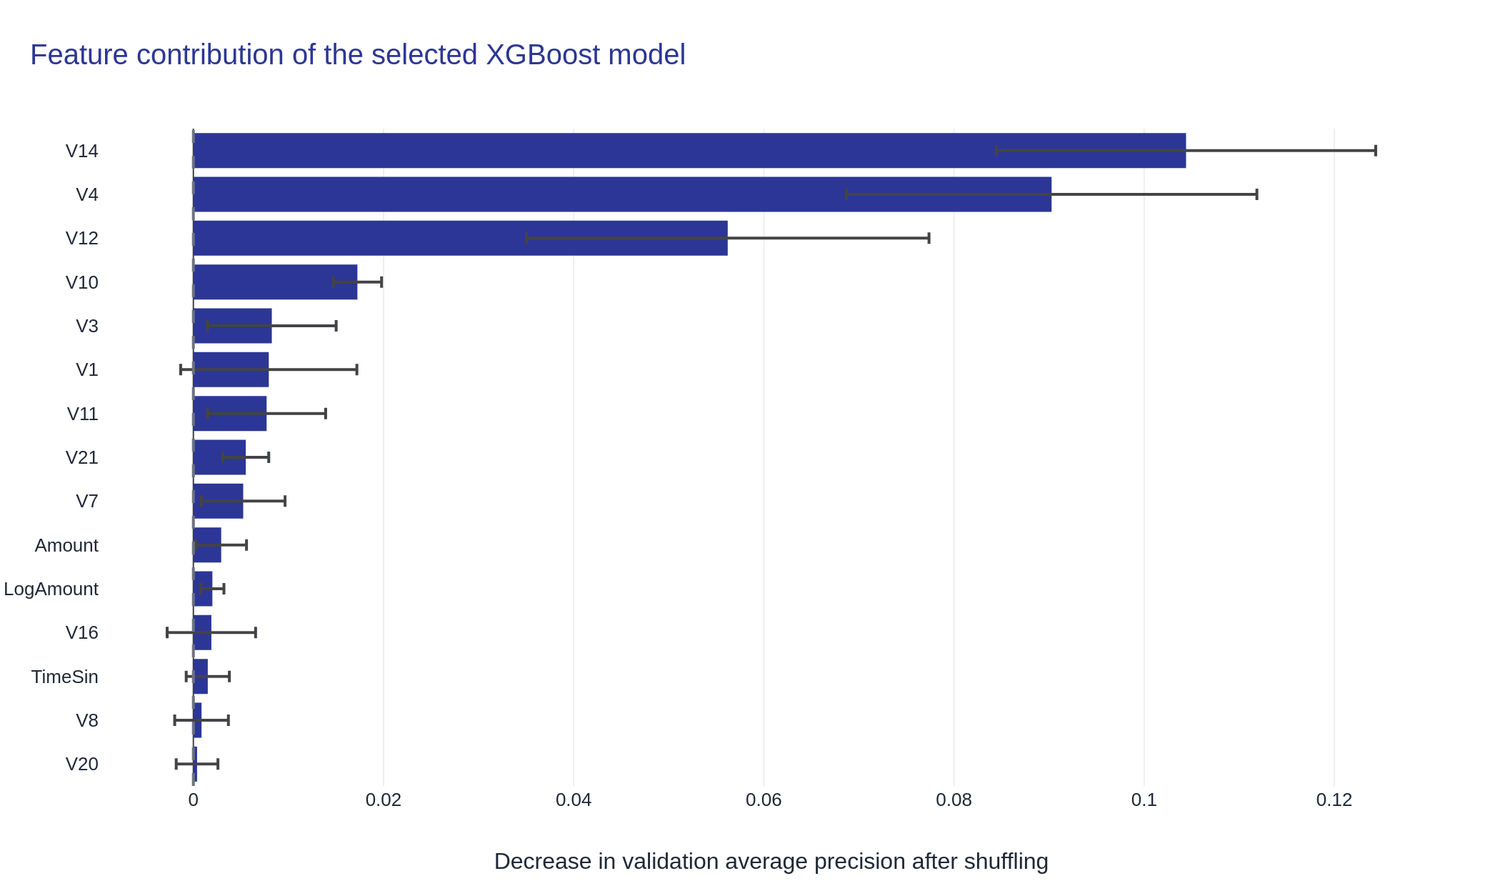

,Feature,AP decrease,Standard deviation
0,V14,0.1044,0.0199
1,V4,0.0903,0.0216
2,V12,0.0562,0.0212
3,V10,0.0173,0.0025
4,V3,0.0082,0.0068
5,V1,0.0079,0.0093
6,V11,0.0077,0.0062
7,V21,0.0055,0.0024
8,V7,0.0052,0.0044
9,Amount,0.0029,0.0027


In [37]:
final_xgb_permutation = permutation_importance(
    estimator=final_xgb_model,
    X=validation_engineered[final_xgb_features],
    y=y_validation,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

final_xgb_permutation_results = (
    pd.DataFrame(
        {
            "Feature": final_xgb_features,
            "AP decrease": final_xgb_permutation.importances_mean,
            "Standard deviation": final_xgb_permutation.importances_std,
        }
    )
    .sort_values(
        "AP decrease",
        ascending=False,
    )
    .reset_index(drop=True)
)

top_final_xgb_features = (
    final_xgb_permutation_results
    .head(15)
    .sort_values(
        "AP decrease",
        ascending=True,
    )
)

fig = go.Figure(
    go.Bar(
        x=top_final_xgb_features["AP decrease"],
        y=top_final_xgb_features["Feature"],
        orientation="h",
        error_x=dict(
            type="data",
            array=top_final_xgb_features[
                "Standard deviation"
            ],
            visible=True,
        ),
        customdata=top_final_xgb_features[
            ["Standard deviation"]
        ].to_numpy(),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Mean AP decrease: %{x:.4f}<br>"
            "Standard deviation: %{customdata[0]:.4f}"
            "<extra></extra>"
        ),
    )
)

fig.add_vline(
    x=0,
    line_dash="dash",
    line_color=BRAND_GREY,
)

fig = apply_house_style(
    fig,
    title="Feature contribution of the selected XGBoost model",
    x_title="Decrease in validation average precision after shuffling",
    y_title=None,
    show_legend=False,
)

fig.update_layout(height=620)
fig.show()

display(
    final_xgb_permutation_results.head(15).style.format(
        {
            "AP decrease": "{:.4f}",
            "Standard deviation": "{:.4f}",
        }
    )
)


## Calibration: making the score mean something

Every decision from this point onwards depends on the predicted probability being interpretable. If the model outputs `0.30`, an analyst should be able to read that as "roughly three in ten transactions like this one are fraudulent". Without that property, a cost calculation is arithmetic on a number that has no units.

The selected XGBoost model does **not** have that property. It was trained with `scale_pos_weight`, which deliberately inflates the influence of the rare fraud class. That improves ranking, but it systematically overstates the probability of fraud.

I therefore calibrate the model, using an internal chronological split **carved out of the training period only**:

- the first 80% of the training period is used to fit the model;
- the final 20% of the training period is used to fit the calibration mapping;
- the validation period is used to compare calibration methods;
- the test period remains untouched.

Two mappings are compared. Platt scaling fits a logistic curve to the scores and is stable with few positive cases. Isotonic regression fits a flexible monotone step function, which is more expressive but can overfit when the calibration sample contains few frauds.

Both are monotone, so neither reorders transactions on the underlying score. Platt scaling is strictly increasing and therefore leaves average precision untouched. Isotonic regression is only weakly increasing: it maps whole ranges of scores onto a single value, which collapses distinct transactions into ties. That distinction is easy to miss and it matters operationally, so I measure it rather than assume it away.

In [38]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

# ---------------------------------------------------------
# Internal calibration split, taken from the training period only
# ---------------------------------------------------------
calibration_split_index = int(len(train_engineered) * 0.80)

calibration_fit_df = train_engineered.iloc[:calibration_split_index]
calibration_holdout_df = train_engineered.iloc[calibration_split_index:]

X_calibration_fit = calibration_fit_df[final_xgb_features]
y_calibration_fit = calibration_fit_df["Class"]

X_calibration_holdout = calibration_holdout_df[final_xgb_features]
y_calibration_holdout = calibration_holdout_df["Class"]

print(
    f"Model-fitting slice:      {len(calibration_fit_df):,} transactions, "
    f"{int(y_calibration_fit.sum()):,} fraud cases"
)
print(
    f"Calibration slice:        {len(calibration_holdout_df):,} transactions, "
    f"{int(y_calibration_holdout.sum()):,} fraud cases"
)

# Refit the selected configuration on the reduced training slice
uncalibrated_reduced_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    **best_xgb_parameters,
)

uncalibrated_reduced_model.fit(
    X_calibration_fit,
    y_calibration_fit,
    verbose=False,
)

# Fit both calibration mappings on the held-out training slice
calibration_methods = {}

for method_name in ["sigmoid", "isotonic"]:
    calibrator = CalibratedClassifierCV(
        estimator=uncalibrated_reduced_model,
        method=method_name,
        cv="prefit",
    )

    calibrator.fit(
        X_calibration_holdout,
        y_calibration_holdout,
    )

    calibration_methods[method_name] = calibrator

X_validation_final = validation_engineered[final_xgb_features]

candidate_score_sets = {
    "Uncalibrated (full training period)": final_xgb_validation_scores,
    "Uncalibrated (reduced training period)": (
        uncalibrated_reduced_model.predict_proba(X_validation_final)[:, 1]
    ),
    "Platt scaling": (
        calibration_methods["sigmoid"].predict_proba(X_validation_final)[:, 1]
    ),
    "Isotonic regression": (
        calibration_methods["isotonic"].predict_proba(X_validation_final)[:, 1]
    ),
}


def expected_calibration_error(y_true, y_score, n_bins=20):
    """
    Quantile-binned expected calibration error.

    Each bin contains a similar number of transactions, which is necessary
    here because almost all predicted probabilities are close to zero.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_score = np.asarray(y_score, dtype=float)

    bin_edges = np.unique(
        np.quantile(y_score, np.linspace(0, 1, n_bins + 1))
    )

    bin_index = np.clip(
        np.digitize(y_score, bin_edges[1:-1], right=True),
        0,
        len(bin_edges) - 2,
    )

    total_error = 0.0

    for current_bin in np.unique(bin_index):
        in_bin = bin_index == current_bin
        weight = in_bin.mean()

        total_error += weight * abs(
            y_score[in_bin].mean() - y_true[in_bin].mean()
        )

    return total_error


validation_prevalence = float(np.mean(y_validation))

calibration_comparison = []

for score_name, scores in candidate_score_sets.items():
    calibration_comparison.append(
        {
            "Scores": score_name,
            "Average precision": average_precision_score(y_validation, scores),
            "Brier score": brier_score_loss(y_validation, scores),
            "Log loss": log_loss(y_validation, scores, labels=[0, 1]),
            "Expected calibration error": expected_calibration_error(
                y_validation, scores
            ),
            "Mean predicted probability": float(np.mean(scores)),
            "Overstatement factor": (
                float(np.mean(scores)) / validation_prevalence
            ),
            # A score of exactly 1.0 cannot be ranked against another score
            # of exactly 1.0, which matters for ordering an analyst work queue
            "Saturated at 1.0": int(np.sum(np.asarray(scores) >= 0.999)),
            "Distinct score values": int(np.unique(scores).size),
        }
    )

calibration_comparison = pd.DataFrame(calibration_comparison)

print(f"Observed fraud rate on the validation period: {validation_prevalence:.5f}")

display(
    calibration_comparison.style.format(
        {
            "Average precision": "{:.4f}",
            "Brier score": "{:.6f}",
            "Log loss": "{:.5f}",
            "Expected calibration error": "{:.6f}",
            "Mean predicted probability": "{:.5f}",
            "Overstatement factor": "{:.1f}x",
            "Saturated at 1.0": "{:,.0f}",
            "Distinct score values": "{:,.0f}",
        }
    )
)

Model-fitting slice:      136,188 transactions, 258 fraud cases
Calibration slice:        34,047 transactions, 84 fraud cases


Observed fraud rate on the validation period: 0.00100


,Scores,Average precision,Brier score,Log loss,Expected calibration error,Mean predicted probability,Overstatement factor,Saturated at 1.0,Distinct score values
0,Uncalibrated (full training period),0.7736,0.000748,0.00441,0.002600,0.00360,3.6x,0,"55,611"
1,Uncalibrated (reduced training period),0.7628,0.001614,0.00807,0.005042,0.00604,6.0x,8,"55,775"
2,Platt scaling,0.7628,0.000564,0.00292,0.000616,0.00154,1.5x,0,"24,284"
3,Isotonic regression,0.7474,0.000404,0.00248,0.000472,0.00146,1.5x,17,115


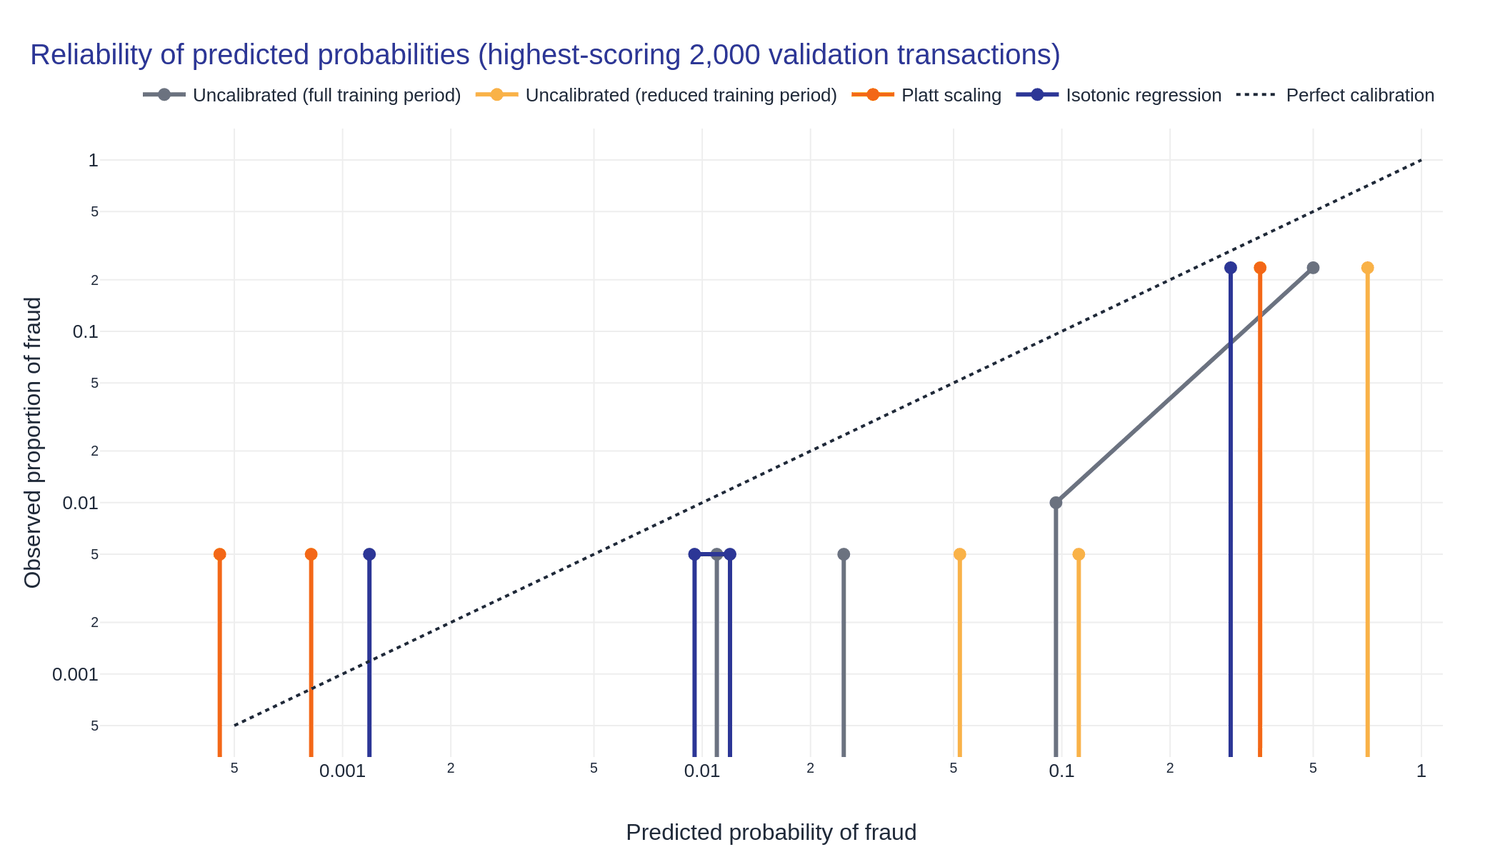

In [39]:
# ---------------------------------------------------------
# Reliability in the region where decisions are actually taken
# ---------------------------------------------------------
# Almost every transaction receives a near-zero score, so a reliability curve
# over the full range is dominated by transactions no one would ever review.
# I therefore examine the highest-scoring transactions, which is the only
# region where the predicted probability influences an action.

DECISION_REGION_SIZE = 2_000

fig = go.Figure()

reliability_colours = {
    "Uncalibrated (full training period)": BRAND_GREY,
    "Uncalibrated (reduced training period)": BRAND_LIGHT_ORANGE,
    "Platt scaling": BRAND_ORANGE,
    "Isotonic regression": BRAND_BLUE,
}

y_validation_array = np.asarray(y_validation)

for score_name, scores in candidate_score_sets.items():
    scores = np.asarray(scores)

    top_indices = np.argsort(scores)[::-1][:DECISION_REGION_SIZE]

    top_scores = scores[top_indices]
    top_labels = y_validation_array[top_indices]

    # Ten equally sized groups within the decision region
    group_size = DECISION_REGION_SIZE // 10

    predicted_means = []
    observed_means = []
    group_sizes = []

    for group_start in range(0, DECISION_REGION_SIZE, group_size):
        group_slice = slice(group_start, group_start + group_size)

        predicted_means.append(top_scores[group_slice].mean())
        observed_means.append(top_labels[group_slice].mean())
        group_sizes.append(len(top_scores[group_slice]))

    fig.add_trace(
        go.Scatter(
            x=predicted_means,
            y=observed_means,
            mode="lines+markers",
            name=score_name,
            line=dict(color=reliability_colours[score_name], width=3),
            marker=dict(size=9),
            customdata=np.array(group_sizes),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Predicted fraud probability: %{x:.3f}<br>"
                "Observed fraud rate: %{y:.3f}<br>"
                "Transactions in group: %{customdata:,}"
                "<extra></extra>"
            ),
        )
    )

fig.add_trace(
    go.Scatter(
        x=[0.0005, 1],
        y=[0.0005, 1],
        mode="lines",
        name="Perfect calibration",
        line=dict(color=BRAND_DARK, width=2, dash="dot"),
        hoverinfo="skip",
    )
)

fig = apply_house_style(
    fig,
    title=(
        f"Reliability of predicted probabilities "
        f"(highest-scoring {DECISION_REGION_SIZE:,} validation transactions)"
    ),
    x_title="Predicted probability of fraud",
    y_title="Observed proportion of fraud",
    show_legend=True,
)

fig.update_xaxes(type="log")
fig.update_yaxes(type="log")

fig.show()

### Calibration findings

The uncalibrated model is not usable as a probability. Its mean predicted probability overstates the observed fraud rate several times over, which is the expected consequence of training with `scale_pos_weight`. A cost calculation performed on those raw scores would systematically overvalue intervention. Both calibration methods largely remove that distortion, and the Brier score, log loss and expected calibration error improve accordingly.

The two methods are not equivalent, and the last two columns show why. Isotonic regression achieves the better calibration scores, but it does so by collapsing the score range onto a small number of distinct values, and it assigns a probability of exactly 1.0 to a group of transactions at the top of the ranking. Those transactions can no longer be ordered against one another.

That is a genuine operational defect rather than a technical curiosity. The top of the ranking is precisely where the ordering is used: it decides which case an analyst opens first, and it is the region every band boundary and alert budget in this notebook is drawn from. A tie-broken-arbitrarily work queue is worse than a slightly less well calibrated one. The effect is visible in average precision, which falls under isotonic regression purely because of those ties, while Platt scaling leaves it unchanged to four decimal places.

I therefore select on a rule stated before looking at the result: **among methods that preserve the ranking, take the best calibrated.** Ranking preservation is the constraint, calibration quality is the objective. This selects Platt scaling.

Two costs of this procedure are worth recording. The calibrated model is fitted on 80% of the training period rather than all of it, and the table above shows what that costs in average precision; I accept it because an uncalibrated score cannot support the cost analysis that follows. And the comparison itself was made on the validation period, which is one further decision taken on validation data. The protection that matters is that the test period has still not been used for anything.

In [40]:
# Selection rule, fixed in advance:
#   constraint - the mapping must preserve the ranking;
#   objective  - among those, take the best calibrated.
RANKING_LOSS_TOLERANCE = 0.001

uncalibrated_reference = float(
    calibration_comparison.loc[
        calibration_comparison["Scores"] == "Uncalibrated (reduced training period)",
        "Average precision",
    ].iloc[0]
)

calibration_candidates = calibration_comparison[
    calibration_comparison["Scores"].isin(
        ["Platt scaling", "Isotonic regression"]
    )
].copy()

calibration_candidates["Ranking loss"] = (
    uncalibrated_reference - calibration_candidates["Average precision"]
)

calibration_candidates["Preserves ranking"] = (
    calibration_candidates["Ranking loss"] <= RANKING_LOSS_TOLERANCE
)

display(
    calibration_candidates[
        ["Scores", "Average precision", "Ranking loss", "Preserves ranking", "Brier score"]
    ].style.format(
        {
            "Average precision": "{:.4f}",
            "Ranking loss": "{:+.4f}",
            "Brier score": "{:.6f}",
        }
    )
)

eligible_calibrations = calibration_candidates[
    calibration_candidates["Preserves ranking"]
]

if eligible_calibrations.empty:
    print(
        "No calibration method preserved the ranking within tolerance; "
        "falling back to the best Brier score."
    )
    eligible_calibrations = calibration_candidates

selected_calibration_label = (
    eligible_calibrations.sort_values("Brier score").iloc[0]["Scores"]
)

selected_calibration_method = (
    "sigmoid" if selected_calibration_label == "Platt scaling" else "isotonic"
)

calibrated_fraud_model = calibration_methods[selected_calibration_method]

calibrated_validation_scores = candidate_score_sets[selected_calibration_label]

print(f"Selected calibration method: {selected_calibration_label}")
print(
    "Validation average precision: "
    f"{average_precision_score(y_validation, calibrated_validation_scores):.4f}"
)
print(
    "Validation Brier score:       "
    f"{brier_score_loss(y_validation, calibrated_validation_scores):.6f}"
)

# The interpretable benchmark is carried forward for comparison throughout
logistic_benchmark_scores = logistic_validation_scores

,Scores,Average precision,Ranking loss,Preserves ranking,Brier score
2,Platt scaling,0.7628,+0.0000,True,0.000564
3,Isotonic regression,0.7474,+0.0154,False,0.000404


Selected calibration method: Platt scaling


Validation average precision: 0.7628
Validation Brier score:       0.000564


## How certain are these numbers?

Every performance figure reported so far is a point estimate produced from a validation period containing **57 fraudulent transactions**. That is a small sample, and a single number gives a false impression of precision.

I therefore attach uncertainty intervals to the headline metrics using a stratified bootstrap. Fraudulent and legitimate transactions are resampled separately, which holds the fraud prevalence fixed across resamples. This isolates sampling variation in model performance from variation in the underlying fraud rate, which is treated separately in the drift analysis later.

The comparison between models uses a **paired** bootstrap: both models are evaluated on the same resampled transactions. This removes the shared variation caused by which transactions happen to be selected, and produces a much sharper estimate of the difference between two models than comparing two independent intervals would.

In [41]:
BOOTSTRAP_REPLICATES = 2_000

bootstrap_generator = np.random.default_rng(RANDOM_STATE)


def stratified_bootstrap_indices(y_true, n_replicates, generator):
    """
    Yield resampled row positions that preserve the class balance.

    Positive and negative cases are resampled separately so that every
    replicate contains exactly the observed number of fraud cases.
    """
    y_true = np.asarray(y_true)

    positive_positions = np.flatnonzero(y_true == 1)
    negative_positions = np.flatnonzero(y_true == 0)

    for _ in range(n_replicates):
        yield np.concatenate(
            [
                generator.choice(
                    positive_positions,
                    size=positive_positions.size,
                    replace=True,
                ),
                generator.choice(
                    negative_positions,
                    size=negative_positions.size,
                    replace=True,
                ),
            ]
        )


def bootstrap_average_precision(y_true, score_sets, n_replicates, generator):
    """
    Compute paired bootstrap distributions of average precision.

    All score sets are evaluated on the same resampled rows, which allows
    differences between models to be assessed directly.
    """
    y_true = np.asarray(y_true)

    score_sets = {
        name: np.asarray(scores) for name, scores in score_sets.items()
    }

    replicate_scores = {name: [] for name in score_sets}

    for resample in stratified_bootstrap_indices(
        y_true, n_replicates, generator
    ):
        resampled_labels = y_true[resample]

        for name, scores in score_sets.items():
            replicate_scores[name].append(
                average_precision_score(resampled_labels, scores[resample])
            )

    return {
        name: np.asarray(values) for name, values in replicate_scores.items()
    }


validation_model_scores = {
    "Logistic regression": logistic_benchmark_scores,
    "Calibrated XGBoost": calibrated_validation_scores,
}

validation_bootstrap = bootstrap_average_precision(
    y_validation,
    validation_model_scores,
    BOOTSTRAP_REPLICATES,
    bootstrap_generator,
)

uncertainty_summary = []

for model_name, replicate_values in validation_bootstrap.items():
    point_estimate = average_precision_score(
        y_validation, validation_model_scores[model_name]
    )

    lower, upper = np.percentile(replicate_values, [2.5, 97.5])

    uncertainty_summary.append(
        {
            "Model": model_name,
            "Average precision": point_estimate,
            "Lower 95%": lower,
            "Upper 95%": upper,
            "Interval width": upper - lower,
        }
    )

uncertainty_summary = pd.DataFrame(uncertainty_summary)

display(
    uncertainty_summary.style.format(
        {
            "Average precision": "{:.3f}",
            "Lower 95%": "{:.3f}",
            "Upper 95%": "{:.3f}",
            "Interval width": "{:.3f}",
        }
    )
)

# Paired difference between the two candidate models
average_precision_difference = (
    validation_bootstrap["Calibrated XGBoost"]
    - validation_bootstrap["Logistic regression"]
)

difference_lower, difference_upper = np.percentile(
    average_precision_difference, [2.5, 97.5]
)

probability_xgboost_better = float(np.mean(average_precision_difference > 0))

print(
    "Paired difference in average precision "
    "(calibrated XGBoost minus logistic regression)"
)
print(
    f"Point estimate: "
    f"{average_precision_score(y_validation, calibrated_validation_scores) - average_precision_score(y_validation, logistic_benchmark_scores):+.3f}"
)
print(f"95% interval:   [{difference_lower:+.3f}, {difference_upper:+.3f}]")
print(
    f"Proportion of resamples favouring XGBoost: "
    f"{probability_xgboost_better:.1%}"
)

,Model,Average precision,Lower 95%,Upper 95%,Interval width
0,Logistic regression,0.648,0.537,0.765,0.228
1,Calibrated XGBoost,0.763,0.660,0.864,0.205


Paired difference in average precision (calibrated XGBoost minus logistic regression)
Point estimate: +0.115
95% interval:   [+0.055, +0.183]
Proportion of resamples favouring XGBoost: 100.0%


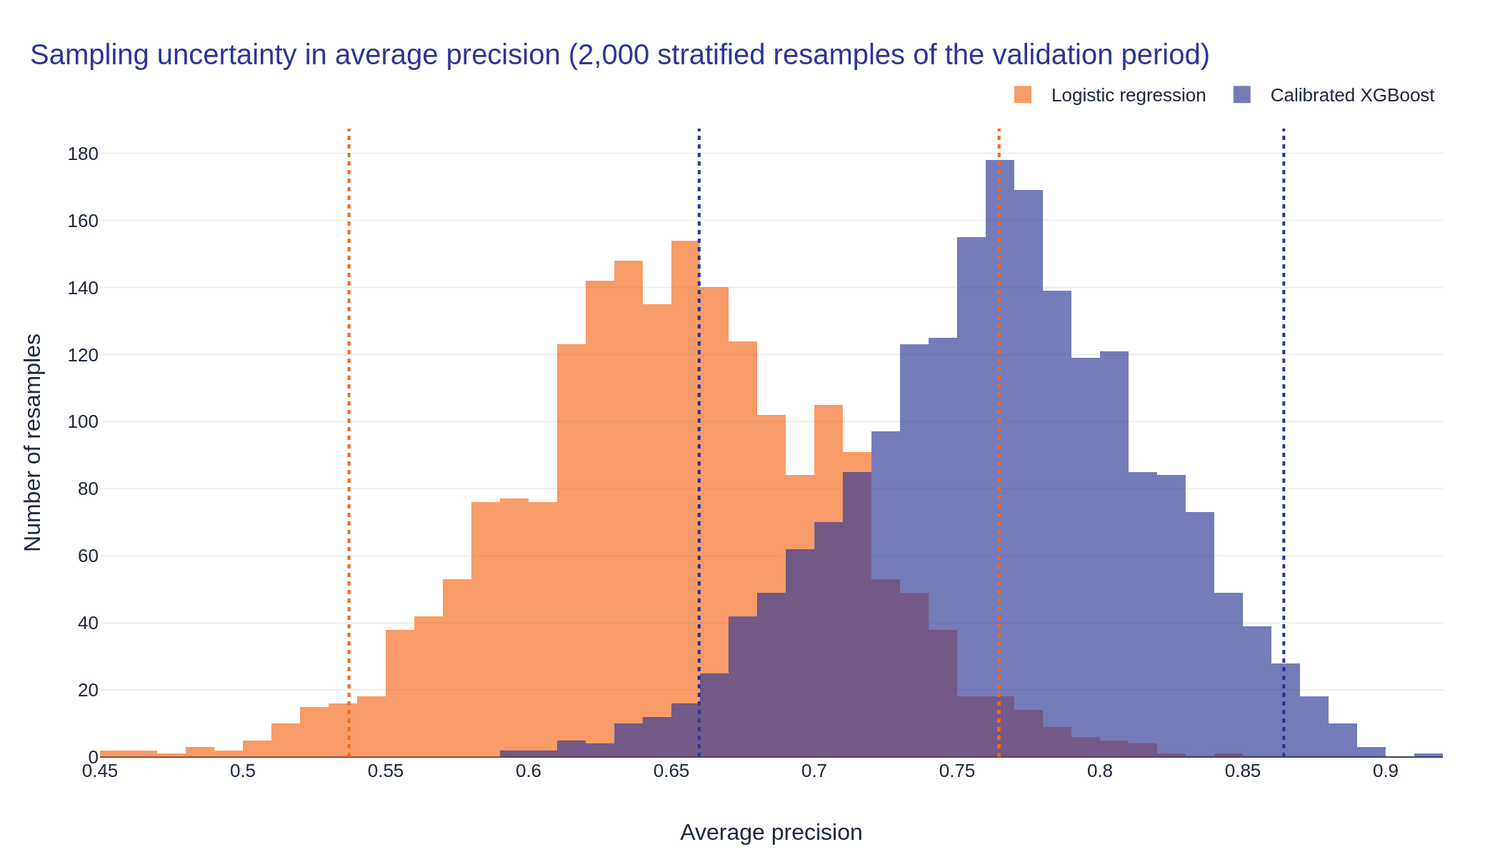

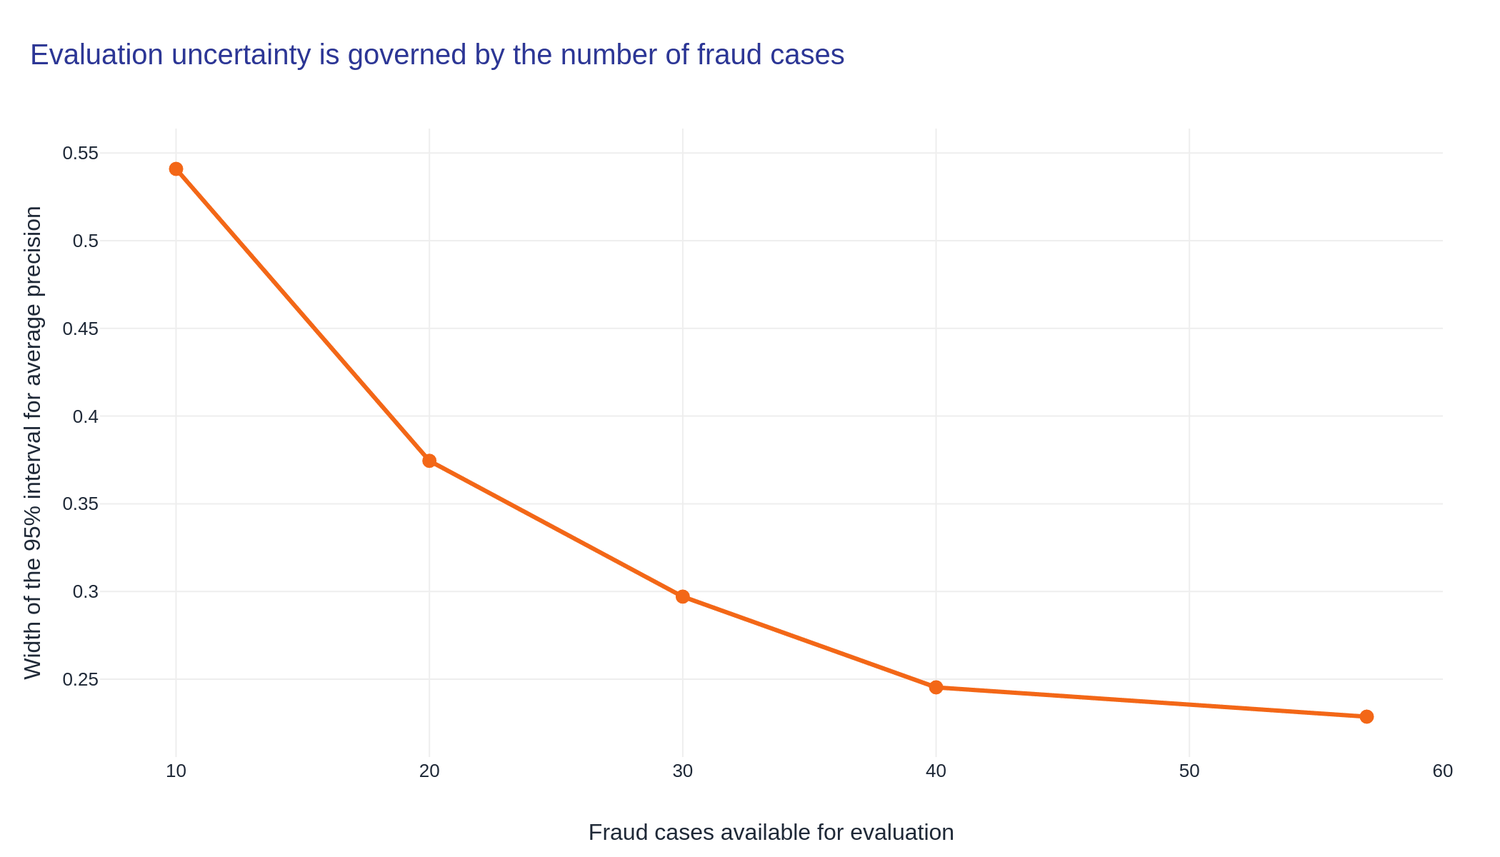

,Fraud cases available,Interval width,Lower 95%,Upper 95%
0,10,0.541,0.376,0.917
1,20,0.374,0.518,0.893
2,30,0.297,0.577,0.874
3,40,0.245,0.624,0.869
4,57,0.229,0.642,0.870


In [42]:
fig = go.Figure()

bootstrap_colours = {
    "Logistic regression": BRAND_ORANGE,
    "Calibrated XGBoost": BRAND_BLUE,
}

for model_name, replicate_values in validation_bootstrap.items():
    fig.add_trace(
        go.Histogram(
            x=replicate_values,
            name=model_name,
            opacity=0.65,
            nbinsx=60,
            marker_color=bootstrap_colours[model_name],
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Average precision: %{x:.3f}<br>"
                "Resamples: %{y:,}"
                "<extra></extra>"
            ),
        )
    )

for model_name, replicate_values in validation_bootstrap.items():
    lower, upper = np.percentile(replicate_values, [2.5, 97.5])

    for boundary in (lower, upper):
        fig.add_vline(
            x=boundary,
            line_dash="dot",
            line_color=bootstrap_colours[model_name],
        )

fig.update_layout(barmode="overlay")

fig = apply_house_style(
    fig,
    title=(
        f"Sampling uncertainty in average precision "
        f"({BOOTSTRAP_REPLICATES:,} stratified resamples of the validation period)"
    ),
    x_title="Average precision",
    y_title="Number of resamples",
    show_legend=True,
)

fig.show()


# ---------------------------------------------------------
# How much of that uncertainty is driven by the number of fraud cases?
# ---------------------------------------------------------
validation_positive_positions = np.flatnonzero(y_validation_array == 1)
validation_negative_positions = np.flatnonzero(y_validation_array == 0)

fraud_sample_sizes = [10, 20, 30, 40, 57]

interval_width_by_sample_size = []

subsample_generator = np.random.default_rng(RANDOM_STATE)

calibrated_scores_array = np.asarray(calibrated_validation_scores)

for fraud_sample_size in fraud_sample_sizes:
    replicate_values = []

    for _ in range(500):
        sampled_positives = subsample_generator.choice(
            validation_positive_positions,
            size=fraud_sample_size,
            replace=True,
        )

        sampled_negatives = subsample_generator.choice(
            validation_negative_positions,
            size=validation_negative_positions.size,
            replace=True,
        )

        resample = np.concatenate([sampled_positives, sampled_negatives])

        replicate_values.append(
            average_precision_score(
                y_validation_array[resample],
                calibrated_scores_array[resample],
            )
        )

    lower, upper = np.percentile(replicate_values, [2.5, 97.5])

    interval_width_by_sample_size.append(
        {
            "Fraud cases available": fraud_sample_size,
            "Interval width": upper - lower,
            "Lower 95%": lower,
            "Upper 95%": upper,
        }
    )

interval_width_by_sample_size = pd.DataFrame(interval_width_by_sample_size)

fig = px.line(
    interval_width_by_sample_size,
    x="Fraud cases available",
    y="Interval width",
    markers=True,
    custom_data=["Lower 95%", "Upper 95%"],
)

fig.update_traces(
    line=dict(color=BRAND_ORANGE, width=3),
    marker=dict(size=10, color=BRAND_ORANGE),
    hovertemplate=(
        "Fraud cases: %{x}<br>"
        "95% interval width: %{y:.3f}<br>"
        "Interval: [%{customdata[0]:.3f}, %{customdata[1]:.3f}]"
        "<extra></extra>"
    ),
)

fig = apply_house_style(
    fig,
    title="Evaluation uncertainty is governed by the number of fraud cases",
    x_title="Fraud cases available for evaluation",
    y_title="Width of the 95% interval for average precision",
    show_legend=False,
)

fig.show()

display(
    interval_width_by_sample_size.style.format(
        {
            "Interval width": "{:.3f}",
            "Lower 95%": "{:.3f}",
            "Upper 95%": "{:.3f}",
        }
    )
)

### What the intervals change

The intervals are wide. The 95% interval for average precision spans a substantial range for both models, which means the point estimates reported earlier should not be quoted to three decimal places as though they were stable quantities.

The paired comparison is far more informative than the two intervals considered separately. Although the individual intervals overlap heavily, the *difference* between the models is estimated much more precisely, because both models are scored on the same resampled transactions. This is the correct way to ask "is this model better", and it gives a clear answer that the overlapping-intervals view would have obscured.

The second figure isolates the cause. As the number of fraud cases available for evaluation falls, the interval widens sharply. The uncertainty is driven almost entirely by the count of fraud cases, not by the 56,000 legitimate transactions. This has a direct operational consequence: a model reviewed monthly on a period containing a few dozen confirmed fraud cases cannot reliably detect small changes in performance, so an apparent drop between two months is often noise.

This is also the reason I do not tune further. Chasing a difference of 0.01 in average precision would be optimising inside the noise floor.

## Would synthetic oversampling have done better?

Much of the published work on this dataset resamples the minority class, usually with SMOTE, which creates new fraud cases by interpolating between existing ones and their nearest neighbours. Reported results are often striking: accuracy above 99.5%, recall at or near 100%, ROC-AUC above 0.999.

I chose class weighting instead, and tuned its strength as a hyperparameter. That was a decision, so it should be tested rather than defended.

There are reasons to expect resampling to disappoint here, and they are worth stating before the experiment rather than after it.

The features are principal components. SMOTE places a new point on the straight line between two fraud cases, which assumes that the space between them is also fraud. In a rotated, anonymised space there is no guarantee that this midpoint corresponds to any transaction that could actually occur.

Resampling also distorts the predicted probabilities. Training on data that is 50% fraud teaches the model that fraud is common, so its output no longer estimates the probability of fraud in the real world. Every cost calculation and every band boundary in this notebook depends on that probability meaning what it says, so a distortion there is not a cosmetic problem.

Most importantly, resampling and class weighting are two routes to the same objective. Both make errors on the rare class count for more during training. Neither adds information that was not already in the 342 fraud cases in the training period.

The comparison below holds everything else constant: same features, same chronological training period, same tuned hyperparameters, same untouched validation period. Only the treatment of imbalance changes. **SMOTE is fitted on the training data alone.** The validation period is never resampled, because resampling the data you are measuring on changes the question being asked.

In [43]:
from imblearn.over_sampling import SMOTE

X_train_final = train_engineered[final_xgb_features]

tuned_positive_weight = float(best_xgb_parameters["scale_pos_weight"])


def fit_tuned_xgboost(X, y, positive_weight):
    """Refit the selected configuration with a given positive-class weight."""
    parameters = dict(best_xgb_parameters)
    parameters["scale_pos_weight"] = positive_weight

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        **parameters,
    )

    model.fit(X, y, verbose=False)
    return model


# SMOTE is fitted on the training period only. The validation period keeps its
# real class balance, because that is the balance the model will meet in use.
smote_sampler = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)

X_train_oversampled, y_train_oversampled = smote_sampler.fit_resample(
    X_train_final, y_train
)

print(
    f"Training period as collected:  {len(X_train_final):,} rows, "
    f"{int(y_train.sum()):,} fraud ({y_train.mean():.3%})"
)
print(
    f"Training period after SMOTE:   {len(X_train_oversampled):,} rows, "
    f"{int(y_train_oversampled.sum()):,} fraud "
    f"({y_train_oversampled.mean():.1%})"
)
print(
    f"Synthetic fraud cases created: "
    f"{int(y_train_oversampled.sum() - y_train.sum()):,} "
    f"from {int(y_train.sum())} real ones"
)

imbalance_strategies = {
    "Nothing": (X_train_final, y_train, 1.0),
    "Class weighting (selected)": (X_train_final, y_train, tuned_positive_weight),
    "SMOTE": (X_train_oversampled, y_train_oversampled, 1.0),
    "SMOTE and class weighting": (
        X_train_oversampled,
        y_train_oversampled,
        tuned_positive_weight,
    ),
}

imbalance_scores = {}
imbalance_rows = []

for strategy_name, (X_fit, y_fit, positive_weight) in imbalance_strategies.items():
    model = fit_tuned_xgboost(X_fit, y_fit, positive_weight)

    scores = model.predict_proba(X_validation_final)[:, 1]
    imbalance_scores[strategy_name] = scores

    ranking = evaluate_probability_scores(y_validation, scores)

    # Operational view: fraud found in the first 50 investigated transactions
    top_50 = np.argsort(scores)[::-1][:50]
    caught_in_50 = int(y_validation_array[top_50].sum())

    imbalance_rows.append(
        {
            "Imbalance treatment": strategy_name,
            "Training rows": len(X_fit),
            "Average precision": ranking["Average precision"],
            "ROC-AUC": ranking["ROC-AUC"],
            "Fraud in top 50 alerts": caught_in_50,
            "Mean predicted probability": float(np.mean(scores)),
            "Overstatement factor": float(np.mean(scores)) / validation_prevalence,
        }
    )

imbalance_comparison = pd.DataFrame(imbalance_rows).sort_values(
    "Average precision", ascending=False
)

display(
    imbalance_comparison.style.format(
        {
            "Training rows": "{:,.0f}",
            "Average precision": "{:.4f}",
            "ROC-AUC": "{:.4f}",
            "Mean predicted probability": "{:.4f}",
            "Overstatement factor": "{:.0f}x",
        }
    )
)

Training period as collected:  170,235 rows, 342 fraud (0.201%)
Training period after SMOTE:   339,786 rows, 169,893 fraud (50.0%)
Synthetic fraud cases created: 169,551 from 342 real ones


,Imbalance treatment,Training rows,Average precision,ROC-AUC,Fraud in top 50 alerts,Mean predicted probability,Overstatement factor
0,Nothing,"170,235",0.7774,0.9845,41,0.0011,1x
2,SMOTE,"339,786",0.7773,0.9646,42,0.0072,7x
1,Class weighting (selected),"170,235",0.7736,0.9800,43,0.0036,4x
3,SMOTE and class weighting,"339,786",0.7589,0.9618,42,0.0314,31x


Class weighting minus SMOTE, average precision on the validation period
Point estimate: -0.003
95% interval:   [-0.029, +0.019]
Resamples favouring class weighting: 42.3%

The interval contains zero, so this validation period cannot separate the two treatments. Neither is demonstrably better.


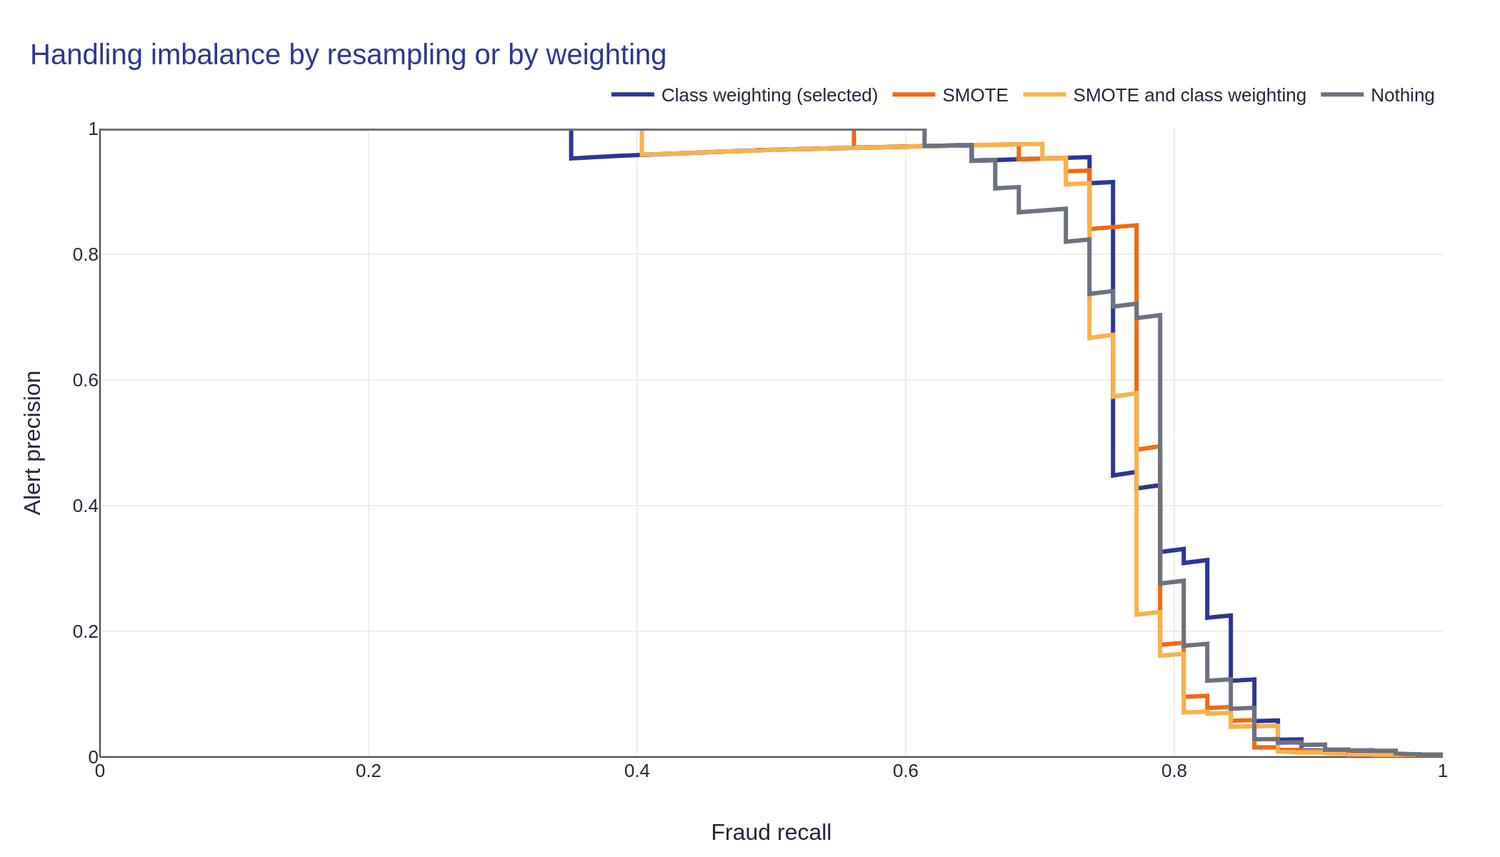

In [44]:
# ---------------------------------------------------------
# Is the difference between the two treatments larger than the noise?
# ---------------------------------------------------------
smote_bootstrap = bootstrap_average_precision(
    y_validation,
    {
        "Class weighting": imbalance_scores["Class weighting (selected)"],
        "SMOTE": imbalance_scores["SMOTE"],
    },
    BOOTSTRAP_REPLICATES,
    np.random.default_rng(RANDOM_STATE),
)

smote_difference = (
    smote_bootstrap["Class weighting"] - smote_bootstrap["SMOTE"]
)

difference_low, difference_high = np.percentile(smote_difference, [2.5, 97.5])

print("Class weighting minus SMOTE, average precision on the validation period")
print(f"Point estimate: {np.mean(smote_difference):+.3f}")
print(f"95% interval:   [{difference_low:+.3f}, {difference_high:+.3f}]")
print(
    f"Resamples favouring class weighting: "
    f"{np.mean(smote_difference > 0):.1%}"
)

if difference_low <= 0 <= difference_high:
    print(
        "\nThe interval contains zero, so this validation period cannot "
        "separate the two treatments. Neither is demonstrably better."
    )
else:
    better = "class weighting" if difference_low > 0 else "SMOTE"
    print(f"\nThe interval excludes zero, favouring {better}.")

fig = go.Figure()

for strategy_name, colour in [
    ("Class weighting (selected)", BRAND_BLUE),
    ("SMOTE", BRAND_ORANGE),
    ("SMOTE and class weighting", BRAND_LIGHT_ORANGE),
    ("Nothing", BRAND_GREY),
]:
    precision_values, recall_values, _ = precision_recall_curve(
        y_validation, imbalance_scores[strategy_name]
    )

    fig.add_trace(
        go.Scatter(
            x=recall_values,
            y=precision_values,
            mode="lines",
            name=strategy_name,
            line=dict(color=colour, width=3),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Recall: %{x:.3f}<br>Precision: %{y:.3f}<extra></extra>"
            ),
        )
    )

fig = apply_house_style(
    fig,
    title="Handling imbalance by resampling or by weighting",
    x_title="Fraud recall",
    y_title="Alert precision",
    show_legend=True,
)

fig.update_xaxes(range=[0, 1])
fig.update_yaxes(range=[0, 1])
fig.show()

### What the comparison shows

Synthetic oversampling does not beat class weighting here. It also does not lose to it. The paired interval on the difference spans zero, so this validation period cannot separate the two, and saying anything stronger would be reading noise.

The more uncomfortable result is in the top row. Doing nothing at all about the imbalance scores marginally the highest average precision of the four. All four treatments land within about two hundredths of each other, which is well inside the sampling interval established earlier, where the width on a single average precision estimate was around 0.2. On the operational view, fraud found in the first fifty investigated transactions, the ordering shifts again and class weighting comes out slightly ahead. These are not real differences. Reporting any of them as a win would be exactly the behaviour this notebook argues against.

That is worth sitting with, because the literature on this dataset treats resampling as close to mandatory. On this evidence, for a gradient-boosted model evaluated out of time on the real class balance, the choice of imbalance treatment barely moves the ranking at all. SMOTE manufactured 169,551 synthetic fraud rows from 342 real ones. Those rows are combinations of the originals and carry no information the model did not already have. What they change is how hard the model is pushed to fit that same information, which is what the positive-class weight already does.

**The column that separates the four treatments is the last one.** Training on a balanced sample teaches the model that roughly half of all transactions are fraudulent, and its predicted probabilities inherit that belief. SMOTE overstates the real fraud rate by around seven times, and SMOTE combined with class weighting by around thirty. Ranking survives this, because the distortion is monotone, but the probability stops meaning anything on its own. Every threshold, cost figure and band boundary in this notebook is built on a probability that has to correspond to reality, so a thirty-fold distortion is not a detail to be fixed later.

Class weighting distorts the probabilities too, by around three and a half times, which is precisely why the calibration step exists. Leaving the imbalance alone produces scores that are nearly calibrated to begin with. The reason the notebook still tunes the weight rather than dropping it is that the weight was selected on chronological folds inside the training period, where it did help, and that the calibration step corrects the distortion afterwards in a way that can be measured.

None of this makes SMOTE a bad method. It is useful where the minority class is under-sampled rather than genuinely rare, and where the feature space is one in which interpolation between two examples produces something plausible. Neither condition holds here: the features are principal components, and 0.17% is the real rate rather than an artefact of collection.

## Why published results on this dataset look so much better

Papers using this dataset regularly report accuracy above 99.5%, recall at or near 100%, and ROC-AUC above 0.999. Those numbers are real, in the sense that the authors computed them correctly from what they had. They are not comparable to the numbers in this notebook, and it is worth showing exactly why, because the same three shortcuts are easy to take by accident.

The demonstration below reproduces each shortcut deliberately, on this same data and with this same model, so the size of each effect can be seen rather than argued about.

,Evaluation,Evaluated on,Fraud rate in the evaluation set,Accuracy,Precision,Recall,ROC-AUC,Average precision
0,"Done properly: fit on the past, score the future","56,745 real transactions",0.10%,99.86%,40.54%,78.95%,0.9646,0.7773
1,Shortcut 1: evaluate on a balanced sample,"114 transactions, rebalanced",50.00%,89.47%,100.00%,78.95%,0.9646,0.9741
2,"Shortcut 2: resample everything, then split at random","113,302 rows, mostly synthetic",50.00%,99.50%,99.60%,99.41%,0.9998,0.9998
3,Shortcut 3: split at random instead of by time,"56,746 real transactions",0.17%,99.90%,65.00%,82.11%,0.9766,0.8043


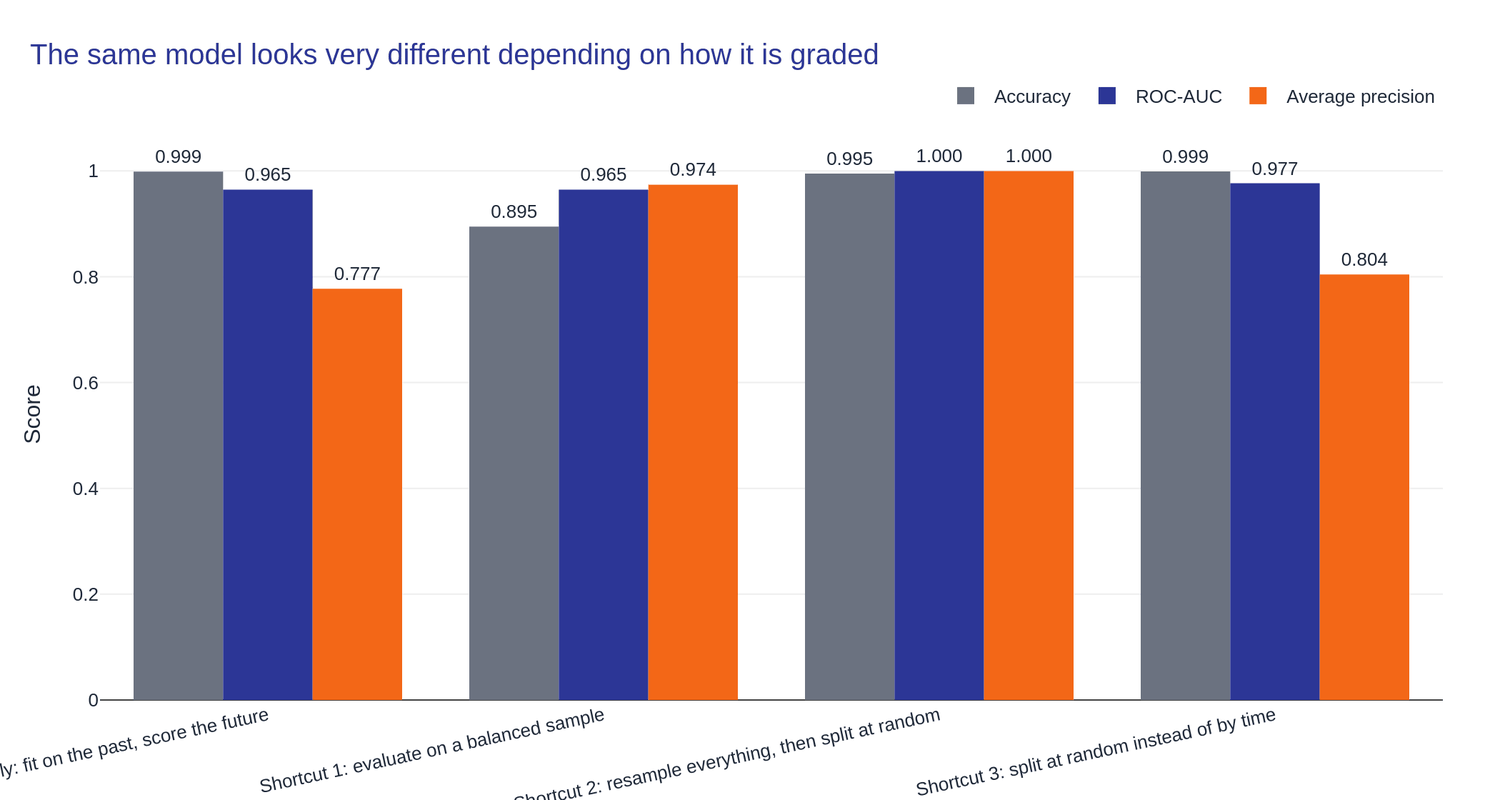

In [45]:
from sklearn.model_selection import train_test_split

leakage_rows = []

# ---------------------------------------------------------
# The honest baseline, carried down from the comparison above
# ---------------------------------------------------------
honest_scores = imbalance_scores["SMOTE"]
honest_predictions = (honest_scores >= 0.50).astype(int)

leakage_rows.append(
    {
        "Evaluation": "Done properly: fit on the past, score the future",
        "Evaluated on": f"{len(y_validation_array):,} real transactions",
        "Fraud rate in the evaluation set": validation_prevalence,
        "Accuracy": accuracy_score(y_validation_array, honest_predictions),
        "Precision": precision_score(
            y_validation_array, honest_predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_validation_array, honest_predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_validation_array, honest_scores),
        "Average precision": average_precision_score(
            y_validation_array, honest_scores
        ),
    }
)

# ---------------------------------------------------------
# Shortcut 1: report on a balanced evaluation set
# The model is unchanged. Only the exam changes.
# ---------------------------------------------------------
balance_generator = np.random.default_rng(RANDOM_STATE)

fraud_positions = np.flatnonzero(y_validation_array == 1)
legitimate_sample = balance_generator.choice(
    np.flatnonzero(y_validation_array == 0),
    size=len(fraud_positions),
    replace=False,
)

balanced_positions = np.concatenate([fraud_positions, legitimate_sample])

balanced_labels = y_validation_array[balanced_positions]
balanced_scores = honest_scores[balanced_positions]
balanced_predictions = (balanced_scores >= 0.50).astype(int)

leakage_rows.append(
    {
        "Evaluation": "Shortcut 1: evaluate on a balanced sample",
        "Evaluated on": f"{len(balanced_labels):,} transactions, rebalanced",
        "Fraud rate in the evaluation set": balanced_labels.mean(),
        "Accuracy": accuracy_score(balanced_labels, balanced_predictions),
        "Precision": precision_score(
            balanced_labels, balanced_predictions, zero_division=0
        ),
        "Recall": recall_score(
            balanced_labels, balanced_predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(balanced_labels, balanced_scores),
        "Average precision": average_precision_score(
            balanced_labels, balanced_scores
        ),
    }
)

# ---------------------------------------------------------
# Shortcut 2: resample the whole dataset, then split it
# Synthetic rows built from a fraud case can now land in the test set while
# the real case that generated them sits in training.
# ---------------------------------------------------------
all_engineered = engineer_features(analysis_df)

X_everything = all_engineered[final_xgb_features]
y_everything = all_engineered["Class"]

X_everything_resampled, y_everything_resampled = SMOTE(
    random_state=RANDOM_STATE
).fit_resample(X_everything, y_everything)

X_leaky_train, X_leaky_test, y_leaky_train, y_leaky_test = train_test_split(
    X_everything_resampled,
    y_everything_resampled,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_everything_resampled,
)

leaky_model = fit_tuned_xgboost(X_leaky_train, y_leaky_train, 1.0)
leaky_scores = leaky_model.predict_proba(X_leaky_test)[:, 1]
leaky_predictions = (leaky_scores >= 0.50).astype(int)

leakage_rows.append(
    {
        "Evaluation": "Shortcut 2: resample everything, then split at random",
        "Evaluated on": f"{len(y_leaky_test):,} rows, mostly synthetic",
        "Fraud rate in the evaluation set": float(y_leaky_test.mean()),
        "Accuracy": accuracy_score(y_leaky_test, leaky_predictions),
        "Precision": precision_score(y_leaky_test, leaky_predictions, zero_division=0),
        "Recall": recall_score(y_leaky_test, leaky_predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_leaky_test, leaky_scores),
        "Average precision": average_precision_score(y_leaky_test, leaky_scores),
    }
)

# ---------------------------------------------------------
# Shortcut 3: split at random in time, on the real data
# No synthetic rows at all. The only change is that the model is allowed to
# train on transactions that happened after the ones it is tested on.
# ---------------------------------------------------------
X_random_train, X_random_test, y_random_train, y_random_test = train_test_split(
    X_everything,
    y_everything,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_everything,
)

random_split_model = fit_tuned_xgboost(
    X_random_train, y_random_train, tuned_positive_weight
)
random_split_scores = random_split_model.predict_proba(X_random_test)[:, 1]
random_split_predictions = (random_split_scores >= 0.50).astype(int)

leakage_rows.append(
    {
        "Evaluation": "Shortcut 3: split at random instead of by time",
        "Evaluated on": f"{len(y_random_test):,} real transactions",
        "Fraud rate in the evaluation set": float(y_random_test.mean()),
        "Accuracy": accuracy_score(y_random_test, random_split_predictions),
        "Precision": precision_score(
            y_random_test, random_split_predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_random_test, random_split_predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_random_test, random_split_scores),
        "Average precision": average_precision_score(
            y_random_test, random_split_scores
        ),
    }
)

leakage_comparison = pd.DataFrame(leakage_rows)

display(
    leakage_comparison.style.format(
        {
            "Fraud rate in the evaluation set": "{:.2%}",
            "Accuracy": "{:.2%}",
            "Precision": "{:.2%}",
            "Recall": "{:.2%}",
            "ROC-AUC": "{:.4f}",
            "Average precision": "{:.4f}",
        }
    )
)

fig = go.Figure()

for metric_name, colour in [
    ("Accuracy", BRAND_GREY),
    ("ROC-AUC", BRAND_BLUE),
    ("Average precision", BRAND_ORANGE),
]:
    fig.add_trace(
        go.Bar(
            x=leakage_comparison["Evaluation"],
            y=leakage_comparison[metric_name],
            name=metric_name,
            marker_color=colour,
            text=leakage_comparison[metric_name],
            texttemplate="%{text:.3f}",
            textposition="outside",
            cliponaxis=False,
            hovertemplate=(
                "<b>%{x}</b><br>" + metric_name + ": %{y:.4f}<extra></extra>"
            ),
        )
    )

fig.update_layout(barmode="group")

fig = apply_house_style(
    fig,
    title="The same model looks very different depending on how it is graded",
    x_title=None,
    y_title="Score",
    show_legend=True,
)

fig.update_yaxes(range=[0, 1.08])
fig.update_xaxes(tickangle=-12)
fig.update_layout(height=560)
fig.show()

### Reading the shortcuts

The first row is the honest measurement, and the three below it are the same family of model scored in ways that flatter it. The size of each effect is worth reading off the table directly.

**Evaluating on a balanced sample** leaves the model completely untouched and moves average precision from 0.78 to 0.97. Precision rises because precision depends on how much fraud is present: discard 99% of the legitimate transactions and whatever the model flags is far more likely to be fraud, by construction. Recall does not move at all, which is the tell. Nothing about the model improved; only the exam changed. A system reported this way will disappoint on contact with real traffic, where all the legitimate transactions it never had to reject are still there.

**Resampling before splitting** is the most damaging of the three and the easiest to do by accident, because one call to a resampler followed by one call to a splitter looks perfectly tidy. It returns accuracy of 99.5%, precision and recall both above 99%, and ROC-AUC of 0.9998. Those figures are in the same range as the strongest published results on this dataset. They are not measuring fraud detection. SMOTE builds each synthetic row from real fraud cases and their neighbours, so splitting afterwards puts synthetic rows in the test set whose parent transactions are sitting in the training set. The model is being tested on interpolations of things it has already seen, and near-perfect scores follow.

**Splitting at random rather than by time** uses no synthetic data whatsoever and still flatters the result, lifting precision from 41% to 65%. Fraud arrives in bursts from the same compromised cards, so a random split scatters closely related transactions from a single episode across both sides of the wall. The model learns from part of an attack and is scored on the rest of it, which is not a position it will ever be in once deployed.

This is why the notebook splits chronologically, keeps both evaluation periods at their real class balance, and leads with average precision. The resulting numbers are lower than the published ones. They answer a harder question: not whether fraud can be recognised in a curated sample, but whether next week's fraud can be caught in next week's traffic without stopping a lot of ordinary customers.

One last thing worth noting from that table. Accuracy is above 99.8% in the honest row and above 99.8% in the leaking rows, so it distinguishes nothing at all. ROC-AUC stays above 0.96 in every scenario including both broken ones. Average precision is the only column that moves sharply when the evaluation is compromised, which is a large part of why it was chosen as the primary metric long before this section was written.

## The cost of being wrong

Up to this point the two error types have been counted. Counting them treats them as equivalent, and they are not.

A missed fraud has a cost that varies by transaction: the money lost is the amount of that specific transaction. The dataset contains that amount, so the cost of a false negative can be computed for each individual case rather than assumed to be constant. A false alert has a cost that is roughly fixed per alert but depends entirely on what the alert *does*: an automated verification message, an analyst reviewing a case, or a declined card at a checkout are three very different impositions on a customer.

The dataset does not tell me what an alert costs. Rather than invent a single number and present the result as optimal, I treat the cost of an alert as an explicit assumption and vary it across a plausible range. The output is not one threshold, it is a map showing how the recommended operating point moves with the assumption.

The cost model is:

```
total cost = (value of fraud that was missed)
           + (number of alerts) x (cost per alert)
           + (value of detected fraud that is still not recovered)
```

The recovery rate captures the fact that catching a fraudulent transaction does not always recover the full amount. I hold it at 100% in the primary analysis and revisit it in the sensitivity checks, so that the assumption is visible rather than buried.

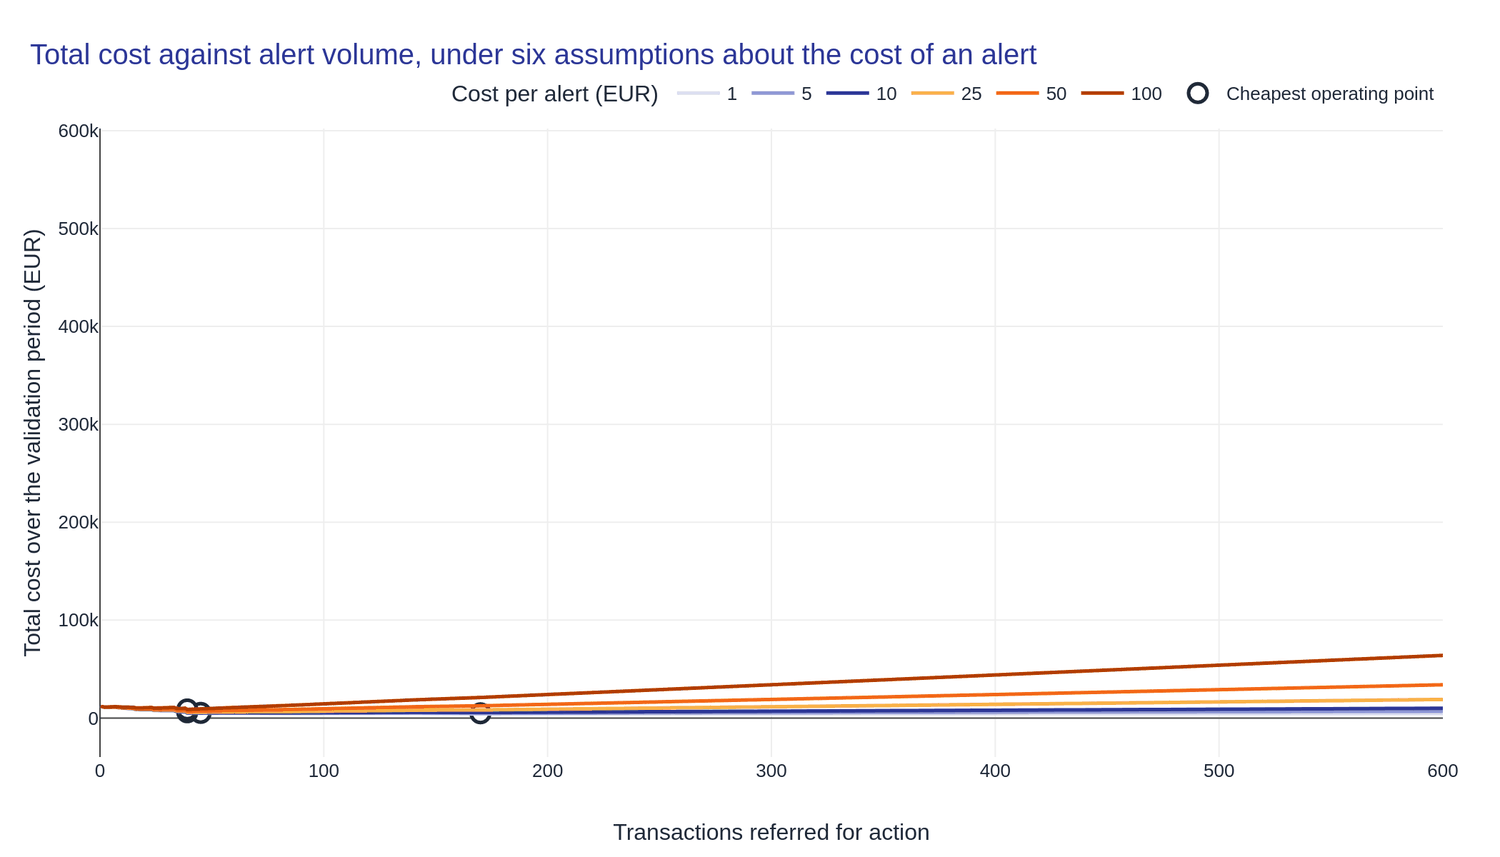

,Cost per alert,Threshold,Alerts,Fraud detected,Fraud missed,False alerts,Missed fraud value,Total cost
0,1,0.0005,876,49,8,827,"EUR 3,244","EUR 4,120"
1,5,0.0121,170,47,10,123,"EUR 3,989","EUR 4,839"
2,10,0.7575,45,41,16,4,"EUR 4,800","EUR 5,250"
3,25,0.7966,39,37,20,2,"EUR 4,866","EUR 5,841"
4,50,0.7966,39,37,20,2,"EUR 4,866","EUR 6,816"
5,100,0.7909,39,37,20,2,"EUR 4,866","EUR 8,766"


In [46]:
validation_amounts = validation_df["Amount"].to_numpy(dtype=float)


def total_expected_cost(
    y_true,
    y_score,
    amounts,
    threshold,
    cost_per_alert,
    recovery_rate=1.0,
):
    """
    Monetary cost of one operating point.

    Missed fraud is charged at the value of the transaction, so the cost of a
    false negative depends on the individual case rather than being fixed.
    """
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    flagged = y_score >= threshold
    is_fraud = y_true == 1

    missed_fraud_value = amounts[is_fraud & ~flagged].sum()
    detected_fraud_value = amounts[is_fraud & flagged].sum()

    alert_count = int(flagged.sum())

    return {
        "Threshold": threshold,
        "Alerts": alert_count,
        "Fraud detected": int((is_fraud & flagged).sum()),
        "Fraud missed": int((is_fraud & ~flagged).sum()),
        "False alerts": int((~is_fraud & flagged).sum()),
        "Missed fraud value": missed_fraud_value,
        "Unrecovered value": detected_fraud_value * (1 - recovery_rate),
        "Alert handling cost": alert_count * cost_per_alert,
        "Total cost": (
            missed_fraud_value
            + detected_fraud_value * (1 - recovery_rate)
            + alert_count * cost_per_alert
        ),
    }


def build_threshold_grid(y_score, n_points=400):
    """Threshold grid concentrated where the operating decisions occur."""
    y_score = np.asarray(y_score)

    quantiles = np.concatenate(
        [
            np.linspace(0.90, 0.999, n_points // 2),
            np.linspace(0.999, 1.0, n_points // 2, endpoint=False),
        ]
    )

    return np.unique(np.quantile(y_score, quantiles))


threshold_grid = build_threshold_grid(calibrated_validation_scores)

alert_cost_assumptions = [1, 5, 10, 25, 50, 100]

cost_curve_rows = []

for cost_per_alert in alert_cost_assumptions:
    for threshold in threshold_grid:
        result = total_expected_cost(
            y_validation,
            calibrated_validation_scores,
            validation_amounts,
            threshold=threshold,
            cost_per_alert=cost_per_alert,
        )

        result["Cost per alert"] = cost_per_alert
        cost_curve_rows.append(result)

cost_curves = pd.DataFrame(cost_curve_rows)

fig = px.line(
    cost_curves,
    x="Alerts",
    y="Total cost",
    color="Cost per alert",
    custom_data=[
        "Fraud detected",
        "Fraud missed",
        "False alerts",
        "Missed fraud value",
        "Threshold",
    ],
    color_discrete_sequence=[
        BRAND_LIGHT_BLUE,
        "#8E97D6",
        BRAND_BLUE,
        BRAND_LIGHT_ORANGE,
        BRAND_ORANGE,
        "#B23D00",
    ],
)

fig.update_traces(
    line=dict(width=2.5),
    hovertemplate=(
        "Cost per alert: EUR %{fullData.name}<br>"
        "Alerts raised: %{x:,}<br>"
        "Total cost: EUR %{y:,.0f}<br>"
        "Fraud detected: %{customdata[0]}<br>"
        "Fraud missed: %{customdata[1]}<br>"
        "False alerts: %{customdata[2]:,}<br>"
        "Value of missed fraud: EUR %{customdata[3]:,.0f}"
        "<extra></extra>"
    ),
)

# Mark the cheapest operating point for each assumption
cost_optima = (
    cost_curves.sort_values("Total cost")
    .groupby("Cost per alert", as_index=False)
    .first()
)

fig.add_trace(
    go.Scatter(
        x=cost_optima["Alerts"],
        y=cost_optima["Total cost"],
        mode="markers",
        name="Cheapest operating point",
        marker=dict(
            size=13,
            color="white",
            line=dict(color=BRAND_DARK, width=2.5),
            symbol="circle",
        ),
        customdata=cost_optima[["Cost per alert", "Fraud detected"]].to_numpy(),
        hovertemplate=(
            "Cheapest point at EUR %{customdata[0]} per alert<br>"
            "Alerts: %{x:,}<br>"
            "Total cost: EUR %{y:,.0f}<br>"
            "Fraud detected: %{customdata[1]}"
            "<extra></extra>"
        ),
    )
)

fig = apply_house_style(
    fig,
    title="Total cost against alert volume, under six assumptions about the cost of an alert",
    x_title="Transactions referred for action",
    y_title="Total cost over the validation period (EUR)",
    show_legend=True,
)

fig.update_xaxes(range=[0, 600])
fig.update_layout(legend_title_text="Cost per alert (EUR)")

fig.show()

display(
    cost_optima[
        [
            "Cost per alert",
            "Threshold",
            "Alerts",
            "Fraud detected",
            "Fraud missed",
            "False alerts",
            "Missed fraud value",
            "Total cost",
        ]
    ].style.format(
        {
            "Threshold": "{:.4f}",
            "Alerts": "{:,.0f}",
            "Missed fraud value": "EUR {:,.0f}",
            "Total cost": "EUR {:,.0f}",
        }
    )
)

### The recommended threshold is an assumption, not a discovery

The cost-optimal operating point moves by more than a factor of twenty across the range of alert costs considered. When alerts are nearly free the model should flag hundreds of transactions; once an alert costs more than a few euros, only a few dozen of the most confident cases justify action. Nothing about the model changed between those two answers. Only the assumption did.

This is the central point of the whole evaluation. A notebook that reports "the optimal threshold is 0.31" has usually hidden an unstated assumption about the relative cost of the two errors, and the threshold is a property of that assumption at least as much as it is a property of the model.

There is a second, independent source of instability: the cost curve is estimated from 57 fraud cases, and the value of missed fraud is dominated by a handful of large transactions. I therefore hold the cost assumption completely fixed and bootstrap the cost-optimal operating point, which isolates how much of it survives resampling alone.

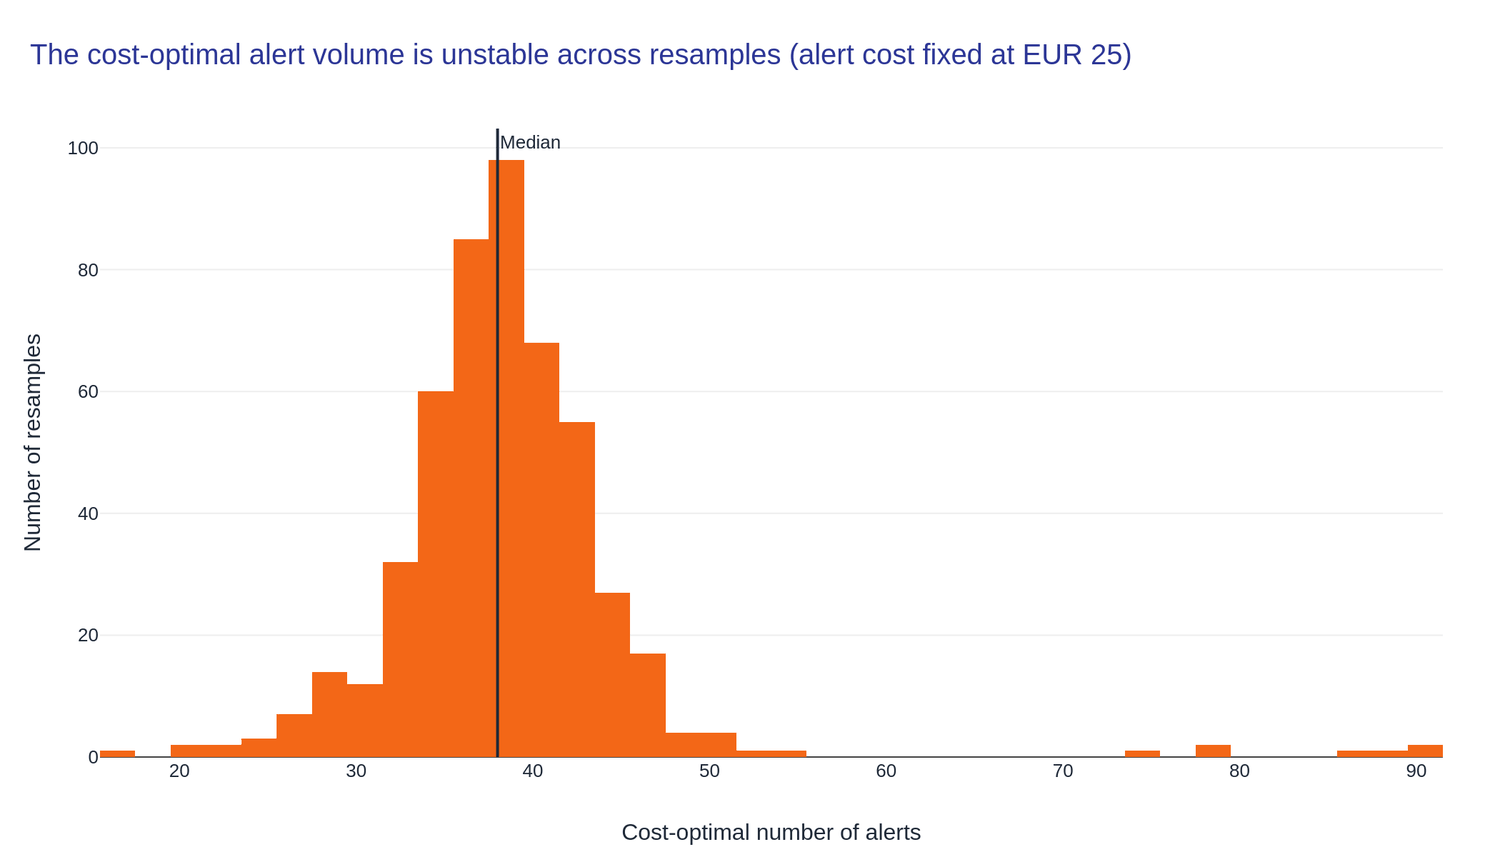

Median cost-optimal alert volume: 38
95% interval: [27, 49] alerts
Ratio of upper to lower bound: 1.8x


In [47]:
COST_PER_ALERT_PRIMARY = 25

bootstrap_optimum_generator = np.random.default_rng(RANDOM_STATE)

optimal_alert_counts = []
optimal_thresholds = []

calibrated_scores_array = np.asarray(calibrated_validation_scores)

for resample in stratified_bootstrap_indices(
    y_validation_array, 500, bootstrap_optimum_generator
):
    resampled_labels = y_validation_array[resample]
    resampled_scores = calibrated_scores_array[resample]
    resampled_amounts = validation_amounts[resample]

    best_cost = np.inf
    best_alerts = 0
    best_threshold = 1.0

    for threshold in threshold_grid:
        outcome = total_expected_cost(
            resampled_labels,
            resampled_scores,
            resampled_amounts,
            threshold=threshold,
            cost_per_alert=COST_PER_ALERT_PRIMARY,
        )

        if outcome["Total cost"] < best_cost:
            best_cost = outcome["Total cost"]
            best_alerts = outcome["Alerts"]
            best_threshold = threshold

    optimal_alert_counts.append(best_alerts)
    optimal_thresholds.append(best_threshold)

optimal_alert_counts = np.asarray(optimal_alert_counts)

optimum_lower, optimum_upper = np.percentile(optimal_alert_counts, [2.5, 97.5])

fig = go.Figure(
    go.Histogram(
        x=optimal_alert_counts,
        nbinsx=50,
        marker_color=BRAND_ORANGE,
        hovertemplate=(
            "Cost-optimal alert volume: %{x:,}<br>"
            "Resamples: %{y:,}"
            "<extra></extra>"
        ),
    )
)

fig.add_vline(
    x=np.median(optimal_alert_counts),
    line_color=BRAND_DARK,
    line_width=2,
    annotation_text="Median",
    annotation_position="top right",
)

fig = apply_house_style(
    fig,
    title=(
        "The cost-optimal alert volume is unstable across resamples "
        f"(alert cost fixed at EUR {COST_PER_ALERT_PRIMARY})"
    ),
    x_title="Cost-optimal number of alerts",
    y_title="Number of resamples",
    show_legend=False,
)

fig.show()

print(
    f"Median cost-optimal alert volume: {np.median(optimal_alert_counts):,.0f}"
)
print(
    f"95% interval: [{optimum_lower:,.0f}, {optimum_upper:,.0f}] alerts"
)
print(
    "Ratio of upper to lower bound: "
    f"{optimum_upper / max(optimum_lower, 1):,.1f}x"
)

### Why I do not ship a single optimised threshold

Even with the cost assumption held completely fixed, the cost-optimal alert volume still spans roughly a factor of two across resamples of the same validation period. That residual instability comes from the data alone: with 57 fraud cases and a heavily skewed distribution of transaction values, the position of the minimum is determined by a small number of individual transactions.

So the two sources compound. The assumption about alert cost moves the answer by more than twentyfold, and sampling noise moves it by about a further factor of two on top of whatever assumption is chosen.

Two conclusions follow, and they shape the rest of the analysis.

First, a threshold selected by minimising estimated cost on this validation period would be fitted partly to noise. I therefore do not use the cost minimum as the operating point. The cost analysis is used for what it can support: understanding the shape of the trade-off and how sensitive the answer is to assumptions nobody has yet written down.

Second, the operating point should be anchored to something stable that the business actually controls, such as investigation capacity or a minimum acceptable alert precision, rather than to an estimated optimum that will not reproduce next month.

The comparison below shows what several conventional threshold rules imply in operational terms. Rules that maximise a statistical quantity are included so their consequences are visible, not because I intend to adopt them.

,Strategy,Threshold,Alerts,Fraud detected,Fraud missed,Customers disrupted,Precision,Recall,False alerts per fraud found,Value of missed fraud
4,Minimum cost at EUR 25,0.7966,39,37,20,2,94.9%,64.9%,0.1,"EUR 4,866"
6,Precision of at least 90%,0.7594,45,41,16,4,91.1%,71.9%,0.1,"EUR 4,800"
1,Maximum F1,0.7571,47,42,15,5,89.4%,73.7%,0.1,"EUR 4,800"
5,Fixed budget of 50 alerts,0.7330,50,42,15,8,84.0%,73.7%,0.2,"EUR 4,800"
2,Maximum F2 (recall-weighted),0.6436,59,44,13,15,74.6%,77.2%,0.3,"EUR 4,474"
0,Default 0.50,0.5000,74,44,13,30,59.5%,77.2%,0.7,"EUR 4,474"
3,Youden's J,0.0005,858,49,8,809,5.7%,86.0%,16.5,"EUR 3,244"


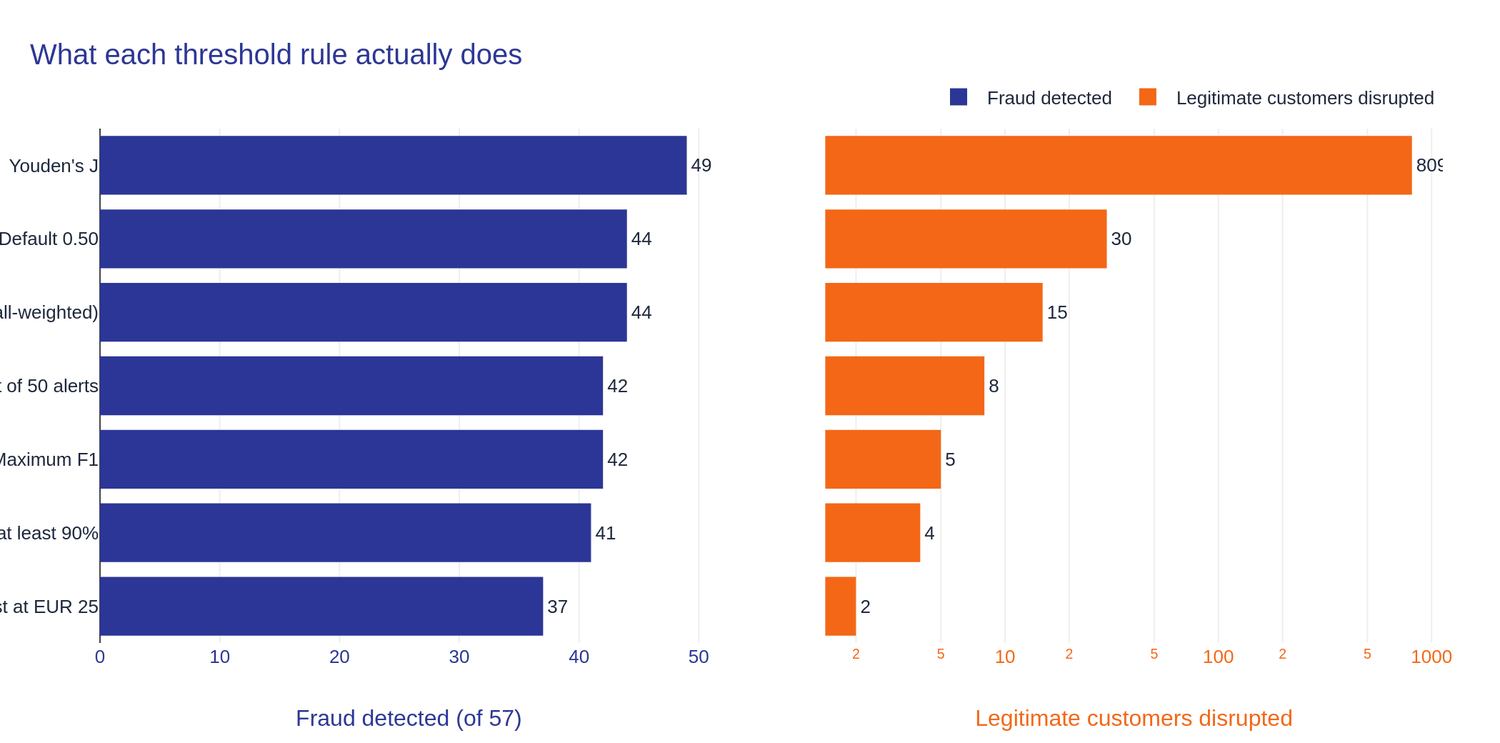

In [48]:
def threshold_for_maximum_fbeta(y_true, y_score, beta):
    """Threshold maximising the F-beta score."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)

    precision = precision[:-1]
    recall = recall[:-1]

    beta_squared = beta**2

    denominator = beta_squared * precision + recall

    fbeta = np.divide(
        (1 + beta_squared) * precision * recall,
        denominator,
        out=np.zeros_like(denominator),
        where=denominator > 0,
    )

    return float(thresholds[int(np.argmax(fbeta))])


def threshold_for_youden_j(y_true, y_score):
    """Threshold maximising Youden's J statistic."""
    false_positive_rate, true_positive_rate, thresholds = roc_curve(
        y_true, y_score
    )

    return float(
        thresholds[int(np.argmax(true_positive_rate - false_positive_rate))]
    )


def threshold_for_alert_budget(y_score, budget):
    """Threshold that produces approximately a fixed number of alerts."""
    y_score = np.asarray(y_score)

    return float(np.sort(y_score)[::-1][min(budget, len(y_score)) - 1])


cost_minimum_threshold = float(
    cost_optima.loc[
        cost_optima["Cost per alert"] == COST_PER_ALERT_PRIMARY, "Threshold"
    ].iloc[0]
)

precision_90_point = best_operating_point_at_minimum_precision(
    y_validation, calibrated_validation_scores, minimum_precision=0.90
)

candidate_thresholds = {
    "Default 0.50": 0.50,
    "Maximum F1": threshold_for_maximum_fbeta(
        y_validation, calibrated_validation_scores, beta=1
    ),
    "Maximum F2 (recall-weighted)": threshold_for_maximum_fbeta(
        y_validation, calibrated_validation_scores, beta=2
    ),
    "Youden's J": threshold_for_youden_j(
        y_validation, calibrated_validation_scores
    ),
    f"Minimum cost at EUR {COST_PER_ALERT_PRIMARY}": cost_minimum_threshold,
    "Fixed budget of 50 alerts": threshold_for_alert_budget(
        calibrated_validation_scores, 50
    ),
}

if precision_90_point is not None:
    candidate_thresholds["Precision of at least 90%"] = precision_90_point[
        "Threshold"
    ]

threshold_strategy_rows = []

for strategy_name, threshold in candidate_thresholds.items():
    outcome = evaluate_at_threshold(
        y_validation, calibrated_validation_scores, threshold
    )

    cost_outcome = total_expected_cost(
        y_validation,
        calibrated_validation_scores,
        validation_amounts,
        threshold=threshold,
        cost_per_alert=COST_PER_ALERT_PRIMARY,
    )

    threshold_strategy_rows.append(
        {
            "Strategy": strategy_name,
            "Threshold": threshold,
            "Alerts": outcome["Alerts"],
            "Fraud detected": outcome["True positives"],
            "Fraud missed": outcome["False negatives"],
            "Customers disrupted": outcome["False positives"],
            "Precision": outcome["Precision"],
            "Recall": outcome["Recall"],
            "False alerts per fraud found": outcome[
                "False alerts per detected fraud"
            ],
            "Value of missed fraud": cost_outcome["Missed fraud value"],
        }
    )

threshold_strategies = pd.DataFrame(threshold_strategy_rows).sort_values(
    "Alerts"
)

display(
    threshold_strategies.style.format(
        {
            "Threshold": "{:.4f}",
            "Alerts": "{:,.0f}",
            "Customers disrupted": "{:,.0f}",
            "Precision": "{:.1%}",
            "Recall": "{:.1%}",
            "False alerts per fraud found": "{:,.1f}",
            "Value of missed fraud": "EUR {:,.0f}",
        }
    )
)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        y=threshold_strategies["Strategy"],
        x=threshold_strategies["Fraud detected"],
        name="Fraud detected",
        orientation="h",
        marker_color=BRAND_BLUE,
        text=threshold_strategies["Fraud detected"],
        texttemplate="%{text}",
        textposition="outside",
        hovertemplate=(
            "<b>%{y}</b><br>Fraud detected: %{x} of "
            f"{int(y_validation_array.sum())}"
            "<extra></extra>"
        ),
    )
)

fig.add_trace(
    go.Bar(
        y=threshold_strategies["Strategy"],
        x=threshold_strategies["Customers disrupted"],
        name="Legitimate customers disrupted",
        orientation="h",
        marker_color=BRAND_ORANGE,
        text=threshold_strategies["Customers disrupted"],
        texttemplate="%{text:,}",
        textposition="outside",
        xaxis="x2",
        hovertemplate=(
            "<b>%{y}</b><br>Legitimate transactions flagged: %{x:,}"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="What each threshold rule actually does",
    barmode="group",
    xaxis=dict(
        title="Fraud detected (of 57)",
        titlefont=dict(color=BRAND_BLUE),
        tickfont=dict(color=BRAND_BLUE),
        domain=[0, 0.46],
    ),
    xaxis2=dict(
        title="Legitimate customers disrupted",
        titlefont=dict(color=BRAND_ORANGE),
        tickfont=dict(color=BRAND_ORANGE),
        domain=[0.54, 1.0],
        type="log",
    ),
    yaxis=dict(title=None),
    template="house",
    height=520,
    showlegend=True,
)

fig.show()

### Reading the threshold comparison

The rules that maximise a statistical quantity produce operationally very different outcomes. Youden's J weights a missed fraud and a false alert as equally important, which is indefensible when one class is 578 times larger than the other: it generates a volume of alerts no investigation team could absorb. Maximum F2 deliberately favours recall and buys the additional fraud cases at a steep price in customer disruption. The default threshold of 0.50 has no operational justification at all; it is an artefact of the classifier's default behaviour.

The rules anchored to something the business controls, an alert budget or a minimum precision, produce outcomes that can actually be staffed and explained to a customer.

The final column is the one I would put in front of a decision-maker: the number of false alerts raised for each genuine fraud found. It converts the abstract trade-off into a statement about how often a legitimate customer is inconvenienced so that one fraud is caught.

## From a single threshold to a graded response

A single threshold forces every transaction into one of two boxes: ignore it, or act on it. That is a poor description of what a bank can actually do. The available responses vary in how much they cost the customer.

I therefore convert the calibrated probability into a graded policy with four bands:

| Band | Response | Cost to the customer |
|---|---|---|
| Approve | The transaction proceeds normally | None |
| Verify | Automated step-up authentication, such as a one-time code | Seconds of friction |
| Review | Held for an analyst to inspect before settlement | A short delay |
| Block | Declined, customer contacted | High; a card refused at the point of sale |

The band boundaries are set on the validation period from precision requirements, because precision is what determines how often each response is imposed on someone who did nothing wrong. The strictest band is required to be highly precise, since a wrongly declined card is the most damaging outcome for a customer. The lowest band is permitted to be imprecise, because the response at that level is nearly free.

This design is the direct answer to the trade-off. It does not choose between catching fraud and protecting customers; it matches the severity of the response to the strength of the evidence.

In [49]:
def threshold_for_minimum_precision(y_true, y_score, target_precision):
    """
    Lowest threshold that still achieves the required precision.

    Returns None when the requirement cannot be met at any threshold.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)

    precision = precision[:-1]
    recall = recall[:-1]

    eligible = np.flatnonzero(precision >= target_precision)

    if eligible.size == 0:
        return None

    # Among thresholds meeting the requirement, take the one with most recall
    return float(thresholds[eligible[int(np.argmax(recall[eligible]))]])


PRECISION_REQUIREMENTS = {
    "Block": 0.90,
    "Review": 0.25,
    "Verify": 0.02,
}

band_thresholds = {}

for band_name, required_precision in PRECISION_REQUIREMENTS.items():
    threshold = threshold_for_minimum_precision(
        y_validation, calibrated_validation_scores, required_precision
    )

    if threshold is None:
        # Fall back to a percentile-based cut if the requirement is unreachable
        threshold = float(np.quantile(calibrated_validation_scores, 0.9995))

        print(
            f"Precision of {required_precision:.0%} was not attainable for the "
            f"{band_name} band; a percentile fallback was used instead."
        )

    band_thresholds[band_name] = threshold

# Guarantee that the bands are strictly ordered
block_threshold = band_thresholds["Block"]
review_threshold = min(band_thresholds["Review"], block_threshold)
verify_threshold = min(band_thresholds["Verify"], review_threshold)

print("Band boundaries on the calibrated probability")
print(f"Verify at or above:  {verify_threshold:.5f}")
print(f"Review at or above:  {review_threshold:.5f}")
print(f"Block at or above:   {block_threshold:.5f}")


def assign_response_band(scores):
    """Map calibrated probabilities to the four graded responses."""
    scores = np.asarray(scores)

    return np.select(
        [
            scores >= block_threshold,
            scores >= review_threshold,
            scores >= verify_threshold,
        ],
        ["Block", "Review", "Verify"],
        default="Approve",
    )


BAND_ORDER = ["Approve", "Verify", "Review", "Block"]

# Cost of imposing each response on a customer who did nothing wrong,
# stated explicitly so it can be challenged.
DISRUPTION_COST = {
    "Approve": 0.0,
    "Verify": 0.50,
    "Review": 8.00,
    "Block": 60.00,
}


def summarise_policy(y_true, scores, amounts, label):
    """Volume, detection and disruption for each response band."""
    bands = assign_response_band(scores)

    y_true = np.asarray(y_true)
    total_fraud = int(y_true.sum())

    rows = []

    for band_name in BAND_ORDER:
        in_band = bands == band_name

        fraud_in_band = int(y_true[in_band].sum())
        legitimate_in_band = int((~(y_true == 1) & in_band).sum())

        rows.append(
            {
                "Period": label,
                "Response": band_name,
                "Transactions": int(in_band.sum()),
                "Share of all transactions": in_band.mean(),
                "Fraud in band": fraud_in_band,
                "Legitimate in band": legitimate_in_band,
                "Precision within band": (
                    fraud_in_band / max(int(in_band.sum()), 1)
                ),
                "Share of all fraud": fraud_in_band / max(total_fraud, 1),
                "Value of fraud in band": amounts[in_band & (y_true == 1)].sum(),
                "Customer disruption cost": (
                    legitimate_in_band * DISRUPTION_COST[band_name]
                ),
            }
        )

    return pd.DataFrame(rows)


validation_policy = summarise_policy(
    y_validation,
    calibrated_validation_scores,
    validation_amounts,
    "Validation",
)

display(
    validation_policy.style.format(
        {
            "Transactions": "{:,.0f}",
            "Share of all transactions": "{:.3%}",
            "Legitimate in band": "{:,.0f}",
            "Precision within band": "{:.1%}",
            "Share of all fraud": "{:.1%}",
            "Value of fraud in band": "EUR {:,.0f}",
            "Customer disruption cost": "EUR {:,.0f}",
        }
    )
)

Band boundaries on the calibrated probability
Verify at or above:  0.00032
Review at or above:  0.00760
Block at or above:   0.75936


,Period,Response,Transactions,Share of all transactions,Fraud in band,Legitimate in band,Precision within band,Share of all fraud,Value of fraud in band,Customer disruption cost
0,Validation,Approve,"54,245",95.594%,7,"54,238",0.0%,12.3%,"EUR 2,523",EUR 0
1,Validation,Verify,"2,312",4.074%,3,"2,309",0.1%,5.3%,"EUR 1,466","EUR 1,154"
2,Validation,Review,143,0.252%,6,137,4.2%,10.5%,EUR 811,"EUR 1,096"
3,Validation,Block,45,0.079%,41,4,91.1%,71.9%,"EUR 7,431",EUR 240


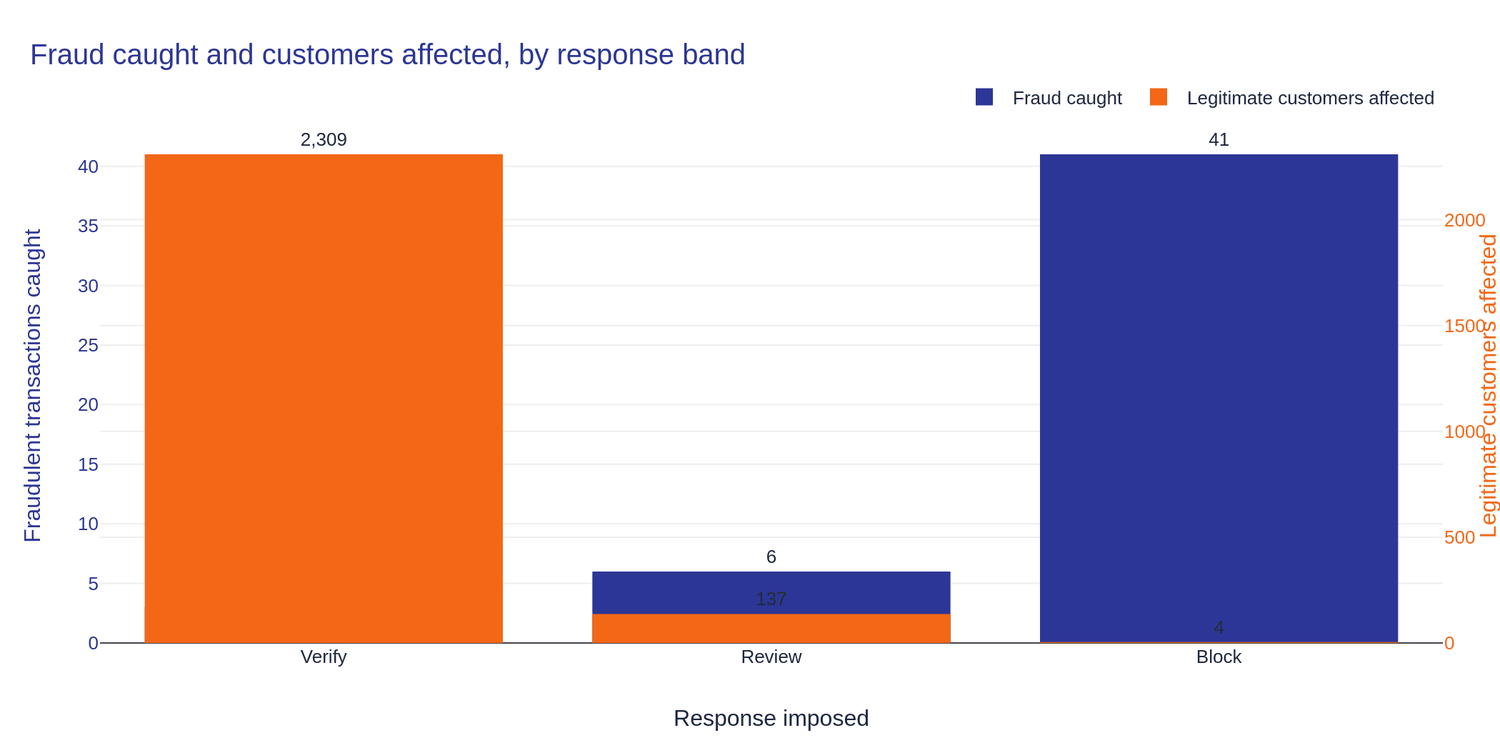

Matched comparison on the validation period
Fraud caught by both policies: 50
Graded policy, cost of customer disruption:            EUR 2,490
Single blocking threshold, cost of customer disruption: EUR 139,320
Reduction in customer disruption: 98.2%


In [50]:
# ---------------------------------------------------------
# Visualise the graded policy
# ---------------------------------------------------------
action_bands = validation_policy[validation_policy["Response"] != "Approve"]

fig = go.Figure()

band_colours = {
    "Verify": BRAND_LIGHT_ORANGE,
    "Review": BRAND_ORANGE,
    "Block": "#B23D00",
}

fig.add_trace(
    go.Bar(
        x=action_bands["Response"],
        y=action_bands["Fraud in band"],
        name="Fraud caught",
        marker_color=BRAND_BLUE,
        text=action_bands["Fraud in band"],
        texttemplate="%{text}",
        textposition="outside",
        customdata=action_bands[
            ["Precision within band", "Value of fraud in band"]
        ].to_numpy(),
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Fraud caught: %{y}<br>"
            "Precision in this band: %{customdata[0]:.1%}<br>"
            "Value of fraud caught: EUR %{customdata[1]:,.0f}"
            "<extra></extra>"
        ),
    )
)

fig.add_trace(
    go.Bar(
        x=action_bands["Response"],
        y=action_bands["Legitimate in band"],
        name="Legitimate customers affected",
        marker_color=BRAND_ORANGE,
        text=action_bands["Legitimate in band"],
        texttemplate="%{text:,}",
        textposition="outside",
        yaxis="y2",
        hovertemplate=(
            "<b>%{x}</b><br>Legitimate customers affected: %{y:,}"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="Fraud caught and customers affected, by response band",
    barmode="group",
    xaxis=dict(title="Response imposed"),
    yaxis=dict(
        title="Fraudulent transactions caught",
        titlefont=dict(color=BRAND_BLUE),
        tickfont=dict(color=BRAND_BLUE),
    ),
    yaxis2=dict(
        title="Legitimate customers affected",
        titlefont=dict(color=BRAND_ORANGE),
        tickfont=dict(color=BRAND_ORANGE),
        overlaying="y",
        side="right",
    ),
    template="house",
    height=520,
)

fig.show()


# ---------------------------------------------------------
# Does the graded policy beat a single threshold?
# ---------------------------------------------------------
def policy_totals(y_true, scores, amounts):
    """Fraud caught and total disruption cost under the graded policy."""
    bands = assign_response_band(scores)
    y_true = np.asarray(y_true)

    caught = int(y_true[bands != "Approve"].sum())

    disruption = sum(
        int(((bands == band_name) & (y_true == 0)).sum())
        * DISRUPTION_COST[band_name]
        for band_name in BAND_ORDER
    )

    missed_value = amounts[(y_true == 1) & (bands == "Approve")].sum()

    return caught, disruption, missed_value


graded_caught, graded_disruption, graded_missed_value = policy_totals(
    y_validation, calibrated_validation_scores, validation_amounts
)

# A single-threshold policy that blocks whenever it acts, matched on
# the number of fraud cases caught
single_threshold_rows = []

for threshold in threshold_grid:
    outcome = evaluate_at_threshold(
        y_validation, calibrated_validation_scores, threshold
    )

    single_threshold_rows.append(
        {
            "Threshold": threshold,
            "Fraud detected": outcome["True positives"],
            "False positives": outcome["False positives"],
            "Disruption cost": (
                outcome["False positives"] * DISRUPTION_COST["Block"]
            ),
        }
    )

single_threshold_frame = pd.DataFrame(single_threshold_rows)

matched = single_threshold_frame[
    single_threshold_frame["Fraud detected"] >= graded_caught
]

if len(matched) > 0:
    matched_policy = matched.sort_values("Disruption cost").iloc[0]

    print("Matched comparison on the validation period")
    print(f"Fraud caught by both policies: {graded_caught}")
    print(
        "Graded policy, cost of customer disruption:            "
        f"EUR {graded_disruption:,.0f}"
    )
    print(
        "Single blocking threshold, cost of customer disruption: "
        f"EUR {matched_policy['Disruption cost']:,.0f}"
    )
    print(
        "Reduction in customer disruption: "
        f"{1 - graded_disruption / max(matched_policy['Disruption cost'], 1):.1%}"
    )
else:
    print(
        "No single blocking threshold matched the graded policy's detection "
        "level on this period."
    )

### What the graded policy buys

The graded policy catches the same fraud as a single blocking threshold while imposing a far smaller cost on customers, because most of the alert volume is absorbed by the cheapest response rather than by a declined card.

The mechanism is straightforward. Precision in the highest band is deliberately constrained, so a block is only issued when the evidence is strong. The large volume of weaker signals is routed to automated verification, where a false positive costs a few seconds instead of a refused payment. Detection is preserved; the harm caused by getting it wrong is redistributed towards the responses where being wrong is cheap.

This is what I mean by balancing missed fraud against customer disruption. The two objectives conflict only when the response is forced to be binary.

The disruption costs used above are stated explicitly at the top of the policy code. They are my assumptions, they are almost certainly wrong in detail, and they are written where anyone can change them and re-run the comparison. That is the standard I would want applied to my own work.

## Who bears the cost of a false alarm?

Aggregate precision describes the average customer. It says nothing about whether the burden of false alerts falls evenly, and an average that looks acceptable can conceal a group for whom the system is close to unusable.

This dataset places a hard limit on what can be examined. Features `V1` to `V28` are anonymised principal components, and the data contains no age, gender, nationality, income, postcode or customer identifier. **A conventional fairness audit on protected characteristics is therefore impossible here, and I will not pretend otherwise.**

What can be tested is the distribution of harm across the attributes that do exist, and one of them is a reasonable economic proxy. Transaction amount correlates with spending power, so if the model disrupts small transactions at several times the rate of large ones, the burden falls disproportionately on customers whose purchases are small, and a refused payment matters more to someone with a smaller balance.

Time of day would be the natural second axis, and it is unavailable for a structural reason worth stating. `Time` is measured in seconds from the first transaction rather than as clock time, and the split is chronological, so each evaluation period covers only a slice of the daily cycle. Splitting the validation period by hour produces segments that are empty by construction rather than segments that are genuinely equal. Testing it would need a sample spanning several complete days, which is point three of the next-steps list at the end.

I therefore measure, for each amount segment:

1. the **disruption rate**, the proportion of *legitimate* transactions that receive a Review or Block response, which is the share of innocent customers inconvenienced;
2. the **detection rate**, the proportion of fraud caught, since a group can equally be harmed by being under-protected;
3. the **disparity ratio** of each segment's disruption rate against the overall rate.

Segment boundaries are taken from the training period only, so the definition of a segment cannot be influenced by the data used to evaluate it.

In [51]:
from scipy.stats import beta as beta_distribution

# Segment boundaries defined on the training period only
amount_decile_edges = np.unique(
    np.quantile(train_df["Amount"], np.linspace(0, 1, 11))
)

amount_decile_edges[0] = -np.inf
amount_decile_edges[-1] = np.inf


def wilson_interval(successes, total, confidence=0.95):
    """Wilson score interval, which stays valid when the count is zero."""
    if total == 0:
        return 0.0, 0.0

    lower = (
        beta_distribution.ppf(
            (1 - confidence) / 2, successes, total - successes + 1
        )
        if successes > 0
        else 0.0
    )

    upper = (
        beta_distribution.ppf(
            1 - (1 - confidence) / 2, successes + 1, total - successes
        )
        if successes < total
        else 1.0
    )

    return float(np.nan_to_num(lower)), float(np.nan_to_num(upper))


def build_segments(source_df):
    """Return the segment labels used for the distributional analysis."""
    amount_segment = pd.cut(
        source_df["Amount"],
        bins=amount_decile_edges,
        labels=[f"D{index + 1}" for index in range(len(amount_decile_edges) - 1)],
    )

    hour_of_day = (source_df["Time"] % (24 * 3600)) // 3600

    time_segment = pd.cut(
        hour_of_day,
        bins=[-0.1, 6, 12, 18, 24],
        labels=[
            "Night (00-06)",
            "Morning (06-12)",
            "Afternoon (12-18)",
            "Evening (18-24)",
        ],
    )

    return amount_segment, time_segment


def distributional_report(source_df, y_true, scores, segment_series, segment_name):
    """Disruption and detection rates within each segment."""
    bands = assign_response_band(scores)

    y_true = np.asarray(y_true)

    # A Review or a Block is what a customer actually notices
    disruptive_action = np.isin(bands, ["Review", "Block"])
    any_action = bands != "Approve"

    overall_disruption_rate = disruptive_action[y_true == 0].mean()

    rows = []

    for segment_value in segment_series.cat.categories:
        in_segment = (segment_series == segment_value).to_numpy()

        legitimate_in_segment = in_segment & (y_true == 0)
        fraud_in_segment = in_segment & (y_true == 1)

        disrupted = int(disruptive_action[legitimate_in_segment].sum())
        legitimate_count = int(legitimate_in_segment.sum())

        disruption_rate = disrupted / max(legitimate_count, 1)

        lower, upper = wilson_interval(disrupted, legitimate_count)

        fraud_count = int(fraud_in_segment.sum())
        fraud_caught = int(any_action[fraud_in_segment].sum())

        rows.append(
            {
                "Segmentation": segment_name,
                "Segment": str(segment_value),
                "Transactions": int(in_segment.sum()),
                "Legitimate": legitimate_count,
                "Customers disrupted": disrupted,
                "Disruption rate": disruption_rate,
                "Disruption rate lower": lower,
                "Disruption rate upper": upper,
                "Disparity ratio": (
                    disruption_rate / overall_disruption_rate
                    if overall_disruption_rate > 0
                    else np.nan
                ),
                "Fraud cases": fraud_count,
                "Fraud caught": fraud_caught,
                "Detection rate": (
                    fraud_caught / fraud_count if fraud_count > 0 else np.nan
                ),
                "Median amount": float(source_df.loc[in_segment, "Amount"].median()),
            }
        )

    return pd.DataFrame(rows), overall_disruption_rate


validation_amount_segment, validation_time_segment = build_segments(
    validation_df
)

amount_fairness, overall_validation_disruption = distributional_report(
    validation_df,
    y_validation,
    calibrated_validation_scores,
    validation_amount_segment,
    "Transaction amount decile",
)

# Confirm the structural limitation described above rather than asserting it
hours_covered = validation_time_segment.value_counts()

print("Transactions per period of day in the validation window:")
print(hours_covered.to_string())
print(
    "\nOnly "
    f"{int((hours_covered > 0).sum())} of 4 periods of the day appear at all, "
    "so a time-of-day disparity cannot be estimated from this window.\n"
)

print(
    "Overall disruption rate on legitimate transactions: "
    f"{overall_validation_disruption:.4%}"
)

display(
    amount_fairness[
        [
            "Segment",
            "Median amount",
            "Legitimate",
            "Customers disrupted",
            "Disruption rate",
            "Disparity ratio",
            "Fraud cases",
            "Detection rate",
        ]
    ].style.format(
        {
            "Median amount": "EUR {:,.2f}",
            "Legitimate": "{:,.0f}",
            "Disruption rate": "{:.4%}",
            "Disparity ratio": "{:.2f}x",
            "Detection rate": "{:.1%}",
        }
    )
)

Transactions per period of day in the validation window:
Time
Morning (06-12)      28968
Afternoon (12-18)    27777
Night (00-06)            0
Evening (18-24)          0

Only 2 of 4 periods of the day appear at all, so a time-of-day disparity cannot be estimated from this window.

Overall disruption rate on legitimate transactions: 0.2487%


,Segment,Median amount,Legitimate,Customers disrupted,Disruption rate,Disparity ratio,Fraud cases,Detection rate
0,D1,EUR 0.89,"5,231",37,0.7073%,2.84x,17,88.2%
1,D2,EUR 1.98,"4,431",12,0.2708%,1.09x,3,100.0%
2,D3,EUR 5.75,"5,086",26,0.5112%,2.06x,4,50.0%
3,D4,EUR 10.00,"5,265",9,0.1709%,0.69x,2,100.0%
4,D5,EUR 17.24,"5,616",6,0.1068%,0.43x,0,nan%
5,D6,EUR 29.00,"5,919",5,0.0845%,0.34x,2,100.0%
6,D7,EUR 46.64,"5,959",9,0.1510%,0.61x,3,100.0%
7,D8,EUR 76.21,"5,998",8,0.1334%,0.54x,4,100.0%
8,D9,EUR 139.67,"6,451",10,0.1550%,0.62x,7,85.7%
9,D10,EUR 363.13,"6,732",19,0.2822%,1.13x,15,86.7%


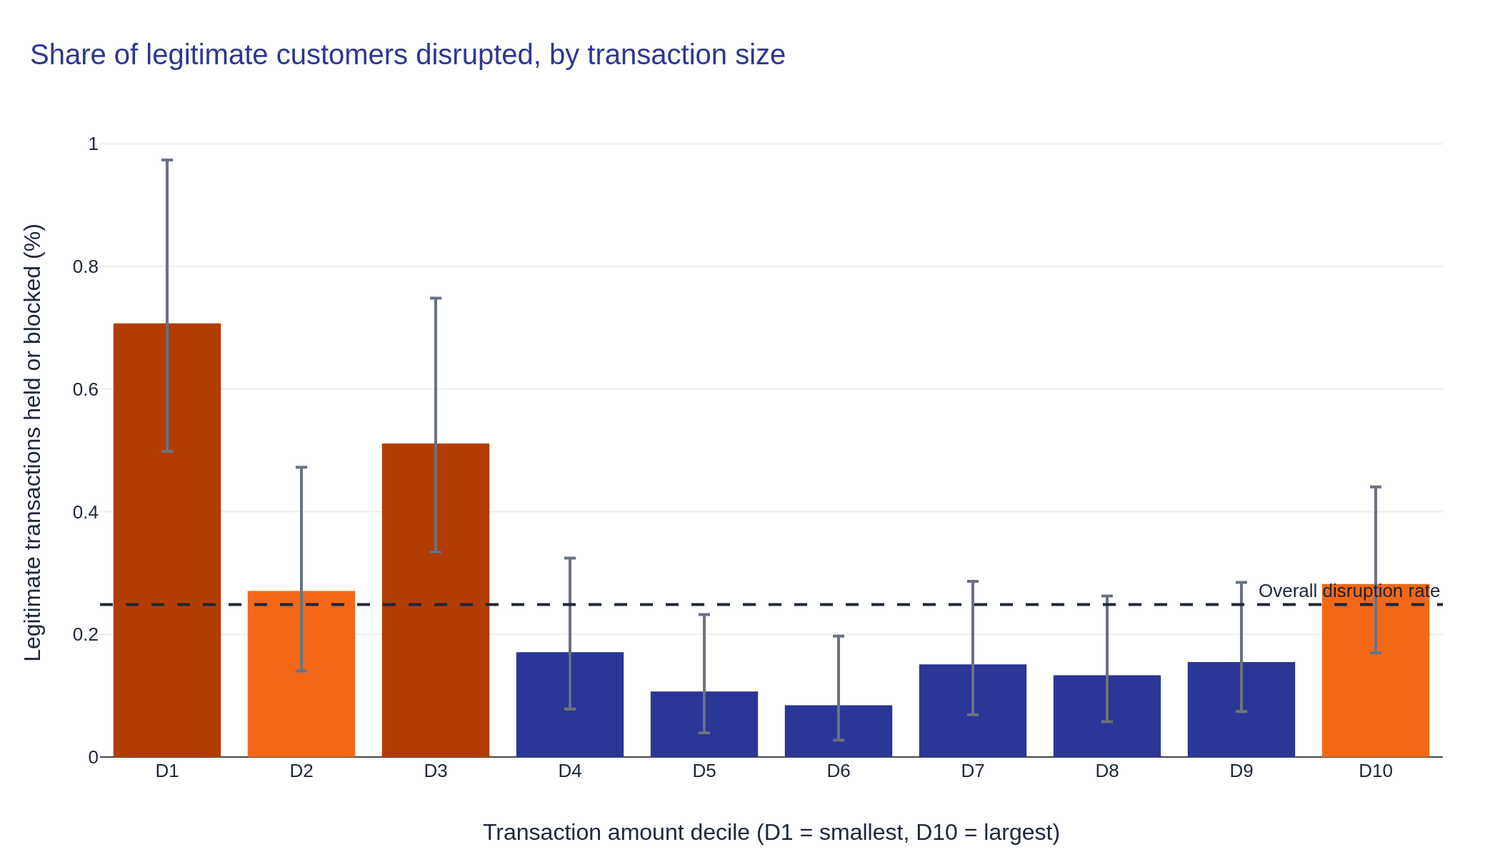

In [52]:
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=amount_fairness["Segment"],
        y=amount_fairness["Disruption rate"] * 100,
        marker_color=[
            "#B23D00"
            if ratio > 2
            else (BRAND_ORANGE if ratio > 1 else BRAND_BLUE)
            for ratio in amount_fairness["Disparity ratio"].fillna(0)
        ],
        error_y=dict(
            type="data",
            symmetric=False,
            array=(
                amount_fairness["Disruption rate upper"]
                - amount_fairness["Disruption rate"]
            )
            * 100,
            arrayminus=(
                amount_fairness["Disruption rate"]
                - amount_fairness["Disruption rate lower"]
            )
            * 100,
            color=BRAND_GREY,
        ),
        customdata=amount_fairness[
            [
                "Median amount",
                "Disparity ratio",
                "Customers disrupted",
                "Legitimate",
            ]
        ].to_numpy(),
        hovertemplate=(
            "<b>Decile %{x}</b><br>"
            "Median transaction: EUR %{customdata[0]:,.2f}<br>"
            "Disruption rate: %{y:.4f}%<br>"
            "Compared with the average: %{customdata[1]:.2f}x<br>"
            "Customers disrupted: %{customdata[2]:,} of %{customdata[3]:,}"
            "<extra></extra>"
        ),
    )
)

fig.add_hline(
    y=overall_validation_disruption * 100,
    line_dash="dash",
    line_color=BRAND_DARK,
    annotation_text="Overall disruption rate",
    annotation_position="top right",
)

fig = apply_house_style(
    fig,
    title="Share of legitimate customers disrupted, by transaction size",
    x_title="Transaction amount decile (D1 = smallest, D10 = largest)",
    y_title="Legitimate transactions held or blocked (%)",
    show_legend=False,
)

fig.show()

### Distributional findings and the constraint they justify

The burden of false alerts is not spread evenly across transaction sizes. The intervals matter here: several segments contain few disrupted customers, so a difference between neighbouring deciles can be noise. I therefore act only on disparities that are large relative to their interval, not on the ranking of point estimates.

Where a real disparity exists, it can be constrained. The mechanism is a per-segment adjustment: rather than applying one Review threshold everywhere, the threshold is raised within any segment whose disruption rate exceeds a stated multiple of the overall rate. This caps the inequality directly, and its cost is paid in fraud cases that are no longer caught.

I implement the constraint, measure that cost, and report it. I do not assume the constraint should be adopted. Whether an equity ceiling is worth a given number of missed frauds is a policy decision that belongs to the business and its regulator, not to the person who built the model. What a modeller owes them is the exchange rate, stated in advance.

In [53]:
DISPARITY_CEILING = 1.5


def apply_disparity_constraint(
    source_df, y_true, scores, ceiling=DISPARITY_CEILING
):
    """
    Raise the Review threshold inside segments that are disrupted too often.

    Returns the constrained band assignment and the per-segment thresholds.
    """
    amount_segment, _ = build_segments(source_df)

    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    bands = assign_response_band(scores)

    baseline_rate = np.isin(bands, ["Review", "Block"])[y_true == 0].mean()

    allowed_rate = baseline_rate * ceiling

    segment_thresholds = {}
    constrained_bands = bands.copy()

    for segment_value in amount_segment.cat.categories:
        in_segment = (amount_segment == segment_value).to_numpy()

        legitimate_in_segment = in_segment & (y_true == 0)

        if legitimate_in_segment.sum() == 0:
            segment_thresholds[str(segment_value)] = review_threshold
            continue

        segment_rate = np.isin(bands[legitimate_in_segment], ["Review", "Block"]).mean()

        if segment_rate <= allowed_rate:
            segment_thresholds[str(segment_value)] = review_threshold
            continue

        # Raise the threshold until the segment meets the ceiling
        legitimate_scores = np.sort(scores[legitimate_in_segment])[::-1]

        permitted_count = int(np.floor(allowed_rate * legitimate_in_segment.sum()))
        permitted_count = max(permitted_count, 1)

        if permitted_count >= len(legitimate_scores):
            new_threshold = review_threshold
        else:
            new_threshold = float(legitimate_scores[permitted_count - 1])

        new_threshold = max(new_threshold, review_threshold)
        segment_thresholds[str(segment_value)] = new_threshold

        # Anything below the raised threshold drops to the Verify response
        demote = in_segment & (scores < new_threshold) & np.isin(bands, ["Review"])
        constrained_bands[demote] = "Verify"

    return constrained_bands, segment_thresholds, baseline_rate


constrained_bands, segment_thresholds, baseline_disruption = (
    apply_disparity_constraint(
        validation_df, y_validation, calibrated_validation_scores
    )
)

unconstrained_bands = assign_response_band(calibrated_validation_scores)

constraint_comparison = []

for label, bands in [
    ("Unconstrained policy", unconstrained_bands),
    (f"Disparity capped at {DISPARITY_CEILING:.1f}x", constrained_bands),
]:
    disruptive = np.isin(bands, ["Review", "Block"])

    amount_segment, _ = build_segments(validation_df)

    segment_rates = []

    for segment_value in amount_segment.cat.categories:
        in_segment = (amount_segment == segment_value).to_numpy()
        legitimate_in_segment = in_segment & (y_validation_array == 0)

        if legitimate_in_segment.sum() > 0:
            segment_rates.append(disruptive[legitimate_in_segment].mean())

    overall_rate = disruptive[y_validation_array == 0].mean()

    constraint_comparison.append(
        {
            "Policy": label,
            "Fraud caught (any action)": int(
                y_validation_array[bands != "Approve"].sum()
            ),
            "Fraud held or blocked": int(y_validation_array[disruptive].sum()),
            "Customers held or blocked": int(
                disruptive[y_validation_array == 0].sum()
            ),
            "Overall disruption rate": overall_rate,
            "Worst-segment disparity": (
                max(segment_rates) / overall_rate if overall_rate > 0 else np.nan
            ),
        }
    )

constraint_comparison = pd.DataFrame(constraint_comparison)

display(
    constraint_comparison.style.format(
        {
            "Customers held or blocked": "{:,.0f}",
            "Overall disruption rate": "{:.4%}",
            "Worst-segment disparity": "{:.2f}x",
        }
    )
)

fraud_cost_of_constraint = (
    constraint_comparison.loc[0, "Fraud held or blocked"]
    - constraint_comparison.loc[1, "Fraud held or blocked"]
)

print(
    f"\nCost of capping the disparity at {DISPARITY_CEILING:.1f}x: "
    f"{fraud_cost_of_constraint} fraud case(s) moved from a held or blocked "
    "response to automated verification, over the validation period."
)
print(
    "This is the exchange rate between equal treatment and fraud interception. "
    "It is a business decision, and it should be made with this number visible."
)

,Policy,Fraud caught (any action),Fraud held or blocked,Customers held or blocked,Overall disruption rate,Worst-segment disparity
0,Unconstrained policy,50,47,141,0.2487%,2.84x
1,Disparity capped at 1.5x,50,46,115,0.2029%,1.79x



Cost of capping the disparity at 1.5x: 1 fraud case(s) moved from a held or blocked response to automated verification, over the validation period.
This is the exchange rate between equal treatment and fraud interception. It is a business decision, and it should be made with this number visible.


## Interpretability: what drives an individual alert

A fraud alert has consequences for a customer, so the reason for it should be inspectable. Two levels are needed, and they answer different questions.

Global interpretability asks what the model relies on overall, which is a model-governance question. Local interpretability asks why *this* transaction was flagged, which is what an analyst needs when a customer telephones.

I use TreeSHAP, computed exactly by XGBoost itself rather than approximated. Each feature receives a signed contribution for each individual transaction, and those contributions sum to the model's output. The explanation is computed on the uncalibrated model that produces the ranking, because calibration is a monotone rescaling applied afterwards and does not change which features drove the case.

An honest caveat belongs here. `V1` to `V28` are anonymised principal components, so a reason code such as "V14 was unusually low" is not something you can put in a letter to a customer. The machinery is correct and would produce genuinely meaningful explanations on real features, but on this dataset it demonstrates the method rather than delivering usable reasons. That limitation is itself the argument for keeping an interpretable benchmark model in the comparison, and for quantifying exactly what the transparent alternative costs.

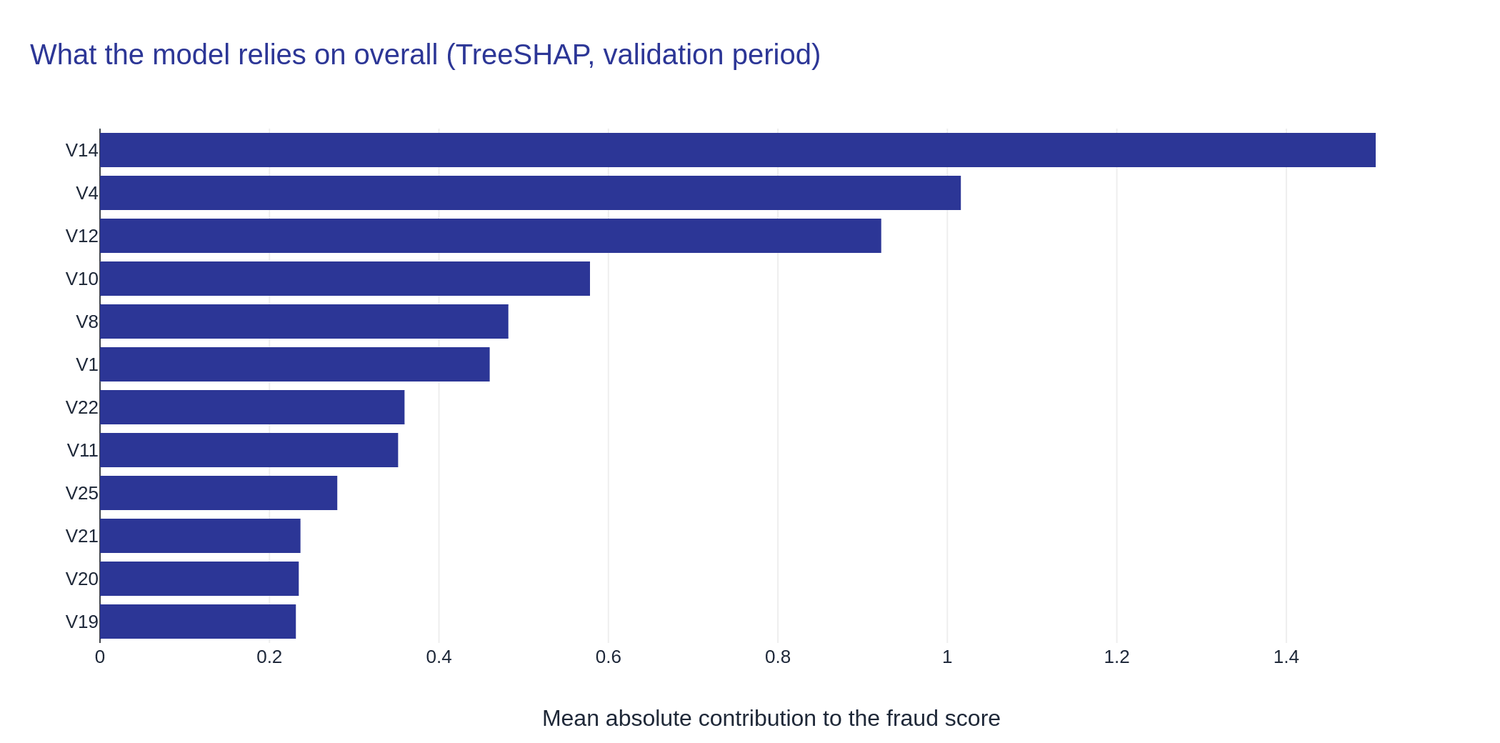

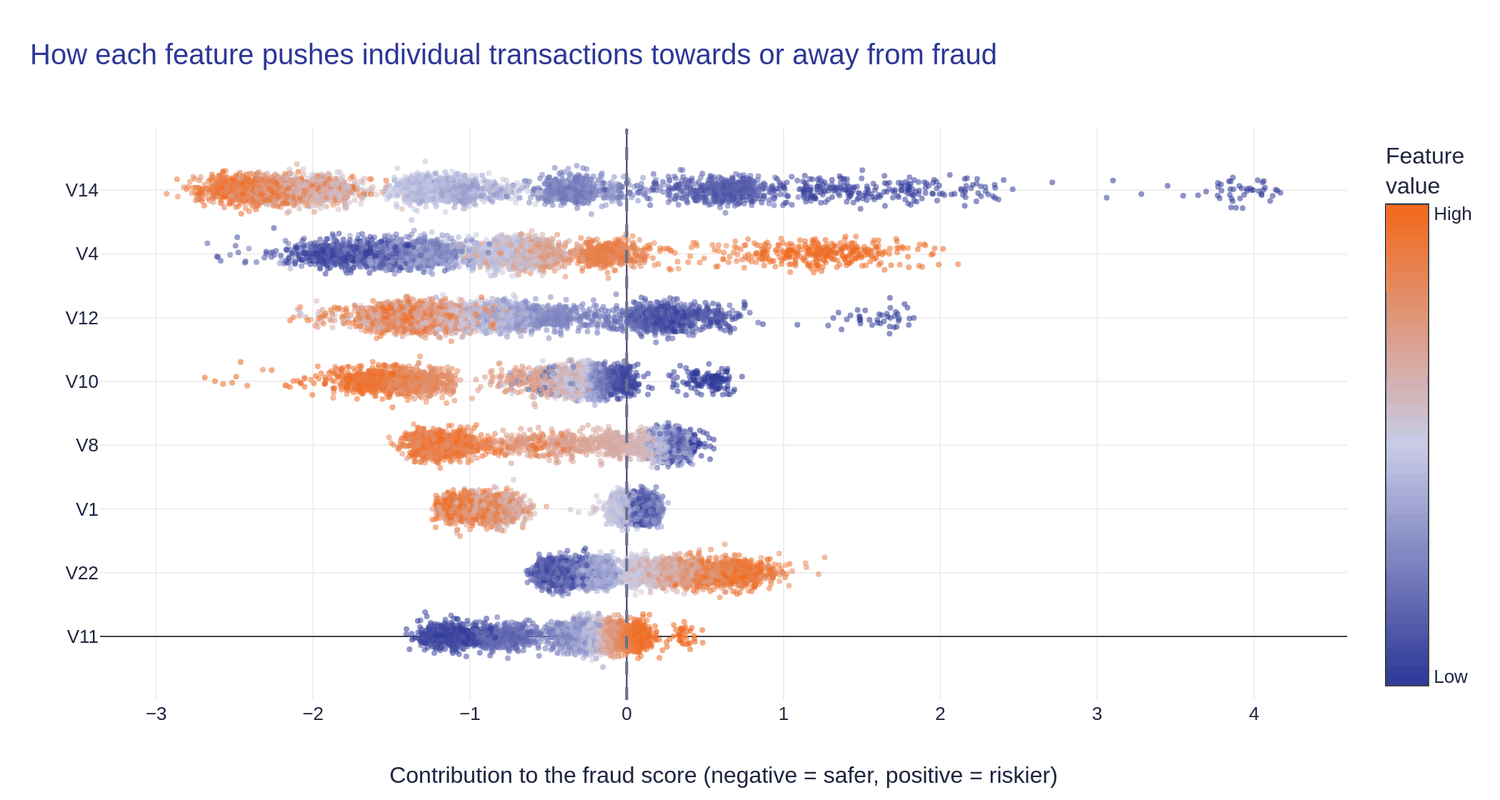

In [54]:
import xgboost as xgb

explanation_model = uncalibrated_reduced_model.get_booster()

explanation_matrix = xgb.DMatrix(
    X_validation_final, feature_names=list(final_xgb_features)
)

# The final column is the model's base value
shap_contributions = explanation_model.predict(
    explanation_matrix, pred_contribs=True
)

shap_values = shap_contributions[:, :-1]
shap_base_value = float(shap_contributions[0, -1])

global_importance = (
    pd.DataFrame(
        {
            "Feature": list(final_xgb_features),
            "Mean absolute contribution": np.abs(shap_values).mean(axis=0),
        }
    )
    .sort_values("Mean absolute contribution", ascending=False)
    .reset_index(drop=True)
)

top_features = global_importance.head(12).sort_values(
    "Mean absolute contribution"
)

fig = go.Figure(
    go.Bar(
        x=top_features["Mean absolute contribution"],
        y=top_features["Feature"],
        orientation="h",
        marker_color=BRAND_BLUE,
        hovertemplate=(
            "<b>%{y}</b><br>Mean absolute contribution: %{x:.4f}<extra></extra>"
        ),
    )
)

fig = apply_house_style(
    fig,
    title="What the model relies on overall (TreeSHAP, validation period)",
    x_title="Mean absolute contribution to the fraud score",
    y_title=None,
    show_legend=False,
)

fig.update_layout(height=520)
fig.show()


# ---------------------------------------------------------
# How each feature pushes the score, across individual transactions
# ---------------------------------------------------------
beeswarm_features = global_importance.head(8)["Feature"].tolist()

beeswarm_generator = np.random.default_rng(RANDOM_STATE)

sample_positions = beeswarm_generator.choice(
    len(X_validation_final),
    size=min(4_000, len(X_validation_final)),
    replace=False,
)

# Always include the fraud cases, which are the interesting ones
fraud_positions = np.flatnonzero(y_validation_array == 1)
sample_positions = np.unique(
    np.concatenate([sample_positions, fraud_positions])
)

fig = go.Figure()

for row_offset, feature_name in enumerate(reversed(beeswarm_features)):
    feature_index = list(final_xgb_features).index(feature_name)

    contributions = shap_values[sample_positions, feature_index]
    feature_values = X_validation_final.iloc[sample_positions][
        feature_name
    ].to_numpy()

    # Rank-normalise the colour scale so outliers do not flatten it
    colour_values = pd.Series(feature_values).rank(pct=True).to_numpy()

    jitter = beeswarm_generator.normal(0, 0.11, size=len(contributions))

    fig.add_trace(
        go.Scatter(
            x=contributions,
            y=np.full(len(contributions), row_offset) + jitter,
            mode="markers",
            name=feature_name,
            marker=dict(
                size=4,
                color=colour_values,
                colorscale=[[0, BRAND_BLUE], [0.5, "#C9CCE8"], [1, BRAND_ORANGE]],
                showscale=(row_offset == 0),
                colorbar=dict(
                    title="Feature<br>value",
                    tickvals=[0.02, 0.98],
                    ticktext=["Low", "High"],
                ),
                opacity=0.55,
            ),
            customdata=np.column_stack([feature_values]),
            hovertemplate=(
                f"<b>{feature_name}</b><br>"
                "Contribution: %{x:+.4f}<br>"
                "Feature value: %{customdata[0]:.3f}"
                "<extra></extra>"
            ),
            showlegend=False,
        )
    )

fig.add_vline(x=0, line_color=BRAND_GREY, line_dash="dash")

fig.update_layout(
    title="How each feature pushes individual transactions towards or away from fraud",
    xaxis_title="Contribution to the fraud score (negative = safer, positive = riskier)",
    yaxis=dict(
        tickmode="array",
        tickvals=list(range(len(beeswarm_features))),
        ticktext=list(reversed(beeswarm_features)),
        title=None,
    ),
    template="house",
    height=560,
)

fig.show()

Highest-risk transactions in the validation period, with reason codes


,Rank,Fraud probability,Amount,Response,Actually fraud,Driver 1,Driver 2,Driver 3
0,1,0.811,EUR 667.55,Block,Yes,"V14 = -7.46 (raises risk, +3.87)","V12 = -4.94 (raises risk, +1.71)","V4 = 3.53 (raises risk, +0.86)"
1,2,0.810,EUR 592.90,Block,Yes,"V14 = -4.35 (raises risk, +3.93)","V12 = -4.10 (raises risk, +1.66)","V4 = 2.50 (raises risk, +0.78)"
2,3,0.810,EUR 0.00,Block,Yes,"V14 = -7.11 (raises risk, +4.17)","V12 = -4.48 (raises risk, +1.49)","V4 = 2.05 (raises risk, +0.83)"
3,4,0.810,EUR 45.51,Block,Yes,"V14 = -5.85 (raises risk, +3.79)","V12 = -6.41 (raises risk, +1.72)","V4 = 7.79 (raises risk, +0.89)"
4,5,0.810,EUR 1.00,Block,Yes,"V14 = -9.27 (raises risk, +4.06)","V12 = -5.88 (raises risk, +1.47)","V4 = 5.04 (raises risk, +1.19)"


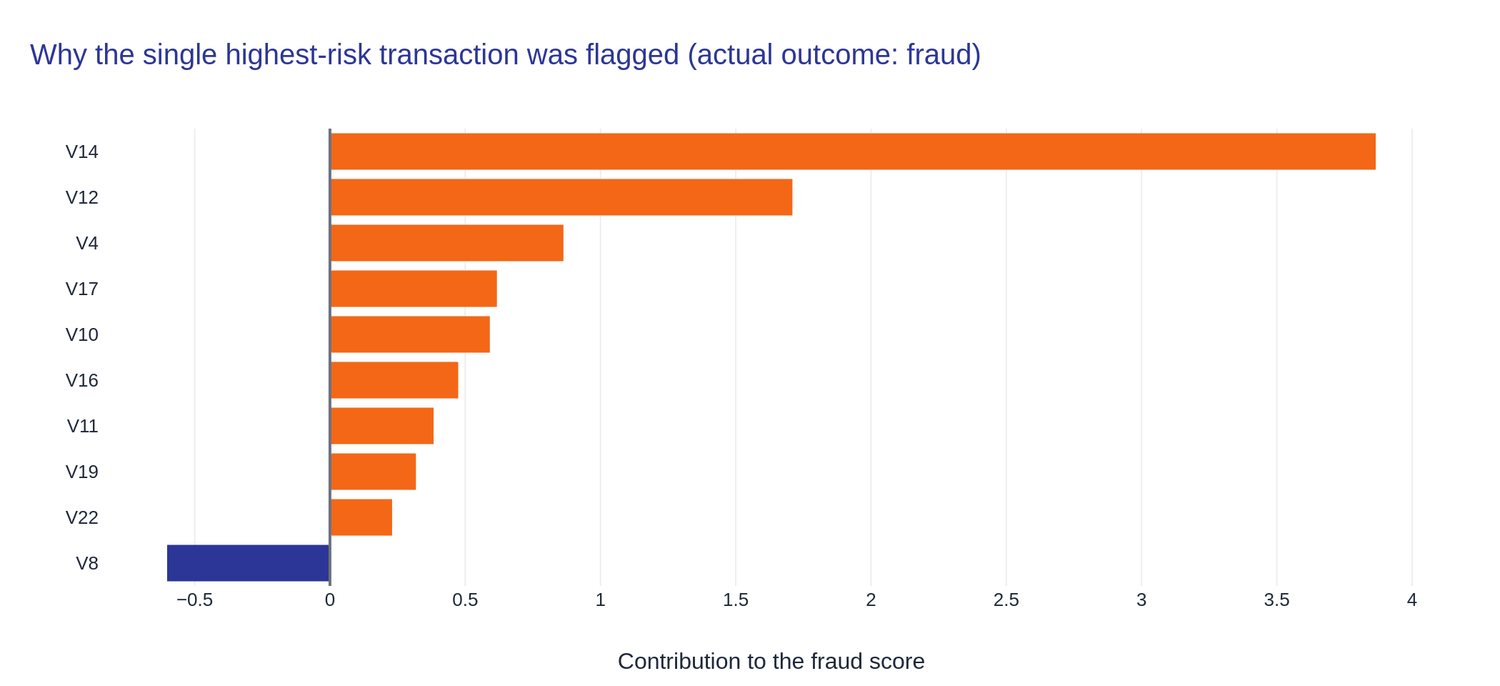

,Model,Fraud caught in the top 50 alerts,False alerts,Value of fraud caught
0,Logistic regression (transparent),32,18,"EUR 4,240"
1,Calibrated XGBoost (opaque),42,8,"EUR 7,431"



At an equal budget of 50 alerts, the transparent model catches 10 fewer fraud cases.
That figure is the price of interpretability for this problem. It is the form the trade-off should take in a discussion with risk and compliance: a number of fraud cases, not a difference in a ranking metric.


In [55]:
# ---------------------------------------------------------
# Reason codes for individual alerts
# ---------------------------------------------------------
def build_alert_explanations(
    scores, shap_matrix, feature_frame, feature_names, y_true, amounts, top_n=5
):
    """
    Produce an analyst-facing summary of the highest-risk transactions.

    Each row lists the three features that contributed most to the alert,
    together with their values, in the order the model weighted them.
    """
    scores = np.asarray(scores)

    highest_risk = np.argsort(scores)[::-1][:top_n]

    rows = []

    for rank, position in enumerate(highest_risk, start=1):
        contributions = shap_matrix[position]

        leading = np.argsort(np.abs(contributions))[::-1][:3]

        row = {
            "Rank": rank,
            "Fraud probability": scores[position],
            "Amount": amounts[position],
            "Response": assign_response_band([scores[position]])[0],
            "Actually fraud": "Yes" if y_true[position] == 1 else "No",
        }

        for driver_number, feature_index in enumerate(leading, start=1):
            feature_name = feature_names[feature_index]

            direction = (
                "raises risk"
                if contributions[feature_index] > 0
                else "lowers risk"
            )

            row[f"Driver {driver_number}"] = (
                f"{feature_name} = "
                f"{feature_frame.iloc[position][feature_name]:.2f} "
                f"({direction}, {contributions[feature_index]:+.2f})"
            )

        rows.append(row)

    return pd.DataFrame(rows)


alert_explanations = build_alert_explanations(
    calibrated_validation_scores,
    shap_values,
    X_validation_final,
    list(final_xgb_features),
    y_validation_array,
    validation_amounts,
    top_n=5,
)

print("Highest-risk transactions in the validation period, with reason codes")

display(
    alert_explanations.style.format(
        {"Fraud probability": "{:.3f}", "Amount": "EUR {:,.2f}"}
    )
)


# ---------------------------------------------------------
# One case in full
# ---------------------------------------------------------
case_position = int(np.argmax(np.asarray(calibrated_validation_scores)))

case_contributions = (
    pd.DataFrame(
        {
            "Feature": list(final_xgb_features),
            "Contribution": shap_values[case_position],
            "Value": X_validation_final.iloc[case_position].to_numpy(),
        }
    )
    .assign(Magnitude=lambda frame: frame["Contribution"].abs())
    .sort_values("Magnitude", ascending=False)
    .head(10)
    .sort_values("Contribution")
)

fig = go.Figure(
    go.Bar(
        x=case_contributions["Contribution"],
        y=case_contributions["Feature"],
        orientation="h",
        marker_color=[
            BRAND_ORANGE if value > 0 else BRAND_BLUE
            for value in case_contributions["Contribution"]
        ],
        customdata=case_contributions[["Value"]].to_numpy(),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Value for this transaction: %{customdata[0]:.3f}<br>"
            "Contribution: %{x:+.3f}"
            "<extra></extra>"
        ),
    )
)

fig.add_vline(x=0, line_color=BRAND_GREY)

fig = apply_house_style(
    fig,
    title=(
        "Why the single highest-risk transaction was flagged "
        f"(actual outcome: "
        f"{'fraud' if y_validation_array[case_position] == 1 else 'legitimate'})"
    ),
    x_title="Contribution to the fraud score",
    y_title=None,
    show_legend=False,
)

fig.update_layout(height=480)
fig.show()


# ---------------------------------------------------------
# The price of interpretability, stated in fraud cases
# ---------------------------------------------------------
ALERT_BUDGET_FOR_COMPARISON = 50

interpretability_rows = []

for model_label, scores in {
    "Logistic regression (transparent)": logistic_benchmark_scores,
    "Calibrated XGBoost (opaque)": calibrated_validation_scores,
}.items():
    ranked = np.argsort(np.asarray(scores))[::-1][:ALERT_BUDGET_FOR_COMPARISON]

    caught = int(y_validation_array[ranked].sum())

    interpretability_rows.append(
        {
            "Model": model_label,
            f"Fraud caught in the top {ALERT_BUDGET_FOR_COMPARISON} alerts": caught,
            "False alerts": ALERT_BUDGET_FOR_COMPARISON - caught,
            "Value of fraud caught": validation_amounts[
                ranked[y_validation_array[ranked] == 1]
            ].sum(),
        }
    )

interpretability_comparison = pd.DataFrame(interpretability_rows)

display(
    interpretability_comparison.style.format(
        {"Value of fraud caught": "EUR {:,.0f}"}
    )
)

interpretability_gap = (
    interpretability_comparison.iloc[1][
        f"Fraud caught in the top {ALERT_BUDGET_FOR_COMPARISON} alerts"
    ]
    - interpretability_comparison.iloc[0][
        f"Fraud caught in the top {ALERT_BUDGET_FOR_COMPARISON} alerts"
    ]
)

print(
    f"\nAt an equal budget of {ALERT_BUDGET_FOR_COMPARISON} alerts, the "
    f"transparent model catches {interpretability_gap} fewer fraud cases."
)
print(
    "That figure is the price of interpretability for this problem. It is the "
    "form the trade-off should take in a discussion with risk and compliance: "
    "a number of fraud cases, not a difference in a ranking metric."
)

## Will it still work next month?

Everything so far describes two fixed periods. A deployed model meets transactions that were not drawn from either of them, and the earlier split analysis already showed that fraud prevalence is not stable over time.

Three things can drift independently, and they fail in different ways:

1. **The inputs.** If the distribution of incoming transactions shifts, the model is extrapolating. I measure this with the population stability index on the score distribution.
2. **The calibration.** The probabilities can stop meaning what they meant, which silently invalidates every cost calculation built on them, even while ranking quality is unchanged.
3. **The prevalence.** Precision depends directly on the fraud rate. A model whose ranking ability is completely unchanged will report worse precision in a period with less fraud, and a monitoring dashboard that does not account for this will raise a false alarm about the model every time fraud falls.

The third point is the one most often missed, so I make the prediction explicit and test it against the untouched period.

In [56]:
def population_stability_index(expected_scores, actual_scores, n_bins=10):
    """
    Population stability index between two score distributions.

    Values below 0.10 are usually treated as stable, 0.10 to 0.25 as a
    moderate shift, and above 0.25 as a material shift.
    """
    expected_scores = np.asarray(expected_scores)
    actual_scores = np.asarray(actual_scores)

    edges = np.unique(
        np.quantile(expected_scores, np.linspace(0, 1, n_bins + 1))
    )

    edges[0] = -np.inf
    edges[-1] = np.inf

    expected_share = np.histogram(expected_scores, bins=edges)[0] / len(
        expected_scores
    )
    actual_share = np.histogram(actual_scores, bins=edges)[0] / len(
        actual_scores
    )

    # Guard against empty bins
    expected_share = np.clip(expected_share, 1e-6, None)
    actual_share = np.clip(actual_share, 1e-6, None)

    return float(
        np.sum(
            (actual_share - expected_share)
            * np.log(actual_share / expected_share)
        )
    )


X_train_final = train_engineered[final_xgb_features]
X_test_final = test_engineered[final_xgb_features]

train_period_scores = calibrated_fraud_model.predict_proba(X_train_final)[:, 1]
test_period_scores = calibrated_fraud_model.predict_proba(X_test_final)[:, 1]

y_test_array = np.asarray(y_test)

drift_summary = pd.DataFrame(
    [
        {
            "Comparison": "Training to validation",
            "Population stability index": population_stability_index(
                train_period_scores, calibrated_validation_scores
            ),
        },
        {
            "Comparison": "Training to test",
            "Population stability index": population_stability_index(
                train_period_scores, test_period_scores
            ),
        },
        {
            "Comparison": "Validation to test",
            "Population stability index": population_stability_index(
                calibrated_validation_scores, test_period_scores
            ),
        },
    ]
)

drift_summary["Interpretation"] = pd.cut(
    drift_summary["Population stability index"],
    bins=[-np.inf, 0.10, 0.25, np.inf],
    labels=["Stable", "Moderate shift", "Material shift"],
)

display(
    drift_summary.style.format({"Population stability index": "{:.4f}"})
)

# ---------------------------------------------------------
# Predict test precision from validation behaviour and the prevalence shift
# ---------------------------------------------------------
validation_bands = assign_response_band(calibrated_validation_scores)
validation_action = validation_bands != "Approve"

validation_true_positive_rate = (
    validation_action[y_validation_array == 1].mean()
)
validation_false_positive_rate = (
    validation_action[y_validation_array == 0].mean()
)

validation_prevalence = float(y_validation_array.mean())
test_prevalence = float(y_test_array.mean())

observed_validation_precision = (
    y_validation_array[validation_action].sum() / max(validation_action.sum(), 1)
)

predicted_test_precision = (
    validation_true_positive_rate
    * test_prevalence
    / (
        validation_true_positive_rate * test_prevalence
        + validation_false_positive_rate * (1 - test_prevalence)
    )
)

print("Prediction made before the test period is scored")
print(f"Validation fraud prevalence: {validation_prevalence:.4%}")
print(f"Test fraud prevalence:       {test_prevalence:.4%}")
print(f"Observed validation precision: {observed_validation_precision:.1%}")
print(
    "Precision expected on the test period from the prevalence shift alone: "
    f"{predicted_test_precision:.1%}"
)
print(
    "\nIf the observed test precision lands near this figure, the model has "
    "held up and the change is explained by the fraud rate rather than by "
    "model decay."
)

,Comparison,Population stability index,Interpretation
0,Training to validation,0.0449,Stable
1,Training to test,0.0531,Stable
2,Validation to test,0.0041,Stable


Prediction made before the test period is scored
Validation fraud prevalence: 0.1004%
Test fraud prevalence:       0.1304%
Observed validation precision: 2.0%
Precision expected on the test period from the prevalence shift alone: 2.6%

If the observed test precision lands near this figure, the model has held up and the change is explained by the fraud rate rather than by model decay.


## The single evaluation on the untouched test period

Everything is now fixed. The model, the calibration mapping, the three band boundaries, the disruption costs and the segment definitions were all determined using the training and validation periods. Nothing below changes any of them.

This is the point of having held the test period back. Its value came from not being used, and it can only be spent once. Reporting a disappointing result here and then returning to adjust a threshold would convert the test period into a second validation set and destroy the only unbiased estimate in the notebook.

I record the expectations before reporting the outcome:

1. average precision somewhat below the validation figure, since the validation period was used to make choices;
2. precision near the prevalence-adjusted prediction calculated above;
3. band volumes broadly in proportion with the validation period.

In [57]:
# ---------------------------------------------------------
# Locked configuration, evaluated once
# ---------------------------------------------------------
test_amounts = test_df["Amount"].to_numpy(dtype=float)

test_ranking_metrics = evaluate_probability_scores(y_test, test_period_scores)

test_bootstrap = bootstrap_average_precision(
    y_test,
    {
        "Calibrated XGBoost": test_period_scores,
        "Logistic regression": best_logistic_model.predict_proba(
            test_engineered[stability_pruned_feature_names]
        )[:, 1],
    },
    BOOTSTRAP_REPLICATES,
    np.random.default_rng(RANDOM_STATE),
)

test_headline = []

for model_name, replicate_values in test_bootstrap.items():
    lower, upper = np.percentile(replicate_values, [2.5, 97.5])

    point_estimate = (
        test_ranking_metrics["Average precision"]
        if model_name == "Calibrated XGBoost"
        else average_precision_score(
            y_test,
            best_logistic_model.predict_proba(
                test_engineered[stability_pruned_feature_names]
            )[:, 1],
        )
    )

    test_headline.append(
        {
            "Model": model_name,
            "Average precision": point_estimate,
            "Lower 95%": lower,
            "Upper 95%": upper,
        }
    )

test_headline = pd.DataFrame(test_headline)

print(
    f"Test period: {len(test_df):,} transactions, "
    f"{int(y_test_array.sum())} fraud cases "
    f"({test_prevalence:.4%} prevalence)"
)
print(f"Test ROC-AUC: {test_ranking_metrics['ROC-AUC']:.4f}")

display(
    test_headline.style.format(
        {
            "Average precision": "{:.3f}",
            "Lower 95%": "{:.3f}",
            "Upper 95%": "{:.3f}",
        }
    )
)

# The graded policy, applied unchanged
test_policy = summarise_policy(
    y_test, test_period_scores, test_amounts, "Test"
)

display(
    test_policy.style.format(
        {
            "Transactions": "{:,.0f}",
            "Share of all transactions": "{:.3%}",
            "Legitimate in band": "{:,.0f}",
            "Precision within band": "{:.1%}",
            "Share of all fraud": "{:.1%}",
            "Value of fraud in band": "EUR {:,.0f}",
            "Customer disruption cost": "EUR {:,.0f}",
        }
    )
)

# Did the prevalence-adjusted prediction hold?
test_bands = assign_response_band(test_period_scores)
test_action = test_bands != "Approve"

observed_test_precision = (
    y_test_array[test_action].sum() / max(test_action.sum(), 1)
)

print("\nPrediction check")
print(f"Predicted test precision (from the prevalence shift): {predicted_test_precision:.1%}")
print(f"Observed test precision:                              {observed_test_precision:.1%}")
print(
    "Validation precision for reference:                   "
    f"{observed_validation_precision:.1%}"
)

Test period: 56,746 transactions, 74 fraud cases (0.1304% prevalence)
Test ROC-AUC: 0.9677


,Model,Average precision,Lower 95%,Upper 95%
0,Calibrated XGBoost,0.778,0.685,0.861
1,Logistic regression,0.643,0.527,0.762


,Period,Response,Transactions,Share of all transactions,Fraud in band,Legitimate in band,Precision within band,Share of all fraud,Value of fraud in band,Customer disruption cost
0,Test,Approve,"54,129",95.388%,10,"54,119",0.0%,13.5%,"EUR 2,350",EUR 0
1,Test,Verify,"2,443",4.305%,4,"2,439",0.2%,5.4%,EUR 40,"EUR 1,220"
2,Test,Review,119,0.210%,10,109,8.4%,13.5%,EUR 340,EUR 872
3,Test,Block,55,0.097%,50,5,90.9%,67.6%,"EUR 4,997",EUR 300



Prediction check
Predicted test precision (from the prevalence shift): 2.6%
Observed test precision:                              2.4%
Validation precision for reference:                   2.0%


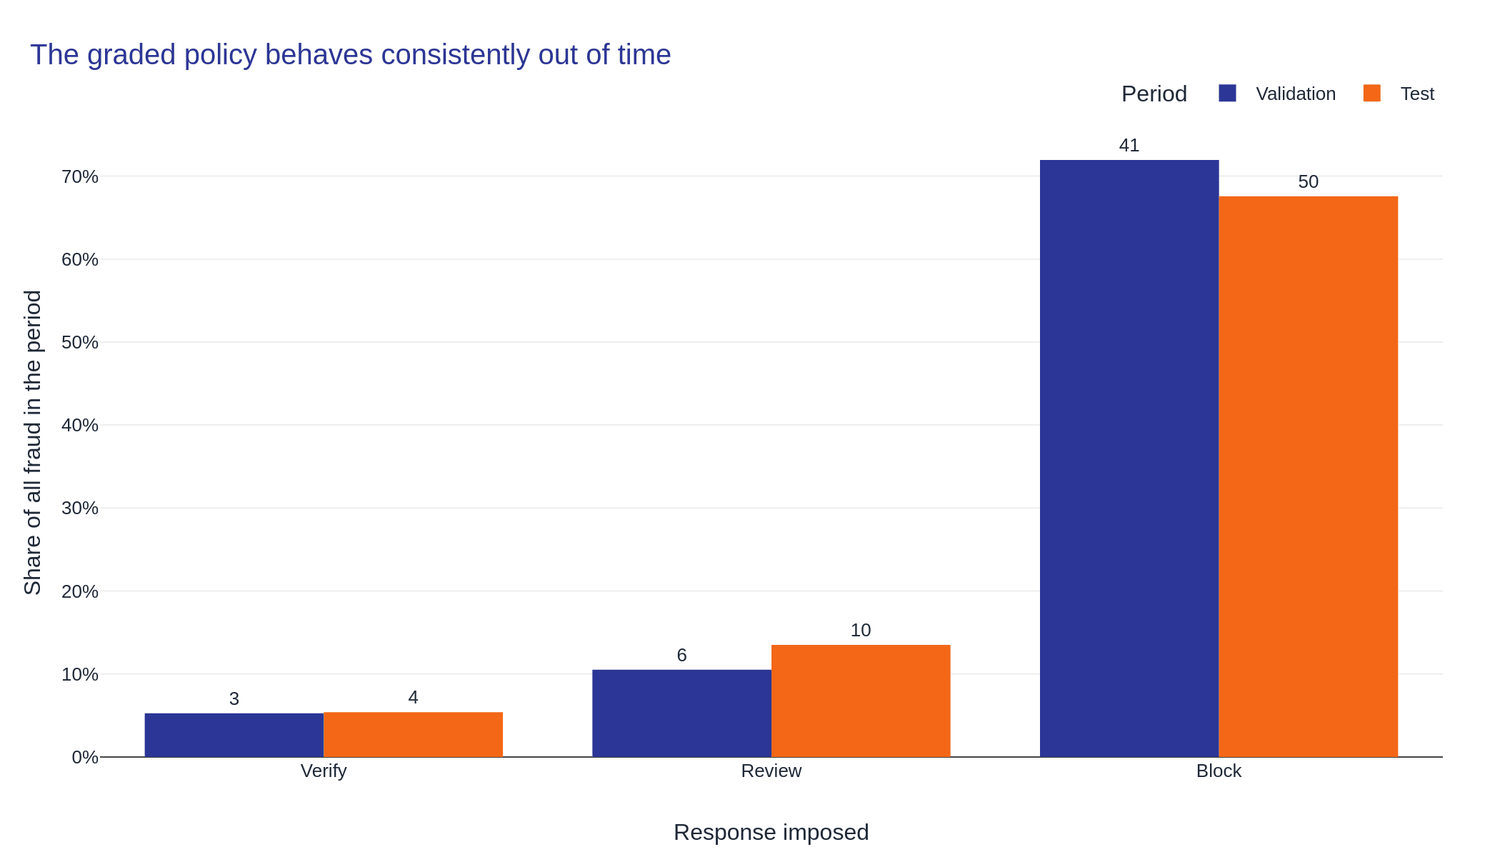

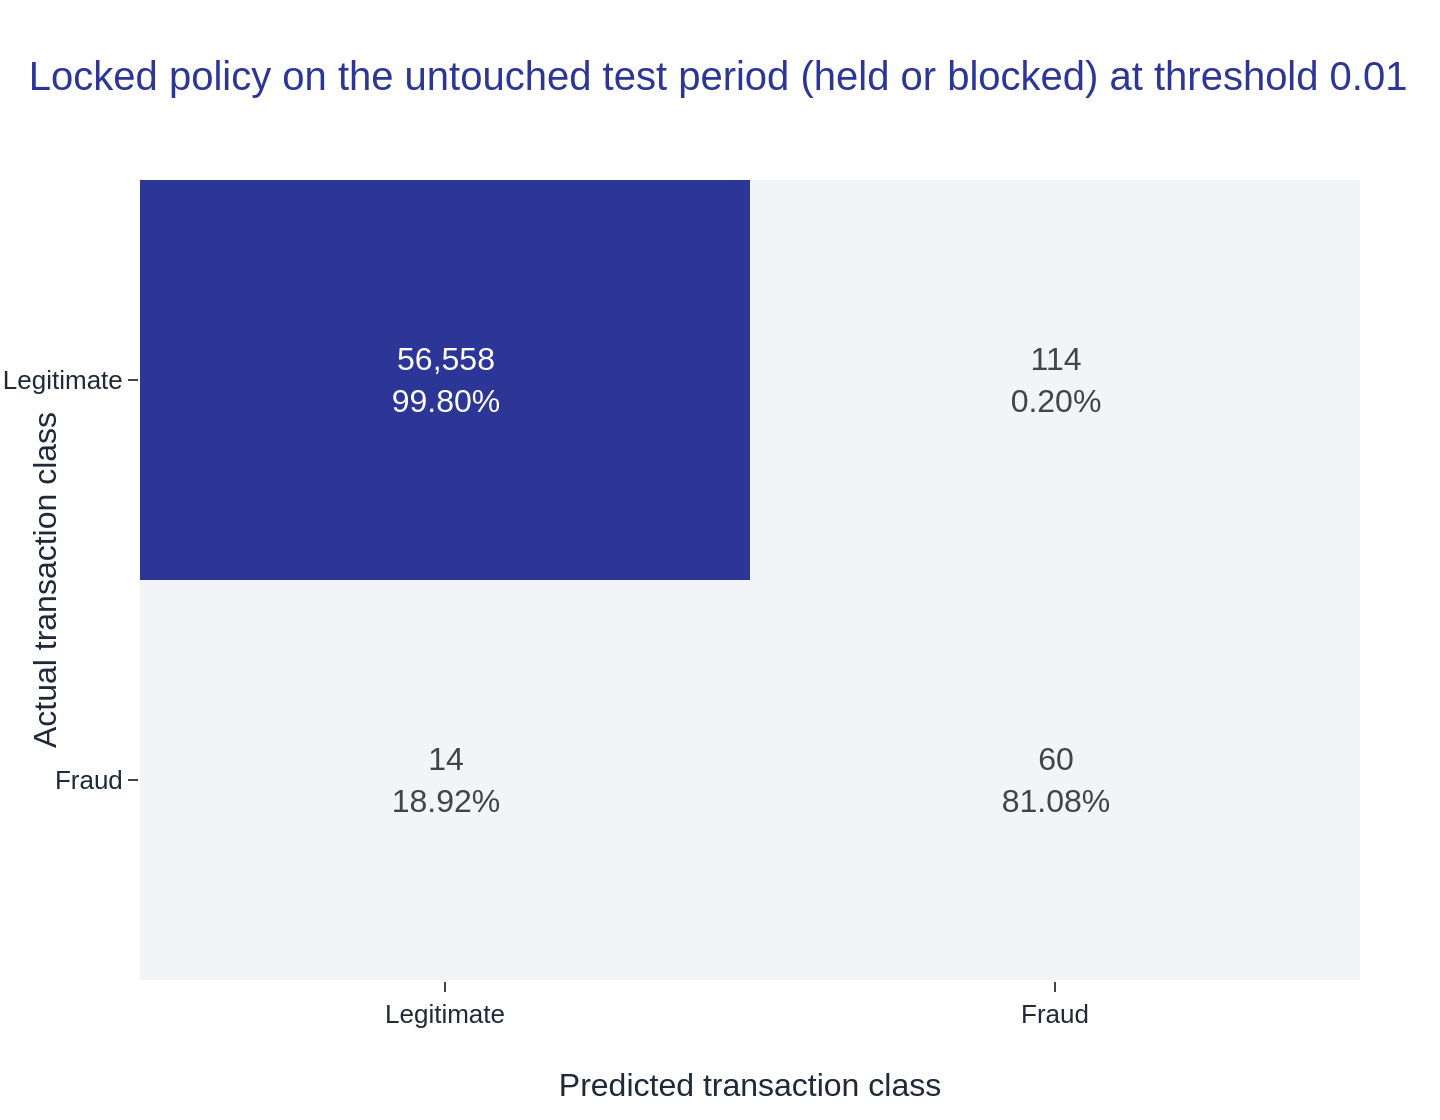

,Cost of an analyst review,Automated verifications,Cases reaching an analyst,Value of fraud intercepted,Value of fraud missed,Handling cost,Customer disruption cost,Net position
0,EUR 5,"2,443",174,"EUR 5,377","EUR 2,350","EUR 1,114","EUR 2,392","EUR 1,872"
1,EUR 10,"2,443",174,"EUR 5,377","EUR 2,350","EUR 1,984","EUR 2,392","EUR 1,002"
2,EUR 25,"2,443",174,"EUR 5,377","EUR 2,350","EUR 4,594","EUR 2,392","EUR -1,608"
3,EUR 50,"2,443",174,"EUR 5,377","EUR 2,350","EUR 8,944","EUR 2,392","EUR -5,958"



The net position is positive at the lower analyst rates and turns negative as the rate rises. That is a finding, not a failure of the policy, and it deserves to be stated plainly rather than hidden behind a favourable choice of assumption.
The reason is that the fraud in this sample is low in value: the intercepted transactions are worth EUR 5,377 in total across 56,746 transactions. Measured only against the face value of the transactions, a fraud operation of this size is difficult to justify at a high cost per review.
Real fraud losses are larger than the transaction amount. They include chargeback fees, the cost of reissuing cards, customer attrition after an undetected fraud, and regulatory exposure. None of those appear in this dataset, so the figures above understate the value of interception by an unknown amount. I would not present this net position as a business case without them.
Overall disruption rate on the test period: 0.2012%


,Segment,Median amount,Legitimate,Customers disrupted,Disruption rate,Disparity ratio,Fraud cases,Detection rate
0,D1,EUR 0.97,"6,343",29,0.4572%,2.27x,28,92.9%
1,D2,EUR 1.98,"6,182",11,0.1779%,0.88x,7,85.7%
2,D3,EUR 5.49,"6,156",24,0.3899%,1.94x,8,87.5%
3,D4,EUR 10.00,"6,209",9,0.1450%,0.72x,3,100.0%
4,D5,EUR 17.00,"5,628",5,0.0888%,0.44x,2,50.0%
5,D6,EUR 28.75,"5,520",2,0.0362%,0.18x,1,100.0%
6,D7,EUR 46.96,"5,541",3,0.0541%,0.27x,7,85.7%
7,D8,EUR 76.60,"5,015",4,0.0798%,0.40x,3,100.0%
8,D9,EUR 138.05,"5,055",6,0.1187%,0.59x,4,75.0%
9,D10,EUR 359.20,"5,023",21,0.4181%,2.08x,11,72.7%


In [58]:
# ---------------------------------------------------------
# Validation against test, side by side
# ---------------------------------------------------------
period_comparison = pd.concat(
    [validation_policy, test_policy], ignore_index=True
)

fig = px.bar(
    period_comparison[period_comparison["Response"] != "Approve"],
    x="Response",
    y="Share of all fraud",
    color="Period",
    barmode="group",
    text="Fraud in band",
    category_orders={"Response": ["Verify", "Review", "Block"]},
    color_discrete_map={"Validation": BRAND_BLUE, "Test": BRAND_ORANGE},
    custom_data=["Transactions", "Precision within band", "Fraud in band"],
)

fig.update_traces(
    texttemplate="%{text}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{fullData.name} period</b><br>"
        "Response: %{x}<br>"
        "Share of all fraud in this band: %{y:.1%}<br>"
        "Fraud cases: %{customdata[2]}<br>"
        "Transactions in band: %{customdata[0]:,}<br>"
        "Precision within band: %{customdata[1]:.1%}"
        "<extra></extra>"
    ),
)

fig = apply_house_style(
    fig,
    title="The graded policy behaves consistently out of time",
    x_title="Response imposed",
    y_title="Share of all fraud in the period",
    show_legend=True,
)

fig.update_yaxes(tickformat=".0%")
fig.show()


# Confusion matrix for the actions a customer notices
test_disruptive = np.isin(test_bands, ["Review", "Block"])

test_matrix = confusion_matrix(
    y_test_array, test_disruptive.astype(int), labels=[0, 1]
)

row_totals = test_matrix.sum(axis=1, keepdims=True)

test_percentages = (
    np.divide(
        test_matrix,
        row_totals,
        out=np.zeros_like(test_matrix, dtype=float),
        where=row_totals != 0,
    )
    * 100
)

plot_confusion_matrix(
    test_matrix,
    test_percentages,
    model_name="Locked policy on the untouched test period (held or blocked)",
    threshold=review_threshold,
)


# ---------------------------------------------------------
# Cost of the locked policy
# ---------------------------------------------------------
# Each band is costed at its own handling rate. Applying a single flat cost
# per alert would charge an automated verification message at the price of an
# analyst investigation, which is exactly the conflation the graded policy
# exists to avoid. The analyst rate is the genuinely uncertain quantity, so
# that is the one I vary.
AUTOMATED_VERIFICATION_COST = 0.10

test_band_labels = assign_response_band(test_period_scores)

band_volumes = {
    band_name: int((test_band_labels == band_name).sum())
    for band_name in BAND_ORDER
}

caught_value = test_amounts[(y_test_array == 1) & test_action].sum()
missed_value = test_amounts[(y_test_array == 1) & ~test_action].sum()

customer_disruption_cost = sum(
    int(((test_band_labels == band_name) & (y_test_array == 0)).sum())
    * DISRUPTION_COST[band_name]
    for band_name in BAND_ORDER
)

test_cost_rows = []

for analyst_cost in [5, 10, 25, 50]:
    handling_cost = (
        band_volumes["Verify"] * AUTOMATED_VERIFICATION_COST
        + (band_volumes["Review"] + band_volumes["Block"]) * analyst_cost
    )

    test_cost_rows.append(
        {
            "Cost of an analyst review": analyst_cost,
            "Automated verifications": band_volumes["Verify"],
            "Cases reaching an analyst": (
                band_volumes["Review"] + band_volumes["Block"]
            ),
            "Value of fraud intercepted": caught_value,
            "Value of fraud missed": missed_value,
            "Handling cost": handling_cost,
            "Customer disruption cost": customer_disruption_cost,
            "Net position": (
                caught_value - handling_cost - customer_disruption_cost
            ),
        }
    )

test_cost_summary = pd.DataFrame(test_cost_rows)

display(
    test_cost_summary.style.format(
        {
            "Cost of an analyst review": "EUR {:,.0f}",
            "Automated verifications": "{:,.0f}",
            "Cases reaching an analyst": "{:,.0f}",
            "Value of fraud intercepted": "EUR {:,.0f}",
            "Value of fraud missed": "EUR {:,.0f}",
            "Handling cost": "EUR {:,.0f}",
            "Customer disruption cost": "EUR {:,.0f}",
            "Net position": "EUR {:,.0f}",
        }
    )
)

print(
    "\nThe net position is positive at the lower analyst rates and turns "
    "negative as the rate rises. That is a finding, not a failure of the "
    "policy, and it deserves to be stated plainly rather than hidden behind a "
    "favourable choice of assumption."
)
print(
    "The reason is that the fraud in this sample is low in value: the "
    f"intercepted transactions are worth EUR {caught_value:,.0f} in total "
    f"across {len(test_df):,} transactions. Measured only against the face "
    "value of the transactions, a fraud operation of this size is difficult "
    "to justify at a high cost per review."
)
print(
    "Real fraud losses are larger than the transaction amount. They include "
    "chargeback fees, the cost of reissuing cards, customer attrition after "
    "an undetected fraud, and regulatory exposure. None of those appear in "
    "this dataset, so the figures above understate the value of interception "
    "by an unknown amount. I would not present this net position as a "
    "business case without them."
)

# Distributional check on the test period, using the same segments
test_amount_segment, test_time_segment = build_segments(test_df)

test_fairness, overall_test_disruption = distributional_report(
    test_df,
    y_test,
    test_period_scores,
    test_amount_segment,
    "Transaction amount decile",
)

print(
    f"Overall disruption rate on the test period: {overall_test_disruption:.4%}"
)

display(
    test_fairness[
        [
            "Segment",
            "Median amount",
            "Legitimate",
            "Customers disrupted",
            "Disruption rate",
            "Disparity ratio",
            "Fraud cases",
            "Detection rate",
        ]
    ].style.format(
        {
            "Median amount": "EUR {:,.2f}",
            "Legitimate": "{:,.0f}",
            "Disruption rate": "{:.4%}",
            "Disparity ratio": "{:.2f}x",
            "Detection rate": "{:.1%}",
        }
    )
)

### Reading the test result

The headline figure to quote is the interval, not the point estimate. With 74 fraud cases in the test period, the interval is wide, and any summary that reports a single number to three decimal places is overstating what this evaluation can support.

The comparison that matters operationally is the graded policy applied unchanged to a period the model has never seen. The share of fraud captured in each band, and the volume of customers affected in each band, are the numbers an operations team would plan against.

The prediction check is the part I would draw attention to. Precision was expected to move between the two periods purely because the fraud rate changed, and the predicted value was written down before the test scores were produced. This matters in production: when precision falls, the first question is whether the model has degraded or whether there is simply less fraud about. Those two situations demand opposite responses, and separating them requires the prevalence adjustment above rather than a dashboard threshold.

## Testing the assumption made at the very beginning

Early in the analysis I removed 1,081 exact duplicate rows, recorded that decision as an assumption rather than an obvious cleaning step, and promised to check the conclusions against a dataset that keeps every observation. That check is due.

The entire pipeline is repeated on the full dataset with duplicates retained: chronological split, the same tuned hyperparameters, the same calibration procedure and the same band boundaries derived from that pipeline's own validation period. If the conclusions only hold under one treatment of duplicates, that would be an important finding and it belongs in the notebook rather than in a footnote.

In [59]:
# ---------------------------------------------------------
# Repeat the pipeline with every observation retained
# ---------------------------------------------------------
duplicates_retained_df = df.sort_values("Time").reset_index(drop=True)

retained_train_end = int(len(duplicates_retained_df) * 0.60)
retained_validation_end = int(len(duplicates_retained_df) * 0.80)

retained_train = engineer_features(
    duplicates_retained_df.iloc[:retained_train_end]
)
retained_validation = engineer_features(
    duplicates_retained_df.iloc[retained_train_end:retained_validation_end]
)
retained_test = engineer_features(
    duplicates_retained_df.iloc[retained_validation_end:]
)

retained_calibration_index = int(len(retained_train) * 0.80)

retained_fit = retained_train.iloc[:retained_calibration_index]
retained_calibration = retained_train.iloc[retained_calibration_index:]

retained_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    **best_xgb_parameters,
)

retained_model.fit(
    retained_fit[final_xgb_features],
    retained_fit["Class"],
    verbose=False,
)

retained_calibrated = CalibratedClassifierCV(
    estimator=retained_model,
    method=selected_calibration_method,
    cv="prefit",
)

retained_calibrated.fit(
    retained_calibration[final_xgb_features],
    retained_calibration["Class"],
)

retained_validation_scores = retained_calibrated.predict_proba(
    retained_validation[final_xgb_features]
)[:, 1]

retained_test_scores = retained_calibrated.predict_proba(
    retained_test[final_xgb_features]
)[:, 1]

robustness_rows = [
    {
        "Dataset": "Duplicates removed (primary)",
        "Transactions": len(analysis_df),
        "Test fraud cases": int(y_test_array.sum()),
        "Validation average precision": average_precision_score(
            y_validation, calibrated_validation_scores
        ),
        "Test average precision": test_ranking_metrics["Average precision"],
        "Test ROC-AUC": test_ranking_metrics["ROC-AUC"],
    },
    {
        "Dataset": "Duplicates retained",
        "Transactions": len(duplicates_retained_df),
        "Test fraud cases": int(retained_test["Class"].sum()),
        "Validation average precision": average_precision_score(
            retained_validation["Class"], retained_validation_scores
        ),
        "Test average precision": average_precision_score(
            retained_test["Class"], retained_test_scores
        ),
        "Test ROC-AUC": roc_auc_score(
            retained_test["Class"], retained_test_scores
        ),
    },
]

robustness_comparison = pd.DataFrame(robustness_rows)

display(
    robustness_comparison.style.format(
        {
            "Transactions": "{:,.0f}",
            "Validation average precision": "{:.3f}",
            "Test average precision": "{:.3f}",
            "Test ROC-AUC": "{:.4f}",
        }
    )
)

# Is the difference larger than the uncertainty already established?
test_average_precision_interval = np.percentile(
    test_bootstrap["Calibrated XGBoost"], [2.5, 97.5]
)

difference_between_treatments = abs(
    robustness_comparison.loc[0, "Test average precision"]
    - robustness_comparison.loc[1, "Test average precision"]
)

print(
    f"\nDifference in test average precision between the two treatments: "
    f"{difference_between_treatments:.3f}"
)
print(
    "Width of the 95% interval on the primary test estimate:        "
    f"{test_average_precision_interval[1] - test_average_precision_interval[0]:.3f}"
)

if (
    difference_between_treatments
    < test_average_precision_interval[1] - test_average_precision_interval[0]
):
    print(
        "\nThe difference between the two treatments of duplicates is smaller "
        "than the sampling uncertainty in the estimate itself. The conclusions "
        "do not depend on that early decision."
    )
else:
    print(
        "\nThe difference between the two treatments exceeds the sampling "
        "uncertainty. The duplicate-handling decision is material and would "
        "need to be resolved with a transaction identifier before deployment."
    )

,Dataset,Transactions,Test fraud cases,Validation average precision,Test average precision,Test ROC-AUC
0,Duplicates removed (primary),"283,726",74,0.763,0.778,0.9677
1,Duplicates retained,"284,807",75,0.770,0.778,0.9669



Difference in test average precision between the two treatments: 0.000
Width of the 95% interval on the primary test estimate:        0.177

The difference between the two treatments of duplicates is smaller than the sampling uncertainty in the estimate itself. The conclusions do not depend on that early decision.


## What this model is not, and what I would do next

A short section on limitations is worth more than a long one on results, so this is deliberate rather than a formality.

**What the data cannot support.** The features are anonymised principal components, so the reason codes produced above are mechanically correct but not meaningful to a customer or an analyst. There is no customer identifier, so I cannot tell whether false alerts concentrate on a small number of repeatedly inconvenienced people, which is the disparity most likely to cause real harm. There are no protected characteristics, so the distributional analysis uses transaction size as an economic proxy and is not a substitute for a fairness audit. The data spans two days, so nothing here speaks to seasonality, and what I have called an out-of-time test is a matter of hours rather than months.

**What the numbers cannot support.** Every performance figure rests on 57 fraud cases in validation and 74 in test. The intervals throughout are wide: the cost-optimal operating point moves by more than twentyfold across plausible assumptions about the cost of an alert, and by roughly a further factor of two under resampling with that assumption held fixed. Differences of a hundredth in average precision are not real, and I have avoided acting on them.

**What is assumed rather than known.** The cost of an alert, the cost of each response band, the recovery rate on intercepted fraud and the acceptable disparity ceiling are all my assumptions. They are declared as named constants at the point of use so that anyone can change them and re-run the analysis. None of them came from the data, and the notebook is explicit about which conclusions depend on them.

**What I would do next, in order.**

1. Obtain the real costs. The alert cost and the customer cost of each response band would come from operations and from customer research, and they would replace the sensitivity sweep with an actual objective.
2. Add a transaction identifier and customer-level features, which would resolve the duplicate question properly and allow the concentration of false alerts on individual customers to be measured.
3. Evaluate over months rather than hours, with a rolling-origin backtest, which is the only way to know whether the model needs retraining weekly or quarterly.
4. Instrument the monitoring before deployment: population stability on the inputs and scores, calibration drift, prevalence-adjusted precision, and the per-segment disruption rates from the distributional analysis. Each of these has a defined action attached to it, rather than being a chart someone looks at.
5. Run a champion-challenger comparison in shadow mode against the existing rules engine, since the relevant benchmark is what the bank does today, not a naive baseline.

**The judgement I would defend.** The strongest model by average precision is not automatically the right model to deploy, a threshold that minimises an estimated cost is fitted to noise when fraud cases number in the dozens, and a system that can only approve or decline will always resolve the conflict between catching fraud and protecting customers badly. The graded policy, the explicit and challengeable cost assumptions, and the intervals attached to every headline number are the parts of this notebook I would stand behind.